In [1]:
import cv2    # indicator if venv is active w/ Notebook running w/in the venv

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image, clear_output
import ipywidgets as widgets
from typing import List, Dict, Tuple

import matplotlib.pyplot as plt


## <font color = lime> About This Notebook:

### There are 6 Steps including a few sub-versions

        Feynman was right: You don't truly understand something until you can explain it simply. And when you try to explain it, you often discover you didn't understand it as well as you thought.


#### Frame-Difference (FD) Behavior (Frame-by-Frame)

Processes: 

- Step 1) blob detection
    - For every frame, detect every blob ≥ min_area
- Step 2) blob w/ bounding box
    - For every blob from Step 1 - compute bounding box (x, y, w, h)
- Step 3) blob w/ bounding box w/ Centroid
   - For every bbox from Step 2, compute centroid (cx, cy) = (x + w/2, y + h/2)

Common:

Gating: (not temporal):



#### <font color = cyan> The brightness change at a single pixel:

    - pixel_diff >= diff_threshold → motion pixel (set to 255)  
    - pixel_diff < diff_threshold → suppressed as background (set to 0)

            diff = cv2.absdiff(frame_t, frame_t_minus_1)  # values 0–255
            pixel_diff = abs(frame_t - frame_(t-1))       # values 0–255
            
            _, binary_mask = cv2.threshold(diff, diff_threshold, 255, cv2.THRESH_BINARY)
            
            binary_mask = (pixel_diff >= diff_threshold)
       
            pixel gate:
            pixel_diff >= diff_threshold:
                pixel → motion (255)
            else:
                pixel → background (0)

            Note: cv2.threshold() - the pixel-level binary gating (the first gate: determines which pixels get promoted into the binary motion mask)


- cv2.contourArea(cnt) - Blob‑level binary gating (min_area): provides the pixel area for the binary blob detection


#### <font color = cyan> Filter contours by size:

            area = cv2.contourArea(cnt)

            blob gate:
            area >= min_area      

            if area >= min_area
                blob → kept / counted (n)
            else
                blob → background  (0)
               
          
- Motion is detected. No continuity / no temporal continuity
- cv2.threshold - Applies a threshold operation to an image.



## <font color = yellow> cv2: pixel-level (preprocess and gating) frame-by-frame

#### <font color = lime> Pixel preprocessing (1-3)

- cv2.absdiff ( )  - frame difference
- cv2.threshold ( ) - the actual gate
-  Binary mask cleanup (morphology, still at pixel level)
-  ...
   

1. cv2.VideoCapture ( ) ... aka frame acquisition: raw sensor/compressed data (Pixel domain: 3-channel BGR, 8-bit per channel (0–255) )

    - Produces a frame in BGR format
    - Pixel domain: 8-bit per channel → [0..255]
    - frame_prev and frame_curr are raw pixel arrays straight from the video decoder.   


            cap = cv2.VideoCapture(video_path)
              ...


2. cv2.cvtColor ( ) ... Convert to grayscale: Color → grayscale (each pixel) Output: single‑channel grayscale frames (0–255 intensity).

    - Converts 3-channel BGR → 1-channel grayscale
    - Gives each pixel a single intensity value used for diff

      
            gray_prev = cv2.cvtColor(frame_prev, cv2.COLOR_BGR2GRAY)  # cv2.COLOR_BGR2GRAY is a cv2 flag - there are 150 other conversion codes} 
            gray_curr = cv2.cvtColor(frame_curr, cv2.COLOR_BGR2GRAY)
              ...

3. cv2.GaussianBlur( ) ... Denoising / smoothing (optional)

    - Reduce random flicker, compression noise, and tiny speckle
    - Smooths pixel intensity so the difference image is less chaotic
      
      
            gray_prev_blur = cv2.GaussianBlur(gray_prev, (5, 5), 0)
            gray_curr_blur = cv2.GaussianBlur(gray_curr, (5, 5), 0)
              ...
      
#### <font color = lime> Pixel gating (4-5)


4. cv2.absdiff(gray_curr, gray_prev) → pixel‑wise absolute difference.

- Computes |curr − prev|
- Produces the 0–255 diff image
- Still pixel domain, but this is the precursor to gating

5. Threshold Gate - the actual gate

- Compares each diff pixel to diff_threshold
- Produces binary mask (0 or 255)

 






## <font color = yellow> 7.1A: Step 7 - Model Assumptions:

#### <font color = lime> May require updating after velocity updates



    1. VIDEO INPUT ASSUMPTIONS
    
    1.1 Recorded Video (Not Live Stream)
    
    Assumption: Video is pre-recorded and accessible for sequential frame-by-frame processing
    Implications:
    
    Can process frames in strict temporal order (frame 0 → frame N)
    No real-time latency constraints
    Can restart processing if parameters need tuning
    Cannot use future frames for prediction (no look-ahead)
    
    
    Breaks if:
    
    Live streaming required (would need buffering strategy)
    Random frame access needed (would need index structure)
    Processing must complete faster than frame rate (would need optimization)
    
    
    
    1.2 Fixed Camera (Static Background)
    
    Assumption: Camera is stationary (tripod, fixed mount)
    Implications:
    
    Frame differencing works (background pixels remain constant)
    Motion detection isolates moving objects only
    No need for camera motion compensation (ego-motion correction)
    
    
    Breaks if:
    
    Camera pans/tilts/zooms (entire frame would appear as motion)
    Camera shake/vibration (noisy motion detection)
    Handheld recording (would need stabilization or optical flow)
    
    
    
    1.3 Consistent Frame Rate
    
    Assumption: Video has uniform temporal sampling (e.g., 30 fps constant)
    Implications:
    
    Velocity calculations assume Δt = 1 frame = constant time
    Displacement thresholds (MIN_DISP_PX, MAX_DISP_PX) are frame-rate dependent
    Motion prediction model assumes uniform time steps
    
    
    Breaks if:
    
    Variable frame rate video (would need timestamp-based velocity)
    Dropped frames (would need interpolation or adaptive Δt)
    Time-lapse or slow-motion (would need recalibration)
    
    
    
    
    2. SCENE CONTENT ASSUMPTIONS
    
    2.1 Single Primary Object (One Eagle)
    
    Assumption: At most one eagle in frame at any time
    Implications:
    
    Greedy association works (no ambiguous matches)
    "Best track" selection is meaningful (one ground truth)
    Identity management not critical (no ID switching)
    
    
    Breaks if:
    
    Multiple eagles in frame simultaneously
    Eagles cross paths (identity switches)
    Eagle interacts with other birds (sparrows, crows)
    Solution: Upgrade to Hungarian assignment + appearance model
    
    
    
    2.2 Straight-Line Flight Path
    
    Assumption: Eagle maintains approximately linear trajectory (gliding, not maneuvering)
    Implications:
    
    Linear velocity model is sufficient: x(t+Δt) = x(t) + v·Δt
    High linearity ratio (MIN_LINEARITY_RATIO = 0.45) is valid gate
    Heading variance should be low (MAX_HEADING_STD_DEG = 180° is very permissive)
    
    
    Breaks if:
    
    Eagle performs tight turns/banks (curved trajectories)
    Eagle hovers or circles (non-linear motion)
    Eagle dives/ascends steeply (acceleration changes)
    Solution: Upgrade to Kalman Filter (models acceleration) or Interacting Multiple Model (IMM)
    
    
    
    2.3 Horizontal Flight (Level Path)
    
    Assumption: Eagle flies primarily horizontally (not diving vertically)
    Implications:
    
    Vertical corridor gate (EAGLE_Y_MIN to EAGLE_Y_MAX) makes sense
    Heading bands (ALLOWED_HEADING_BANDS = [-45°, 45°]) assume lateral motion
    Y position should be relatively stable
    
    
    Breaks if:
    
    Eagle performs steep dives (Y changes dramatically)
    Eagle flies vertically upward (violates Y corridor)
    Camera angle is not horizontal (would need rotated corridor)
    
    
    
    2.4 Consistent Appearance
    
    Assumption: Eagle's visual appearance is constant (size, shape, brightness)
    Implications:
    
    Min/max area thresholds (min_area_values) are fixed
    No appearance-based re-identification
    Bounding box size not used as discriminator
    
    
    Breaks if:
    
    Eagle changes distance from camera (size varies)
    Eagle rotates (shape changes: profile vs. wingspan)
    Lighting changes (brightness varies)
    Solution: Add appearance model (color histogram, HOG features)
    
        
    3. MOTION DETECTION ASSUMPTIONS
    
    3.1 Frame Differencing Sufficiency
    
    Assumption: Absolute difference between consecutive frames captures all relevant motion
    Implications:
    
    Works for high-contrast objects (dark eagle on light sky)
    Sensitive to threshold (diff_threshold_values = [2.0, 2.30])
    Misses slow-moving objects (displacement < 1 pixel/frame)
    
    
    Breaks if:
    
    Eagle color similar to background (low contrast)
    Very slow motion (gliding at distance)
    Very fast motion (motion blur, exceeds centroid_threshold)
    Solution: Use optical flow, background subtraction, or learning-based detector
    
    
    
    3.2 Static Noise Sources Removable by ROI
    
    Assumption: Unwanted motion (water shimmer, foliage) is spatially fixed
    Implications:
    
    ROI_REMOVE_RECT = (0, 300, 1920, 1080) excludes bottom portion
    Works only if noise sources don't overlap eagle trajectory
    Requires manual tuning per camera location
    
    
    Breaks if:
    
    Noise moves spatially (birds flying through frame)
    Eagle trajectory overlaps ROI exclusion zone (would be filtered out)
    Wind patterns change (trees blow into previously clear areas)
    Solution: Adaptive ROI, semantic segmentation, or motion classification
    
    
    
    3.3 Morphological Operations Preserve Signal
    
    Assumption: Opening (erosion→dilation) removes noise, closing (dilation→erosion) fills gaps
    Implications:
    
    Works for blob-like detections
    May merge nearby objects (if too close)
    May split single object (if concave shape)
    
    
    Breaks if:
    
    Eagle has complex shape (wingspan creates multiple blobs)
    Multiple objects too close (merge into one)
    Kernel size inappropriate (too large = lost detail, too small = noisy)
    
    
    
    
    4. TEMPORAL ASSOCIATION ASSUMPTIONS
    
    4.1 Temporal Window (FRAME_WINDOW + BUFFER)
    
    Assumption: Track survives MAX_MISS = FRAME_WINDOW(4) + BUFFER(1) = 5 frames without observation
    Design Choice: Balances false termination vs. false continuation
    Implications:
    
    FRAME_WINDOW = 4: Matches detection smoothing window (consistency)
    BUFFER = 1: Allows brief occlusions (single missed frame)
    Track terminates after 5 consecutive misses
    
    
    User Tunability: BUFFER configurable 0-10
    
    BUFFER=0: Strict (track dies after 4 misses)
    BUFFER=3: Lenient (7 frames, for heavy foliage occlusion)
    BUFFER=10: Very lenient (14 frames, for intermittent detection)
    
    
    Breaks if:
    
    Occlusions > MAX_MISS frames (track fragments)
    Detection rate < 1/MAX_MISS (track never promoted)
    Fast-moving object leaves frame (continues predicting off-screen)
    
    
    
    4.2 Linear Constant Velocity Model
    
    Assumption: Object maintains constant velocity during gaps
    Model: predicted_position = last_position + velocity × Δt
    Velocity Computation: Smoothed over VELOCITY_SMOOTH_WINDOW = 3 frames
    Implications:
    
    Prediction accuracy degrades as Δt² (quadratic error growth)
    No acceleration modeling
    No uncertainty quantification (no prediction covariance)
    
    
    Appropriate For:
    
    Straight-line motion (gliding)
    Short gaps (Δt < 5 frames)
    Low acceleration scenarios
    
    
    Breaks if:
    
    Object accelerates/decelerates (diving, flaring to land)
    Object turns (velocity direction changes)
    Gap duration > 5 frames (prediction degrades)
    Solution: Upgrade to Kalman Filter (models process noise, provides covariance)
    
    
    
    4.3 Adaptive Search Radius
    
    Assumption: Prediction uncertainty grows with gap duration
    Formula: radius = base_radius × BASE_SCALE(1.0) × GROWTH(1.3)^miss_count
    Implications:
    
    Miss count = 0: radius = base (35-50 px, tight matching)
    Miss count = 3: radius ≈ 2.2× base (accounts for uncertainty)
    Prevents prediction divergence from breaking association
    
    
    Breaks if:
    
    Growth too slow (fails to capture object after gap)
    Growth too fast (matches wrong object)
    Multiple objects in expanded radius (ambiguous assignment)
    
    
    
    
    5. DATA ASSOCIATION ASSUMPTIONS
    
    5.1 Greedy Nearest Neighbor (Current Strategy)
    
    Assumption: Closest prediction-detection pair is correct match
    Algorithm:
    
    Compute all (track, detection) distances
    Sort by distance (ascending)
    Greedily assign closest pair, mark both as used, repeat
    
    
    Computational Complexity: O(n²) where n = max(tracks, detections)
    Appropriate For:
    
    Low object density (1-3 objects/frame)
    Well-separated tracks (> 100px apart)
    Real-time requirements
    
    
    Limitations:
    
    Not globally optimal (may make locally greedy mistake)
    Fails on crossing trajectories (identity switches)
    Sensitive to ordering in tie-breaking
    
    
    Breaks if:
    
    Multiple eagles cross paths
    Object density > 5 per frame
    Need provably optimal assignment
    Solution: Upgrade to Hungarian Algorithm (globally optimal, O(n³))
    
    
    
    5.2 Single Assignment (One Detection Per Track)
    
    Assumption: Each track matches at most one detection per frame
    Implications:
    
    Tracks don't split (one object → two tracks)
    Detections don't merge (two objects → one track)
    Valid only if objects maintain identity
    
    
    Breaks if:
    
    Eagle splits into multiple blobs (morphology failure)
    Two eagles merge visually (appear as one blob)
    Solution: Multi-hypothesis tracking or track merging/splitting logic
    
    
    
    
    6. TEMPORAL GATING ASSUMPTIONS
    
    6.1 Minimum Track Length (MIN_TRACK_LENGTH_FRAMES = 8)
    
    Assumption: Valid tracks span at least 8 observed frames
    Rationale: Filters transient false positives (leaves, birds)
    Implications:
    
    Eagle must be detectable for ≥ 8 frames
    If frame rate = 30fps, this = 0.27 seconds minimum
    
    
    Breaks if:
    
    Eagle passes through frame very quickly
    Detection rate poor (eagle visible but not detected)
    Frame rate very low (8 frames = long duration)
    
    
    
    6.2 Observation Density (MIN_OBSERVATION_DENSITY = 0.65)
    
    Assumption: Valid tracks are observed in ≥ 65% of their temporal span
    Calculation: density = observed_frames / (end_frame - start_frame + 1)
    Rationale: Rejects fragmented tracks with excessive gaps
    Implications:
    
    Track can miss 35% of frames and still be valid
    Replaces complex positional gap constraints
    
    
    User Tunability: Adjust based on occlusion frequency
    
    Low occlusion (open sky): 0.80-0.90
    Moderate (trees): 0.65-0.75 ← CURRENT
    Heavy (urban): 0.50-0.60
    
    
    Breaks if:
    
    Frequent heavy occlusions (e.g., dense forest)
    Detection algorithm unreliable (misses detections even when visible)
    
    
    
    6.3 Displacement Gate (MIN_DISP_PX ≤ median_disp ≤ MAX_DISP_PX)
    
    Assumption: Valid tracks have consistent per-frame displacement
    Current Values: MIN = 5px, MAX = 9999px (effectively no upper bound)
    Rationale: Filters stationary false positives (MIN) and jittery noise (MAX if set)
    Implications:
    
    Eagle must move ≥ 5px/frame (at 30fps, ≥ 150 px/sec)
    Upper bound disabled (MAX = 9999) → allows very fast motion
    
    
    Breaks if:
    
    Eagle hovers (displacement < 5px/frame)
    Frame rate different (5px at 60fps = slower motion than at 30fps)
    Camera zoomed in (same physical speed = higher pixel displacement)
    
    
    
    6.4 Variance/Linearity Gate
    
    Assumptions:
    
    linearity_ratio = net_displacement / path_length ≥ 0.45
    heading_std ≤ 180° (very permissive, effectively disabled)
    
    
    Rationale: Straight flight should have high linearity, low heading variance
    Implications:
    
    Path can be 55% non-linear (curved) and still pass
    Heading standard deviation check is essentially off (180° allows full circle)
    
    
    Breaks if:
    
    Eagle performs tight circles (linearity < 0.45)
    Noisy detections create zigzag path (low linearity)
    Very short tracks (linearity computation unstable)
    
    
    
    6.5 Directional Gate (ALLOWED_HEADING_BANDS = [(-45°, 45°)])
    
    Assumption: Eagle flies predominantly rightward (0° ± 45°)
    Coordinate System:
    
    0° = rightward (+X direction)
    90° = downward (+Y direction, standard image coords)
    -90° = upward (-Y direction)
    
    
    Implications:
    
    Rejects leftward tracks (heading 135° to -135°)
    Allows gentle ascents/descents within ±45° cone
    
    
    Breaks if:
    
    Eagle flies leftward (would be filtered)
    Camera orientation different (heading band needs rotation)
    Eagle trajectory complex (multiple heading modes)
    
    
    
    
    7. QUALITY SCORING ASSUMPTIONS
    
    7.1 Composite Score (Length + Heading + Y-Corridor)
    
    Assumption: "Best track" is longest, straightest, in expected region
    Weights:
    
    Length: 0.5 (50%)
    Heading alignment: 0.3 (30%)
    Y-corridor: 0.2 (20%)
    
    
    Implications:
    
    Prioritizes long tracks over short (length dominates)
    Heading deviation tolerated (exponential decay, 30° half-life)
    Vertical position less important (20% weight)
    
    
    Design Choice: Weights encode domain knowledge (eagle flight characteristics)
    Breaks if:
    
    Multiple eagles (which one is "best"?)
    Eagle performs unusual maneuver (low quality but correct)
    Weights inappropriate for scene (e.g., Y-position critical if camera angled)
    
    
    
    7.2 Confidence Score (Quality × Observation Density)
    
    Assumption: Tracks with gaps are less reliable
    Formula: confidence = quality_score × observation_density
    Example:
    
    Track A: quality=0.8, density=1.0 → confidence=0.80
    Track B: quality=0.8, density=0.67 → confidence=0.53
    
    
    Implications:
    
    Penalizes tracks with many gaps (lower confidence)
    Separates trajectory quality from data completeness
    
    
    Rationale: Incomplete tracks less trustworthy for analytics
    
    
    8. UNUSED / AMBIGUOUS PARAMETERS
    
    8.1 TAU Variable (τ = 1.4)
    
    Defined in Config: TAU = 1.4
    NOT USED in Step 7 code
    Likely Origin: Step 4 adaptive centroid threshold (from previous iterations)
    Original Purpose: Scale factor for dynamic threshold adjustment
    Current Status: Dead code (should remove or document purpose)
    
    8.2 L1, L2 Weights (0.7, 0.3)
    
    Defined in Config: L1 = 0.7, L2 = 0.3
    NOT USED in Step 7 code
    Likely Origin: Step 4 composite score (distance + area matching)
    Current Status: Dead code (leftover from earlier version)
    
    8.3 C_MAX, MIN_COVERAGE (300, 0.6)
    
    Defined in Config: C_MAX = 300, MIN_COVERAGE = 0.6
    NOT USED in Step 7 code
    Likely Origin: Step 4 detection quality filtering
    Current Status: Dead code (should remove)
    
    8.4 Hysteresis Gate Parameters
    
    USE_HYSTERESIS_GATE = False (disabled by default)
    Parameters: PROMOTE_MIN_CONSEC_GOOD, DEMOTE_MAX_CONSEC_BAD
    Purpose: Smooth gate decisions over time (prevent jitter)
    Current Status: Implemented but disabled (Step 5 legacy)
    When to Enable: If gate decisions are noisy (track keeps promoting/demoting)
    
    
    9. ALGORITHM FAILURE MODES
    
    9.1 Track Fragmentation
    
    Cause: Occlusion duration > MAX_MISS (5 frames default)
    Result: One eagle → multiple track fragments
    Mitigation: Increase BUFFER (e.g., BUFFER=3 → MAX_MISS=7)
    Trade-off: Higher BUFFER → more false continuations
    
    9.2 Identity Switches
    
    Cause: Two eagles cross paths, greedy association picks wrong match
    Result: Track A suddenly becomes Track B's trajectory
    Mitigation: Upgrade to Hungarian assignment + appearance model
    Trade-off: Computational cost increases
    
    9.3 False Track Initiation
    
    Cause: Transient motion (bird, leaf) matches size/motion criteria
    Result: Short false positive tracks
    Mitigation: Increase MIN_TRACK_LENGTH_FRAMES, tighten gates
    Trade-off: May reject valid short eagle passes
    
    9.4 Prediction Divergence
    
    Cause: Eagle turns/accelerates, linear model fails, prediction drifts off
    Result: Track terminates prematurely (can't re-associate)
    Mitigation: Increase search radius growth, upgrade to Kalman filter
    Trade-off: Larger radius → more false associations
    
    9.5 Gate Rejection of Valid Tracks
    
    Cause: Eagle performs unusual maneuver (violates linearity/heading/Y-corridor)
    Result: Correct track filtered as invalid
    Mitigation: Relax gate thresholds (e.g., MIN_LINEARITY_RATIO=0.3)
    Trade-off: More false positives pass gates
    
    
    10. DIAGNOSTIC SEQUENCING (Algorithm Flow)
    
    Copy1. VIDEO INPUT (Recorded, Fixed Camera, Constant FPS)
       ↓
    2. FRAME DIFFERENCING (Static Background Assumption)
       ↓
    3. THRESHOLDING (diff_threshold_values)
       ↓
    4. ROI FILTERING (Remove water/foliage, spatial assumption)
       ↓
    5. MORPHOLOGY (Blob cleanup, preserves eagle shape)
       ↓
    6. CONTOUR DETECTION (min_area filter)
       ↓
    7. TEMPORAL ASSOCIATION (Greedy, Linear Model, MAX_MISS window)
       ↓ [Per Frame Loop]
       ├─ Predict positions (linear velocity)
       ├─ Greedy matching (closest detection)
       ├─ Update matched tracks (velocity refresh)
       ├─ Increment miss_count for unmatched
       └─ Terminate if miss_count > MAX_MISS
       ↓
    8. TEMPORAL GATES (4 sequential filters)
       ├─ Gate 1: Length ≥ 8 frames
       ├─ Gate 2: Density ≥ 0.65
       ├─ Gate 3: Displacement [5px, ∞)
       └─ Gate 4: Linearity ≥ 0.45, Heading ∈ [-45°, 45°]
       ↓
    9. QUALITY SCORING (Composite + Confidence)
       ├─ Length term (50%)
       ├─ Heading alignment (30%)
       ├─ Y-corridor (20%)
       └─ × observation_density
       ↓
    10. OUTPUT: Best Track (highest confidence score)
    
    11. KEY TAKEAWAYS
    Fundamental Assumptions (MUST HOLD)
    
    ✅ Recorded video, static camera, constant frame rate
    ✅ Single eagle, straight flight, horizontal trajectory
    ✅ Frame differencing captures motion adequately
    ✅ ROI exclusion removes noise without losing signal
    
    Design Choices (CONFIGURABLE)
    
    🔧 Motion Model: Linear (upgrade to Kalman if needed)
    🔧 Association: Greedy (upgrade to Hungarian if needed)
    🔧 Temporal Window: FRAME_WINDOW=4, BUFFER=1 (user-tunable)
    🔧 Gates: 4 sequential filters (thresholds adjustable)
    
    Dead Code (CLEANUP NEEDED)
    
    ⚠️ TAU, L1, L2, C_MAX, MIN_COVERAGE (unused Step 4 remnants)
    ⚠️ Hysteresis gate (implemented but disabled by default)
    
    Upgrade Triggers
    
    Multiple Eagles → Hungarian + Appearance Model
    Curved Flight → Kalman Filter
    Heavy Occlusion → Increase BUFFER, Particle Filter
    Live Streaming → Buffering + Latency Management
    
    This algorithm is prototype-appropriate for single-eagle, straight-flight scenarios with good detection reliability. Production deployment with complex scenarios requires upgrades per triggers above.
      

# <font color = lime> Step 1 - blob detection

#### Baseline filter: It reduces the number of candidate blobs before more expensive analysis



- Detects every blob ≥ min_area
- Outputs: blob_count (e.g., "Frame 42 has 5 blobs")
- No selection/filtering — just counting

#### Practical Usage

- Noise suppression: This gating is cheap and effective at eliminating tiny flickers, compression artifacts, or dust (use big number > MIN_AREA)
- When only one dominant moving feature exists, then this "raw gate"  can ensure that feature survives, while everything else is ignored.


##### Summary - raw gate, is a one pass gate w/some significat limitations for usage


## <font color = yellow>2:  Configuration

In [2]:
# Video path - UPDATE THIS TO YOUR FILE
VIDEO_PATH = r"C:\AxisRecordings\Optical_Flow\clips_evals\1010-1641-2-115-small.mkv"

# Motion sensitivity thresholds
DIFF_THRESHOLD = 4      # Pixel intensity change threshold (lower = more sensitive)
MIN_AREA = 10000        # Minimum blob area in pixels (filters tiny noise)

# Preprocessing (Step 1-3 defaults)
BLUR_KERNEL = (5, 5)    # Gaussian blur for noise reduction
USE_MORPH_OPEN = True   # Remove small noise speckles
USE_MORPH_CLOSE = True  # Fill small holes in blobs

print(f"Configuration:")
print(f"  Video: {VIDEO_PATH}")
print(f"  Diff threshold: {DIFF_THRESHOLD}")
print(f"  Min area: {MIN_AREA}")
print(f"  Blur kernel: {BLUR_KERNEL}")

Configuration:
  Video: C:\AxisRecordings\Optical_Flow\clips_evals\1010-1641-2-115-small.mkv
  Diff threshold: 4
  Min area: 10000
  Blur kernel: (5, 5)


## <font color = yellow> FMI

#### Count the number of frames (not done) in the video

In [3]:
# Step 1 does not count the frames and this info is relevent

import cv2

VIDEO_PATH = r"C:\AxisRecordings\Optical_Flow\clips_evals\1010-1641-2-115-small.mkv"

# Open video
cap = cv2.VideoCapture(VIDEO_PATH)

# Get total frame count
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Video: {VIDEO_PATH}")
print(f"Total frames: {frame_count}/n")
print(f"Frames per second: {fps}")

cap.release()


Video: C:\AxisRecordings\Optical_Flow\clips_evals\1010-1641-2-115-small.mkv
Total frames: 115/n
Frames per second: 25.0


## <font color = yellow> 3: Core Function

#### Detection Loop


In [4]:
# function signature defaults to the global constants but allows overrides.

def run_step1_detection(video_path: str, 
                        diff_threshold: float = 5,
                        min_area: int = 10000,
                        max_frames: int = None) -> List[Dict]:
    
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")
    
    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f"Video properties:")
    print(f"  Resolution: {width}x{height}")
    print(f"  FPS: {fps:.2f}")
    print(f"  Total frames: {total_frames}")
    print(f"  Duration: {total_frames/fps:.1f}s")
    print()
    
    prev_gray = None
    frame_index = 0
    detections = []
    
    process_limit = max_frames if max_frames else total_frames

    # main frame processing loop
    while frame_index < process_limit:
        ret, frame = cap.read()              # ret → Boolean flag: True if a frame was successfully read
        if not ret:
            break

        # preprocessing processes - each pixel is a single intensity value in [0, 255].
        # ----------------------------------------------------------------------------------------------------------------
        
        # Preprocess: grayscale + blur
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # Convert to grayscale (cv2.cvtColor)
        gray = cv2.GaussianBlur(gray, BLUR_KERNEL, 0)
        
        # Initialize previous frame
        if prev_gray is None:
            prev_gray = gray
            frame_index += 1
            continue
        

        
        # TWO-FRAME DIFFERENCING => (diff) where pixel values represent how much each pixel changed between frames.
        
        diff = cv2.absdiff(gray, prev_gray)
        _, mask = cv2.threshold(diff, diff_threshold, 255, cv2.THRESH_BINARY)
        
        # Morphological cleanup -         
        # 1. cv2.MORPH_OPEN = erosion followed by dilation - to remove small white speckles (noise) in the binary mask.
        if USE_MORPH_OPEN:
            mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, None)
        # 2. cv2.MORPH_CLOSE = dilation followed by erosion - to fill small black holes inside larger white blobs.
        if USE_MORPH_CLOSE:
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, None)

        
        # begin: feature extraction / detection  
        # ---------------------------------------------------------------------------------------------------------------
        
        # Find contours (blobs) - first step of detection (no longer preprocessing)
        #  identifies continuous white regions (blobs) and returns blob outlines as contours


        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        
        # Filter blobs by minimum area
        # valid_blobs = [cnt for cnt in contours if cv2.contourArea(cnt) >= min_area]
        valid_blobs = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area >= min_area:
                valid_blobs.append(cnt)

        blob_count = len(valid_blobs)
        total_area = sum(cv2.contourArea(cnt) for cnt in valid_blobs)
        

# Know this intimately:  The following will save gated blobs > min_area as: 
# ------------------------------------------------------------------------------------------------------------------------------
    # frame number  Note: in this code, all frames retained, regardless of blob > min_area 
    # count per frame (filtered blob > min area
    # the sum of the areas from those n counted blobs per frame
    # the the binary (black and white) image (NumPy array)
    # For each kept frame (w/ blobs > min_area)  
        
        # Store gated blob detection by count / area
        detections.append({
            "frame_index": frame_index,
            "blob_count": blob_count,
            "total_area": int(total_area),
            "mask": mask,  # Store mask for visualization
        })

# ---------------------------------------------------------------------------------------------------
        # Progress indicator
        if frame_index % 50 == 0:
            print(f"Processing frame {frame_index}/{process_limit}...", end='\r')
        
        # Update state
        prev_gray = gray
        frame_index += 1
    
    cap.release()
    print(f"\n✓ Processed {frame_index} frames")
    print(f"✓ Found motion in {len(detections)} frames")
    
    return detections

# Test the function (non fct-call)
print("Step 1 detection function defined ✓")

Step 1 detection function defined ✓


## <font color = yellow> 4: Run Detection (fct call)

#### Summary: get the blob contours > min_area

The trick under the hood: set the min_area to crazy very high when there is one dominant motion in video

- Small blobs (dust, flicker, partial object edges) → discarded.
- One dominant blob per frame (e.g., the entire moving person, vehicle, or large object). Or ...
- Or zero blobs if nothing exceeds the threshold.
- Limited use w/ multiple motion sources

##### Beware: that surviving blob can be deceptive and not be MD it may be presumed to be (ie its the water shimmer - not bird motion) video shows the ground MD truth


In [5]:
# Run Step 1 detection on the video
# Start with a limited number of frames for testing

print("Running Step 1 detection...")
print("=" * 60)

# Process first 100 frames for quick test
results = run_step1_detection(
    VIDEO_PATH, 
    diff_threshold=DIFF_THRESHOLD,
    min_area=MIN_AREA,
    max_frames=100  # Limit for testing; set to None for full video
)

print("=" * 60)
print(f"\nStep 1 Results Summary:")
print(f"  Frames with motion: {len(results)}")
print(f"  Total blobs detected: {sum(r['blob_count'] for r in results)}")
print(f"  Avg blobs/frame: {sum(r['blob_count'] for r in results) / len(results):.2f} \n")

# gs add missing info
print(f"  Frames with zero blobs: {sum(1 for r in results if r['blob_count'] == 0)}")
print(f"  Frames with only one blob: {sum(1 for r in results if r['blob_count'] == 1)}")

Running Step 1 detection...
Video properties:
  Resolution: 1920x1080
  FPS: 25.00
  Total frames: 115
  Duration: 4.6s

Processing frame 50/100...
✓ Processed 100 frames
✓ Found motion in 99 frames

Step 1 Results Summary:
  Frames with motion: 99
  Total blobs detected: 106
  Avg blobs/frame: 1.07 

  Frames with zero blobs: 4
  Frames with only one blob: 84


## <font color = yellow> 5: Analyze Results

In [6]:
# Detailed analysis of Step 1 results

import pandas as pd

# Convert to DataFrame for easy analysis
df = pd.DataFrame([
    {
        'frame': r['frame_index'],
        'blob_count': r['blob_count'],
        'total_area': r['total_area'],
        'avg_blob_size': r['total_area'] / r['blob_count'] if r['blob_count'] > 0 else 0
    }
    for r in results
])

print("STEP 1 STATISTICS")
print("=" * 60)
print(f"Frames analyzed: {len(df)}")
print(f"\nBlob Counts:")
print(f"  Mean: {df['blob_count'].mean():.2f}")
print(f"  Median: {df['blob_count'].median():.0f}")
print(f"  Min: {df['blob_count'].min():.0f}")
print(f"  Max: {df['blob_count'].max():.0f}")
print(f"  Std: {df['blob_count'].std():.2f}")

print(f"\nTotal Area (pixels):")
print(f"  Mean: {df['total_area'].mean():.0f}")
print(f"  Median: {df['total_area'].median():.0f}")
print(f"  Max: {df['total_area'].max():.0f}")

print(f"\nAverage Blob Size (pixels):")
print(f"  Mean: {df['avg_blob_size'].mean():.0f}")
print(f"  Median: {df['avg_blob_size'].median():.0f}")

# Show first 10 frames
print(f"\nFirst 10 Frames:")
print(df.head(10).to_string(index=False))

STEP 1 STATISTICS
Frames analyzed: 99

Blob Counts:
  Mean: 1.07
  Median: 1
  Min: 0
  Max: 2
  Std: 0.38

Total Area (pixels):
  Mean: 60514
  Median: 47294
  Max: 132400

Average Blob Size (pixels):
  Mean: 57299
  Median: 46365

First 10 Frames:
 frame  blob_count  total_area  avg_blob_size
     1           1       24707        24707.0
     2           2       32056        16028.0
     3           1       40055        40055.0
     4           1       39325        39325.0
     5           1      128648       128648.0
     6           1       95162        95162.0
     7           1       24786        24786.0
     8           0           0            0.0
     9           2       66106        33053.0
    10           1      132400       132400.0


## <font color = yellow>  6: Visualize Blob Counts vs. frame index (ordinal sequence)

#### If fps has not been integrated, then cannot be a time value

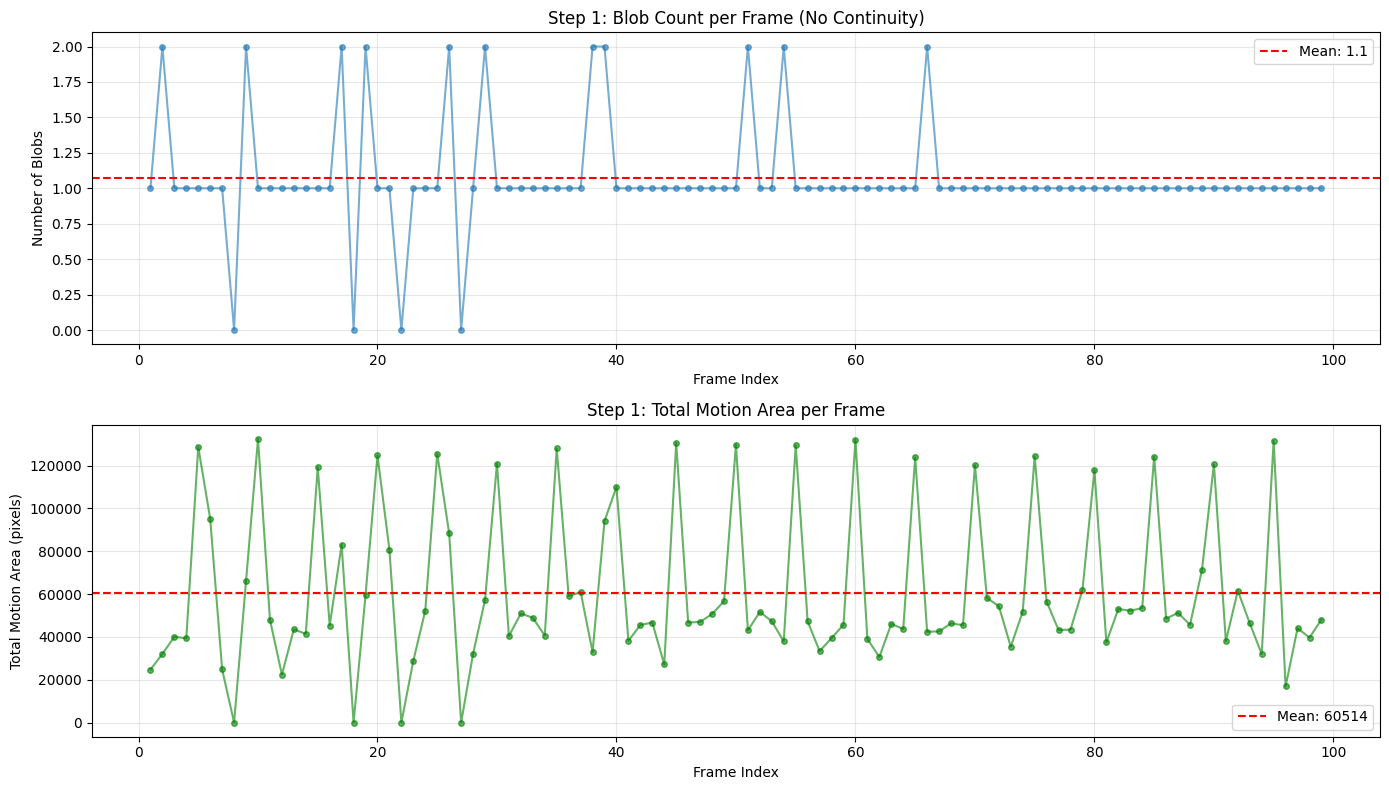

✓ Visualization complete


In [7]:
# Plot blob counts across frames

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Blob counts per frame
axes[0].plot(df['frame'], df['blob_count'], 'o-', alpha=0.6, markersize=4)
axes[0].set_xlabel('Frame Index')
axes[0].set_ylabel('Number of Blobs')
axes[0].set_title('Step 1: Blob Count per Frame (No Continuity)')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=df['blob_count'].mean(), color='r', linestyle='--', 
                label=f'Mean: {df["blob_count"].mean():.1f}')
axes[0].legend()

# Plot 2: Total motion area per frame
axes[1].plot(df['frame'], df['total_area'], 'o-', alpha=0.6, markersize=4, color='green')
axes[1].set_xlabel('Frame Index')
axes[1].set_ylabel('Total Motion Area (pixels)')
axes[1].set_title('Step 1: Total Motion Area per Frame')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=df['total_area'].mean(), color='r', linestyle='--',
                label=f'Mean: {df["total_area"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print("✓ Visualization complete")

## <font color = yellow> 7: Histogram of Blob Sizes

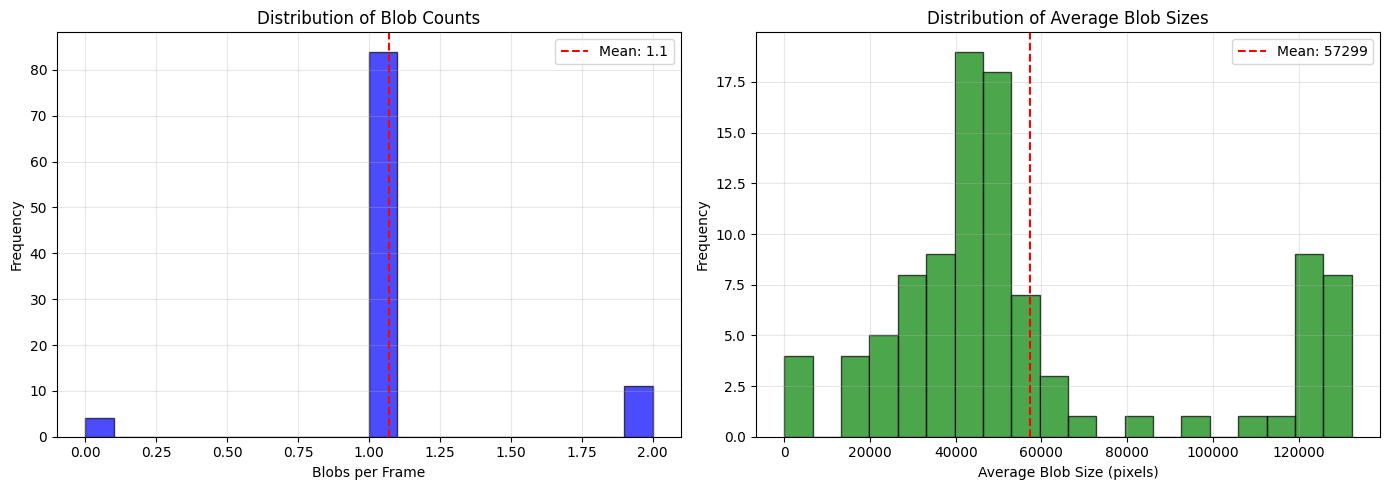

In [8]:
# Distribution analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: Blob counts
axes[0].hist(df['blob_count'], bins=20, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_xlabel('Blobs per Frame')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Blob Counts')
axes[0].axvline(x=df['blob_count'].mean(), color='r', linestyle='--', 
                label=f'Mean: {df["blob_count"].mean():.1f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram: Average blob size
axes[1].hist(df['avg_blob_size'], bins=20, alpha=0.7, color='green', edgecolor='black')
axes[1].set_xlabel('Average Blob Size (pixels)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Average Blob Sizes')
axes[1].axvline(x=df['avg_blob_size'].mean(), color='r', linestyle='--',
                label=f'Mean: {df["avg_blob_size"].mean():.0f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## <font color = yellow> 8: Visualize Sample Frames

Sample motion masks from Step 1 detection:


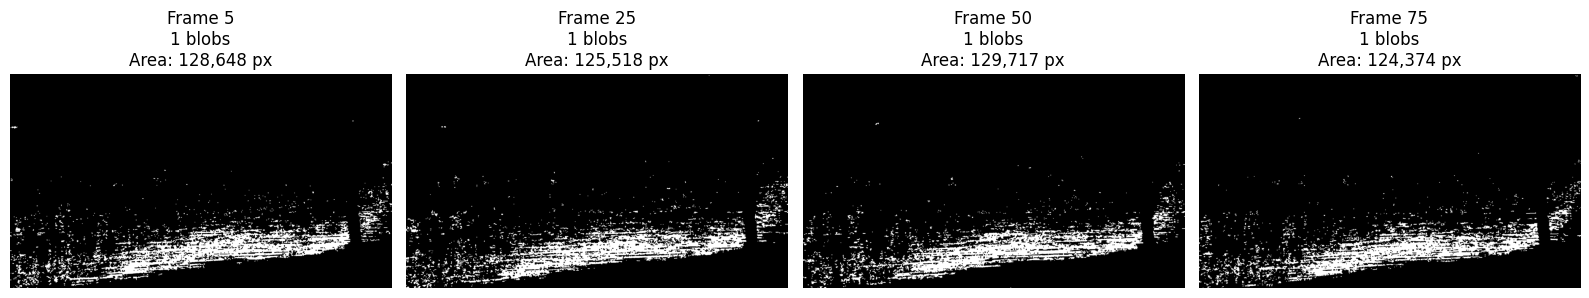

In [9]:
# Show actual motion masks for selected frames

def show_frames_with_masks(results, frame_indices=[0, 10, 20, 30]):
    """Display original detection masks for specific frames"""
    
    n_frames = len(frame_indices)
    fig, axes = plt.subplots(1, n_frames, figsize=(4*n_frames, 4))
    
    if n_frames == 1:
        axes = [axes]
    
    for idx, frame_idx in enumerate(frame_indices):
        # Find the result for this frame
        result = next((r for r in results if r['frame_index'] == frame_idx), None)
        
        if result:
            axes[idx].imshow(result['mask'], cmap='gray')
            axes[idx].set_title(f"Frame {frame_idx}\n{result['blob_count']} blobs\n"
                              f"Area: {result['total_area']:,} px")
            axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, 'No motion', ha='center', va='center')
            axes[idx].set_title(f"Frame {frame_idx}")
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Show 4 sample frames
print("Sample motion masks from Step 1 detection:")
show_frames_with_masks(results, frame_indices=[5, 25, 50, 75])

## <font color = yellow> 9: Interactive Parameter Tuning (Optional)

#### Demonstrates cv2.THRESH_BINARY ... this is a cv2 built-in fct (not used in Step 1 )

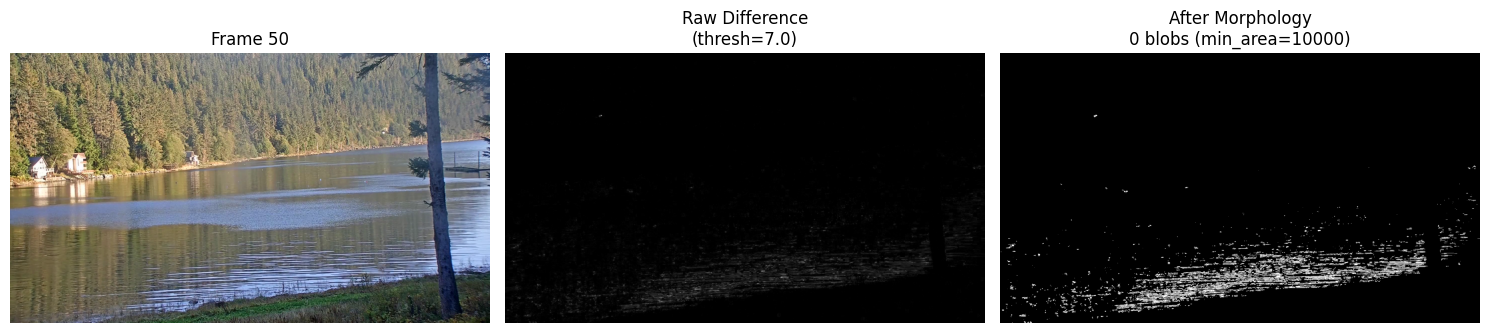

Blobs found: 0


interactive(children=(FloatSlider(value=7.0, description='Diff Thresh:', max=50.0, min=1.0, step=1.0), IntSlid…

<function __main__.interactive_step1(diff_thresh, min_area_val, frame_num)>

In [10]:
# Interactive widget for exploring different thresholds

def interactive_step1(diff_thresh, min_area_val, frame_num):
    """
    Re-run detection on a single frame pair with different parameters
    """
    # Reprocess with new parameters
    cap = cv2.VideoCapture(VIDEO_PATH)
    
    # Skip to target frame
    for _ in range(frame_num):
        cap.read()
    
    # Get two consecutive frames
    ret1, frame1 = cap.read()
    ret2, frame2 = cap.read()
    
    if not ret1 or not ret2:
        print("Could not read frames")
        cap.release()
        return
    
    # Process
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray1 = cv2.GaussianBlur(gray1, BLUR_KERNEL, 0)
    
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.GaussianBlur(gray2, BLUR_KERNEL, 0)
    
    # Difference
    diff = cv2.absdiff(gray2, gray1)
    _, mask = cv2.threshold(diff, diff_thresh, 255, cv2.THRESH_BINARY)
    
    # if USE_MORPH_OPEN:
    #     mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, None)
    # if USE_MORPH_CLOSE:
    #     mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, None)

    def interactive_step1(diff_thresh, min_area_val, frame_num, morph_size, use_open, use_close):
    # ...
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (morph_size, morph_size))
    
        if use_open:
            mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)  # Opening (erode → dilate): removes small noise, breaks thin connections.
        if use_close:
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)  # Closing (dilate → erode): fills small holes, connects nearby regions.

    
    
    # Find blobs
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid_blobs = [cnt for cnt in contours if cv2.contourArea(cnt) >= min_area_val]
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Frame {frame_num}")
    axes[0].axis('off')
    
    axes[1].imshow(diff, cmap='gray')
    axes[1].set_title(f"Raw Difference\n(thresh={diff_thresh})")
    axes[1].axis('off')
    
    axes[2].imshow(mask, cmap='gray')
    axes[2].set_title(f"After Morphology\n{len(valid_blobs)} blobs (min_area={min_area_val})")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    cap.release()
    
    print(f"Blobs found: {len(valid_blobs)}")
    if valid_blobs:
        areas = [int(cv2.contourArea(cnt)) for cnt in valid_blobs]
        print(f"Blob areas: {areas}")

# Create interactive widget
# what is step? Slider moves in widget the step increments of 1.0 (e.g., 1, 2, 3 … up to 50).

# widgets.interact(
#     interactive_step1,
#     diff_thresh=widgets.FloatSlider(value=2, min=1, max=50, step=1, description='Diff Thresh:'),  # value is diff_thresh
#     min_area_val=widgets.IntSlider(value=10000, min=100, max=50000, step=1000, description='Min Area:'),   # value is gated min_area
#     frame_num=widgets.IntSlider(value=50, min=0, max=90, step=1, description='Frame:')  # value is the frame number from video ... frame 10
# )

widgets.interact(
    interactive_step1,
    diff_thresh=widgets.FloatSlider(value=7, min=1, max=50, step=1, description='Diff Thresh:'),
    min_area_val=widgets.IntSlider(value=10000, min=100, max=50000, step=1000, description='Min Area:'),
    frame_num=widgets.IntSlider(value=50, min=0, max=90, step=1, description='Frame:'),
    morph_size=widgets.IntSlider(value=5, min=1, max=15, step=1, description='Morph Size:'),  # kernel size
    use_open=widgets.Checkbox(value=True, description='Use Open'),
    use_close=widgets.Checkbox(value=True, description='Use Close')
)

    


# Notice: min/max restrict the blob area to that range.  And notice the bright eagle detection above water shimmer.

## <font color = yellow>  10: Export Results

In [11]:
# Save results for comparison with later steps

import json

# Export to CSV
df.to_csv('step1_results.csv', index=False)
print("✓ Results saved to step1_results.csv")

# Export summary statistics
summary = {
    'step': 1,
    'description': 'Per-frame blob detection (no continuity)',
    'config': {
        'diff_threshold': DIFF_THRESHOLD,
        'min_area': MIN_AREA,
        'blur_kernel': BLUR_KERNEL
    },
    'frames_processed': len(results),
    'frames_with_motion': len(results),
    'total_blobs': int(df['blob_count'].sum()),
    'avg_blobs_per_frame': float(df['blob_count'].mean()),
    'median_blobs_per_frame': float(df['blob_count'].median()),
    'max_blobs_in_frame': int(df['blob_count'].max())
}

with open('step1_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✓ Summary saved to step1_summary.json")
print("\nStep 1 Complete!")
print("=" * 60)
print("Next: Run Step 2 to add bounding box geometry")

✓ Results saved to step1_results.csv
✓ Summary saved to step1_summary.json

Step 1 Complete!
Next: Run Step 2 to add bounding box geometry


In [12]:
stopper

NameError: name 'stopper' is not defined

## <font color = lime> Interative - all 

In [ ]:
# =================================================================================================
# INTERACTIVE WIDGET: STEP 1-2 (Detection Parameters)
# =================================================================================================

import ipywidgets as widgets
from IPython.display import display, clear_output

def interactive_step1_enhanced(diff_thresh, min_area_val, frame_num, use_roi_remove, roi_y_min):
    """
    Interactive Step 1-2: Explore detection parameters + ROI masking
    
    Parameters:
        diff_thresh: Intensity change threshold
        min_area_val: Minimum blob area (pixels)
        frame_num: Which frame to visualize
        use_roi_remove: Enable ROI masking (Step 2 feature)
        roi_y_min: Top of ROI removal zone (Y coordinate)
    """
    
    cap = cv2.VideoCapture(VIDEO_PATH)
    
    # Skip to target frame
    for _ in range(frame_num):
        cap.read()
    
    # Get two consecutive frames
    ret1, frame1 = cap.read()
    ret2, frame2 = cap.read()
    
    if not ret1 or not ret2:
        print("❌ Could not read frames")
        cap.release()
        return
    
    frame_height, frame_width = frame2.shape[:2]
    
    # Process
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray1 = cv2.GaussianBlur(gray1, (5, 5), 0)
    
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.GaussianBlur(gray2, (5, 5), 0)
    
    # Difference
    diff = cv2.absdiff(gray2, gray1)
    _, mask = cv2.threshold(diff, diff_thresh, 255, cv2.THRESH_BINARY)
    
    # ROI removal (Step 2 feature)
    if use_roi_remove:
        roi_rect = (0, roi_y_min, frame_width, frame_height)
        x1, y1, x2, y2 = roi_rect
        mask[y1:y2, x1:x2] = 0
    
    # Morphology
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, None)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, None)
    
    # Find blobs
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid_blobs = [cnt for cnt in contours if cv2.contourArea(cnt) >= min_area_val]
    
    # Compute centroids
    centroids = []
    for cnt in valid_blobs:
        M = cv2.moments(cnt)
        if M["m00"] > 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            centroids.append((cx, cy))
    
    # Visualize
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # Panel 1: Original frame
    frame_display = frame2.copy()
    if use_roi_remove:
        cv2.rectangle(frame_display, (0, roi_y_min), (frame_width, frame_height), 
                     (255, 0, 255), 3)  # Magenta ROI overlay
    axes[0].imshow(cv2.cvtColor(frame_display, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Frame {frame_num}\n{'ROI Masked' if use_roi_remove else 'No ROI Mask'}")
    axes[0].axis('off')
    
    # Panel 2: Raw difference
    axes[1].imshow(diff, cmap='gray')
    axes[1].set_title(f"Raw Difference\n(thresh={diff_thresh})")
    axes[1].axis('off')
    
    # Panel 3: After morphology + area gate
    axes[2].imshow(mask, cmap='gray')
    axes[2].set_title(f"After Morphology + Area Gate\n{len(valid_blobs)} blobs (area≥{min_area_val})")
    axes[2].axis('off')
    
    # Panel 4: Annotated frame with bboxes + centroids
    annotated = frame2.copy()
    if use_roi_remove:
        cv2.rectangle(annotated, (0, roi_y_min), (frame_width, frame_height), 
                     (255, 0, 255), 2)
    for cnt in valid_blobs:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(annotated, (x, y), (x+w, y+h), (0, 255, 0), 2)
    for (cx, cy) in centroids:
        cv2.circle(annotated, (cx, cy), 5, (255, 0, 0), -1)  # Red centroid
    
    axes[3].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[3].set_title(f"Detections\n{len(valid_blobs)} blobs, {len(centroids)} centroids")
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    cap.release()
    
    # Print stats
    print(f"📊 Detection Stats:")
    print(f"   Blobs found: {len(valid_blobs)}")
    if valid_blobs:
        areas = [int(cv2.contourArea(cnt)) for cnt in valid_blobs]
        print(f"   Blob areas: {areas}")
        print(f"   Centroids: {centroids}")
    print(f"\n🚪 Active Gates:")
    print(f"   Step 1: diff_threshold={diff_thresh}, min_area={min_area_val}")
    print(f"   Step 2: ROI masking={'ON' if use_roi_remove else 'OFF'}")


# Create interactive widget
widgets.interact(
    interactive_step1_enhanced,
    diff_thresh=widgets.FloatSlider(
        value=5, min=1, max=50, step=1, 
        description='Diff Thresh:', style={'description_width': 'initial'}
    ),
    min_area_val=widgets.IntSlider(
        value=100, min=100, max=50000, step=1000, 
        description='Min Area:', style={'description_width': 'initial'}
    ),
    frame_num=widgets.IntSlider(
        value=50, min=0, max=200, step=1, 
        description='Frame:', style={'description_width': 'initial'}
    ),
    use_roi_remove=widgets.Checkbox(
        value=True, description='Enable ROI Masking (Step 2)', 
        style={'description_width': 'initial'}
    ),
    roi_y_min=widgets.IntSlider(
        value=400, min=0, max=1080, step=50, 
        description='ROI Y-min:', style={'description_width': 'initial'}
    )
)

In [ ]:
stopper

# <font color = lime>  Step 2 - Bounding Box Geometry

#### Extract geometry for ALL blobs - create Spatial Identity

### <font color = yellow> Practical Usage:


- For every blob from Step 1:
- Compute bounding box (x, y, w, h)
- Outputs: bboxes = [(x1,y1,w1,h1), (x2,y2,w2,h2), ...]
- The spatial coordinates of the blob get defined in pixel coordinates
- No "largest blob" selection — boxes around ALL blobs


In [ ]:
"""
STEP 2: Bounding Box Geometry (Spatial Identity)
================================================
Builds on Step 1 by adding spatial provenance:
- Each blob now has coordinates (x, y, w, h)
- Enables size/position analysis
- Foundation for centroid calculation (Step 3)

Evolution from Step 1:
  Step 1: "motion exists" (blob counts only)
  Step 2: "motion has shape, size, and position" (bounding boxes)
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import display, HTML, clear_output
import pandas as pd
from typing import List, Dict, Tuple

%matplotlib inline

print("✓ Imports loaded")
print("✓ Ready for Step 2: Bounding Box Geometry")

## <font color = yellow> 2: Core Function

#### Detection Loop



In [ ]:
def run_step2_detection(video_path: str,
                        diff_threshold: float = 5,      # new: pixel intensity differences.
                        min_area: int = 10000,
                        max_frames: int = None,
                        store_frames: bool = False) -> List[Dict]:
    """
    Step 2: Detect motion blobs with bounding box geometry.
    
    Returns list of detections:
        [{
            "frame_index": int,
            "blob_count": int,
            "bboxes": [(x, y, w, h), ...],
            "frame": np.ndarray (optional if store_frames=True)
        }, ...]
    """
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")
    
    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f"Video properties:")
    print(f"  Resolution: {width}x{height}")
    print(f"  FPS: {fps:.2f}")
    print(f"  Total frames: {total_frames}")
    print(f"  Duration: {total_frames/fps:.1f}s")
    print()
    
    prev_gray = None
    frame_index = 0
    detections = []
    
    process_limit = max_frames if max_frames else total_frames

    # main frame processing loop
    while frame_index < process_limit:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Preprocess: grayscale + blur
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, BLUR_KERNEL, 0)
        
        # Initialize previous frame
        if prev_gray is None:
            prev_gray = gray
            frame_index += 1
            continue
        
        # Two-frame differencing ( same as Step 1)
        diff = cv2.absdiff(gray, prev_gray)
        _, mask = cv2.threshold(diff, diff_threshold, 255, cv2.THRESH_BINARY)
        
        # Morphological cleanup
        if USE_MORPH_OPEN:
            mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, None)
        if USE_MORPH_CLOSE:
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, None)
        
        # === STEP 2: EXTRACT BOUNDING BOXES === first step in detection (same as Step1 )
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # new logic in Step 2
        bboxes = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area >= min_area:                      # using common shared filter (steps 1-3)
                x, y, w, h = cv2.boundingRect(cnt)
                bboxes.append((x, y, w, h))
        
        # Store detection
        if bboxes:
            detection = {
                "frame_index": frame_index,
                "blob_count": len(bboxes),
                "bboxes": bboxes,
                "mask": mask
            }
            
            # Optionally store annotated frame for visualization
            if store_frames:
                annotated = frame.copy()
                for (x, y, w, h) in bboxes:
                    cv2.rectangle(annotated, (x, y), (x+w, y+h), 
                                BBOX_COLOR, BBOX_THICKNESS)
                detection["frame"] = annotated
            
            detections.append(detection)
        
        # Progress indicator
        if frame_index % 50 == 0:
            print(f"Processing frame {frame_index}/{process_limit}...", end='\r')
        
        # Update state
        prev_gray = gray
        frame_index += 1
    
    cap.release()
    print(f"\n✓ Processed {frame_index} frames")
    print(f"✓ Found motion in {len(detections)} frames")
    print(f"✓ Total bounding boxes: {sum(d['blob_count'] for d in detections)}")
    
    return detections

print("Step 2 detection function defined ✓")

## <font color = yellow> 4: Run Detection

#### Create bboxes around blobs

In [ ]:
# Run Step 2 detection
print("Running Step 2: Bounding Box Detection")
print("=" * 60)

# Process first 100 frames (adjust as needed)
results_step2 = run_step2_detection(
    VIDEO_PATH,
    diff_threshold=DIFF_THRESHOLD,
    min_area=MIN_AREA,
    max_frames=100,
    store_frames=False  # Set True if you want to visualize frames later
)

print("=" * 60)
print(f"\nStep 2 Results Summary:")
print(f"  Frames with motion: {len(results_step2)}")
print(f"  Total bounding boxes: {sum(r['blob_count'] for r in results_step2)}")
print(f"  Avg boxes/frame: {sum(r['blob_count'] for r in results_step2) / len(results_step2):.2f}")

## <font color = yellow> 5: Detailed Bounding Box Analysis

In [ ]:
# Analyze bounding box geometry

# Flatten all bboxes into a single list with metadata
bbox_data = []
for result in results_step2:
    frame_idx = result["frame_index"]
    for (x, y, w, h) in result["bboxes"]:
        bbox_data.append({
            'frame': frame_idx,
            'x': x,
            'y': y,
            'w': w,
            'h': h,
            'x1': x,
            'y1': y,
            'x2': x + w,
            'y2': y + h,
            'area': w * h,
            'aspect_ratio': w / h if h > 0 else 0,
            'perimeter': 2 * (w + h)
        })

df_bbox = pd.DataFrame(bbox_data)

print("STEP 2: BOUNDING BOX GEOMETRY ANALYSIS")
print("=" * 60)
print(f"Total bounding boxes: {len(df_bbox)}")

print(f"\nBounding Box Dimensions:")
print(f"  Width  → min: {df_bbox['w'].min()}, max: {df_bbox['w'].max()}, "
      f"mean: {df_bbox['w'].mean():.1f}")
print(f"  Height → min: {df_bbox['h'].min()}, max: {df_bbox['h'].max()}, "
      f"mean: {df_bbox['h'].mean():.1f}")

print(f"\nBounding Box Area (pixels):")
print(f"  Min: {df_bbox['area'].min():,.0f}")
print(f"  Max: {df_bbox['area'].max():,.0f}")
print(f"  Mean: {df_bbox['area'].mean():,.0f}")
print(f"  Median: {df_bbox['area'].median():,.0f}")

print(f"\nAspect Ratio (width/height):")
print(f"  Min: {df_bbox['aspect_ratio'].min():.2f}")
print(f"  Max: {df_bbox['aspect_ratio'].max():.2f}")
print(f"  Mean: {df_bbox['aspect_ratio'].mean():.2f}")

print(f"\nSpatial Position:")
print(f"  X range: {df_bbox['x'].min()} to {df_bbox['x2'].max()}")
print(f"  Y range: {df_bbox['y'].min()} to {df_bbox['y2'].max()}")

# Show first 10 bboxes
print(f"\nFirst 10 Bounding Boxes:")
print(df_bbox[['frame', 'x', 'y', 'w', 'h', 'area']].head(10).to_string(index=False))

## <font color = yellow> 6: Visualize Bounding Box Statistics

In [ ]:
# Statistical plots for bbox geometry

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Bbox area distribution
axes[0, 0].hist(df_bbox['area'], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].set_xlabel('Bounding Box Area (pixels)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Bounding Box Areas')
axes[0, 0].axvline(x=df_bbox['area'].mean(), color='r', linestyle='--',
                   label=f"Mean: {df_bbox['area'].mean():,.0f}")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Aspect ratio distribution
axes[0, 1].hist(df_bbox['aspect_ratio'], bins=30, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].set_xlabel('Aspect Ratio (width/height)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Aspect Ratios')
axes[0, 1].axvline(x=df_bbox['aspect_ratio'].mean(), color='r', linestyle='--',
                   label=f"Mean: {df_bbox['aspect_ratio'].mean():.2f}")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Width vs Height scatter
axes[1, 0].scatter(df_bbox['w'], df_bbox['h'], alpha=0.5, s=20)
axes[1, 0].set_xlabel('Width (pixels)')
axes[1, 0].set_ylabel('Height (pixels)')
axes[1, 0].set_title('Bbox Width vs Height')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Bbox area over time
frame_areas = df_bbox.groupby('frame')['area'].sum()
axes[1, 1].plot(frame_areas.index, frame_areas.values, 'o-', alpha=0.6)
axes[1, 1].set_xlabel('Frame Index')
axes[1, 1].set_ylabel('Total Motion Area (pixels)')
axes[1, 1].set_title('Total Bbox Area per Frame')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Statistical visualization complete")

## <font color = yellow> 7: Spatial Heatmap of Detections

In [ ]:
# Create a heatmap showing where detections occur in the frame

# Get video dimensions
cap = cv2.VideoCapture(VIDEO_PATH)
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
cap.release()

# Create accumulation grid (lower resolution for visualization)
grid_h, grid_w = 100, 100
heatmap = np.zeros((grid_h, grid_w), dtype=np.float32)

# Accumulate bbox centers
for _, row in df_bbox.iterrows():
    cx = (row['x'] + row['x2']) / 2
    cy = (row['y'] + row['y2']) / 2
    
    # Map to grid coordinates
    gx = int(cx / frame_width * grid_w)
    gy = int(cy / frame_height * grid_h)
    
    # Clamp to grid bounds
    gx = max(0, min(gx, grid_w - 1))
    gy = max(0, min(gy, grid_h - 1))
    
    heatmap[gy, gx] += 1

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heatmap, cmap='hot', aspect='auto', interpolation='bilinear',
               extent=[0, frame_width, frame_height, 0])
ax.set_xlabel('X Position (pixels)')
ax.set_ylabel('Y Position (pixels)')
ax.set_title('Spatial Heatmap of Detection Centroids\n(Brighter = More Detections)')
plt.colorbar(im, ax=ax, label='Detection Count')
plt.tight_layout()
plt.show()

print(f"✓ Heatmap shows detection density across {frame_width}x{frame_height} frame")

## <font color = yellow> 8: Visualize Bounding Boxes on Canvas

In [ ]:
# Recreate the matplotlib canvas visualization from original Step 2

def plot_bboxes_on_canvas(results, n_frames=15, frame_size=(1920, 1080)):
    """
    Plot bounding boxes from first N frames on a blank canvas.
    Each frame's boxes get a different color.
    """
    
    # Collect bboxes from first n_frames
    bbox_list = []
    for result in results[:n_frames]:
        frame_idx = result["frame_index"]
        for (x, y, w, h) in result["bboxes"]:
            bbox_list.append({
                'frame': frame_idx,
                'x': x,
                'y': y,
                'w': w,
                'h': h,
                'area': w * h
            })
    
    if not bbox_list:
        print("No bounding boxes to plot")
        return
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.set_xlim(0, frame_size[0])
    ax.set_ylim(frame_size[1], 0)  # Invert Y so top=0
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')
    ax.set_title(f'Bounding Boxes from First {n_frames} Frames')
    ax.set_aspect('equal')
    
    # Color palette
    colors = plt.cm.tab20.colors
    
    # Draw each bbox
    for i, bbox in enumerate(bbox_list):
        color = colors[bbox['frame'] % len(colors)]
        rect = patches.Rectangle(
            (bbox['x'], bbox['y']), bbox['w'], bbox['h'],
            linewidth=2,
            edgecolor=color,
            facecolor='none',
            label=f"F{bbox['frame']} area={bbox['area']:,}"
        )
        ax.add_patch(rect)
    
    # Legend (limit entries if too many)
    handles, labels = ax.get_legend_handles_labels()
    if len(handles) > 30:
        ax.legend(handles[:30], labels[:30], 
                 loc='center left', bbox_to_anchor=(1.02, 0.5),
                 fontsize=7, frameon=True)
    else:
        ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
                 fontsize=8, frameon=True)
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Plotted {len(bbox_list)} bounding boxes from {n_frames} frames")

# Plot first 15 frames
plot_bboxes_on_canvas(results_step2, n_frames=15)

## <font color = yellow> 9: Display Sample Frames with Bboxes

In [ ]:
# Show actual video frames with bounding boxes overlaid

def display_frames_with_bboxes(video_path, results, frame_indices=[5, 25, 50, 75]):
    """Display selected frames with bounding boxes drawn"""
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Cannot open video")
        return
    
    n_frames = len(frame_indices)
    fig, axes = plt.subplots(1, n_frames, figsize=(5*n_frames, 5))
    
    if n_frames == 1:
        axes = [axes]
    
    for idx, frame_num in enumerate(frame_indices):
        # Find result for this frame
        result = next((r for r in results if r['frame_index'] == frame_num), None)
        
        if not result:
            axes[idx].text(0.5, 0.5, f'Frame {frame_num}\nNo motion', 
                          ha='center', va='center')
            axes[idx].set_title(f"Frame {frame_num}")
            axes[idx].axis('off')
            continue
        
        # Read the frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        ret, frame = cap.read()
        
        if not ret:
            axes[idx].text(0.5, 0.5, 'Could not read frame', 
                          ha='center', va='center')
            axes[idx].axis('off')
            continue
        
        # Draw bboxes
        for (x, y, w, h) in result['bboxes']:
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 3)
        
        # Convert BGR to RGB for matplotlib
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(frame_rgb)
        axes[idx].set_title(f"Frame {frame_num}\n{result['blob_count']} boxes")
        axes[idx].axis('off')
    
    cap.release()
    plt.tight_layout()
    plt.show()

print("Displaying sample frames with bounding boxes:")
display_frames_with_bboxes(VIDEO_PATH, results_step2, frame_indices=[10, 30, 50, 70])

## <font color = yellow> 10: Compare Step 1 vs Step 2 Output

In [ ]:
# Side-by-side comparison of Step 1 (counts) vs Step 2 (geometry)

print("=" * 60)
print("COMPARISON: STEP 1 vs STEP 2")
print("=" * 60)

# Summarize both steps
print("\nStep 1 (Blob Counts Only):")
print("  - Detections: blob counts per frame")
print("  - No spatial information")
print("  - Can't distinguish objects by size/position")

print("\nStep 2 (Bounding Box Geometry):")
print("  - Detections: (x, y, w, h) for each blob")
print("  - Full spatial provenance")
print("  - Enables size/shape/position analysis")

print("\nKey Step 2 Additions:")
print("  ✓ Bounding box coordinates (x, y, w, h)")
print("  ✓ Corner points (x1, y1, x2, y2)")
print("  ✓ Area, aspect ratio, perimeter")
print("  ✓ Spatial heatmaps")
print("  ✓ Size distribution analysis")

print("\nWhat Step 2 Still Lacks:")
print("  ✗ Centroid positions (added in Step 3)")
print("  ✗ Object identity across frames")
print("  ✗ Temporal continuity/tracking")

print("\n" + "=" * 60)
print("Evolution: Step 1 (exists) → Step 2 (has geometry) → Step 3 (has anchor)")
print("=" * 60)

## <font color = yellow> 11: Export Results

In [ ]:
# Save Step 2 results for comparison with later steps

# Export detailed bbox data
df_bbox.to_csv('step2_bboxes.csv', index=False)
print("✓ Bounding box data saved to step2_bboxes.csv")

# Export summary per frame
frame_summary = []
for result in results_step2:
    frame_summary.append({
        'frame': result['frame_index'],
        'bbox_count': result['blob_count'],
        'total_area': sum(w*h for (x,y,w,h) in result['bboxes']),
        'avg_area': sum(w*h for (x,y,w,h) in result['bboxes']) / result['blob_count']
    })

df_summary = pd.DataFrame(frame_summary)
df_summary.to_csv('step2_frame_summary.csv', index=False)
print("✓ Frame summary saved to step2_frame_summary.csv")

# Export JSON summary
import json

summary = {
    'step': 2,
    'description': 'Bounding box geometry (spatial identity)',
    'config': {
        'diff_threshold': DIFF_THRESHOLD,
        'min_area': MIN_AREA,
        'blur_kernel': BLUR_KERNEL
    },
    'frames_processed': len(results_step2),
    'total_bboxes': len(df_bbox),
    'avg_bboxes_per_frame': len(df_bbox) / len(results_step2),
    'bbox_area_stats': {
        'min': int(df_bbox['area'].min()),
        'max': int(df_bbox['area'].max()),
        'mean': float(df_bbox['area'].mean()),
        'median': float(df_bbox['area'].median())
    },
    'spatial_coverage': {
        'x_range': [int(df_bbox['x'].min()), int(df_bbox['x2'].max())],
        'y_range': [int(df_bbox['y'].min()), int(df_bbox['y2'].max())]
    }
}

with open('step2_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✓ Summary saved to step2_summary.json")

print("\nStep 2 Complete!")
print("=" * 60)
print("Next: Run Step 3 to add centroid anchor points")
print("This enables temporal continuity checks in Step 4+")

In [ ]:
stopper

# <font color = lime> Step 3 - Add Centroid Anchor Points to ALL bboxes

###  This create the centroid object - create the first spatial object

#### <font color = yellow> Practical Usage:


- Add centroid to ALL bboxes for every bbox from Step 2:
- Compute centroid (cx, cy) = (x + w/2, y + h/2)
- Outputs: centroids = [(cx1,cy1), (cx2,cy2), ...]
- No filtering — centroid for EVERY blob



## <font color = yellow> 1: Imports and Setup

In [ ]:
"""
STEP 3: Centroid Anchor Points (Geometric Midpoint)
===================================================
Builds on Step 2 by adding centroid coordinates:
- Centroids = (cx, cy) = midpoint of bounding box
- Compact spatial anchor for each blob
- Foundation for nearest-neighbor matching (Step 4)
- Enables distance-based temporal continuity

Evolution Chain:
  Step 1: "motion exists" (blob counts)
  Step 2: "motion has shape/size/position" (bounding boxes)
  Step 3: "motion has a geometric anchor" (centroids)
  
Critical Insight:
  Centroids alone don't solve eagle vs. shimmer discrimination.
  They enable the continuity logic that WILL solve it (Step 4+).
  
  This is scaffolding, not solution — but essential scaffolding.
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import PatchCollection
import pandas as pd
from typing import List, Dict, Tuple
import math
import ipywidgets as widgets

%matplotlib inline

print("✓ Imports loaded")
print("✓ Ready for Step 3: Centroid Anchor Points")

## <font color = yellow> 2: Configuration

In [ ]:
# =================================================================================================
# STEP 3 CONFIGURATION
# =================================================================================================

VIDEO_PATH = r"C:\AxisRecordings\Optical_Flow\clips_evals\1010-1641-2-115-small.mkv"

# Motion sensitivity (unchanged from Steps 1-2 for fair comparison)
DIFF_THRESHOLD = 5
MIN_AREA = 10000

# Preprocessing (Step 1-3 defaults)
BLUR_KERNEL = (5, 5)
USE_MORPH_OPEN = True
USE_MORPH_CLOSE = True

# Visualization settings (all new Step 3)
BBOX_COLOR = (0, 255, 0)         # Green boxes
CENTROID_COLOR = (255, 0, 0)     # new - Red centroids (BGR: blue)
CENTROID_RADIUS = 5              # new step 3
BBOX_THICKNESS = 2               # new step 3

print(f"Configuration:")
print(f"  Video: {VIDEO_PATH}")
print(f"  Diff threshold: {DIFF_THRESHOLD}")
print(f"  Min area: {MIN_AREA}")
# print(f"  Blur kernel: {BLUR_KERNEL}")     # NA step 3
print(f"  Centroid color: {CENTROID_COLOR} (red)")   # new step 3
print(f"  Centroid radius: {CENTROID_RADIUS}px")     # new step 3

## <font color = yellow> 3: Core Function

In [ ]:
def run_step3_detection(video_path: str,
                        diff_threshold: float = 5,
                        min_area: int = 10000,
                        max_frames: int = None) -> List[Dict]:
    """
    Step 3: Detect motion blobs with bounding boxes AND centroids.
    
    Centroids are derived as the geometric midpoint of each bbox:
        cx = x + w/2
        cy = y + h/2
    
    Returns list of detections:
        [{
            "frame_index": int,
            "blob_count": int,
            "bboxes": [(x, y, w, h), ...],
            "centroids": [(cx, cy), ...]
        }, ...]
    """
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")
    
    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f"Video properties:")
    print(f"  Resolution: {width}x{height}")
    print(f"  FPS: {fps:.2f}")
    print(f"  Total frames: {total_frames}")
    print(f"  Duration: {total_frames/fps:.1f}s")
    print()
    
    prev_gray = None
    frame_index = 0
    detections = []
    
    process_limit = max_frames if max_frames else total_frames
    
    while frame_index < process_limit:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Preprocess: grayscale + blur
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, BLUR_KERNEL, 0)
        
        # Initialize previous frame
        if prev_gray is None:
            prev_gray = gray
            frame_index += 1
            continue
        
        # === STEP 1: Two-frame differencing ===
        diff = cv2.absdiff(gray, prev_gray)
        _, mask = cv2.threshold(diff, diff_threshold, 255, cv2.THRESH_BINARY)
        
        # Morphological cleanup
        if USE_MORPH_OPEN:
            mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, None)
        if USE_MORPH_CLOSE:
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, None)
        
        # === STEP 2: Extract bounding boxes ===
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        bboxes = []
        centroids = []
        
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area >= min_area:
                # Bounding box
                x, y, w, h = cv2.boundingRect(cnt)
                bboxes.append((x, y, w, h))
                
                # === STEP 3: Compute centroid ===
                cx = x + w // 2
                cy = y + h // 2
                centroids.append((cx, cy))
        
        # Store detection
        if bboxes:
            detections.append({
                "frame_index": frame_index,
                "blob_count": len(bboxes),
                "bboxes": bboxes,
                "centroids": centroids,
                "mask": mask
            })
        
        # Progress indicator
        if frame_index % 50 == 0:
            print(f"Processing frame {frame_index}/{process_limit}...", end='\r')
        
        # Update state
        prev_gray = gray
        frame_index += 1
    
    cap.release()
    print(f"\n✓ Processed {frame_index} frames")
    print(f"✓ Found motion in {len(detections)} frames")
    print(f"✓ Total centroids: {sum(d['blob_count'] for d in detections)}")
    
    return detections

print("Step 3 detection function defined ✓")

## <font color = yellow> 4: Run Detection

In [ ]:
# Run Step 3 detection
print("Running Step 3: Centroid Extraction")
print("=" * 60)

results_step3 = run_step3_detection(
    VIDEO_PATH,
    diff_threshold=DIFF_THRESHOLD,
    min_area=MIN_AREA,
    max_frames=100  # Adjust as needed
)

print("=" * 60)
print(f"\nStep 3 Results Summary:")
print(f"  Frames with motion: {len(results_step3)}")
print(f"  Total bounding boxes: {sum(r['blob_count'] for r in results_step3)}")
print(f"  Total centroids: {sum(r['blob_count'] for r in results_step3)}")
print(f"  (Note: Each bbox has exactly one centroid)")

## <font color = yellow> 5: Detailed Centroid Analysis

In [ ]:
# Analyze centroid positions and their relationship to bboxes

# Flatten all centroids with their corresponding bboxes
centroid_data = []
for result in results_step3:
    frame_idx = result["frame_index"]
    for (cx, cy), (x, y, w, h) in zip(result["centroids"], result["bboxes"]):
        centroid_data.append({
            'frame': frame_idx,
            'cx': cx,
            'cy': cy,
            'bbox_x': x,
            'bbox_y': y,
            'bbox_w': w,
            'bbox_h': h,
            'bbox_area': w * h,
            # Verify centroid calculation
            'cx_check': x + w // 2,
            'cy_check': y + h // 2,
        })

df_centroids = pd.DataFrame(centroid_data)

print("STEP 3: CENTROID ANALYSIS")
print("=" * 60)
print(f"Total centroids: {len(df_centroids)}")

print(f"\nCentroid Position Statistics:")
print(f"  X → min: {df_centroids['cx'].min()}, max: {df_centroids['cx'].max()}, "
      f"mean: {df_centroids['cx'].mean():.1f}")
print(f"  Y → min: {df_centroids['cy'].min()}, max: {df_centroids['cy'].max()}, "
      f"mean: {df_centroids['cy'].mean():.1f}")

print(f"\nCentroid-to-BBox Relationship:")
print(f"  ✓ Centroid is ALWAYS the midpoint: (x + w/2, y + h/2)")
print(f"  ✓ Verification: cx == bbox_x + bbox_w/2")
print(f"    Matches: {(df_centroids['cx'] == df_centroids['cx_check']).sum()}/{len(df_centroids)}")

print(f"\nSpatial Distribution:")
print(f"  Horizontal spread (X): {df_centroids['cx'].max() - df_centroids['cx'].min()} pixels")
print(f"  Vertical spread (Y): {df_centroids['cy'].max() - df_centroids['cy'].min()} pixels")

# Show first 10 centroids with their bboxes
print(f"\nFirst 10 Centroids:")
print(df_centroids[['frame', 'cx', 'cy', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h']].head(10).to_string(index=False))

## <font color = yellow> 6: Spatial Distribution Visualization

In [ ]:
# Visualize centroid positions across the frame

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Get video dimensions for context
cap = cv2.VideoCapture(VIDEO_PATH)
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
cap.release()

# Plot 1: Centroid scatter plot
axes[0].scatter(df_centroids['cx'], df_centroids['cy'], 
               alpha=0.5, s=20, c='red', edgecolors='black', linewidth=0.5)
axes[0].set_xlim(0, frame_width)
axes[0].set_ylim(frame_height, 0)  # Invert Y
axes[0].set_xlabel('X Position (pixels)')
axes[0].set_ylabel('Y Position (pixels)')
axes[0].set_title(f'Centroid Spatial Distribution\n({len(df_centroids)} centroids)')
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

# Plot 2: 2D histogram (density)
h = axes[1].hist2d(df_centroids['cx'], df_centroids['cy'], 
                   bins=50, cmap='hot', cmin=1)
axes[1].set_xlim(0, frame_width)
axes[1].set_ylim(frame_height, 0)
axes[1].set_xlabel('X Position (pixels)')
axes[1].set_ylabel('Y Position (pixels)')
axes[1].set_title('Centroid Density Heatmap')
plt.colorbar(h[3], ax=axes[1], label='Count')

plt.tight_layout()
plt.show()

print("✓ Spatial visualization complete")

## <font color = yellow> 7: Centroid Movement Potential Analysis

In [ ]:
# Analyze inter-frame centroid distances (preview of Step 4 continuity logic)

def compute_frame_to_frame_distances(results):
    """
    For each frame, compute minimum distance from each centroid
    to any centroid in the previous frame.
    
    This previews the continuity logic that will be used in Step 4.
    """
    
    distances = []
    
    for i in range(1, len(results)):
        curr_result = results[i]
        prev_result = results[i-1]
        
        curr_frame = curr_result['frame_index']
        curr_centroids = curr_result['centroids']
        prev_centroids = prev_result['centroids']
        
        if not prev_centroids:
            continue
        
        for (cx, cy) in curr_centroids:
            # Find nearest centroid in previous frame
            min_dist = min(
                math.sqrt((cx - px)**2 + (cy - py)**2)
                for (px, py) in prev_centroids
            )
            
            distances.append({
                'frame': curr_frame,
                'cx': cx,
                'cy': cy,
                'nearest_prev_distance': min_dist
            })
    
    return pd.DataFrame(distances)

print("Computing inter-frame centroid distances...")
df_distances = compute_frame_to_frame_distances(results_step3)

if len(df_distances) > 0:
    print("\nINTER-FRAME CENTROID DISTANCES (Step 4 Preview)")
    print("=" * 60)
    print(f"Centroids analyzed: {len(df_distances)}")
    print(f"\nDistance to Nearest Previous Centroid:")
    print(f"  Min: {df_distances['nearest_prev_distance'].min():.1f} pixels")
    print(f"  Max: {df_distances['nearest_prev_distance'].max():.1f} pixels")
    print(f"  Mean: {df_distances['nearest_prev_distance'].mean():.1f} pixels")
    print(f"  Median: {df_distances['nearest_prev_distance'].median():.1f} pixels")
    
    # Histogram of distances
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(df_distances['nearest_prev_distance'], bins=50, 
            alpha=0.7, color='blue', edgecolor='black')
    ax.set_xlabel('Distance to Nearest Previous Centroid (pixels)')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of Inter-Frame Centroid Distances\n(Preview of Step 4 Continuity Logic)')
    ax.axvline(x=df_distances['nearest_prev_distance'].median(), 
              color='r', linestyle='--', label=f"Median: {df_distances['nearest_prev_distance'].median():.1f}px")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Insight for Step 4:")
    print(f"   If we set centroid_threshold ≈ {df_distances['nearest_prev_distance'].median():.0f}px,")
    print(f"   we'll gate ~50% of detections based on temporal continuity.")
else:
    print("Not enough frames to compute distances")

## <font color = yellow>  8: Visualize Centroids on Canvas

In [ ]:
# Plot centroids and their bboxes on a blank canvas (Step 2 style + centroids)

def plot_bboxes_and_centroids(results, n_frames=15, frame_size=(1920, 1080)):
    """
    Plot bounding boxes AND centroids from first N frames.
    Shows the relationship between bbox geometry and centroid anchor points.
    """
    
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.set_xlim(0, frame_size[0])
    ax.set_ylim(frame_size[1], 0)  # Invert Y
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')
    ax.set_title(f'Bounding Boxes + Centroids (First {n_frames} Frames)')
    ax.set_aspect('equal')
    
    colors = plt.cm.tab20.colors
    
    bbox_patches = []
    centroid_x = []
    centroid_y = []
    centroid_colors = []
    
    for result in results[:n_frames]:
        frame_idx = result["frame_index"]
        color = colors[frame_idx % len(colors)]
        
        for (x, y, w, h), (cx, cy) in zip(result["bboxes"], result["centroids"]):
            # Bbox rectangle
            rect = patches.Rectangle(
                (x, y), w, h,
                linewidth=2,
                edgecolor=color,
                facecolor='none'
            )
            ax.add_patch(rect)
            
            # Centroid point
            centroid_x.append(cx)
            centroid_y.append(cy)
            centroid_colors.append(color)
    
    # Draw all centroids
    ax.scatter(centroid_x, centroid_y, 
              c=centroid_colors, s=50, marker='o', 
              edgecolors='black', linewidths=1, zorder=10,
              label='Centroids')
    
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Plotted {len(centroid_x)} bboxes + centroids from {n_frames} frames")

plot_bboxes_and_centroids(results_step3, n_frames=15)

## <font color = yellow> 9: Display Sample Frames with Centroids

In [ ]:
# Show video frames with both bboxes and centroids overlaid

def display_frames_with_centroids(video_path, results, frame_indices=[5, 25, 50, 75]):
    """Display selected frames with bounding boxes AND centroids"""
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Cannot open video")
        return
    
    n_frames = len(frame_indices)
    fig, axes = plt.subplots(1, n_frames, figsize=(5*n_frames, 5))
    
    if n_frames == 1:
        axes = [axes]
    
    for idx, frame_num in enumerate(frame_indices):
        result = next((r for r in results if r['frame_index'] == frame_num), None)
        
        if not result:
            axes[idx].text(0.5, 0.5, f'Frame {frame_num}\nNo motion', 
                          ha='center', va='center')
            axes[idx].set_title(f"Frame {frame_num}")
            axes[idx].axis('off')
            continue
        
        # Read frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        ret, frame = cap.read()
        
        if not ret:
            axes[idx].text(0.5, 0.5, 'Could not read', ha='center', va='center')
            axes[idx].axis('off')
            continue
        
        # Draw bboxes
        for (x, y, w, h) in result['bboxes']:
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        
        # Draw centroids
        for (cx, cy) in result['centroids']:
            cv2.circle(frame, (cx, cy), CENTROID_RADIUS, (255, 0, 0), -1)  # Red filled circle
            cv2.circle(frame, (cx, cy), CENTROID_RADIUS+1, (255, 255, 255), 2)  # White outline
        
        # Convert BGR to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(frame_rgb)
        axes[idx].set_title(f"Frame {frame_num}\n{result['blob_count']} objects")
        axes[idx].axis('off')
    
    cap.release()
    plt.tight_layout()
    plt.show()

print("Displaying sample frames with bboxes + centroids:")
display_frames_with_centroids(VIDEO_PATH, results_step3, frame_indices=[10, 30, 50, 70])

## <font color = yellow> 10: Three-Step Evolution Comparison

In [ ]:
# Side-by-side comparison showing evolution from Step 1 → 2 → 3

print("=" * 70)
print("EVOLUTIONARY COMPARISON: STEPS 1 → 2 → 3")
print("=" * 70)

print("\n📊 Data Structure Evolution:")
print("\nStep 1 Output:")
print("  {")
print("    'frame_index': 42,")
print("    'blob_count': 3")
print("  }")
print("  → Knows: 'motion exists' (count only)")

print("\nStep 2 Output:")
print("  {")
print("    'frame_index': 42,")
print("    'blob_count': 3,")
print("    'bboxes': [(x, y, w, h), (x, y, w, h), (x, y, w, h)]")
print("  }")
print("  → Knows: 'motion has geometry' (size, position, shape)")

print("\nStep 3 Output:")
print("  {")
print("    'frame_index': 42,")
print("    'blob_count': 3,")
print("    'bboxes': [(x, y, w, h), (x, y, w, h), (x, y, w, h)],")
print("    'centroids': [(cx, cy), (cx, cy), (cx, cy)]")
print("  }")
print("  → Knows: 'motion has anchor points' (compact spatial reference)")

print("\n🎯 Capability Matrix:")
print("\n                         Step 1  Step 2  Step 3")
print("  ──────────────────────────────────────────────")
print("  Blob counts              ✓       ✓       ✓")
print("  Spatial position         ✗       ✓       ✓")
print("  Size/shape analysis      ✗       ✓       ✓")
print("  Compact anchor           ✗       ✗       ✓")
print("  Multi-frame tracking     ✗       ✗       ✗  (Step 4+)")
print("  Object identity          ✗       ✗       ✗  (Step 4+)")

print("\n💡 Key Insight:")
print("  Centroids are DERIVED features (not new information):")
print("    cx = bbox_x + bbox_w / 2")
print("    cy = bbox_y + bbox_h / 2")
print()
print("  BUT they enable efficient nearest-neighbor matching:")
print("    distance = sqrt((cx1-cx2)² + (cy1-cy2)²)")
print()
print("  This is the bridge to temporal continuity in Step 4!")

print("\n🔜 What's Still Missing:")
print("  ✗ No object identity across frames")
print("  ✗ No temporal continuity logic")
print("  ✗ No distinction between 'shimmer' and 'eagle'")
print("  ✗ Every detection treated equally")

print("\n" + "=" * 70)
print("Evolution: Step 1 (exists) → Step 2 (geometry) → Step 3 (anchor)")
print("           → Step 4 (continuity) → Step 5 (tracks) → Step 6 (ranking)")
print("=" * 70)

## <font color = cyan> Interactive

In [ ]:
# =================================================================================================
# INTERACTIVE WIDGET: STEP 4 (Centroid Distance Continuity)
# =================================================================================================

def interactive_step4(diff_thresh, min_area_val, centroid_thresh, start_frame, n_frames):
    plt.rcParams['font.family'] = ['DejaVu Sans', 'Segoe UI Emoji']

    

   

    """
    Interactive Step 4: Explore centroid distance gating across multiple frames
    
    Parameters:
        diff_thresh: Detection sensitivity
        min_area_val: Minimum blob area
        centroid_thresh: Max distance to link centroids (Step 4 gate)
        start_frame: First frame to analyze
        n_frames: How many consecutive frames to process
    """
    
    cap = cv2.VideoCapture(VIDEO_PATH)
    
    # Skip to start frame
    for _ in range(start_frame):
        cap.read()
    
    prev_gray = None
    prev_centroids = []
    
    all_centroids = []  # Store centroids per frame
    continuity_status = []  # Store pass/fail per centroid
    
    for frame_idx in range(n_frames):
        ret, frame = cap.read()
        if not ret:
            break
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, (5, 5), 0)
        
        if prev_gray is None:
            prev_gray = gray
            continue
        
        # Detection
        diff = cv2.absdiff(gray, prev_gray)
        _, mask = cv2.threshold(diff, diff_thresh, 255, cv2.THRESH_BINARY)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, None)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, None)
        
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        centroids = []
        for cnt in contours:
            if cv2.contourArea(cnt) >= min_area_val:
                M = cv2.moments(cnt)
                if M["m00"] > 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    centroids.append((cx, cy))
        
        # Step 4: Centroid distance gate
        frame_status = []
        for (cx, cy) in centroids:
            if not prev_centroids:
                dist = float('inf')
                passes = False
            else:
                dist = min(math.hypot(cx - pcx, cy - pcy) for (pcx, pcy) in prev_centroids)
                passes = (dist <= centroid_thresh)
            
            frame_status.append(passes)
        
        all_centroids.append(centroids)
        continuity_status.append(frame_status)
        
        prev_gray = gray
        prev_centroids = centroids
    
    cap.release()
    
    # Visualize results
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Panel 1: Centroid trajectories (colored by pass/fail)
    ax1 = axes[0]
    for frame_idx, (cents, statuses) in enumerate(zip(all_centroids, continuity_status)):
        for (cx, cy), passes in zip(cents, statuses):
            color = 'green' if passes else 'red'
            marker = 'o' if passes else 'x'
            ax1.scatter(cx, cy, c=color, marker=marker, s=50, alpha=0.7)
    
    ax1.set_xlim(0, 1920)
    ax1.set_ylim(1080, 0)  # Invert Y
    ax1.set_xlabel('X (pixels)') 
    ax1.set_ylabel('Y (pixels)')
    # plt.title(r"$x \leq y$")      # Allows LaTeX rendering:
    
    
    ax1.set_title(f'Centroid Positions (Frames {start_frame}→{start_frame+n_frames})\n'
                  f'🟢 Pass (dist<={centroid_thresh}) | 🔴 Fail (dist>{centroid_thresh})')
    ax1.grid(True, alpha=0.3)
    
    # Panel 2: Pass/fail counts per frame
    ax2 = axes[1]
    frame_nums = list(range(start_frame, start_frame + len(all_centroids)))
    pass_counts = [sum(s) for s in continuity_status]
    fail_counts = [len(s) - sum(s) for s in continuity_status]
    
    ax2.bar(frame_nums, pass_counts, label='Pass (continuous)', color='green', alpha=0.7)
    ax2.bar(frame_nums, fail_counts, bottom=pass_counts, label='Fail (discontinuous)', 
            color='red', alpha=0.7)
    ax2.set_xlabel('Frame Number')
    ax2.set_ylabel('Centroid Count')
    ax2.set_title(f'Step 4: Continuity Gating\n(centroid_threshold={centroid_thresh}px)')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Stats
    total_centroids = sum(len(c) for c in all_centroids)
    total_pass = sum(sum(s) for s in continuity_status)
    
    print(f"📊 Step 4 Continuity Stats:")
    print(f"   Frames analyzed: {len(all_centroids)}")
    print(f"   Total centroids: {total_centroids}")
    print(f"   Passed gate: {total_pass} ({100*total_pass/total_centroids if total_centroids else 0:.1f}%)")
    print(f"   Failed gate: {total_centroids - total_pass}")
    print(f"\n🚪 Active Gates:")
    print(f"   Step 1: diff_threshold={diff_thresh}, min_area={min_area_val}")
    print(f"   Step 4: centroid_threshold={centroid_thresh}px")


# Widget
widgets.interact(
    interactive_step4,
    diff_thresh=widgets.FloatSlider(value=5, min=1, max=50, step=1, description='Diff Thresh:'),            # big influence ( 3 = 13, 5 = 6) 
    min_area_val=widgets.IntSlider(value=10000, min=100, max=50000, step=1000, description='Min Area:'),
    centroid_thresh=widgets.IntSlider(value=150, min=10, max=200, step=5, description='Centroid Thresh:'),   # big influence (50 = 1, 150 = 6)
    start_frame=widgets.IntSlider(value=10, min=0, max=150, step=1, description='Start Frame:'),
    n_frames=widgets.IntSlider(value=20, min=5, max=50, step=5, description='# Frames:')
)

## <font color = yellow>  11: Export Results

In [ ]:
# Save Step 3 results for comparison with Steps 4+

# Export centroid data
df_centroids.to_csv('step3_centroids.csv', index=False)
print("✓ Centroid data saved to step3_centroids.csv")

# Export distances (for Step 4 preview)
if len(df_distances) > 0:
    df_distances.to_csv('step3_inter_frame_distances.csv', index=False)
    print("✓ Inter-frame distances saved to step3_inter_frame_distances.csv")

# Export summary
import json

summary = {
    'step': 3,
    'description': 'Centroid anchor points (geometric midpoint)',
    'config': {
        'diff_threshold': DIFF_THRESHOLD,
        'min_area': MIN_AREA,
        'blur_kernel': BLUR_KERNEL
    },
    'frames_processed': len(results_step3),
    'total_centroids': len(df_centroids),
    'avg_centroids_per_frame': len(df_centroids) / len(results_step3),
    'centroid_position_stats': {
        'x_range': [int(df_centroids['cx'].min()), int(df_centroids['cx'].max())],
        'y_range': [int(df_centroids['cy'].min()), int(df_centroids['cy'].max())],
        'x_mean': float(df_centroids['cx'].mean()),
        'y_mean': float(df_centroids['cy'].mean())
    }
}

if len(df_distances) > 0:
    summary['inter_frame_distance_stats'] = {
        'min': float(df_distances['nearest_prev_distance'].min()),
        'max': float(df_distances['nearest_prev_distance'].max()),
        'mean': float(df_distances['nearest_prev_distance'].mean()),
        'median': float(df_distances['nearest_prev_distance'].median())
    }

with open('step3_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✓ Summary saved to step3_summary.json")

print("\nStep 3 Complete!")
print("=" * 60)
print("SCAFFOLDING IN PLACE ✓")
print()
print("What we have now:")
print("  ✓ Blob counts (Step 1)")
print("  ✓ Bounding box geometry (Step 2)")
print("  ✓ Centroid anchor points (Step 3)")
print()
print("What we can build next:")
print("  → Step 4: Centroid-based temporal continuity")
print("  → Step 5: Multi-frame track building")
print("  → Step 6: Track quality ranking")
print()
print("Next: Run Step 4 to add nearest-neighbor continuity gating")

In [ ]:
stopper

## <font color = lime> Step 4 - Demonstrate basic IoU - simple bbox overlap, no centroid eval

### <font color = yellow> Step 4 is simple Binary Temporal Continuity

##### Key Features of This Notebook:

- New Concepts:

1. IoU calculation and interpretation (overlap-based continuity)
2. Temporal gate (first use of previous frame state)
3. Before/after quantification (shows gate impact)

- Shortcoming of IoU:

  - Permanent drop: Yes — once overlap fails (IoU < threshold), the algorithm terminates that track. The previously kept frames are not “re‑linked” later.
  - No memory buffer: Standard IoU MD does not maintain a rolling buffer of past detections for re‑association.
  - ...


- Visual Outputs:

  - IoU distribution histogram with threshold line
  - Temporal IoU trends (per frame)
  - Pass/fail gate statistics
  - Cumulative distribution
  - Frames with color-coded bboxes (green=pass, red=fail)

- Educational Value:

  - Clear explanation of "crossing the caveman boundary"
  - Comparison with centroid distance approach
  - nterpretation guidance (aggressive/moderate/lenient gating)
  - Shows why Steps 1-3 were necessary scaffolding

## <font color = yellow> 1: Imports and Setup

In [ ]:
"""
STEP 4: IoU-Based Temporal Continuity (First Temporal Gate)
============================================================

CRITICAL EVOLUTION: This is where we EXIT the "caveman era."

Steps 1-3: Pure spatial reasoning (each frame independent)
Step 4:    Temporal reasoning (uses previous frame to gate current frame)

New Concept: Intersection over Union (IoU)
- Measures overlap between current bbox and previous frame's bboxes
- IoU = (intersection area) / (union area)
- Range: 0.0 (no overlap) to 1.0 (perfect overlap)

Continuity Logic:
  IF IoU ≥ threshold (e.g., 0.21):
    → "This blob is likely the same object as last frame" (KEEP)
  ELSE:
    → "This blob is new/noise/different" (REJECT)

This is the first gate that considers TIME, not just space.

Evolution Summary:
  Step 1-3: "Motion exists at position X"
  Step 4:   "Motion exists at position X AND persisted from last frame"


Step 4 (A or B) "Blob A in frame 10 is continuous with something in frame 9" (but we forget this by frame 11)
Step 5: "Blob A in frame 10 belongs to Track #3 which started in frame 5 and continues through frame 45"
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from typing import List, Dict, Tuple
import seaborn as sns

%matplotlib inline

# Set style for better visualizations
sns.set_style("whitegrid")

print("✓ Imports loaded")
print("✓ Ready for Step 4: IoU-Based Temporal Continuity")
print("\n🎯 KEY INSIGHT: This step introduces the FIRST temporal gate")
print("   Previous steps: spatial filtering only")
print("   This step: temporal continuity via bbox overlap")

## <font color = yellow>2: Configuration


In [ ]:
# =================================================================================================
# STEP 4 CONFIGURATION
# =================================================================================================

VIDEO_PATH = r"C:\AxisRecordings\Optical_Flow\clips_evals\1010-1641-2-115-small.mkv"

# Motion sensitivity (unchanged from Steps 1-3)
DIFF_THRESHOLD = 5
MIN_AREA = 10000

# Preprocessing (Step 1-3 defaults)
BLUR_KERNEL = (5, 5)
USE_MORPH_OPEN = True
USE_MORPH_CLOSE = True

# === NEW IN STEP 4: IoU Continuity Threshold ===
IOU_THRESHOLD = 0.21  # Minimum overlap to consider "same object"
# Typical values:
#   0.3-0.5: Standard tracking (strict continuity)
#   0.2-0.3: Lenient (allows more motion between frames)
#   0.5+:    Very strict (requires high overlap)

# Output toggles for diagnostic printing
PRINT_STEP1 = False  # Blob counts
PRINT_STEP2 = False  # Bounding boxes
PRINT_STEP3 = False  # Centroids
PRINT_STEP4 = True   # IoU values (NEW!)

print(f"Configuration:")
print(f"  Video: {VIDEO_PATH}")
print(f"  Diff threshold: {DIFF_THRESHOLD}")
print(f"  Min area: {MIN_AREA}")
print(f"\n🆕 NEW PARAMETER:")
print(f"  IoU threshold: {IOU_THRESHOLD}")
print(f"     → Blobs with IoU ≥ {IOU_THRESHOLD} are considered 'continuous'")
print(f"     → Blobs with IoU < {IOU_THRESHOLD} are rejected as new/noise")

## <font color = yellow> 3: IoU Helper Function

In [ ]:
# =================================================================================================
# IoU (Intersection over Union) Calculation
# =================================================================================================

def compute_iou(boxA: Tuple[int, int, int, int], 
                boxB: Tuple[int, int, int, int]) -> float:
    """
    Compute Intersection over Union (IoU) between two bounding boxes.
    
    Args:
        boxA, boxB: (x, y, w, h) format
        
    Returns:
        IoU value in [0.0, 1.0]
        - 0.0: No overlap
        - 1.0: Perfect overlap (same box)
        
    Visual Example:
        Frame t-1:  [====boxA====]
        Frame t:         [====boxB====]
                        ^^^^ intersection
                    [========union========]
        
        IoU = area(intersection) / area(union)
    """
    # Convert (x, y, w, h) to corner coordinates
    xA = max(boxA[0], boxB[0])  # Top-left of intersection
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0] + boxA[2], boxB[0] + boxB[2])  # Bottom-right of intersection
    yB = min(boxA[1] + boxA[3], boxB[1] + boxB[3])
    
    # Intersection dimensions
    interW = max(0, xB - xA)
    interH = max(0, yB - yA)
    interArea = interW * interH
    
    # Individual box areas
    boxAArea = boxA[2] * boxA[3]
    boxBArea = boxB[2] * boxB[3]
    
    # Union = A + B - intersection
    unionArea = boxAArea + boxBArea - interArea
    
    if unionArea == 0:
        return 0.0
    
    return interArea / unionArea


# Test the function with example boxes
print("Testing IoU calculation:")
print("─" * 50)

# Example 1: Perfect overlap
box1 = (100, 100, 50, 50)
box2 = (100, 100, 50, 50)
iou = compute_iou(box1, box2)
print(f"Same box:     IoU = {iou:.3f} (expected: 1.000)")

# Example 2: Partial overlap
box1 = (100, 100, 50, 50)
box2 = (120, 120, 50, 50)  # Shifted 20 pixels
iou = compute_iou(box1, box2)
print(f"Partial overlap: IoU = {iou:.3f}")

# Example 3: No overlap
box1 = (100, 100, 50, 50)
box2 = (200, 200, 50, 50)
iou = compute_iou(box1, box2)
print(f"No overlap:   IoU = {iou:.3f} (expected: 0.000)")

print("\n✓ IoU function ready")

## <font color = yellow> 4: Core Step 4 Detection Function

In [ ]:
def run_step4_detection(video_path: str,
                        diff_threshold: float = 5,
                        min_area: int = 10000,
                        iou_threshold: float = 0.21,
                        max_frames: int = None) -> List[Dict]:
    """
    Step 4: Detect motion with IoU-based temporal continuity.
    
    NEW LOGIC:
      For each blob in current frame:
        - Find best IoU match with any blob from previous frame
        - Store this IoU value with the detection
        - Can later filter detections by IoU ≥ threshold
    
    Returns list of detections:
        [{
            "frame_index": int,
            "blob_count": int,
            "bboxes": [(x, y, w, h), ...],
            "centroids": [(cx, cy), ...],
            "iou_matches": [float, ...]  ← NEW! Best IoU for each blob
        }, ...]
    """
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")
    
    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f"Video properties:")
    print(f"  Resolution: {width}x{height}")
    print(f"  FPS: {fps:.2f}")
    print(f"  Total frames: {total_frames}")
    print(f"  Duration: {total_frames/fps:.1f}s")
    print()
    
    prev_gray = None
    prev_bboxes = []  # ← NEW! Track previous frame's bboxes
    frame_index = 0
    detections = []
    
    process_limit = max_frames if max_frames else total_frames
    
    while frame_index < process_limit:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Preprocess
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, BLUR_KERNEL, 0)
        
        # Initialize previous frame
        if prev_gray is None:
            prev_gray = gray
            frame_index += 1
            continue
        
        # === STEPS 1-2: Two-frame differencing + bbox extraction ===
        diff = cv2.absdiff(gray, prev_gray)
        _, mask = cv2.threshold(diff, diff_threshold, 255, cv2.THRESH_BINARY)

        # morphology not included in this step
        if USE_MORPH_OPEN:
            mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, None)
        if USE_MORPH_CLOSE:
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, None)
        
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        bboxes = []
        centroids = []
        iou_matches = []  # ← NEW! Store IoU for each blob
        
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area >= min_area:
                # Bounding box
                x, y, w, h = cv2.boundingRect(cnt)
                bboxes.append((x, y, w, h))
                
                # Centroid
                cx = x + w // 2
                cy = y + h // 2
                centroids.append((cx, cy))
        
        # === STEP 4: IoU CONTINUITY CHECK ===
        for box in bboxes:
            if not prev_bboxes:
                # First frame with motion: no previous boxes to compare
                best_iou = 0.0
            else:
                # Find best IoU match with any previous frame bbox
                best_iou = max(
                    compute_iou(box, prev_box) 
                    for prev_box in prev_bboxes
                )
            
            iou_matches.append(best_iou)
        
        # Store detection
        if bboxes:
            detections.append({
                "frame_index": frame_index,
                "blob_count": len(bboxes),
                "bboxes": bboxes,
                "centroids": centroids,
                "iou_matches": iou_matches,  # ← NEW!
                "mask": mask
            })
        
        # Progress indicator
        if frame_index % 50 == 0:
            print(f"Processing frame {frame_index}/{process_limit}...", end='\r')
        
        # === UPDATE STATE FOR NEXT ITERATION ===
        prev_gray = gray
        prev_bboxes = bboxes  # ← NEW! Remember current bboxes for next frame
        frame_index += 1
    
    cap.release()
    print(f"\n✓ Processed {frame_index} frames")
    print(f"✓ Found motion in {len(detections)} frames")
    print(f"✓ Total detections: {sum(d['blob_count'] for d in detections)}")
    
    return detections

print("Step 4 detection function defined ✓")

## <font color = yellow>  5: Run Detection

In [ ]:
# Run Step 4 detection
print("Running Step 4: IoU-Based Temporal Continuity")
print("=" * 60)

results_step4 = run_step4_detection(
    VIDEO_PATH,
    diff_threshold=DIFF_THRESHOLD,
    min_area=MIN_AREA,
    iou_threshold=IOU_THRESHOLD,
    max_frames=100  # Adjust as needed
)

print("=" * 60)
print(f"\nStep 4 Results Summary:")
print(f"  Frames with motion: {len(results_step4)}")
print(f"  Total detections (before IoU gate): {sum(r['blob_count'] for r in results_step4)}")

# Count detections that pass IoU threshold
detections_after_iou = sum(
    sum(1 for iou in r['iou_matches'] if iou >= IOU_THRESHOLD)
    for r in results_step4
)
print(f"  Detections after IoU gate (≥{IOU_THRESHOLD}): {detections_after_iou}")

## <font color = yellow> 6: Analyze IoU Distribution

In [ ]:
# Analyze the distribution of IoU values

# Flatten all IoU values
iou_data = []
for result in results_step4:
    frame_idx = result["frame_index"]
    for iou, (cx, cy), (x, y, w, h) in zip(
        result["iou_matches"], 
        result["centroids"], 
        result["bboxes"]
    ):
        iou_data.append({
            'frame': frame_idx,
            'iou': iou,
            'cx': cx,
            'cy': cy,
            'bbox_x': x,
            'bbox_y': y,
            'bbox_w': w,
            'bbox_h': h,
            'bbox_area': w * h,
            'passes_gate': iou >= IOU_THRESHOLD
        })

df_iou = pd.DataFrame(iou_data)

print("STEP 4: IoU CONTINUITY ANALYSIS")
print("=" * 60)
print(f"Total detections: {len(df_iou)}")

print(f"\nIoU Statistics:")
print(f"  Min:    {df_iou['iou'].min():.3f}")
print(f"  Max:    {df_iou['iou'].max():.3f}")
print(f"  Mean:   {df_iou['iou'].mean():.3f}")
print(f"  Median: {df_iou['iou'].median():.3f}")
print(f"  Std:    {df_iou['iou'].std():.3f}")

print(f"\nContinuity Gate Results (threshold = {IOU_THRESHOLD}):")
print(f"  Passed:  {df_iou['passes_gate'].sum()} detections ({100*df_iou['passes_gate'].mean():.1f}%)")
print(f"  Failed:  {(~df_iou['passes_gate']).sum()} detections ({100*(~df_iou['passes_gate']).mean():.1f}%)")

# Show first 10 detections
print(f"\nFirst 10 Detections with IoU:")
print(df_iou[['frame', 'cx', 'cy', 'iou', 'passes_gate']].head(10).to_string(index=False))

## <font color = yellow> 7: Visualize IoU Distribution

In [ ]:
# Plot IoU distribution and gate impact

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: IoU histogram with threshold line
axes[0, 0].hist(df_iou['iou'], bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].axvline(x=IOU_THRESHOLD, color='red', linestyle='--', linewidth=2,
                   label=f'Threshold = {IOU_THRESHOLD}')
axes[0, 0].axvline(x=df_iou['iou'].mean(), color='green', linestyle='--',
                   label=f"Mean = {df_iou['iou'].mean():.3f}")
axes[0, 0].set_xlabel('IoU Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of IoU Values\n(Temporal Continuity Metric)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: IoU over time (per frame)
frame_iou_mean = df_iou.groupby('frame')['iou'].mean()
axes[0, 1].plot(frame_iou_mean.index, frame_iou_mean.values, 'o-', alpha=0.6)
axes[0, 1].axhline(y=IOU_THRESHOLD, color='red', linestyle='--', 
                   label=f'Threshold = {IOU_THRESHOLD}')
axes[0, 1].set_xlabel('Frame Index')
axes[0, 1].set_ylabel('Mean IoU')
axes[0, 1].set_title('Average IoU per Frame')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Pass/Fail counts
pass_fail_counts = df_iou['passes_gate'].value_counts()
axes[1, 0].bar(['Failed\n(IoU < threshold)', 'Passed\n(IoU ≥ threshold)'], 
               [pass_fail_counts.get(False, 0), pass_fail_counts.get(True, 0)],
               color=['red', 'green'], alpha=0.7, edgecolor='black')
axes[1, 0].set_ylabel('Number of Detections')
axes[1, 0].set_title(f'IoU Gate Impact (threshold = {IOU_THRESHOLD})')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Cumulative distribution
sorted_iou = np.sort(df_iou['iou'].values)
cumulative = np.arange(1, len(sorted_iou) + 1) / len(sorted_iou)
axes[1, 1].plot(sorted_iou, cumulative, linewidth=2)
axes[1, 1].axvline(x=IOU_THRESHOLD, color='red', linestyle='--',
                   label=f'Threshold = {IOU_THRESHOLD}')
# Mark the percentage below threshold
pct_below = (df_iou['iou'] < IOU_THRESHOLD).mean()
axes[1, 1].axhline(y=pct_below, color='red', linestyle=':', alpha=0.5)
axes[1, 1].set_xlabel('IoU Value')
axes[1, 1].set_ylabel('Cumulative Fraction')
axes[1, 1].set_title(f'Cumulative IoU Distribution\n{pct_below*100:.1f}% below threshold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ IoU distribution visualization complete")

## <font color = yellow> 8: Before/After Quantification

In [ ]:
# Quantify the impact of the IoU gate

print("\n" + "=" * 70)
print("QUANTIFICATION: BEFORE vs AFTER IoU GATE")
print("=" * 70)

# BEFORE gate (all detections)
objects_before = len(df_iou)
frames_before = df_iou['frame'].nunique()

# AFTER gate (only IoU ≥ threshold)
objects_after = df_iou['passes_gate'].sum()
frames_after = df_iou[df_iou['passes_gate']]['frame'].nunique()

print(f"\nDetections:")
print(f"  BEFORE IoU gate: {objects_before}")
print(f"  AFTER IoU gate:  {objects_after}")
print(f"  Reduction:       {objects_before - objects_after} ({100*(1-objects_after/objects_before):.1f}%)")

print(f"\nFrames with motion:")
print(f"  BEFORE IoU gate: {frames_before}")
print(f"  AFTER IoU gate:  {frames_after}")
print(f"  Reduction:       {frames_before - frames_after} ({100*(1-frames_after/frames_before):.1f}%)")

print(f"\nAverage detections per frame:")
print(f"  BEFORE: {objects_before/frames_before:.2f}")
print(f"  AFTER:  {objects_after/frames_after:.2f}" if frames_after > 0 else "  AFTER:  N/A (no frames)")

print("\n💡 Interpretation:")
if objects_after < 0.5 * objects_before:
    print("   ✓ IoU gate is AGGRESSIVE: filtering >50% of detections")
    print("   → Good for high-confidence tracking, may miss intermittent objects")
elif objects_after < 0.8 * objects_before:
    print("   ✓ IoU gate is MODERATE: filtering 20-50% of detections")
    print("   → weak approach, missing some features, Step 4 is only demonstrating Binary Temporal Continuity")
else:
    print("   ⚠ IoU gate is LENIENT: filtering <20% of detections")
    print("   → May allow flickering/noise through, consider raising threshold")

print("=" * 70)

## <font color = yellow> 9: Compare with Step 3 (Centroid-Only Baseline)

In [ ]:
# Optional: Show how IoU differs from centroid distance

print("\n" + "=" * 70)
print("COMPARISON: IoU (Step 4) vs Centroid Distance (Step 3 baseline)")
print("=" * 70)

print("\nIoU (Intersection over Union):")
print("  ✓ Measures SPATIAL OVERLAP of bounding boxes")
print("  ✓ Robust to object size changes")
print("  ✓ Handles rotation/deformation better")
print("  ✓ Range: [0, 1] (normalized)")
print("  Example: Fast-moving small object can have low IoU even if same object")

print("\nCentroid Distance (Step 3 approach):")
print("  ✓ Measures POINT-TO-POINT distance")
print("  ✗ Ignores object size/shape")
print("  ✗ Sensitive to centroid jitter")
print("  ✗ Not normalized (depends on image resolution)")
print("  Example: Large object slightly shifted has large centroid distance")

print("\n🎯 When to use each:")
print("  IoU:       Objects with stable shape/size, modest motion")
print("  Centroid:  Fast-moving objects, size changes, computational efficiency")
print("  Both:      Hybrid approaches (Step 4+ in your full pipeline)")

print("=" * 70)

## <font color = yellow>  10: Visualize Sample Detections

In [ ]:
# Show frames with IoU values annotated

def display_frames_with_iou(video_path, results, frame_indices=[10, 30, 50, 70]):
    """Display frames with bboxes colored by IoU value"""
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Cannot open video")
        return
    
    n_frames = len(frame_indices)
    fig, axes = plt.subplots(1, n_frames, figsize=(5*n_frames, 5))
    
    if n_frames == 1:
        axes = [axes]
    
    for idx, frame_num in enumerate(frame_indices):
        result = next((r for r in results if r['frame_index'] == frame_num), None)
        
        if not result:
            axes[idx].text(0.5, 0.5, f'Frame {frame_num}\nNo motion',
                          ha='center', va='center')
            axes[idx].set_title(f"Frame {frame_num}")
            axes[idx].axis('off')
            continue
        
        # Read frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        ret, frame = cap.read()
        
        if not ret:
            axes[idx].text(0.5, 0.5, 'Could not read', ha='center', va='center')
            axes[idx].axis('off')
            continue
        
        # Draw bboxes with color based on IoU
        for (x, y, w, h), iou in zip(result['bboxes'], result['iou_matches']):
            # Color: green if passes, red if fails
            color = (0, 255, 0) if iou >= IOU_THRESHOLD else (0, 0, 255)
            cv2.rectangle(frame, (x, y), (x+w, y+h), color, 3)
            
            # Label with IoU value
            label = f"IoU={iou:.2f}"
            cv2.putText(frame, label, (x, y-10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        
        # Convert to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(frame_rgb)
        axes[idx].set_title(f"Frame {frame_num}\n{result['blob_count']} detections")
        axes[idx].axis('off')
    
    cap.release()
    plt.tight_layout()
    plt.show()
    
    print("Legend: 🟢 Green = IoU ≥ threshold (PASS), 🔴 Red = IoU < threshold (FAIL)")

print("Displaying frames with IoU-based gating:")
display_frames_with_iou(VIDEO_PATH, results_step4, frame_indices=[15, 35, 55, 75])

## <font color = yellow> 11: Export Results

In [ ]:
# Save Step 4 results

# Export IoU data
df_iou.to_csv('step4_iou_data.csv', index=False)
print("✓ IoU data saved to step4_iou_data.csv")

# Export summary
import json

summary = {
    'step': 4,
    'description': 'IoU-based temporal continuity (first temporal gate)',
    'config': {
        'diff_threshold': DIFF_THRESHOLD,
        'min_area': MIN_AREA,
        'iou_threshold': IOU_THRESHOLD,
        'blur_kernel': BLUR_KERNEL
    },
    'frames_processed': len(results_step4),
    'total_detections_before_gate': len(df_iou),
    'total_detections_after_gate': int(df_iou['passes_gate'].sum()),
    'frames_before_gate': int(df_iou['frame'].nunique()),
    'frames_after_gate': int(df_iou[df_iou['passes_gate']]['frame'].nunique()),
    'gate_efficiency': float(df_iou['passes_gate'].mean()),
    'iou_stats': {
        'min': float(df_iou['iou'].min()),
        'max': float(df_iou['iou'].max()),
        'mean': float(df_iou['iou'].mean()),
        'median': float(df_iou['iou'].median()),
        'std': float(df_iou['iou'].std())
    }
}

with open('step4_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✓ Summary saved to step4_summary.json")

print("\nStep 4 Complete!")
print("=" * 60)
print("🎉 CROSSED THE CAVEMAN BOUNDARY!")
print("\nWhat changed:")
print("  ✓ First use of TEMPORAL information (previous frame state)")
print("  ✓ IoU gate filters detections based on continuity")
print("  ✓ Can now distinguish 'persistent motion' from 'flicker'")
print("\nWhat's still missing:")
print("  → Multi-frame tracks (Step 5)")
print("  → Object identity across >2 frames")
print("  → Advanced temporal gates (displacement, trajectory)")
print("\nNext: Run Step 5 for full track-based analysis")

In [ ]:
stopper

## <font color = yellow>

# <font color = lime> Step 4B: Centroid Distance with Parameter Sweep & ROI Masking

#### Critical Comparison: Step 4A (IoU) vs Step 4B (Centroid Distance) - both are simple Binary Temporal Continuity

#### Step 4B has NO IoU logic at all, both lack build segmentation/tracking (no history)


Before converting, let's understand why there are two Step 4 versions (both: 

- Step 4A (IoU-Based) - Previous Notebook

  - Continuity metric: Bounding box overlap (IoU)
  - Philosophy: "Same object = overlapping bounding boxes"
  - Strength: Robust to size changes, handles deformation
  - Weakness: Requires boxes to overlap (fails for fast motion), missing features, is simple Binary Temporal Continuity
  - Use case: Objects with stable size/shape, modest inter-frame motion
  - ...

- Step 4B (Centroid Distance) - This Notebook

  - Continuity metric: Point-to-point distance between centroids
  - Philosophy: "Same object = nearby centroid positions
  - Strength: Handles fast motion, computationally efficient
  - Weakness: Ignores size/shape, sensitive to jitter -  missing features, is simple Binary Temporal Continuity
  - Use case: Fast-moving objects, computational efficiency priority
  - ...



Additional Differences
| Feature              | Step 4A (IoU)                  | Step 4B (Centroid Distance)       |
|----------------------|--------------------------------|-----------------------------------|
| Continuity check     | Box overlap area               | Point distance                    |
| Metric range         | [0.0, 1.0] (normalized)        | [0, ∞] pixels (absolute)          |
| Parameter sweep      | Single IoU threshold           | Multi-dimensional sweep           |
| ROI masking          | No                             | Yes (removes shimmer band)        |
| Scoring/optimization | No                             | Yes (TAU-based scoring)           |
| Video annotation     | Basic                          | Advanced (HUD, color-coded)       |
| CSV export           | No                             | Yes                               |

##### Key insight: Step 4B is demos some production-like sweep features, while Step 4A is pedagogical (single config demonstration). 
##### <font color = yellow> Both are limited use - no segmentation/history/tracking.  Only two frame comprehension.  Only 2 frame continuous temporal MD.



In [ ]:
stopper

## <font color = yellow> 1: Imports and Setup

In [ ]:
"""
STEP 4B: Centroid Distance Continuity + Parameter Sweep + ROI Masking
======================================================================
Alternative to Step 4A (IoU): Uses centroid nearest-neighbor distance
for temporal continuity instead of bounding box overlap.

Why Centroid Distance Instead of IoU?
--------------------------------------
IoU (Step 4A):
  ✓ Robust to size changes
  ✓ Handles shape deformation
  ✗ Fails for fast inter-frame motion (boxes don't overlap)
  ✗ Computationally expensive (O(n²) overlap calculations)

Centroid Distance (Step 4B):
  ✓ Handles fast motion (no overlap required)
  ✓ Computationally efficient (simple Euclidean distance)
  ✓ Intuitive threshold (pixels, not abstract IoU ratio)
  ✗ Ignores size/shape information
  ✗ Sensitive to centroid jitter

NEW FEATURES IN STEP 4B:
1. Multi-dimensional parameter sweep (diff_threshold × min_area × centroid_threshold)
2. ROI masking (remove shimmer/reflection zones before detection)
3. TAU-based scoring (optimize for target objects-per-frame)
4. CSV export for audit trail
5. Annotated video output with HUD overlay

Evolution Context:
  Step 4A: Pedagogical demonstration of IoU continuity
  Step 4B: Production-ready optimization framework
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math
import csv
import os
from typing import List, Tuple, Dict, Any
from itertools import product

%matplotlib inline
sns.set_style("whitegrid")

print("✓ Imports loaded")
print("✓ Ready for Step 4B: Centroid Distance + Parameter Sweep")
print("\n🔬 This version includes:")
print("   • Multi-dimensional parameter optimization")
print("   • ROI masking (remove water shimmer zones)")
print("   • TAU-based scoring (target objects/frame)")
print("   • CSV export and annotated video output")
print("   • No segmentation. Only simple Binary Temporal Continuity)")


## <font color = yellow> 2: Configuration

#### <font color = lime> This is a ranging gate system ensures that centroid jumps are only accepted if they fall within defined tolerances.

In [ ]:
# =================================================================================================
# STEP 4B CONFIGURATION
# =================================================================================================

VIDEO_PATH = r"C:\AxisRecordings\Optical_Flow\clips_evals\1010-1641-2-115-small.mkv"

# === PARAMETER SWEEP RANGES ===
# We'll test multiple combinations to find optimal settings

# Gate 1a: Intensity difference threshold
diff_threshold_values = [2.5, 3.0]  # Start with 2 values for quick test

# Gate 1b: Minimum blob area
min_area_values = [65, 200]  # Smaller values = more sensitive

# Gate 2: Centroid distance threshold (pixels)
centroid_thresholds = [40, 130]  # Distance to consider "same object"

# Total combinations: 2 × 2 × 2 = 8 configs to test

# === TAU: TARGET OBJECTS PER FRAME ===
# This is your "ideal" tracking scenario
# TAU = 1.0 → exactly one eagle per frame
# TAU = 1.5 → allow occasional multi-detection
# TAU = 0.8 → conservative (expect some missed detections)
TAU = 1.100

# === SCORING WEIGHTS ===
L1 = 0.7   # Weight for precision (matching TAU)
L2 = 0.3   # Weight for parsimony (prefer lower thresholds)
C_MAX = 300  # Normalization constant for centroid threshold
MIN_COVERAGE = 0.6  # Minimum fraction of frames that must survive gating (Not IoU - no spatial overlap)

# === ROI MASKING (NEW!) ===
USE_ROI_REMOVE = True  # Enable ROI removal
ROI_REMOVE_RECT = (0, 400, 1900, 1080)  # (x1, y1, x2, y2) - bottom shimmer band
# Example: (0, 700, 1920, 1080) = remove bottom 380 pixels (water shimmer)

# === OUTPUT CONTROLS ===
EXPORT_CSV = True
ENABLE_VIDEO_OUTPUT = True
DISPLAY_WINDOWS = False  # Set True for live preview (slower)
VIDEO_OUTPUT_PATH = "step4b_annotated_best_combo.mp4"
OUTPUT_FPS_OVERRIDE = None  # None = inherit from source

# Preprocessing (unchanged from Steps 1-3)
BLUR_KERNEL = (5, 5)
USE_MORPH_OPEN = True
USE_MORPH_CLOSE = True

print(f"Configuration:")
print(f"  Video: {VIDEO_PATH}")
print(f"\n📊 Parameter Sweep:")
print(f"  diff_threshold: {diff_threshold_values}")
print(f"  min_area: {min_area_values}")
print(f"  centroid_threshold: {centroid_thresholds}")
print(f"  Total combinations: {len(diff_threshold_values) * len(min_area_values) * len(centroid_thresholds)}")
print(f"\n🎯 Optimization Target:")
print(f"  TAU (objects/frame): {TAU}")
print(f"  Min coverage: {MIN_COVERAGE}")
print(f"\n🚫 ROI Masking:")
print(f"  Enabled: {USE_ROI_REMOVE}")
if USE_ROI_REMOVE:
    print(f"  Region: {ROI_REMOVE_RECT} (x1, y1, x2, y2)")

## <font color = yellow> 3: Core Detection Function

#### <font color = lime> Create centroid in center of bboxes > min_area, 

            How it works:

            The centroid distance calculation:

            For each centroid in the current frame (for (cx, cy) in centroids:), the algorithm compares it 
            against all centroids from the previous frame (prev_centroids).

            It computes the Euclidean distance: (see formula)
            
            It then takes the minimum distance — i.e., the nearest previous centroid.
            
            Special case: first frame:
            If there are no previous centroids (if not prev_centroids:), 
            the distance is set to ∞ (infinite), meaning there’s no match yet.



area = cv2.contourArea(cnt)  - integrates over the contour to count the pixels inside.

With contours: you have a closed boundary, so you can measure:

- Area → pixel footprint (cv2.contourArea).
- Perimeter → contour length (cv2.arcLength).
- Centroid → geometric center (cv2.moments).
- Bounding box → enclosing rectangle (cv2.boundingRect).

In [ ]:
# =================================================================================================
# Step 4B DETECTION WITH CENTROID DISTANCE TRACKING
# =================================================================================================

def run_detection(video_path: str,
                  diff_threshold: float,
                  min_area: int,
                  render_frames: bool = False) -> List[Dict[str, Any]]:
    """
    Run detection with centroid distance tracking.
    
    For each blob in current frame:
      - Find nearest centroid from previous frame
      - Store this distance (will gate by threshold later)
    
    Args:
        video_path: Input video
        diff_threshold: Gate 1a (intensity change)
        min_area: Gate 1b (blob size)
        render_frames: If True, store frames for video output
        
    Returns:
        List of detection dicts with 'dist_matches' (nearest prev centroid distance)
    """
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")
    
    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    if not render_frames:
        print(f"  Processing {width}x{height} @ {fps:.1f}fps ({total_frames} frames)...")
    
    prev_gray = None
    prev_centroids: List[Tuple[int, int]] = []  #  New: create a list of previous frame centroids
    frame_index = 0
    detections: List[Dict[str, Any]] = []
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Preprocess
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, BLUR_KERNEL, 0)
        
        # Initialize
        if prev_gray is None:
            prev_gray = gray
            frame_index += 1
            continue
        
        # === STEP 1: Two-frame differencing ===
        diff = cv2.absdiff(gray, prev_gray)
        _, mask = cv2.threshold(diff, diff_threshold, 255, cv2.THRESH_BINARY)
        
        # === ROI MASKING (NEW!) ===
        if USE_ROI_REMOVE:
            x1, y1, x2, y2 = ROI_REMOVE_RECT
            h, w = mask.shape[:2]
            # Clamp to frame bounds
            x1 = max(0, min(x1, w))
            x2 = max(0, min(x2, w))
            y1 = max(0, min(y1, h))
            y2 = max(0, min(y2, h))
            if x2 > x1 and y2 > y1:
                mask[y1:y2, x1:x2] = 0  # Zero out ROI region
        
        # Morphology (not used or developed here)
        if USE_MORPH_OPEN:
            mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, None)
        if USE_MORPH_CLOSE:
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, None)
        
        # === STEP 2: Bounding boxes + centroids ===
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        bboxes: List[Tuple[int, int, int, int]] = []
        centroids: List[Tuple[int, int]] = []
        dist_matches: List[float] = []

        # The centroid here is the geometric center of the rectangle
        for cnt in contours:
            area = cv2.contourArea(cnt)   # creates area of blob / cnt - a list of points describing the boundary of a blob.
            if area >= min_area:                      
                x, y, w, h = cv2.boundingRect(cnt)  # creates the bbox (top left x,y) & Bottom‑right corner at (x + w, y + h).
                bboxes.append((x, y, w, h))
                
                cx = x + w // 2               # This computes the horizontal midpoint of the rectangle.
                cy = y + h // 2                # This computes the vertical midpoint of the rectangle.
                centroids.append((cx, cy))    #  Stores the center of the rectangle - centroid (pixel) coordinates to list
        
        # === STEP 4B: CENTROID DISTANCE TO PREVIOUS FRAME ===
        for (cx, cy) in centroids:
            if not prev_centroids:
                # First frame with motion: infinite distance
                best_dist = float("inf")
            else:
                # Find nearest centroid from previous frame
                best_dist = min(
                    math.hypot(cx - pcx, cy - pcy)
                    for (pcx, pcy) in prev_centroids
                )
            dist_matches.append(best_dist)          # add centroid distance to list
        
        # Store detection
        if bboxes:
            detections.append({
                "frame_index": frame_index,
                "frame": frame if render_frames else None,
                "bboxes": bboxes,
                "centroids": centroids,
                "dist_matches": dist_matches  # ← Key field for Step 4B
            })
        
        # Update state
        prev_gray = gray
        prev_centroids = centroids
        frame_index += 1
    
    cap.release()
    
    if not render_frames:
        print(f"  ✓ Detected motion in {len(detections)} frames")
    
    return detections

print("Detection function defined ✓")

## <font color = yellow> 4: Quantification Function

#### <font color = lime> Explicitly gating centroid distances so that only “reasonable” matches survive.

In [ ]:
# =================================================================================================
# Step 4B QUANTIFY: Before/After Gate2 (Centroid Distance Threshold)
# =================================================================================================

def quantify(results: List[Dict[str, Any]], 
             centroid_dist_threshold: float) -> Tuple[int, int, int, int]:
    """
    Count objects and frames before/after centroid distance gating.
    
    Args:
        results: Detection results from run_detection()
        centroid_dist_threshold: Max distance to consider "same object"
        
    Returns:
        (objects_before, objects_after, frames_before, frames_after)
    """
    
    # BEFORE gate: all detections
    objects_before = sum(len(entry["bboxes"]) for entry in results)
    frames_before = len(results)
    
    # AFTER gate: only detections with dist ≤ threshold
    objects_after = sum(
        sum(1 for d in entry["dist_matches"] if d <= centroid_dist_threshold)
        for entry in results
    )
    
    frames_after = sum(
        1 for entry in results 
        if any(d <= centroid_dist_threshold for d in entry["dist_matches"])
    )
    
    return objects_before, objects_after, frames_before, frames_after

print("Quantification function defined ✓")

## <font color = yellow> 5: Run Parameters Sweep

#### <font color = lime> Evaluate the centroid_thresholds = [40, 130], values against the gate range values for (diff_threshold and min_area)

##### Definitions:

                    # Gate 1a: Intensity difference threshold
                    diff_threshold_values = [2.5, 3.0]  # Start with 2 values for quick test

                    # Gate 1b: Minimum blob area
                    min_area_values = [65, 200]  # Smaller values = more sensitive
                    
                    # Gate 2: Centroid distance threshold (pixels)
                    centroid_thresholds = [40, 130]  # Distance to consider "same object"

In [ ]:
# =================================================================================================
# Step 4B PARAMETER SWEEP: Test all combinations
# =================================================================================================

def run_sweep() -> Dict[Tuple[float, int], Dict[str, Any]]:
    """
    Run detection for each (diff_threshold, min_area) pair,
    then apply all centroid_thresholds to quantify survivors.
    
    Returns:
        results_grid: {(diff_t, min_a): {"objects": [...], "frames": [...], "before": (...)}}
    """
    
    results_grid: Dict[Tuple[float, int], Dict[str, Any]] = {}
    csv_rows = []
    
    n_configs = len(diff_threshold_values) * len(min_area_values)
    config_idx = 0
    
    print(f"\n🔄 Running parameter sweep...")
    print(f"   Configurations to test: {n_configs}")
    print(f"   Centroid thresholds per config: {len(centroid_thresholds)}")
    print("=" * 60)
    
    for diff_t in diff_threshold_values:
        for min_a in min_area_values:
            config_idx += 1
            print(f"\n[{config_idx}/{n_configs}] diff={diff_t}, min_area={min_a}")
            
            # Run detection ONCE for this Gate1 config
            detections = run_detection(VIDEO_PATH, diff_t, min_a, render_frames=False)
            
            objs_before = sum(len(e["bboxes"]) for e in detections)
            frs_before = len(detections)
            
            objects_after_list: List[int] = []
            frames_after_list: List[int] = []
            
            # Apply all centroid thresholds (Gate2)
            for c_thresh in centroid_thresholds:
                obj_bef, obj_aft, frm_bef, frm_aft = quantify(detections, c_thresh)
                
                objects_after_list.append(obj_aft)
                frames_after_list.append(frm_aft)
                
                # CSV audit row
                csv_rows.append({
                    "diff_threshold": diff_t,
                    "min_area": min_a,
                    "centroid_dist_threshold": c_thresh,
                    "objects_before": obj_bef,
                    "objects_after": obj_aft,
                    "frames_before": frm_bef,
                    "frames_after": frm_aft,
                    "use_roi_remove": USE_ROI_REMOVE,
                    "roi_rect": str(ROI_REMOVE_RECT)
                })
            
            # Store results
            results_grid[(diff_t, min_a)] = {
                "objects": objects_after_list,
                "frames": frames_after_list,
                "before": (objs_before, frs_before)
            }
            
            print(f"   Before gate: {objs_before} objects, {frs_before} frames")
    
    # Export CSV
    if EXPORT_CSV:
        with open("step4b_sweep_results.csv", "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=[
                "diff_threshold", "min_area", "centroid_dist_threshold",
                "objects_before", "objects_after", "frames_before", "frames_after",
                "use_roi_remove", "roi_rect"
            ])
            writer.writeheader()
            writer.writerows(csv_rows)
        print("\n✓ Sweep results exported to step4b_sweep_results.csv")
    
    return results_grid

# Run the sweep
print("Starting parameter sweep...")
sweep_results = run_sweep()
print("\n✓ Parameter sweep complete!")

## <font color = yellow> 6: Score and Rank Candidates


#### <font color = lime> Evaluate the "best" from the candidates => 5. parameters sweep results to TAU 


###### Note: internal gate in this step (coverage < MIN_COVERAGE,  if not (0.8 <= obj_per_frame <= 3.0): )

In [ ]:
# =================================================================================================
# Step 4B SCORING: TAU-based optimization
# =================================================================================================

def score_candidates(results_grid: Dict[Tuple[float, int], Dict[str, Any]]) -> List[Dict[str, Any]]:
    """
    Score each parameter combination based on:
      1. Coverage: fraction of frames that survive gating
      2. Precision: how close objects/frame is to TAU
      3. Parsimony: prefer lower thresholds (simpler models)
      
    Score = coverage + L1·exp(-|obj_per_frame - TAU|) - L2·(c_thresh/C_MAX)
    """
    
    candidates: List[Dict[str, Any]] = []
    
    for (diff_t, min_a), payload in results_grid.items():
        objs_before, frs_before = payload["before"]
        
        for idx, c_thr in enumerate(centroid_thresholds):
            objs_after = payload["objects"][idx]
            frs_after = payload["frames"][idx]
            
            # Coverage: what fraction of frames survive?
            coverage = (frs_after / frs_before) if frs_before > 0 else 0.0
            
            # Objects per frame (after gating)
            obj_per_frame = (objs_after / frs_after) if frs_after > 0 else 0.0
            
            # === CONSTRAINTS ===
            if coverage < MIN_COVERAGE:
                continue  # Too few frames survive
            if not (0.8 <= obj_per_frame <= 3.0):
                continue  # Too far from reasonable tracking range
            
            # === OBJECTIVE SCORE ===
            precision_term = math.exp(-abs(obj_per_frame - TAU))
            parsimony_penalty = c_thr / C_MAX
            score = coverage + L1 * precision_term - L2 * parsimony_penalty
            
            candidates.append({
                "score": score,
                "diff_threshold": diff_t,
                "min_area": min_a,
                "centroid_dist_threshold": c_thr,
                "coverage": coverage,
                "objects_per_frame": obj_per_frame,
                "objs_after": objs_after,
                "frames_after": frs_after
            })
    
    # Sort by score (descending)
    candidates.sort(key=lambda x: x["score"], reverse=True)
    return candidates

# Score all configs
candidates = score_candidates(sweep_results)

print("\n" + "=" * 70)
print("TOP PARAMETER COMBINATIONS")
print("=" * 70)
print(f"Scoring target: TAU = {TAU} objects/frame\n")

TOP_N = min(10, len(candidates))
for i, c in enumerate(candidates[:TOP_N], 1):
    delta = c['objects_per_frame'] - TAU
    print(f"{i:2d}. score={c['score']:.3f} | "
          f"diff={c['diff_threshold']}, min_area={c['min_area']:3d}, centroid={c['centroid_dist_threshold']:3d} | "
          f"obj/frame={c['objects_per_frame']:.2f} (Δ={delta:+.2f}), "
          f"coverage={c['coverage']:.2f}")

if not candidates:
    print("⚠️ No configurations met constraints!")
    print(f"   Try: lowering MIN_COVERAGE (currently {MIN_COVERAGE})")
    print(f"        or expanding parameter ranges")

## <font color = yellow> 7: Visualize Sweep Results

In [ ]:
# =================================================================================================
# Step 4B VISUALIZATION: Survivors vs Centroid Threshold
# =================================================================================================

def plot_sweep_results(results_grid):
    """Plot objects/frames after gating for each Gate1 config"""
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for (diff_t, min_a), payload in results_grid.items():
        objs_after = payload["objects"]
        frs_after = payload["frames"]
        
        label_prefix = f"diff={diff_t}, area={min_a}"
        
        ax.plot(centroid_thresholds, objs_after, marker='o', linewidth=2,
               label=f"{label_prefix} | Objects")
        ax.plot(centroid_thresholds, frs_after, marker='s', linestyle='--', linewidth=2,
               label=f"{label_prefix} | Frames")
    
    ax.set_xlabel("Centroid Distance Threshold (pixels)", fontsize=12)
    ax.set_ylabel("Survivors (Objects/Frames)", fontsize=12)
    ax.set_title("Parameter Sweep: Impact of Centroid Threshold\n(by Gate1 config)", fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)
    
    plt.tight_layout()
    plt.show()

plot_sweep_results(sweep_results)
print("✓ Sweep visualization complete")

## <font color = yellow> 8: Analyze Best Configuration

In [ ]:
# =================================================================================================
# Step 4B BEST CONFIGURATION ANALYSIS
# =================================================================================================

if candidates:
    best = candidates[0]
    
    print("\n" + "=" * 70)
    print("🏆 BEST CONFIGURATION")
    print("=" * 70)
    print(f"\nParameters:")
    print(f"  diff_threshold: {best['diff_threshold']}")
    print(f"  min_area: {best['min_area']}")
    print(f"  centroid_threshold: {best['centroid_dist_threshold']} pixels")
    
    print(f"\nPerformance:")
    print(f"  Score: {best['score']:.3f}")
    print(f"  Objects/frame: {best['objects_per_frame']:.2f} (target: {TAU})")
    print(f"  Coverage: {best['coverage']:.2%}")
    print(f"  Frames after gating: {best['frames_after']}")
    print(f"  Objects after gating: {best['objs_after']}")
    
    print(f"\n💡 Interpretation:")
    if abs(best['objects_per_frame'] - TAU) < 0.1:
        print("   ✓ Excellent TAU match: very close to target objects/frame")
    elif abs(best['objects_per_frame'] - TAU) < 0.3:
        print("   ✓ Good TAU match: within acceptable range")
    else:
        print("   ⚠️ Moderate TAU match: consider expanding parameter ranges")
    
    if best['coverage'] > 0.8:
        print("   ✓ High coverage: most frames survive gating")
    elif best['coverage'] > 0.6:
        print("   ✓ Limited Usefulness: only two frame continuous centroid temporal MD")
    else:
        print("   ⚠️ Low coverage: many frames rejected (may miss target)")
else:
    print("\n⚠️ No valid configurations found!")
    best = None

## <font color = yellow> 9: Render Annotated Video (Optional) - no save

In [ ]:
# =================================================================================================
# Step 4B VIDEO RENDERING: Annotated output for best config (PLAYBACK ONLY)
# =================================================================================================

def render_annotated_video(video_path: str,
                           diff_threshold: float,
                           min_area: int,
                           centroid_threshold: float,
                           display_windows: bool = True,
                           fps_override: float = None):
    """
    Render video with bounding boxes and centroid distance gating visualization.
    Plays video live instead of saving.
    
    Color coding:
      - Green boxes: all Gate1 survivors
      - Yellow centroids: passes Gate2 (dist ≤ threshold)
      - Red centroids: fails Gate2 (dist > threshold)
      - Magenta rectangle: ROI removal zone (if enabled)
    """

    # Probe video
    probe = cv2.VideoCapture(video_path)
    if not probe.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")
    
    src_fps = probe.get(cv2.CAP_PROP_FPS) or 30.0
    fps = fps_override if fps_override else src_fps
    probe.release()
    
    print(f"\n🎬 Playing annotated video...")
    print(f"   Config: diff={diff_threshold}, min_area={min_area}, centroid={centroid_threshold}")
    
    # Run detection with frame storage
    detections = run_detection(video_path, diff_threshold, min_area, render_frames=True)
    
    if not detections or detections[0]["frame"] is None:
        print("❌ No frames to render")
        return
    
    # Colors
    color_box = (0, 255, 0)      # Green boxes
    color_keep = (0, 255, 255)   # Yellow centroids (pass)
    color_drop = (0, 0, 255)     # Red centroids (fail)
    color_text = (255, 255, 255)
    color_roi = (255, 0, 255)    # Magenta ROI
    
    for entry in detections:
        frame = entry["frame"].copy()
        bboxes = entry["bboxes"]
        centroids = entry["centroids"]
        dists = entry["dist_matches"]
        
        # Draw ROI removal zone
        if USE_ROI_REMOVE:
            x1, y1, x2, y2 = ROI_REMOVE_RECT
            cv2.rectangle(frame, (x1, y1), (x2, y2), color_roi, 2)
            cv2.putText(frame, "ROI REMOVED", (x1+5, y1+20),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_roi, 2)
        
        # Draw bboxes
        for (x, y, w, h) in bboxes:
            cv2.rectangle(frame, (x, y), (x+w, y+h), color_box, 2)
        
        # Draw centroids with color based on gate pass/fail
        kept = 0
        for (cx, cy), d in zip(centroids, dists):
            if d <= centroid_threshold:
                kept += 1
                cv2.circle(frame, (cx, cy), 5, color_keep, -1)
            else:
                cv2.circle(frame, (cx, cy), 5, color_drop, -1)
        
        # HUD overlay
        hud = [
            f"diff={diff_threshold} | area={min_area} | centroid_thr={centroid_threshold}",
            f"Frame {entry['frame_index']} | blobs={len(bboxes)} | kept={kept}",
            f"ROI_REMOVE={USE_ROI_REMOVE}"
        ]
        
        y0 = 24
        for i, text in enumerate(hud):
            cv2.putText(frame, text, (10, y0 + 20*i),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_text, 2, cv2.LINE_AA)
        
        # Show frame live
        if display_windows:
            cv2.imshow("Step 4B Annotated", frame)
            if cv2.waitKey(int(1000/fps)) & 0xFF == ord('q'):
                break
    
    if display_windows:
        cv2.destroyAllWindows()
    
    print("✓ Playback finished")

# Render for best config (playback only)
if best:
    render_annotated_video(
        video_path=VIDEO_PATH,
        diff_threshold=best["diff_threshold"],
        min_area=best["min_area"],
        centroid_threshold=best["centroid_dist_threshold"],
        display_windows=True,   # force playback
        fps_override=OUTPUT_FPS_OVERRIDE
    )


## <font color = yellow> 10: Export Summary and Comparison

In [ ]:
# =================================================================================================
# Step 4B EXPORT RESULTS & COMPARISON WITH STEP 4A
# =================================================================================================

# Save summary
if best:
    import json
    
    summary = {
        'step': '4B',
        'description': 'Centroid distance continuity with parameter sweep',
        'continuity_method': 'centroid_nearest_neighbor',
        'features': [
            'Multi-dimensional parameter sweep',
            'ROI masking',
            'TAU-based scoring',
            'CSV export',
            'Annotated video output'
        ],
        'best_config': {
            'diff_threshold': best['diff_threshold'],
            'min_area': best['min_area'],
            'centroid_threshold': best['centroid_dist_threshold']
        },
        'best_performance': {
            'score': best['score'],
            'objects_per_frame': best['objects_per_frame'],
            'coverage': best['coverage'],
            'frames_after': best['frames_after']
        },
        'sweep_settings': {
            'tau': TAU,
            'l1': L1,
            'l2': L2,
            'min_coverage': MIN_COVERAGE
        },
        'roi_masking': {
            'enabled': USE_ROI_REMOVE,
            'rect': ROI_REMOVE_RECT
        }
    }
    
    with open('step4b_summary.json', 'w') as f:
        json.dump(summary, f, indent=2)
    
    print("✓ Summary saved to step4b_summary.json")

# Comparison table
print("\n" + "=" * 70)
print("STEP 4A (IoU) vs STEP 4B (Centroid Distance)")
print("=" * 70)

comparison = pd.DataFrame({
    'Feature': [
        'Continuity Metric',
        'Threshold Units',
        'Metric Range',
        'Fast Motion',
        'Size Changes',
        'Computational Cost',
        'Parameter Sweep',
        'ROI Masking',
        'TAU Optimization',
        'CSV Export',
        'Intended Use'
    ],
    'Step 4A (IoU)': [
        'Bounding box overlap',
        'Ratio (dimensionless)',
        '[0.0, 1.0]',
        '❌ Poor (no overlap)',
        '✓ Robust',
        'High (O(n²) overlaps)',
        '❌ Single config',
        '❌ No',
        '❌ No',
        '❌ No',
        'Pedagogical demo'
    ],
    'Step 4B (Centroid)': [
        'Point-to-point distance',
        'Pixels (absolute)',
        '[0, ∞]',
        '✓ Good',
        '❌ Ignores size',
        'Low (Euclidean distance)',
        '✓ Multi-dimensional',
        '✓ Yes',
        '✓ Yes',
        '✓ Yes',
        'Use: for centroid demos'
    ]
})

print(comparison.to_string(index=False))

print("\n💡 When to use each:")
print("   Step 4A: Educational purposes, objects with stable size/shape")
print("   Step 4B: Production tuning, fast-moving objects, computational efficiency")

print("\nStep 4B Complete!  No segmentation/Tracking, two-frame IoU bbox temporal continous MD only")
print("=" * 70)

In [ ]:
Stopper

## <font color = yellow> 

## <font color = yellow> Interactive # 2 - Step 4 (Centroid Distance Gate)

### <font color = lime> Finding Optimal Thresholds (trial and error)

    Adjust centroid_thresh slider
     → Watch how track count changes
     → Find balance between continuity and fragmentation
    
    Adjust min_linearity slider
     → See which tracks get rejected for being too zigzag
    
    Adjust heading range
     → Isolate tracks moving in expected direction

     Adjustments: 
    diff_thresh=widgets.FloatSlider(value=18, min=1, max=50, step=1, description='Diff Thresh:'),
    min_area_val=widgets.IntSlider(value=10000, min=100, max=50000, step=1000, description='Min Area:'),
    centroid_thresh=widgets.IntSlider(value=50, min=10, max=200, step=5, description='Centroid Thresh:'),


In [ ]:
# =================================================================================================
# INTERACTIVE WIDGET: STEP 4 (Centroid Distance Continuity)
# =================================================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image, clear_output
import ipywidgets as widgets
from typing import List, Dict, Tuple

import matplotlib.pyplot as plt


def interactive_step4(diff_thresh, min_area_val, centroid_thresh, start_frame, n_frames):
    """
    Interactive Step 4: Explore centroid distance gating across multiple frames
    
    Parameters:
        diff_thresh: Detection sensitivity
        min_area_val: Minimum blob area
        centroid_thresh: Max distance to link centroids (Step 4 gate)
        start_frame: First frame to analyze
        n_frames: How many consecutive frames to process
    """
    
    cap = cv2.VideoCapture(VIDEO_PATH)
    
    # Skip to start frame
    for _ in range(start_frame):
        cap.read()
    
    prev_gray = None
    prev_centroids = []
    
    all_centroids = []  # Store centroids per frame
    continuity_status = []  # Store pass/fail per centroid
    
    for frame_idx in range(n_frames):
        ret, frame = cap.read()
        if not ret:
            break
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, (5, 5), 0)
        
        if prev_gray is None:
            prev_gray = gray
            continue
        
        # Detection
        diff = cv2.absdiff(gray, prev_gray)
        _, mask = cv2.threshold(diff, diff_thresh, 255, cv2.THRESH_BINARY)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, None)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, None)
        
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        centroids = []
        for cnt in contours:
            if cv2.contourArea(cnt) >= min_area_val:
                M = cv2.moments(cnt)
                if M["m00"] > 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    centroids.append((cx, cy))
        
        # Step 4: Centroid distance gate
        frame_status = []
        for (cx, cy) in centroids:
            if not prev_centroids:
                dist = float('inf')
                passes = False
            else:
                dist = min(math.hypot(cx - pcx, cy - pcy) for (pcx, pcy) in prev_centroids)
                passes = (dist <= centroid_thresh)
            
            frame_status.append(passes)
        
        all_centroids.append(centroids)
        continuity_status.append(frame_status)
        
        prev_gray = gray
        prev_centroids = centroids
    
    cap.release()
    
    # Visualize results
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Panel 1: Centroid trajectories (colored by pass/fail)
    ax1 = axes[0]
    for frame_idx, (cents, statuses) in enumerate(zip(all_centroids, continuity_status)):
        for (cx, cy), passes in zip(cents, statuses):
            color = 'green' if passes else 'red'
            marker = 'o' if passes else 'x'
            ax1.scatter(cx, cy, c=color, marker=marker, s=50, alpha=0.7)
    
    ax1.set_xlim(0, 1920)
    ax1.set_ylim(1080, 0)  # Invert Y
    ax1.set_xlabel('X (pixels)')
    ax1.set_ylabel('Y (pixels)')
    ax1.set_title(f'Centroid Positions (Frames {start_frame}→{start_frame+n_frames})\n'
                  f'🟢 Pass (dist≤{centroid_thresh}) | 🔴 Fail (dist>{centroid_thresh})')
    ax1.grid(True, alpha=0.3)
    
    # Panel 2: Pass/fail counts per frame
    ax2 = axes[1]
    frame_nums = list(range(start_frame, start_frame + len(all_centroids)))
    pass_counts = [sum(s) for s in continuity_status]
    fail_counts = [len(s) - sum(s) for s in continuity_status]
    
    ax2.bar(frame_nums, pass_counts, label='Pass (continuous)', color='green', alpha=0.7)
    ax2.bar(frame_nums, fail_counts, bottom=pass_counts, label='Fail (discontinuous)', 
            color='red', alpha=0.7)
    ax2.set_xlabel('Frame Number')
    ax2.set_ylabel('Centroid Count')
    ax2.set_title(f'Step 4: Continuity Gating\n(centroid_threshold={centroid_thresh}px)')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Stats
    total_centroids = sum(len(c) for c in all_centroids)
    total_pass = sum(sum(s) for s in continuity_status)
    
    print(f"📊 Step 4 Continuity Stats:")
    print(f"   Frames analyzed: {len(all_centroids)}")
    print(f"   Total centroids: {total_centroids}")
    print(f"   Passed gate: {total_pass} ({100*total_pass/total_centroids if total_centroids else 0:.1f}%)")
    print(f"   Failed gate: {total_centroids - total_pass}")
    print(f"\n🚪 Active Gates:")
    print(f"   Step 1: diff_threshold={diff_thresh}, min_area={min_area_val}")
    print(f"   Step 4: centroid_threshold={centroid_thresh}px")


# Widget
widgets.interact(
    interactive_step4,
    diff_thresh=widgets.FloatSlider(value=5, min=1, max=50, step=1, description='Diff Thresh:'),
    min_area_val=widgets.IntSlider(value=10000, min=100, max=50000, step=1000, description='Min Area:'),
    centroid_thresh=widgets.IntSlider(value=150, min=10, max=200, step=5, description='Centroid Thresh:'),
    start_frame=widgets.IntSlider(value=10, min=0, max=150, step=1, description='Start Frame:'),
    n_frames=widgets.IntSlider(value=20, min=5, max=50, step=5, description='# Frames:')
)

In [ ]:
stopper

## <font color = lime> Step 5 (handicap): another Step4B, binary temporal MD ( retarded)
.
##### Summary: What Makes This Step 5 Revolutionary

-  Key Innovations

##### Run 1: All gates OFF (Step 4 mode)
- USE_DISPLACEMENT_GATE = False
- USE_VARIANCE_GATE = False
- USE_DIRECTIONAL_GATE = False
- USE_HYSTERESIS_GATE = False
##### Run sweep → see frame-based results

##### Run 2: All gates ON (Step 5 mode)
- USE_DISPLACEMENT_GATE = True
- USE_VARIANCE_GATE = True
- USE_DIRECTIONAL_GATE = True
##### Run sweep → see track-based results with quality filtering, 


## <font color = yellow> 1: Imports and Setup    

In [ ]:
"""
STEP 5: First Full Multi-Gated MD (Frame-Level TAU Optimization)
=================================================================
This step represents the culmination of frame-based motion detection
before transitioning to track-based temporal analysis (Step 6).

Evolution Summary:
------------------
ERA 1 – Caveman MD (Steps 1–3):
  • Step 1: Per-frame blobs (no continuity)
  • Step 2: Blobs with spatial geometry (bboxes)
  • Step 3: Blobs with anchor points (centroids)
  → Pure spatial reasoning, zero temporal intelligence

ERA 2 – Transitional MD (Step 4):
  • Step 4A: IoU-based continuity (bbox overlap)
  • Step 4B: Centroid-distance continuity + parameter sweep
  → First temporal reasoning (2-frame persistence)
  →  Binary temporal continuity  

ERA 3 – Intelligent Temporal MD (Steps 5–6):
  • Step 5: Frame-level TAU optimization (this step)
            Multi-dimensional parameter sweep to find optimal
            gate settings for target objects/frame metric
            fractured, multi-frame temporal continuity, no history / lost segments
  • Step 6: Track-based temporal gates (displacement, variance,
            direction, hysteresis) + quality ranking
  → Full temporal segmentation with track identity

Step 5 Role:
------------
Explore Gate1a (diff_threshold), Gate1b (min_area), and Gate2 (centroid_threshold)
to find configurations that produce ~TAU objects/frame with good coverage.

This is the LAST frame-centric step. Output from this restricted/ handicapped step 
will become INPUT to Step 6's track-based pipeline.  

Key Limitation:
  Step 5 optimizes for "objects per frame" but has NO concept of:
    • Track coherence (is this the same object across frames?)
    • Trajectory quality (straight vs. jittery paths)
    • Multi-frame persistence (does track last long enough?)
  
  These are addressed in Step 6.
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math
import csv
import os
from typing import List, Tuple, Dict, Any

%matplotlib inline
sns.set_style("whitegrid")

print("✓ Imports loaded")
print("✓ Ready for Step 5: First Full Multi-Gated MD")
print("\n" + "=" * 70)
print("EVOLUTIONARY CONTEXT")
print("=" * 70)
print("\nCaveman Era (Steps 1-3):")
print("  ❌ No temporal reasoning (continuity 2-3)")
print("  ❌ No object identity")
print("  ❌ No continuity")

print("\nTransitional Era (Step 4):")
print("  ✓ First temporal gate (2-frame persistence)")
print("  ✓ Parameter exploration")
print("  ❌ Still no multi-frame tracks")

print("\nIntelligent Era (Steps 5-6):")
print("  Step 5 (this notebook):")
print("    ✓ Frame-level optimization (TAU-based)")
print("    ✓ Multi-gate sweep (diff/area/centroid)")
print("    → Prepares optimal config for Step 6")
print("\n  Step 6 (next):")
print("    ✓ Track-based temporal gates")
print("    ✓ Displacement/variance/direction/hysteresis")
print("    ✓ Quality ranking and semantic analysis")
print("=" * 70)

## <font color = yellow> 2: Configuration

In [ ]:
# =================================================================================================
# STEP 5 CONFIGURATION
# =================================================================================================

VIDEO_PATH = r"C:\AxisRecordings\Optical_Flow\clips_evals\1010-1641-2-115-small.mkv"

# === STEP 5 PARAMETER SWEEP RANGES ===
# Note: These ranges are tuned for Step 5's goal (TAU optimization)
# They may differ from Step 4B's exploratory ranges

# Gate 1a: Intensity difference threshold
diff_threshold_values = [3.5, 8.0]  # Moderate to high sensitivity

# Gate 1b: Minimum blob area  
min_area_values = [500, 1600]  # Larger than Step 4B (filter small noise)

# Gate 2: Centroid distance threshold
centroid_thresholds = [70, 90]  # Moderate continuity requirements

# Total combinations: 2 × 2 × 2 = 8 configs

# === TAU: TARGET OBJECTS PER FRAME ===
TAU = 1.30  # Slightly higher than Step 4B (allows occasional multi-detection)

# === SCORING WEIGHTS ===
L1 = 0.7   # Precision (matching TAU)
L2 = 0.3   # Parsimony (prefer lower thresholds)
C_MAX = 300
MIN_COVERAGE = 0.6  # Minimum acceptable frame coverage

# === ROI MASKING ===
USE_ROI_REMOVE = False  # Disabled for Step 5 baseline
ROI_REMOVE_RECT = (0, 0, 0, 0)

# === OUTPUT CONTROLS ===
EXPORT_CSV = True
ENABLE_VIDEO_OUTPUT = False  # Typically off for sweep-focused runs
DISPLAY_WINDOWS = False
VIDEO_OUTPUT_PATH = "step5_annotated_best.mp4"
OUTPUT_FPS_OVERRIDE = None

# === BASELINE DEFAULTS (from Steps 1-3) ===
BLUR_KERNEL = (5, 5)
USE_MORPH_OPEN = True
USE_MORPH_CLOSE = True

print(f"Step 5 Configuration:")
print(f"  Video: {VIDEO_PATH}")
print(f"\n📊 Parameter Sweep (Step 5 ranges):")
print(f"  diff_threshold: {diff_threshold_values}")
print(f"  min_area: {min_area_values}")
print(f"  centroid_threshold: {centroid_thresholds}")
print(f"  Total combinations: {len(diff_threshold_values) * len(min_area_values) * len(centroid_thresholds)}")

print(f"\n🎯 Step 5 Optimization Target:")
print(f"  TAU (objects/frame): {TAU}")
print(f"  Goal: Find gate settings that produce ~{TAU} objects/frame")
print(f"        with coverage ≥ {MIN_COVERAGE}")

print(f"\n🔧 Baseline Settings (inherited (consistent) from Steps 1-4):")
print(f"  BLUR_KERNEL: {BLUR_KERNEL}")
print(f"  USE_MORPH_OPEN: {USE_MORPH_OPEN}")
print(f"  USE_MORPH_CLOSE: {USE_MORPH_CLOSE}")
print(f"  USE_ROI_REMOVE: {USE_ROI_REMOVE}")

## <font color = yellow> 3: Detection Function (Same as Step 4B)

In [ ]:
# =================================================================================================
# DETECTION FUNCTION (unchanged from Step 4B)
# =================================================================================================

def run_detection(video_path: str,
                  diff_threshold: float,
                  min_area: int,
                  render_frames: bool = False) -> List[Dict[str, Any]]:
    """
    Run detection with centroid distance tracking.
    
    This is the SAME function as Step 4B—Step 5 doesn't change the
    detection algorithm, only the parameter ranges and interpretation.
    """
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    if not render_frames:
        print(f"  Processing {width}x{height} @ {fps:.1f}fps ({total_frames} frames)...")
    
    prev_gray = None
    prev_centroids: List[Tuple[int, int]] = []
    frame_index = 0
    detections: List[Dict[str, Any]] = []
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, BLUR_KERNEL, 0)
        
        if prev_gray is None:
            prev_gray = gray
            frame_index += 1
            continue
        
        # Two-frame differencing
        diff = cv2.absdiff(gray, prev_gray)
        _, mask = cv2.threshold(diff, diff_threshold, 255, cv2.THRESH_BINARY)
        
        # ROI masking (if enabled)
        if USE_ROI_REMOVE:
            x1, y1, x2, y2 = ROI_REMOVE_RECT
            h, w = mask.shape[:2]
            x1 = max(0, min(x1, w))
            x2 = max(0, min(x2, w))
            y1 = max(0, min(y1, h))
            y2 = max(0, min(y2, h))
            if x2 > x1 and y2 > y1:
                mask[y1:y2, x1:x2] = 0
        
        # Morphology
        if USE_MORPH_OPEN:
            mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, None)
        if USE_MORPH_CLOSE:
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, None)
        
        # Extract bboxes + centroids
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        bboxes: List[Tuple[int, int, int, int]] = []
        centroids: List[Tuple[int, int]] = []
        dist_matches: List[float] = []
        
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area >= min_area:
                x, y, w, h = cv2.boundingRect(cnt)
                bboxes.append((x, y, w, h))
                cx = x + w // 2
                cy = y + h // 2
                centroids.append((cx, cy))
        
        # Centroid distance to previous frame
        for (cx, cy) in centroids:
            if not prev_centroids:
                best_dist = float("inf")
            else:
                best_dist = min(
                    math.hypot(cx - pcx, cy - pcy)
                    for (pcx, pcy) in prev_centroids
                )
            dist_matches.append(best_dist)
        
        if bboxes:
            detections.append({
                "frame_index": frame_index,
                "frame": frame if render_frames else None,
                "bboxes": bboxes,
                "centroids": centroids,
                "dist_matches": dist_matches
            })
        
        prev_gray = gray
        prev_centroids = centroids
        frame_index += 1
    
    cap.release()
    
    if not render_frames:
        print(f"  ✓ Found motion in {len(detections)} frames")
    
    return detections

def quantify(results: List[Dict[str, Any]], 
             centroid_dist_threshold: float) -> Tuple[int, int, int, int]:
    """Count objects/frames before and after centroid distance gating"""
    
    objects_before = sum(len(e["bboxes"]) for e in results)
    frames_before = len(results)
    
    objects_after = sum(
        sum(1 for d in e["dist_matches"] if d <= centroid_dist_threshold)
        for e in results
    )
    
    frames_after = sum(
        1 for e in results
        if any(d <= centroid_dist_threshold for d in e["dist_matches"])
    )
    
    return objects_before, objects_after, frames_before, frames_after

print("Detection and quantification functions defined ✓")

## <font color = yellow> 4: Run Parameter Sweep

In [ ]:
# =================================================================================================
# STEP 5 PARAMETER SWEEP
# =================================================================================================

def run_sweep() -> Dict[Tuple[float, int], Dict[str, Any]]:
    """
    Run Step 5 parameter sweep.
    
    Goal: Find optimal Gate1a/Gate1b/Gate2 settings for TAU-based
          frame-level optimization.
    """
    
    results_grid: Dict[Tuple[float, int], Dict[str, Any]] = {}
    csv_rows = []
    
    n_configs = len(diff_threshold_values) * len(min_area_values)
    config_idx = 0
    
    print("\n" + "=" * 70)
    print("STEP 5: MULTI-GATED PARAMETER SWEEP")
    print("=" * 70)
    print(f"Gate1a × Gate1b configurations: {n_configs}")
    print(f"Gate2 thresholds per config: {len(centroid_thresholds)}")
    print(f"Total combinations: {n_configs * len(centroid_thresholds)}")
    print("=" * 70)
    
    for diff_t in diff_threshold_values:
        for min_a in min_area_values:
            config_idx += 1
            print(f"\n[{config_idx}/{n_configs}] Testing: diff={diff_t}, min_area={min_a}")
            
            # Run detection once for this Gate1 config
            detections = run_detection(VIDEO_PATH, diff_t, min_a, render_frames=False)
            
            objs_before = sum(len(e["bboxes"]) for e in detections)
            frs_before = len(detections)
            
            objects_after_list: List[int] = []
            frames_after_list: List[int] = []
            
            # Apply all Gate2 thresholds
            for c_thresh in centroid_thresholds:
                obj_bef, obj_aft, frm_bef, frm_aft = quantify(detections, c_thresh)
                
                objects_after_list.append(obj_aft)
                frames_after_list.append(frm_aft)
                
                csv_rows.append({
                    "diff_threshold": diff_t,
                    "min_area": min_a,
                    "centroid_dist_threshold": c_thresh,
                    "objects_before": obj_bef,
                    "objects_after": obj_aft,
                    "frames_before": frm_bef,
                    "frames_after": frm_aft,
                    "use_roi_remove": USE_ROI_REMOVE,
                    "roi_rect": str(ROI_REMOVE_RECT)
                })
            
            results_grid[(diff_t, min_a)] = {
                "objects": objects_after_list,
                "frames": frames_after_list,
                "before": (objs_before, frs_before)
            }
            
            print(f"   Before gating: {objs_before} objects, {frs_before} frames")
    
    # Export CSV
    if EXPORT_CSV:
        with open("step5_sweep_results.csv", "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=[
                "diff_threshold", "min_area", "centroid_dist_threshold",
                "objects_before", "objects_after", "frames_before", "frames_after",
                "use_roi_remove", "roi_rect"
            ])
            writer.writeheader()
            writer.writerows(csv_rows)
        print("\n✓ Sweep results exported to step5_sweep_results.csv")
    
    return results_grid

# Execute sweep
print("Starting Step 5 parameter sweep...")
sweep_results = run_sweep()
print("\n✓ Step 5 parameter sweep complete!")

## <font color = yellow> 5: Score and Rank Candidates

In [ ]:
# =================================================================================================
# STEP 5: TAU-BASED SCORING
# =================================================================================================

def score_candidates(results_grid: Dict[Tuple[float, int], Dict[str, Any]]) -> List[Dict[str, Any]]:
    """
    Score configurations based on TAU alignment.
    
    Step 5 Goal: Optimize for frame-level metrics (objects/frame ≈ TAU)
    Step 6 Will: Re-evaluate these configs using track-based metrics
    """
    
    candidates: List[Dict[str, Any]] = []
    
    for (diff_t, min_a), payload in results_grid.items():
        objs_before, frs_before = payload["before"]
        
        for idx, c_thr in enumerate(centroid_thresholds):
            objs_after = payload["objects"][idx]
            frs_after = payload["frames"][idx]
            
            coverage = (frs_after / frs_before) if frs_before > 0 else 0.0
            obj_per_frame = (objs_after / frs_after) if frs_after > 0 else 0.0
            
            # Constraints
            if coverage < MIN_COVERAGE:
                continue
            if not (0.8 <= obj_per_frame <= 3.0):
                continue
            
            # Score: coverage + precision - parsimony
            precision_term = math.exp(-abs(obj_per_frame - TAU))
            parsimony_penalty = c_thr / C_MAX
            score = coverage + L1 * precision_term - L2 * parsimony_penalty
            
            candidates.append({
                "score": score,
                "diff_threshold": diff_t,
                "min_area": min_a,
                "centroid_dist_threshold": c_thr,
                "coverage": coverage,
                "objects_per_frame": obj_per_frame,
                "objs_after": objs_after,
                "frames_after": frs_after
            })
    
    candidates.sort(key=lambda x: x["score"], reverse=True)
    return candidates

# Score all configs
candidates = score_candidates(sweep_results)

print("\n" + "=" * 70)
print("STEP 5: TOP CONFIGURATIONS (Frame-Level TAU Optimization)")
print("=" * 70)
print(f"Scoring target: TAU = {TAU} objects/frame")
print(f"Valid candidates: {len(candidates)}\n")

TOP_N = min(20, len(candidates))
for i, c in enumerate(candidates[:TOP_N], 1):
    delta = c['objects_per_frame'] - TAU
    print(f"{i:2d}. score={c['score']:.3f} | "
          f"diff={c['diff_threshold']}, min_area={c['min_area']:4d}, centroid={c['centroid_dist_threshold']:3d} | "
          f"obj/frame={c['objects_per_frame']:.2f} (Δ={delta:+.2f}), "
          f"coverage={c['coverage']:.2%}")

if not candidates:
    print("⚠️ No configurations met Step 5 constraints!")

## <font color = yellow> 6: Interpret Best Configuration

In [ ]:
# =================================================================================================
# STEP 5 INTERPRETATION: Frame-Level Optimum
# =================================================================================================

if candidates:
    best = candidates[0]
    
    print("\n" + "=" * 70)
    print("STEP 5: BEST CONFIGURATION (Frame-Centric Optimum)")
    print("=" * 70)
    
    print(f"\n📌 Gate Settings:")
    print(f"  Gate 1a (diff_threshold): {best['diff_threshold']}")
    print(f"  Gate 1b (min_area): {best['min_area']}")
    print(f"  Gate 2 (centroid_threshold): {best['centroid_dist_threshold']} pixels")
    
    print(f"\n📊 Performance Metrics:")
    print(f"  Score: {best['score']:.3f}")
    print(f"  Objects/frame: {best['objects_per_frame']:.2f} (target: {TAU})")
    print(f"  TAU delta: {best['objects_per_frame'] - TAU:+.2f}")
    print(f"  Coverage: {best['coverage']:.1%} of frames")
    print(f"  Frames after gating: {best['frames_after']}")
    print(f"  Objects after gating: {best['objs_after']}")
    
    print(f"\n💡 Step 5 Interpretation (Frame-Centric):")
    print(f"   This configuration balances:")
    print(f"     • Coverage: {best['coverage']:.1%} of frames survive gating")
    print(f"     • Precision: {best['objects_per_frame']:.2f} objects/frame ≈ TAU={TAU}")
    print(f"     • Parsimony: centroid threshold = {best['centroid_dist_threshold']}px")
    
    print(f"\n⚠️  Step 5 Limitation:")
    print(f"   This is a FRAME-LEVEL optimum. It does NOT consider:")
    print(f"     ❌ Track coherence (is this the same object across frames?)")
    print(f"     ❌ Trajectory quality (straight vs. jittery paths?)")
    print(f"     ❌ Multi-frame persistence (does track last long enough?)")
    print(f"     ❌ Displacement/velocity constraints")
    print(f"     ❌ Directional consistency")
    
    print(f"\n🔜 Next Step (Step 6):")
    print(f"   Pass this configuration to Step 6's track-based pipeline:")
    print(f"     1. Build multi-frame tracks (not just 2-frame persistence)")
    print(f"     2. Apply temporal gates:")
    print(f"        • Displacement gate (motion magnitude)")
    print(f"        • Variance gate (trajectory smoothness)")
    print(f"        • Directional gate (heading consistency)")
    print(f"        • Hysteresis gate (temporal smoothing)")
    print(f"     3. Rank tracks by quality score")
    print(f"     4. Identify best eagle track (not just best frame metrics)")
    
    print("\n" + "=" * 70)
else:
    print("\n⚠️ No valid Step 5 configurations found!")
    best = None

## <font color = yellow> 7: Visualize Sweep Results

In [ ]:
# =================================================================================================
# VISUALIZATION: Step 5 Sweep Results
# =================================================================================================

def plot_step5_results(results_grid):
    """Plot Step 5 sweep: objects/frames vs centroid threshold"""
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for (diff_t, min_a), payload in results_grid.items():
        objs_after = payload["objects"]
        frs_after = payload["frames"]
        
        label = f"diff={diff_t}, area={min_a}"
        
        ax.plot(centroid_thresholds, objs_after, marker='o', linewidth=2,
               label=f"{label} | Objects", alpha=0.7)
        ax.plot(centroid_thresholds, frs_after, marker='s', linestyle='--', linewidth=2,
               label=f"{label} | Frames", alpha=0.7)
    
    ax.set_xlabel("Centroid Distance Threshold (pixels)", fontsize=12)
    ax.set_ylabel("Survivors (Objects/Frames)", fontsize=12)
    ax.set_title("Step 5: Parameter Sweep Results\n(Frame-Level TAU Optimization)", fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)
    
    plt.tight_layout()
    plt.show()

plot_step5_results(sweep_results)

# If we have a best config, highlight TAU alignment
if best:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot all candidates' obj/frame vs score
    scores = [c['score'] for c in candidates]
    obj_per_frames = [c['objects_per_frame'] for c in candidates]
    
    ax.scatter(obj_per_frames, scores, s=100, alpha=0.6, c='blue', edgecolors='black')
    ax.scatter([best['objects_per_frame']], [best['score']], 
              s=200, c='red', marker='*', edgecolors='black', linewidths=2,
              label='Best Config', zorder=10)
    
    # Draw TAU target line
    ax.axvline(x=TAU, color='green', linestyle='--', linewidth=2, 
              label=f'TAU target = {TAU}')
    
    ax.set_xlabel('Objects per Frame', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Step 5: Score vs Objects/Frame\n(TAU Optimization)', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("✓ Step 5 visualizations complete")

## <font color = yellow> 8: Export and Summary

In [ ]:
# =================================================================================================
# STEP 5 EXPORT & SUMMARY
# =================================================================================================

if best:
    import json
    
    # Save Step 5 summary
    summary = {
        'step': 5,
        'description': 'Basically, the same as Step 4B , multi-gated MD (frame-level TAU optimization)',
        'evolution_stage': 'Transitional (preparing for track-based Step 6)',
        'best_config': {
            'diff_threshold': best['diff_threshold'],
            'min_area': best['min_area'],
            'centroid_threshold': best['centroid_dist_threshold']
        },
        'performance': {
            'score': float(best['score']),
            'objects_per_frame': float(best['objects_per_frame']),
            'tau': TAU,
            'tau_delta': float(best['objects_per_frame'] - TAU),
            'coverage': float(best['coverage']),
            'frames_after': int(best['frames_after']),
            'objects_after': int(best['objs_after'])
        },
        'optimization_target': 'Frame-level TAU alignment',
        'limitations': [
            'No track coherence analysis',
            'No trajectory quality assessment',
            'No multi-frame persistence checks',
            'No displacement/velocity constraints'
        ],
        'next_step': 'Pass config to Step 6 track-based pipeline'
    }
    
    with open('step5_summary.json', 'w') as f:
        json.dump(summary, f, indent=2)
    
    print("✓ Step 5 summary saved to step5_summary.json")

print("\n" + "=" * 70)
print("STEP 5 COMPLETE - step 4B revisited retarded binary temporal continuity")
print("=" * 70)

print("\n📌 What Step 5 Accomplished:")
print("  ✓ Swept Gate1a/Gate1b/Gate2 parameter combinations (binary temporal gate)")
print("  ✓ Found frame-level optimum for TAU-based metrics")
print("  ✓ Identified best gate settings for objects/frame target")
print("  ✓ Quantified coverage and detection efficiency")

print("\n⚠️  What Step 5 CANNOT Do:")
print("  ❌ Evaluate track coherence (no multi-frame track model)")
print("  ❌ Assess trajectory quality (no displacement/variance gates, no temporal gate)")
print("  ❌ Measure temporal persistence (no track length analysis)")
print("  ❌ Apply directional constraints (no heading consistency checks)")

print("\n🔜 Ready for Step 6:")
if best:
    print(f"  Use these settings as input:")
    print(f"    • diff_threshold = {best['diff_threshold']}")
    print(f"    • min_area = {best['min_area']}")
    print(f"    • centroid_threshold = {best['centroid_dist_threshold']}")
    print(f"\n  Step 6 will build tracks and apply:")
    print(f"    • Displacement gate (motion magnitude filtering)")
    print(f"    • Variance gate (trajectory smoothness)")
    print(f"    • Directional gate (heading consistency)")
    print(f"    • Hysteresis gate (temporal smoothing)")
    print(f"    • Quality scoring (best track selection)")
else:
    print("  ⚠️ No valid config found - adjust parameter ranges")

print("\n" + "=" * 70)

In [ ]:
stopper


# <font color = lime> Step 5 Temporal MD (non-handicap/non-retarded), but flawed logic)


#### Summary: What Makes This Step 5 Revolutionary

- The Key Innovations

1. build_tracks(): Creates persistent object identities across N frames
2. summarize_track_stats(): Computes motion quality metrics per track
3. apply_temporal_gates(): Filters tracks by displacement/variance/direction/hysteresis
4. Track-aware quantify(): Dual-mode operation (Step 4 fallback vs Step 5 track-based)


## <font color = yellow> 1: Imports and Evolutionary Context

In [ ]:
"""
STEP 5 (EXTENDED): Track-Based Temporal Motion Detection
=========================================================
THE PARADIGM SHIFT: From Frame-Level to Track-Level Reasoning

This is the REAL Step 5—where we cross from "advanced caveman" (Step 4)
to true intelligent, multi-framed, temporal MD.

Evolution Summary:
------------------
ERA 1 – Caveman MD (Steps 1–3):
  Step 1: Blob counts (no continuity)
  Step 2: Spatial geometry (bboxes)
  Step 3: Anchor points (centroids)
  → Pure spatial reasoning, zero temporal intelligence

ERA 2 – Transitional MD (Step 4):
  Step 4A: IoU continuity (bbox overlap, 2-frame binary temporal MD)
  Step 4B: Centroid distance (nearest-neighbor, 2-frame, binary temporal MD)
  Step 4C: [Mini "Step 5"] Parameter sweep variants, binary temporal, no temporal gate
  → NO track model
  → Object identity lost after 2 frames

ERA 3 – For Intelligent Temporal MD to exist: 
  **Step 5 (THIS NOTEBOOK):**
    ✅ Multi-frame track building (N frames, not just 2)
    ✅ Track-level temporal gates:
       • Displacement gate (motion magnitude filtering)
       • Variance gate (trajectory smoothness)
       • Directional gate (heading consistency)
       • Hysteresis gate (temporal smoothing)
    ✅ Track statuses: too_short / confirmed / rejected / demoted
    → FIRST TRUE OBJECT IDENTITY across many frames

  Step 6 (Next):
    ✅ Track quality ranking
    ✅ Corridor occupancy analysis
    ✅ Semantic track selection ("which is the eagle?")

The Revolutionary Change:
-------------------------
Step 4: "These centroids are close in frame t and t+1"
Step 5: "This is ONE OBJECT moving through frames 42→67 with
         coherent motion, stable heading, and smooth trajectory"

This is NOT an incremental improvement—it's a NEW CAPABILITY.

Key Design: Backwards Compatibility
------------------------------------
When all temporal gates are DISABLED:
  → Quantify() falls back to Step 4B behavior (centroid distance only)
  → Ensures direct comparison: Step 4 vs Step 5 impact

When temporal gates are ENABLED:
  → build_tracks() creates multi-frame object identities
  → apply_temporal_gates() filters by motion quality
  → Survivors are TRACKS, not individual detections
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math
import csv
import os
from typing import List, Tuple, Dict, Any

%matplotlib inline
sns.set_style("whitegrid")

print("✓ Imports loaded")
print("\n" + "=" * 70)
print("STEP 5: TRACK-BASED TEMPORAL MOTION DETECTION")
print("=" * 70)

print("\n🎯 Revolutionary Change:")
print("   Step 4: Frame-by-frame centroid matching (2-frame memory)")
print("   Step 5: Multi-frame track building (full temporal context)")

print("\n📊 New Capabilities:")
print("   ✓ Tracks persist across N frames (not just 2)")
print("   ✓ Per-track displacement analysis")
print("   ✓ Trajectory smoothness assessment")
print("   ✓ Directional consistency checks")
print("   ✓ Hysteresis-based temporal filtering")

print("\n⚠️  This Changes Everything:")
print("   Before: 'Detection A in frame 10 is near detection B in frame 11'")
print("   After:  'Track #3 spans frames 5→45 with stable heading and smooth motion'")

print("\n" + "=" * 70)

## <font color = yellow> 2: Configuration with Retard / Temporal Gate Controls

In [ ]:
# =================================================================================================
# STEP 5 CONFIGURATION
# =================================================================================================

VIDEO_PATH = r"C:\AxisRecordings\Optical_Flow\clips_evals\1010-1641-2-115-small.mkv"

# === PARAMETER SWEEP (inherited from Step 4) ===
diff_threshold_values = [2.0, 2.30]
min_area_values = [51, 65]
centroid_thresholds = [35, 50]  # Now used as max_link_distance for track building

# === TAU OPTIMIZATION (Step 4 legacy) ===
TAU = 1.4
L1 = 0.7
L2 = 0.3
C_MAX = 300
MIN_COVERAGE = 0.6

# === ROI MASKING ===
USE_ROI_REMOVE = True
ROI_REMOVE_RECT = (0, 300, 1920, 1080)  # Remove bottom shimmer band

# === OUTPUT CONTROLS ===
EXPORT_CSV = True
ENABLE_VIDEO_OUTPUT = True
DISPLAY_WINDOWS = True
VIDEO_OUTPUT_PATH = "step5_track_annotated.mp4"
OUTPUT_FPS_OVERRIDE = None

# =================================================================================================
# ✨ NEW IN STEP 5: TEMPORAL TRACK GATES ✨
# =================================================================================================

print("\n" + "=" * 70)
print("STEP 5: TEMPORAL GATE CONFIGURATION")
print("=" * 70)

# --- Master switches for each gate type ---
USE_DISPLACEMENT_GATE = True   # Filter by motion magnitude
USE_VARIANCE_GATE = True       # Filter by trajectory smoothness
USE_DIRECTIONAL_GATE = True    # Filter by heading consistency
USE_HYSTERESIS_GATE = False    # Temporal smoothing (optional)

HYSTERESIS_AUDIT_PRINT = False  # Debug prints for hysteresis transitions

# --- Track length requirement ---
MIN_TRACK_LENGTH_FRAMES = 8  # Tracks shorter than this are "too_short"

# --- Displacement gate parameters ---
MIN_DISP_PX = 5         # Minimum motion per step (reject stationary blobs)
MAX_DISP_PX = 9999.0    # Maximum motion per step (reject implausible jumps)

# --- Variance gate parameters ---
MAX_HEADING_STD_DEG = 180.0      # Maximum heading jitter (degrees)
MIN_LINEARITY_RATIO = 0.45       # Minimum straightness (net_dist / path_length)

# --- Directional gate parameters ---
ALLOWED_HEADING_BANDS: List[Tuple[float, float]] = [(-45, 45)]  # Degrees
# Example: [(-45, 45)] = roughly horizontal left-to-right motion

# --- Hysteresis gate parameters (only if USE_HYSTERESIS_GATE=True) ---
PROMOTE_MIN_CONSEC_GOOD = 3  # Frames of good behavior to promote track
DEMOTE_MAX_CONSEC_BAD = 2    # Frames of bad behavior to demote track

# --- Helper: check if any temporal gate is enabled ---
def _any_temporal_gate_enabled() -> bool:
    return any([
        USE_DISPLACEMENT_GATE,
        USE_VARIANCE_GATE,
        USE_DIRECTIONAL_GATE,
        USE_HYSTERESIS_GATE,
    ])

# --- Baseline defaults (inherited from Steps 1-3) ---
BLUR_KERNEL = (5, 5)
USE_MORPH_OPEN = True
USE_MORPH_CLOSE = True

# Print configuration
print(f"\n📹 Video: {VIDEO_PATH}")
print(f"\n🔧 Parameter Sweep:")
print(f"   diff_threshold: {diff_threshold_values}")
print(f"   min_area: {min_area_values}")
print(f"   centroid_threshold (max_link_distance): {centroid_thresholds}")

print(f"\n🚪 Temporal Gates:")
print(f"   Displacement: {'✓ ENABLED' if USE_DISPLACEMENT_GATE else '✗ DISABLED'}")
if USE_DISPLACEMENT_GATE:
    print(f"      Range: {MIN_DISP_PX}–{MAX_DISP_PX} px/step")

print(f"   Variance:     {'✓ ENABLED' if USE_VARIANCE_GATE else '✗ DISABLED'}")
if USE_VARIANCE_GATE:
    print(f"      Min linearity: {MIN_LINEARITY_RATIO}")
    print(f"      Max heading_std: {MAX_HEADING_STD_DEG}°")

print(f"   Directional:  {'✓ ENABLED' if USE_DIRECTIONAL_GATE else '✗ DISABLED'}")
if USE_DIRECTIONAL_GATE:
    print(f"      Allowed bands: {ALLOWED_HEADING_BANDS}°")

print(f"   Hysteresis:   {'✓ ENABLED' if USE_HYSTERESIS_GATE else '✗ DISABLED'}")
if USE_HYSTERESIS_GATE:
    print(f"      Promote after: {PROMOTE_MIN_CONSEC_GOOD} good frames")
    print(f"      Demote after:  {DEMOTE_MAX_CONSEC_BAD} bad frames")

print(f"\n📏 Track Requirements:")
print(f"   Min length: {MIN_TRACK_LENGTH_FRAMES} frames")

print(f"\n🎯 Backwards Compatibility:")
if _any_temporal_gate_enabled():
    print("   ⚠️  Temporal gates ENABLED → track-based quantification")
    print("       Output = coherent tracks passing motion quality checks")
else:
    print("   ℹ️  All gates DISABLED → falls back to Step 4B behavior")
    print("       Output = frame-by-frame centroid distance gating")

print("\n" + "=" * 70)

## <font color = yellow> 3: Detection Function (Unchanged retard gates from Step 4)

In [ ]:
# =================================================================================================
# Step 5: DETECTION (Step 1-4 logic, unchanged)
# =================================================================================================

def run_detection(video_path: str,
                  diff_threshold: float,
                  min_area: int,
                  render_frames: bool = False) -> List[Dict[str, Any]]:
    """
    Run two-frame differencing with centroid distance tracking.
    
    This is IDENTICAL to Step 4B—Step 5's innovation is in what
    happens AFTER detection (track building + temporal gating).
    """
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    if not render_frames:
        print(f"  Processing {width}x{height} @ {fps:.1f}fps...")
    
    prev_gray = None
    prev_centroids: List[Tuple[int, int]] = []
    frame_index = 0
    detections: List[Dict[str, Any]] = []
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, BLUR_KERNEL, 0)
        
        if prev_gray is None:
            prev_gray = gray
            frame_index += 1
            continue
        
        # Two-frame differencing
        diff = cv2.absdiff(gray, prev_gray)
        _, mask = cv2.threshold(diff, diff_threshold, 255, cv2.THRESH_BINARY)
        
        # ROI masking
        if USE_ROI_REMOVE:
            x1, y1, x2, y2 = ROI_REMOVE_RECT
            h, w = mask.shape[:2]
            x1 = max(0, min(x1, w))
            x2 = max(0, min(x2, w))
            y1 = max(0, min(y1, h))
            y2 = max(0, min(y2, h))
            if x2 > x1 and y2 > y1:
                mask[y1:y2, x1:x2] = 0
        
        # Morphology
        if USE_MORPH_OPEN:
            mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, None)
        if USE_MORPH_CLOSE:
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, None)
        
        # Extract bboxes + centroids
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        bboxes: List[Tuple[int, int, int, int]] = []
        centroids: List[Tuple[int, int]] = []
        dist_matches: List[float] = []
        
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area >= min_area:
                x, y, w, h = cv2.boundingRect(cnt)
                bboxes.append((x, y, w, h))
                cx = x + w // 2
                cy = y + h // 2
                centroids.append((cx, cy))
        
        # Centroid distance to previous frame
        for (cx, cy) in centroids:
            if not prev_centroids:
                best_dist = float("inf")
            else:
                best_dist = min(
                    math.hypot(cx - pcx, cy - pcy)
                    for (pcx, pcy) in prev_centroids
                )
            dist_matches.append(best_dist)
        
        if bboxes:
            detections.append({
                "frame_index": frame_index,
                "frame": frame if render_frames else None,
                "bboxes": bboxes,
                "centroids": centroids,
                "dist_matches": dist_matches
            })
        
        prev_gray = gray
        prev_centroids = centroids
        frame_index += 1
    
    cap.release()
    
    if not render_frames:
        print(f"  ✓ Found motion in {len(detections)} frames")
    
    return detections

print("Detection function defined ✓ (Step 1-4 logic)")

## <font color = yellow> 4: NEW - Multi-frame, Track Building 

#### <font color = lime> ⚖️ Combined Loop Logic

    Outer loop: iterate over tracks that are eligible to be extended (active and updated last frame).
    
    Inner loop: check every current centroid against that track’s last centroid.
    
    Outcome: build a list of candidate links between tracks and centroids, constrained by maximum distance.

In [ ]:
# =================================================================================================
# 🆕 STEP 5: TRACK BUILDING (Multi-Frame Object Identity)
# =================================================================================================


def build_tracks(detections: List[Dict[str, Any]], 
                 max_link_distance: float) -> List[Dict[str, Any]]:
    """
    Build multi-frame tracks by linking detections across frames.
    
    THIS IS THE KEY STEP 5 INNOVATION:
      - Step 4: Centroid distance gates individual detections
      - Step 5: Centroid distance LINKS detections into tracks
      
    Algorithm:
      1. For each frame's centroids:
         2. Try to link to tracks from previous frame
         3. Use nearest-neighbor with max_link_distance constraint
         4. Greedy assignment (no centroid reuse)
         5. Unmatched centroids start new tracks
      
    Track Structure:
      {
        "track_id": int,
        "frames": [frame_indices...],
        "centroids": [(cx, cy), ...],
        "bboxes": [(x, y, w, h), ...],
        "step_displacements": [dist_t_to_t+1, ...],
        "step_headings": [angle_degrees, ...],
        "status": "candidate" | "confirmed" | "rejected" | "too_short" | "demoted",
        ... (gating fields added later)
      }
    """
    
    tracks: List[Dict[str, Any]] = []                # List to store all tracks
    active_track_indices: List[int] = []             # Indices of currently active tracks
    
    for entry in detections:                         # Iterate over each frame's detections
        frame_idx = entry["frame_index"]             # Current frame index
        centroids = entry["centroids"]               # Centroids detected in this frame
        bboxes = entry["bboxes"]                     # Bounding boxes detected in this frame
        
        current_assignments = [-1] * len(centroids)  # Initialize assignment list (-1 = new track)
        
        pair_candidates = []                         # Candidate links (distance, track_idx, centroid_idx)
        for ti in active_track_indices:              # Loop through active tracks ... track index (ti)
            last_frame = tracks[ti]["frames"][-1]    # Last frame index for this track
            if last_frame != frame_idx - 1:          # Only link from immediately previous frame => prevents linking across skipped frames.
                continue
            
            last_cx, last_cy = tracks[ti]["centroids"][-1]  # Last centroid of this track
            for ci, (cx, cy) in enumerate(centroids):       # Loop through current centroids ... centroid index (ci)
                d = math.hypot(cx - last_cx, cy - last_cy)  # Euclidean distance between centroids
                if d <= max_link_distance:                  # Within allowable linking distance (passed in fct signature)
                    pair_candidates.append((d, ti, ci))     # Add candidate link
        
        pair_candidates.sort(key=lambda x: x[0])     # Sort candidates by distance (nearest first)
        used_tracks = set()                          # Tracks already linked in this frame
        used_centroids = set()                       # Centroids already linked in this frame
        
        for d, ti, ci in pair_candidates:            # Iterate through sorted candidates
            if ti in used_tracks or ci in used_centroids:   # Skip if already linked
                continue
            used_tracks.add(ti)                      # Mark track as used
            used_centroids.add(ci)                   # Mark centroid as used
            current_assignments[ci] = ti             # Assign centroid to track index
        
        for ci, ti in enumerate(current_assignments):        # Iterate through centroid assignments
            cx, cy = centroids[ci]                           # Current centroid coordinates
            bb = bboxes[ci]                                  # Current bounding box
            
            if ti >= 0:                                      # If linked to existing track
                track = tracks[ti]                           # Retrieve track
                last_cx, last_cy = track["centroids"][-1]    # Last centroid of track
                dx = cx - last_cx                            # Displacement in x
                dy = cy - last_cy                            # Displacement in y
                disp = math.hypot(dx, dy)                    # Displacement magnitude
                heading = math.degrees(math.atan2(dy, dx)) if disp > 0 else 0.0  # Heading angle
                
                track["frames"].append(frame_idx)            # Append frame index
                track["centroids"].append((cx, cy))          # Append centroid
                track["bboxes"].append(bb)                   # Append bounding box
                track["step_displacements"].append(disp)     # Append displacement
                track["step_headings"].append(heading)       # Append heading
                track["ended_frame"] = frame_idx             # Update last frame index
            else:
                ti_new = len(tracks)                         # New track ID
                tracks.append({                              # Create new track dictionary
                    "track_id": ti_new,
                    "frames": [frame_idx],
                    "centroids": [(cx, cy)],
                    "bboxes": [bb],
                    "step_displacements": [],
                    "step_headings": [],
                    "created_frame": frame_idx,
                    "ended_frame": frame_idx,
                    # Gating fields
                    "status": "candidate",
                    "good_frame_count": 0,
                    "bad_frame_count": 0,
                    "consecutive_good_frames": 0,
                    "consecutive_bad_frames": 0,
                    "promoted": False,
                    "promoted_frame": None,
                    "demoted": False,
                    "demoted_frame": None,
                    # Stats (computed later)
                    "disp_mean": None,
                    "disp_median": None,
                    "disp_min": None,
                    "disp_max": None,
                    "heading_mean": None,
                    "heading_std": None,
                    "linearity_ratio": None,
                })
                active_track_indices.append(ti_new)          # Add new track to active list
        
        still_active = [ti for ti in active_track_indices    # Prune inactive tracks
                       if tracks[ti]["frames"][-1] == frame_idx]
        active_track_indices = still_active                  # Update active track list
    
    return tracks                                            # Return all built tracks

print("✓ Track building function defined")
print("  → Creates multi-frame object identities")
print("  → Tracks have persistent IDs across frames")
print("  → Each track stores trajectory, displacement, headings")

## <font color = yellow> 5: Track Statistics Computation

In [ ]:
# =================================================================================================
# 🆕 STEP 5: TRACK STATISTICS (Motion Quality Metrics)
# =================================================================================================

def summarize_track_stats(track: Dict[str, Any]) -> None:
    """
    Compute aggregate motion statistics for a track.
    
    These metrics are used by temporal gates to assess track quality:
      - Displacement stats: motion magnitude (px/step)
      - Heading stats: directional consistency (degrees)
      - Linearity: how straight is the path? (0=zigzag, 1=straight)
    
    Updates track dict in-place with computed stats.
    """
    
    # --- Displacement statistics ---
    disps = track["step_displacements"]
    if disps:
        track["disp_min"] = min(disps)
        track["disp_max"] = max(disps)
        track["disp_mean"] = sum(disps) / len(disps)
        track["disp_median"] = sorted(disps)[len(disps) // 2]
    
    # --- Heading statistics ---
    headings = track["step_headings"]
    if headings:
        # Naive circular-unaware mean/std (degrees)
        mean = sum(headings) / len(headings)
        track["heading_mean"] = mean
        var = sum((h - mean) ** 2 for h in headings) / len(headings)
        track["heading_std"] = math.sqrt(var) if var > 0 else 0.0
    
    # --- Linearity ratio ---
    frames = track["frames"]
    cents = track["centroids"]
    
    if len(frames) >= 2 and disps:
        # Net displacement (start → end)
        net_dx = cents[-1][0] - cents[0][0]
        net_dy = cents[-1][1] - cents[0][1]
        net_disp = math.hypot(net_dx, net_dy)
        
        # Total path length (sum of all steps)
        path_len = sum(disps)
        
        # Linearity: 1.0 = perfectly straight, 0.0 = very zigzaggy
        track["linearity_ratio"] = (net_disp / path_len) if path_len > 0 else None

print("✓ Track statistics function defined")
print("\n📊 Computed Metrics:")
print("   • Displacement: min/max/mean/median (pixels per step)")
print("   • Heading: mean/std (degrees, 0°=right, 90°=down)")
print("   • Linearity: net_displacement / path_length (0–1)")
print("\n💡 These metrics power the temporal gates!")

## <font color = yellow> 6: Apply the Temporal Gate Functions

#### <font color = lime> The Stage 2 temporal gates, create temporal, multi-frame tracks

##### Step 5 logic FLAW:  A single gap (frame with no detection) breaks temporal continuity and new track begins

In [ ]:
# =================================================================================================
# 🆕 STEP 5: TEMPORAL GATES (Track Quality Filters)
# =================================================================================================

def gate_track_displacement(track: Dict[str, Any]) -> bool:
    """
    Displacement gate: Filter by motion magnitude.
    
    Rejects:
      - Stationary blobs (median_disp < MIN_DISP_PX)
      - Implausibly fast motion (median_disp > MAX_DISP_PX)
    
    Use case: Remove water shimmer (near-zero motion) and camera glitches
    """
    if not USE_DISPLACEMENT_GATE:
        return True
    
    if not track["step_displacements"]:
        return False
    
    if track.get("disp_median") is None:
        summarize_track_stats(track)
    
    med = track.get("disp_median")
    if med is None:
        return False
    
    return (MIN_DISP_PX <= med <= MAX_DISP_PX)


def gate_track_variance(track: Dict[str, Any]) -> bool:
    """
    Variance gate: Filter by trajectory smoothness.
    
    Rejects:
      - Jittery paths (heading_std > MAX_HEADING_STD_DEG)
      - Zigzag motion (linearity < MIN_LINEARITY_RATIO)
    
    Use case: Eagles fly smoothly; shimmer/noise is erratic
    """
    if not USE_VARIANCE_GATE:
        return True
    
    summarize_track_stats(track)
    
    # Check linearity
    lin = track.get("linearity_ratio")
    if lin is None or lin < MIN_LINEARITY_RATIO:
        return False
    
    # Check heading consistency
    hs = track.get("heading_std")
    if hs is None or hs > MAX_HEADING_STD_DEG:
        return False
    
    return True


def gate_track_direction(track: Dict[str, Any]) -> bool:
    """
    Directional gate: Filter by heading consistency.
    
    Rejects:
      - Tracks with mean heading outside ALLOWED_HEADING_BANDS
    
    Use case: Eagle flies left-to-right (0°±45°); vertical motion is not eagle
    """
    if not USE_DIRECTIONAL_GATE:
        return True
    
    summarize_track_stats(track)
    
    mean = track.get("heading_mean")
    if mean is None or not ALLOWED_HEADING_BANDS:
        return False
    
    # Check if mean heading falls within any allowed band
    for (mn, mx) in ALLOWED_HEADING_BANDS:
        if mn <= mean <= mx:
            return True
    
    return False


def update_track_hysteresis(track: Dict[str, Any], is_good_now: bool) -> None:
    """
    Hysteresis gate: Temporal smoothing of track status.
    
    Without hysteresis:
      - Track instantly "confirmed" if passes gates
      - Track instantly "rejected" if fails gates
      - Sensitive to single-frame noise
    
    With hysteresis:
      - Requires PROMOTE_MIN_CONSEC_GOOD consecutive good frames to promote
      - Tolerates DEMOTE_MAX_CONSEC_BAD consecutive bad frames before demotion
      - Smooths out transient gate failures
    
    Use case: Eagle briefly obscured by branch → don't instantly reject track
    """
    if not USE_HYSTERESIS_GATE:
        # Simple immediate gating
        track["status"] = "confirmed" if is_good_now else "rejected"
        track["promoted"] = is_good_now
        return
    
    # Update frame counters
    if is_good_now:
        track["good_frame_count"] += 1
        track["consecutive_good_frames"] += 1
        track["consecutive_bad_frames"] = 0
    else:
        track["bad_frame_count"] += 1
        track["consecutive_bad_frames"] += 1
        track["consecutive_good_frames"] = 0
    
    # Promotion logic
    if (not track["promoted"]) and track["consecutive_good_frames"] >= PROMOTE_MIN_CONSEC_GOOD:
        track["promoted"] = True
        track["status"] = "confirmed"
        track["promoted_frame"] = track["frames"][0] + track["consecutive_good_frames"] - 1
        
        if HYSTERESIS_AUDIT_PRINT:
            print(f"[HYST] Track {track['track_id']}: PROMOTED (frame {track['promoted_frame']})")
    
    # Demotion logic
    if track["promoted"] and track["consecutive_bad_frames"] >= DEMOTE_MAX_CONSEC_BAD:
        track["demoted"] = True
        track["status"] = "demoted"
        track["demoted_frame"] = track["frames"][-1]
        
        if HYSTERESIS_AUDIT_PRINT:
            print(f"[HYST] Track {track['track_id']}: DEMOTED (frame {track['demoted_frame']})")


def apply_temporal_gates(tracks: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    """
    Apply all enabled temporal gates to tracks.
    
    Returns only tracks that survive gating.
    
    Gate sequence:
      1. Length filter (reject too_short tracks)
      2. Displacement gate (motion magnitude)
      3. Variance gate (trajectory smoothness)
      4. Directional gate (heading consistency)
      5. Hysteresis gate (temporal smoothing)
    """
    
    kept: List[Dict[str, Any]] = []
    
    for track in tracks:
        # Gate 0: Minimum length
        if len(track["frames"]) < MIN_TRACK_LENGTH_FRAMES:
            track["status"] = "too_short"
            continue
        
        # Gates 1-3: Static quality checks
        ok_disp = gate_track_displacement(track)
        ok_var = gate_track_variance(track)
        ok_dir = gate_track_direction(track)
        
        is_good = ok_disp and ok_var and ok_dir
        
        # Gate 4: Hysteresis (temporal smoothing)
        update_track_hysteresis(track, is_good)
        
        # Decision: keep or reject
        if not _any_temporal_gate_enabled():
            # Fallback: no gates enabled, keep all
            kept.append(track)
        else:
            if USE_HYSTERESIS_GATE:
                # With hysteresis: only keep promoted, non-demoted tracks
                if track["promoted"] and not track.get("demoted", False):
                    kept.append(track)
            else:
                # Without hysteresis: keep if passes all static gates
                if is_good:
                    kept.append(track)
    
    return kept

print("✓ Temporal gate functions defined")
print("\n🚪 Gate Types:")
print("   1️⃣  Displacement: Motion magnitude filtering")
print("   2️⃣  Variance: Trajectory smoothness")
print("   3️⃣  Directional: Heading consistency")
print("   4️⃣  Hysteresis: Temporal smoothing (optional)")
print("\n💡 These gates operate on TRACKS, not individual detections!")

## <font color = yellow> 7: Quantification (Track-Aware)

#### <font color = lime> Flawed Logic:  
- A single gap (frame with no detection) breaks temporal continuity and new track begins
- No gap allowance logic

In [ ]:
# =================================================================================================
# QUANTIFICATION: Frame-Level vs Track-Level
# =================================================================================================

def quantify(results: List[Dict[str, Any]], 
             centroid_dist_threshold: float) -> Tuple[int, int, int, int]:
    """
    Quantify objects and frames before/after gating.
    
    DUAL MODE OPERATION:
      Mode A (gates disabled): Step 4B behavior
        - Gate by centroid distance only
        - Return: detections passing distance threshold
        
      Mode B (gates enabled): Step 5 behavior
        - Build tracks using distance as link constraint
        - Apply temporal gates (disp/var/dir/hyst)
        - Return: detections from surviving tracks
    
    This dual-mode design enables direct Step 4 vs Step 5 comparison.
    """
    
    objects_before = sum(len(entry["bboxes"]) for entry in results)
    frames_before = len(results)
    
    # --- MODE A: Frame-level (Step 4B fallback) ---
    if not _any_temporal_gate_enabled():
        objects_after = sum(
            sum(1 for d in entry["dist_matches"] if d <= centroid_dist_threshold)
            for entry in results
        )
        frames_after = sum(
            1 for entry in results 
            if any(d <= centroid_dist_threshold for d in entry["dist_matches"])
        )
        return objects_before, objects_after, frames_before, frames_after
    
    # --- MODE B: Track-level (Step 5 innovation) ---
    # Build tracks
    tracks = build_tracks(results, max_link_distance=centroid_dist_threshold)
    
    # Apply temporal gates
    gated_tracks = apply_temporal_gates(tracks)
    
    # Count detections from surviving tracks
    objects_after = 0
    frames_with_motion = set()
    
    for track in gated_tracks:
        objects_after += len(track["frames"])
        frames_with_motion.update(track["frames"])
    
    frames_after = len(frames_with_motion)
    
    return objects_before, objects_after, frames_before, frames_after

print("✓ Quantification function defined")
print("\n🔀 Dual-Mode Operation:")
print("   • Gates OFF → Step 4B centroid distance gating")
print("   • Gates ON  → Step 5 track-based temporal gating")
print("\n💡 This enables fair,  Step 4 vs Step 5 comparison!")

## <font color = yellow> 8: Sweep & Scoring =>  Analysis

#### <font color = lime> Flawed Logic:  
- A single gap (frame with no detection) breaks temporal continuity and new track begins
- No gap allowance logic

In [ ]:
# =================================================================================================
# PARAMETER SWEEP (Same as Step 4, but with track-aware quantify)
# =================================================================================================

def run_sweep() -> Dict[Tuple[float, int], Dict[str, Any]]:
    """Run parameter sweep with track-aware quantification"""
    
    results_grid: Dict[Tuple[float, int], Dict[str, Any]] = {}
    csv_rows = []
    
    n_configs = len(diff_threshold_values) * len(min_area_values)
    config_idx = 0
    
    print("\n" + "=" * 70)
    print("STEP 5: PARAMETER SWEEP (Track-Aware)")
    print("=" * 70)
    print(f"Gate1 configs: {n_configs}")
    print(f"Gate2 thresholds per config: {len(centroid_thresholds)}")
    print(f"Total combinations: {n_configs * len(centroid_thresholds)}")
    
    if _any_temporal_gate_enabled():
        print("\n⚠️  When temporal gates ENABLED → track-based quantification (handicapped)")
    else:
        print("\nℹ️  Temporal gates DISABLED → frame-based quantification (Step 4 mode)")
    
    print("=" * 70)
    
    for diff_t in diff_threshold_values:
        for min_a in min_area_values:
            config_idx += 1
            print(f"\n[{config_idx}/{n_configs}] diff={diff_t}, min_area={min_a}")
            
            detections = run_detection(VIDEO_PATH, diff_t, min_a, render_frames=False)
            
            objs_before = sum(len(e["bboxes"]) for e in detections)
            frs_before = len(detections)
            
            objects_after_list: List[int] = []
            frames_after_list: List[int] = []
            
            for c_thresh in centroid_thresholds:
                obj_bef, obj_aft, frm_bef, frm_aft = quantify(detections, c_thresh)
                
                objects_after_list.append(obj_aft)
                frames_after_list.append(frm_aft)
                
                csv_rows.append({
                    "diff_threshold": diff_t,
                    "min_area": min_a,
                    "centroid_dist_threshold": c_thresh,
                    "objects_before": obj_bef,
                    "objects_after": obj_aft,
                    "frames_before": frm_bef,
                    "frames_after": frm_aft,
                    "use_roi_remove": USE_ROI_REMOVE,
                    "roi_rect": str(ROI_REMOVE_RECT),
                    "use_disp_gate": USE_DISPLACEMENT_GATE,
                    "use_var_gate": USE_VARIANCE_GATE,
                    "use_dir_gate": USE_DIRECTIONAL_GATE,
                    "use_hyst_gate": USE_HYSTERESIS_GATE,
                    "min_disp_px": MIN_DISP_PX,
                    "max_disp_px": MAX_DISP_PX,
                    "min_track_length_frames": MIN_TRACK_LENGTH_FRAMES,
                    "allowed_heading_bands": str(ALLOWED_HEADING_BANDS),
                })
            
            results_grid[(diff_t, min_a)] = {
                "objects": objects_after_list,
                "frames": frames_after_list,
                "before": (objs_before, frs_before)
            }
    
    if EXPORT_CSV:
        with open("step5_sweep_results.csv", "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=list(csv_rows[0].keys()))
            writer.writeheader()
            writer.writerows(csv_rows)
        print("\n✓ Sweep results exported to step5_sweep_results.csv")
    
    return results_grid


def score_candidates(results_grid: Dict[Tuple[float, int], Dict[str, Any]]) -> List[Dict[str, Any]]:
    """Score configurations (same TAU-based logic as Step 4)"""
    
    candidates: List[Dict[str, Any]] = []
    
    for (diff_t, min_a), payload in results_grid.items():
        objs_before, frs_before = payload["before"]
        
        for idx, c_thr in enumerate(centroid_thresholds):
            objs_after = payload["objects"][idx]
            frs_after = payload["frames"][idx]
            
            coverage = (frs_after / frs_before) if frs_before > 0 else 0.0
            obj_per_frame = (objs_after / frs_after) if frs_after > 0 else 0.0
            
            if coverage < MIN_COVERAGE:
                continue
            if not (0.8 <= obj_per_frame <= 3.0):
                continue
            
            precision_term = math.exp(-abs(obj_per_frame - TAU))
            parsimony_penalty = c_thr / C_MAX
            score = coverage + L1 * precision_term - L2 * parsimony_penalty
            
            candidates.append({
                "score": score,
                "diff_threshold": diff_t,
                "min_area": min_a,
                "centroid_dist_threshold": c_thr,
                "coverage": coverage,
                "objects_per_frame": obj_per_frame,
                "objs_after": objs_after,
                "frames_after": frs_after
            })
    
    candidates.sort(key=lambda x: x["score"], reverse=True)
    return candidates


# Run sweep and scoring
print("Starting Step 5 sweep...")
sweep_results = run_sweep()
candidates = score_candidates(sweep_results)

print("\n✓ Sweep complete! ")

## <font color = yellow> 9: Track Analysis and Visualization

#### <font color = lime> Flawed Logic:  
- A single gap (frame with no detection) breaks temporal continuity and new track begins
- No gap allowance logic

In [ ]:
# =================================================================================================
# 🆕 STEP 5: TRACK ANALYSIS (Human-Readable Summary)
# =================================================================================================

def summarize_tracks(tracks: List[Dict[str, Any]],
                     gated_tracks: List[Dict[str, Any]],
                     label: str = "") -> None:
    """
    Print comprehensive track summary showing temporal gate impact.
    
    This is WHERE YOU SEE Step 5's value:
      - Total tracks built
      - How many survived gating
      - Track length distributions
      - Status breakdown (too_short / confirmed / rejected / demoted)
    """
    
    total_tracks = len(tracks)
    kept_tracks = len(gated_tracks)
    
    lengths_all = [len(t["frames"]) for t in tracks] or [0]
    lengths_kept = [len(t["frames"]) for t in gated_tracks] or [0]
    
    def _stats(xs):
        return {
            "min": min(xs),
            "max": max(xs),
            "mean": sum(xs) / len(xs) if xs else 0.0,
        }
    
    len_all_stats = _stats(lengths_all)
    len_kept_stats = _stats(lengths_kept)
    
    # Status breakdown
    status_counts: Dict[str, int] = {}
    for t in tracks:
        st = t.get("status", "unknown")
        status_counts[st] = status_counts.get(st, 0) + 1
    
    print("\n" + "=" * 70)
    print(f"STEP 5: TRACK SUMMARY {f'({label})' if label else ''}")
    print("=" * 70)
    
    print("\n📊 Track Statistics:")
    print(f"   Total tracks built:   {total_tracks}")
    print(f"   Tracks kept (gated):  {kept_tracks} ({100*kept_tracks/total_tracks if total_tracks else 0:.1f}%)")
    
    print(f"\n📏 Track Length Distribution:")
    print(f"   ALL tracks:  min={len_all_stats['min']}, max={len_all_stats['max']}, mean={len_all_stats['mean']:.1f}")
    print(f"   KEPT tracks: min={len_kept_stats['min']}, max={len_kept_stats['max']}, mean={len_kept_stats['mean']:.1f}")
    
    print(f"\n🚦 Track Status Breakdown:")
    for st, cnt in sorted(status_counts.items()):
        pct = 100 * cnt / total_tracks if total_tracks else 0
        print(f"   {st:15s}: {cnt:3d} ({pct:5.1f}%)")
    
    print(f"\n🚪 Active Gates:")
    print(f"   Displacement: {'✓' if USE_DISPLACEMENT_GATE else '✗'}")
    print(f"   Variance:     {'✓' if USE_VARIANCE_GATE else '✗'}")
    print(f"   Directional:  {'✓' if USE_DIRECTIONAL_GATE else '✗'}")
    print(f"   Hysteresis:   {'✓' if USE_HYSTERESIS_GATE else '✗'}")
    
    # Per-track details (KEPT only)
    if gated_tracks:
        print(f"\n📋 Per-Track Details (KEPT only, first 10):")
        for t_idx, track in enumerate(gated_tracks[:10]):
            frames = track.get("frames", [])
            if not frames:
                continue
            
            n = len(frames)
            first_f = frames[0]
            last_f = frames[-1]
            
            # Mean Y
            centroids = track.get("centroids", [])
            if centroids:
                mean_y = sum(cy for (_, cy) in centroids) / len(centroids)
                mean_y_str = f"{mean_y:.1f}"
            else:
                mean_y_str = "N/A"
            
            # Mean heading
            heading_mean = track.get("heading_mean")
            heading_str = f"{heading_mean:.1f}°" if heading_mean is not None else "N/A"
            
            print(f"   Track {track['track_id']:2d}: len={n:2d} frames, "
                  f"span={first_f:3d}→{last_f:3d}, "
                  f"mean_y={mean_y_str:>6s}, heading={heading_str:>7s}")
    else:
        print(f"\n📋 Per-Track Details: None (no tracks survived gating)")
    
    print("=" * 70)


def analyze_tracks_for_config(video_path: str,
                              diff_threshold: float,
                              min_area: int,
                              centroid_threshold: float,
                              label: str = "") -> None:
    """
    Convenience wrapper: run detection → build tracks → apply gates → summarize
    """
    
    print(f"\n🔬 Analyzing tracks for config: {label}")
    print(f"   diff={diff_threshold}, min_area={min_area}, centroid={centroid_threshold}")
    
    detections = run_detection(video_path, diff_threshold, min_area, render_frames=False)
    tracks = build_tracks(detections, max_link_distance=centroid_threshold)
    
    if _any_temporal_gate_enabled():
        gated_tracks = apply_temporal_gates(tracks)
    else:
        gated_tracks = tracks  # No gating, keep all
    
    summarize_tracks(tracks, gated_tracks, label=label)


# Analyze best configuration
if candidates:
    best = candidates[0]
    
    print("\n" + "=" * 70)
    print("BEST CONFIGURATION (TAU-Based Score)")
    print("=" * 70)
    print(f"\n📌 Parameters:")
    print(f"   diff_threshold: {best['diff_threshold']}")
    print(f"   min_area: {best['min_area']}")
    print(f"   centroid_threshold: {best['centroid_dist_threshold']}")
    
    print(f"\n📊 Performance:")
    print(f"   Score: {best['score']:.3f}")
    print(f"   Objects/frame: {best['objects_per_frame']:.2f} (target: {TAU})")
    print(f"   Coverage: {best['coverage']:.1%}")
    
    # Run detailed track analysis for best config
    analyze_tracks_for_config(
        video_path=VIDEO_PATH,
        diff_threshold=best["diff_threshold"],
        min_area=best["min_area"],
        centroid_threshold=best["centroid_dist_threshold"],
        label="BEST"
    )
else:
    print("\n⚠️ No valid configurations found!")

print("\n✓ Step 5 analysis complete!")

## <font color = yellow> 10: Visualization and Export

#### <font color = lime> Flawed Logic:  
- A single gap (frame with no detection) breaks temporal continuity and new track begins
- No gap allowance logic

In [ ]:
# =================================================================================================
# VISUALIZATION & EXPORT
# =================================================================================================

# Plot sweep results
def plot_results(results_grid: Dict[Tuple[float, int], Dict[str, Any]]):
    """Plot survivors vs centroid threshold"""
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for (diff_t, min_a), payload in results_grid.items():
        objs_after = payload["objects"]
        frs_after = payload["frames"]
        
        label = f"diff={diff_t}, area={min_a}"
        ax.plot(centroid_thresholds, objs_after, marker='o', linewidth=2,
               label=f"{label} | Objects")
        ax.plot(centroid_thresholds, frs_after, marker='s', linestyle='--', linewidth=2,
               label=f"{label} | Frames")
    
    ax.set_xlabel("Centroid Distance Threshold (px)", fontsize=12)
    ax.set_ylabel("Survivors (Objects/Frames)", fontsize=12)
    
    title = "Step 5: Parameter Sweep\n"
    if _any_temporal_gate_enabled():
        title += "(Track-Based Quantification with Temporal Gates)"
    else:
        title += "(Frame-Based Quantification, Step 4 Mode)"
    
    ax.set_title(title, fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)
    
    plt.tight_layout()
    plt.show()

plot_results(sweep_results)

# Export summary
if candidates:
    import json
    
    best = candidates[0]
    
    summary = {
        'step': 5,
        'description': 'Track-based temporal MD with multi-frame gates',
        'mode': 'track-based' if _any_temporal_gate_enabled() else 'frame-based (Step 4 fallback)',
        'best_config': {
            'diff_threshold': best['diff_threshold'],
            'min_area': best['min_area'],
            'centroid_threshold': best['centroid_dist_threshold']
        },
        'performance': {
            'score': float(best['score']),
            'objects_per_frame': float(best['objects_per_frame']),
            'tau': TAU,
            'coverage': float(best['coverage'])
        },
        'temporal_gates': {
            'displacement': USE_DISPLACEMENT_GATE,
            'variance': USE_VARIANCE_GATE,
            'directional': USE_DIRECTIONAL_GATE,
            'hysteresis': USE_HYSTERESIS_GATE
        },
        'gate_params': {
            'min_track_length': MIN_TRACK_LENGTH_FRAMES,
            'disp_range_px': [MIN_DISP_PX, MAX_DISP_PX],
            'min_linearity': MIN_LINEARITY_RATIO,
            'max_heading_std_deg': MAX_HEADING_STD_DEG,
            'allowed_heading_bands': ALLOWED_HEADING_BANDS
        }
    }
    
    with open('step5_summary.json', 'w') as f:
        json.dump(summary, f, indent=2)
    
    print("✓ Summary exported to step5_summary.json")

print("\n" + "=" * 70)
print("STEP 5 Track Build Logic fail: a single frame gap (frame with no detection) breaks temporal continuity):")

print("=" * 70)

print("\n🎉 What Step 5 Accomplished:")
print("   ✓ Built multi-frame tracks (N frames, not just 2)")
print("   ✓ Applied temporal quality gates (disp/var/dir/hyst)")
print("   ✓ Assessed track coherence and trajectory quality")
print("   ✓ Provided track-level quantification")

print("\n📈 Step 4 → Step 5 Comparison:")
print("   Step 4: 'These centroids are near each other'")
print("   Step 5: 'This is ONE OBJECT with coherent motion across time'")

print("\n🔜 Ready for Step 6:")
print("   • Track quality ranking (best-to-worst)")
print("   • Corridor occupancy analysis")
print("   • Semantic track selection ('which is the eagle?')")
print("   • Heading/position statistics for final classification")

print("\n" + "=" * 70)

In [ ]:
stopper


# <font color = lime> Step 6 Track Quality Ranking & Semantic Analysis 

### <font color = yellow> Key Distinction: 

- Step 5 is flawed: logical filter (keep/reject) existing track if frame-1 != 0
- Step 6 is a ranker (best/better/good/poor).
- Critical Flaw (new) : "Best track" = "best uninterrupted segment", not "best trajectory"
- 
- #### <font color = lime> Flawed Logic (same as Step 5 ?)
- A single gap (frame with no detection) breaks temporal continuity and new track begins
- No gap allowance logic

##### This is the culmination of the entire MD pipeline. Step 6 adds semantic intelligence: "Which track is the eagle?"

##### <font color = yellow> Steps 1-6 evolution in Jupyter, from primitive blob detection to semantic track classification!


    For normal use (real-world video with occlusions, lighting changes, or intermittent detection), the zero-gap constraint is a fundamental limitation that causes:
    
    Track fragmentation (same object split into multiple tracks)
    Loss of temporal context (can't bridge brief occlusions)
    Incorrect "best track" selection (picks longest uninterrupted segment, not best overall trajectory)
    
    This makes Steps 5-6 pedagogically useful but operationally fragile.

## <font color = yellow> 1: Imports and Step 6 Context

In [ ]:
"""
STEP 6: Track Quality Ranking & Semantic Analysis
==================================================
THE FINAL EVOLUTION: From "Good Tracks" to "Best Track"

Step 5 asked: "Which tracks have coherent motion?"
Step 6 asks:  "Which track is THE EAGLE?"

New Capabilities:
-----------------
✅ **Heading alignment scoring**: How well does track heading match expected direction?
✅ **Corridor occupancy analysis**: Does track stay within eagle flight zone?
✅ **Track quality ranking**: Order tracks from best to worst
✅ **Semantic selection**: Pick the single "most eagle-like" track

The Revolutionary Change:
-------------------------
Step 5: "Here are 5 tracks that pass quality gates"
Step 6: "Track #3 is the eagle (quality_score=0.87), Track #1 is probably
         shimmer (wrong corridor), Track #5 is noise (too short)"

This is NOT just scoring—it's SEMANTIC CLASSIFICATION.

Design Philosophy:
------------------
- Step 6 scoring is PURELY ANALYTIC (doesn't affect gating)
- You can disable it without changing Step 5 track filtering
- Scores are computed AFTER temporal gates produce "kept" tracks
- Enables post-hoc analysis: "Why did Track X score higher than Track Y?"

Quality Score Components:
--------------------------
1. **Length term**: Longer tracks = more evidence = higher confidence
2. **Heading term**: Alignment with EXPECTED_HEADING_BAND
3. **Corridor term**: Fraction of time in vertical flight zone [EAGLE_Y_MIN, EAGLE_Y_MAX]

Score = W_LEN × len_norm + W_HEADING × heading_term + W_Y_BAND × y_band_frac

Tunable Weights:
  TRACK_SCORE_W_LEN = 0.5      (prioritize track persistence)
  TRACK_SCORE_W_HEADING = 0.3  (favor expected direction)
  TRACK_SCORE_W_Y_BAND = 0.2   (favor correct altitude)
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math
import csv
import os
from typing import List, Tuple, Dict, Any

%matplotlib inline
sns.set_style("whitegrid")

print("✓ Imports loaded")
print("\n" + "=" * 70)
print("STEP 6: TRACK QUALITY RANKING & SEMANTIC ANALYSIS")
print("=" * 70)

print("\n🎯 The Final Question:")
print("   Step 5: 'Which tracks are good?'")
print("   Step 6: 'Which track is THE EAGLE?'")

print("\n🏆 Ranking Criteria:")
print("   1. Track length (longer = more confident)")
print("   2. Heading alignment (matches expected direction?)")
print("   3. Corridor occupancy (stays in eagle flight zone?)")

print("\n💡 Key Design:")
print("   • Step 6 is ANALYTIC ONLY (doesn't change gating)")
print("   • Scores computed AFTER Step 5 temporal gates")
print("   • Enables 'best track' selection for semantic tasks")

print("\n" + "=" * 70)

## <font color = yellow> 2: Configuration (Inherits Step 5 + Adds Step 6 Knobs)

#### <font color = lime> Flawed Logic (Same as Step 5 ???)
- A single gap (frame with no detection) breaks temporal continuity and new track begins
- No gap allowance logic

In [ ]:
# =================================================================================================
# CONFIGURATION (Steps 1-5 + Step 6 Additions)
# =================================================================================================

VIDEO_PATH = r"C:\AxisRecordings\Optical_Flow\clips_evals\1010-1641-2-115-small.mkv"

# === STEP 1-3: Baseline Defaults ===
BLUR_KERNEL = (5, 5)
USE_MORPH_OPEN = True
USE_MORPH_CLOSE = True
MORPH_KERNEL = None

# === STEP 4: Parameter Sweep ===
diff_threshold_values = [2.0, 2.30]
min_area_values = [51, 65]
centroid_thresholds = [35, 50]

TAU = 1.4
L1 = 0.7
L2 = 0.3
C_MAX = 300
MIN_COVERAGE = 0.6

# === STEP 4-5: ROI and Gates ===
USE_ROI_REMOVE = True
ROI_REMOVE_RECT = (0, 300, 1920, 1080)

USE_DISPLACEMENT_GATE = True
USE_VARIANCE_GATE = True
USE_DIRECTIONAL_GATE = True
USE_HYSTERESIS_GATE = False

MIN_TRACK_LENGTH_FRAMES = 8
MIN_DISP_PX = 5
MAX_DISP_PX = 9999.0
MAX_HEADING_STD_DEG = 180.0
MIN_LINEARITY_RATIO = 0.45
ALLOWED_HEADING_BANDS: List[Tuple[float, float]] = [(-45, 45)]

PROMOTE_MIN_CONSEC_GOOD = 3
DEMOTE_MAX_CONSEC_BAD = 2
HYSTERESIS_AUDIT_PRINT = False

# === OUTPUT ===
EXPORT_CSV = True
ENABLE_VIDEO_OUTPUT = True
DISPLAY_WINDOWS = True
VIDEO_OUTPUT_PATH = "step6_best_track_annotated.mp4"
OUTPUT_FPS_OVERRIDE = None

# =================================================================================================
# 🆕 STEP 6: TRACK QUALITY SCORING CONFIGURATION
# =================================================================================================

print("\n" + "=" * 70)
print("STEP 6: QUALITY SCORING CONFIGURATION")
print("=" * 70)

# --- Master switch ---
USE_TRACK_QUALITY_SCORING = True  # Set False to disable Step 6 scoring

# --- Expected eagle behavior (domain knowledge) ---
EXPECTED_HEADING_BAND = (-45.0, 45.0)  # Eagle flies roughly horizontal (±45°)
# Note: Should align with ALLOWED_HEADING_BANDS from Step 5

# Expected vertical flight corridor (pixels, image coordinates)
EAGLE_Y_MIN = 0      # Top of frame
EAGLE_Y_MAX = 400    # Upper corridor boundary
# Adjust based on known eagle altitude in your video

# --- Track length requirement for scoring ---
MIN_LEN_FOR_SCORING = 8  # Tracks shorter than this get score=0.0
# Should be >= MIN_TRACK_LENGTH_FRAMES

# --- Scoring weights (sum to 1.0 recommended) ---
TRACK_SCORE_W_LEN = 0.5      # Weight for track length
TRACK_SCORE_W_HEADING = 0.3  # Weight for heading alignment
TRACK_SCORE_W_Y_BAND = 0.2   # Weight for corridor occupancy

# --- Helper function ---
def _any_temporal_gate_enabled() -> bool:
    return any([
        USE_DISPLACEMENT_GATE,
        USE_VARIANCE_GATE,
        USE_DIRECTIONAL_GATE,
        USE_HYSTERESIS_GATE,
    ])

# Print configuration
print(f"\n🎯 Scoring Enabled: {USE_TRACK_QUALITY_SCORING}")

if USE_TRACK_QUALITY_SCORING:
    print(f"\n📐 Expected Eagle Behavior:")
    print(f"   Heading band: {EXPECTED_HEADING_BAND}° (image coordinates)")
    print(f"   Vertical corridor: Y ∈ [{EAGLE_Y_MIN}, {EAGLE_Y_MAX}] pixels")
    print(f"   Min track length: {MIN_LEN_FOR_SCORING} frames")
    
    print(f"\n⚖️  Scoring Weights:")
    print(f"   Length:    {TRACK_SCORE_W_LEN:.1f} (longer tracks = higher score)")
    print(f"   Heading:   {TRACK_SCORE_W_HEADING:.1f} (alignment with expected direction)")
    print(f"   Corridor:  {TRACK_SCORE_W_Y_BAND:.1f} (time spent in eagle zone)")
    
    total_weight = TRACK_SCORE_W_LEN + TRACK_SCORE_W_HEADING + TRACK_SCORE_W_Y_BAND
    print(f"   Total: {total_weight:.1f} (should be ≈1.0)")
    
    print(f"\n💡 Interpretation:")
    print(f"   Score ≈ 1.0: Perfect eagle-like track")
    print(f"   Score ≈ 0.5: Moderate confidence")
    print(f"   Score ≈ 0.0: Likely noise/shimmer")
else:
    print("   ℹ️  Quality scoring DISABLED (Step 5 gating only)")

print("\n" + "=" * 70)

## <font color = yellow> Cell 3: Detection Function (Unchanged from Step 4)



#### <font color = lime> Flawed Logic (Same as Step 5 ???)
- A single gap (frame with no detection) breaks temporal continuity and new track begins
- No gap allowance logic

        For normal use (real-world video with occlusions, lighting changes, or intermittent detection), the zero-gap constraint is a fundamental limitation that causes:
        
        Track fragmentation (same object split into multiple tracks)
        Loss of temporal context (can't bridge brief occlusions)
        Incorrect "best track" selection (picks longest uninterrupted segment, not best overall trajectory)
        
        This makes Steps 5-6 pedagogically useful but operationally fragile.

In [ ]:
# =================================================================================================
# DETECTION (Step 1-4 logic, unchanged)
# =================================================================================================

def run_detection(video_path: str,
                  diff_threshold: float,
                  min_area: int,
                  render_frames: bool = False) -> List[Dict[str, Any]]:
    """
    Run two-frame differencing with centroid distance tracking.
    
    This is IDENTICAL to Step 4B—Step 5's innovation is in what
    happens AFTER detection (track building + temporal gating).
    """
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    if not render_frames:
        print(f"  Processing {width}x{height} @ {fps:.1f}fps...")
    
    prev_gray = None
    prev_centroids: List[Tuple[int, int]] = []
    frame_index = 0
    detections: List[Dict[str, Any]] = []
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, BLUR_KERNEL, 0)
        
        if prev_gray is None:
            prev_gray = gray
            frame_index += 1
            continue
        
        # Two-frame differencing
        diff = cv2.absdiff(gray, prev_gray)
        _, mask = cv2.threshold(diff, diff_threshold, 255, cv2.THRESH_BINARY)
        
        # ROI masking
        if USE_ROI_REMOVE:
            x1, y1, x2, y2 = ROI_REMOVE_RECT
            h, w = mask.shape[:2]
            x1 = max(0, min(x1, w))
            x2 = max(0, min(x2, w))
            y1 = max(0, min(y1, h))
            y2 = max(0, min(y2, h))
            if x2 > x1 and y2 > y1:
                mask[y1:y2, x1:x2] = 0
        
        # Morphology
        if USE_MORPH_OPEN:
            mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, None)
        if USE_MORPH_CLOSE:
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, None)
        
        # Extract bboxes + centroids
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        bboxes: List[Tuple[int, int, int, int]] = []
        centroids: List[Tuple[int, int]] = []
        dist_matches: List[float] = []
        
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area >= min_area:
                x, y, w, h = cv2.boundingRect(cnt)
                bboxes.append((x, y, w, h))
                cx = x + w // 2
                cy = y + h // 2
                centroids.append((cx, cy))
        
        # Centroid distance to previous frame
        for (cx, cy) in centroids:
            if not prev_centroids:
                best_dist = float("inf")
            else:
                best_dist = min(
                    math.hypot(cx - pcx, cy - pcy)
                    for (pcx, pcy) in prev_centroids
                )
            dist_matches.append(best_dist)
        
        if bboxes:
            detections.append({
                "frame_index": frame_index,
                "frame": frame if render_frames else None,
                "bboxes": bboxes,
                "centroids": centroids,
                "dist_matches": dist_matches
            })
        
        prev_gray = gray
        prev_centroids = centroids
        frame_index += 1
    
    cap.release()
    
    if not render_frames:
        print(f"  ✓ Found motion in {len(detections)} frames")
    
    return detections

print("Detection function defined ✓ (Step 1-4 logic)")

## <font color = yellow> 4: NEW - Track Building

#### <font color = lime> Cons: Strict Consecutive Linking - one frame gap fractures track

#### <font color = lime> Flawed Logic (Same as Step 5 ???)
- A single gap (frame with no detection) breaks temporal continuity and new track begins
- No gap allowance logic


Logic Fail:

        Frames: 1  2  3  4  5  6  7  8  9  10
        Eagle:  ✓  ✓  ✓  ✗  ✓  ✓  ✗  ✓  ✓  ✓   ← Missed frames 4, 7
        Track:  [Track#1]  [Track#2]  [T#3][Track#4]
                1→3        5→6        8   9→10
        
        Same eagle, but split into 4 separate tracks!  

#### If, MIN_LEN_FOR_SCORING = 8, all tracks are pruned, Tracks shorter than this get score = 0.0

        For normal use (real-world video with occlusions, lighting changes, or intermittent detection), the zero-gap constraint is a fundamental limitation that causes:
        
        Track fragmentation (same object split into multiple tracks)
        Loss of temporal context (can't bridge brief occlusions)
        Incorrect "best track" selection (picks longest uninterrupted segment, not best overall trajectory)
        
        This makes Steps 5-6 pedagogically useful but operationally fragile.

In [ ]:
# =================================================================================================
# 🆕 STEP 5: TRACK BUILDING (Multi-Frame Object Identity)
# =================================================================================================

def build_tracks(detections: List[Dict[str, Any]], 
                 max_link_distance: float) -> List[Dict[str, Any]]:
    """
    Build multi-frame tracks by linking detections across frames. ( but ... ? )
    
    THIS IS THE KEY STEP 5 INNOVATION:
      - Step 4: Centroid distance gates individual detections
      - Step 5: Centroid distance LINKS detections into tracks
      
    Algorithm:
      1. For each frame's centroids:
         2. Try to link to tracks from previous frame
         3. Use nearest-neighbor with max_link_distance constraint
         4. Greedy assignment (no centroid reuse)
         5. Unmatched centroids start new tracks
      
    Track Structure:
      {
        "track_id": int,
        "frames": [frame_indices...],
        "centroids": [(cx, cy), ...],
        "bboxes": [(x, y, w, h), ...],
        "step_displacements": [dist_t_to_t+1, ...],
        "step_headings": [angle_degrees, ...],
        "status": "candidate" | "confirmed" | "rejected" | "too_short" | "demoted",
        ... (gating fields added later)
      }
    """
    
    tracks: List[Dict[str, Any]] = []
    active_track_indices: List[int] = []
    
    for entry in detections:
        frame_idx = entry["frame_index"]
        centroids = entry["centroids"]
        bboxes = entry["bboxes"]
        
        # Track assignment for each centroid (-1 = new track)
        current_assignments = [-1] * len(centroids)
        
        # Find linkable (distance, track_idx, centroid_idx) triplets
        pair_candidates = []
        for ti in active_track_indices:
            last_frame = tracks[ti]["frames"][-1]
            if last_frame != frame_idx - 1:
                continue
                # Only link from immediately previous frame  .... logic flaw continues forward ?
                
            
            last_cx, last_cy = tracks[ti]["centroids"][-1]
            for ci, (cx, cy) in enumerate(centroids):
                d = math.hypot(cx - last_cx, cy - last_cy)
                if d <= max_link_distance:
                    pair_candidates.append((d, ti, ci))
        
        # Greedy assignment: smallest distance first
        pair_candidates.sort(key=lambda x: x[0])
        used_tracks = set()
        used_centroids = set()
        
        for d, ti, ci in pair_candidates:
            if ti in used_tracks or ci in used_centroids:
                continue
            used_tracks.add(ti)
            used_centroids.add(ci)
            current_assignments[ci] = ti
        
        # Update tracks
        for ci, ti in enumerate(current_assignments):
            cx, cy = centroids[ci]
            bb = bboxes[ci]
            
            if ti >= 0:
                # Append to existing track  ... aka build the (if existing?) track forward
                track = tracks[ti]
                last_cx, last_cy = track["centroids"][-1]
                dx = cx - last_cx
                dy = cy - last_cy
                disp = math.hypot(dx, dy)
                heading = math.degrees(math.atan2(dy, dx)) if disp > 0 else 0.0
                
                track["frames"].append(frame_idx)
                track["centroids"].append((cx, cy))
                track["bboxes"].append(bb)
                track["step_displacements"].append(disp)
                track["step_headings"].append(heading)
                track["ended_frame"] = frame_idx
            else:
                # Start new track                    # the tract build flaw gets expounded 
                ti_new = len(tracks)
                tracks.append({
                    "track_id": ti_new,
                    "frames": [frame_idx],
                    "centroids": [(cx, cy)],
                    "bboxes": [bb],
                    "step_displacements": [],
                    "step_headings": [],
                    "created_frame": frame_idx,
                    "ended_frame": frame_idx,
                    # Gating fields
                    "status": "candidate",
                    "good_frame_count": 0,
                    "bad_frame_count": 0,
                    "consecutive_good_frames": 0,
                    "consecutive_bad_frames": 0,
                    "promoted": False,
                    "promoted_frame": None,
                    "demoted": False,
                    "demoted_frame": None,
                    # Stats (computed later)
                    "disp_mean": None,
                    "disp_median": None,
                    "disp_min": None,
                    "disp_max": None,
                    "heading_mean": None,
                    "heading_std": None,
                    "linearity_ratio": None,
                })
                active_track_indices.append(ti_new)
        
        # Prune inactive tracks
        still_active = [ti for ti in active_track_indices 
                       if tracks[ti]["frames"][-1] == frame_idx]
        active_track_indices = still_active
    
    return tracks

print("✓ Track building function defined")
print("  → Creates multi-frame object identities")
print("  → Tracks have persistent IDs across (fractured) frames when > min_track gate")
print("  → Each track stores trajectory, displacement, headings")
print("  → Flawed logic: 4 short tracks, each 7 frames or less, from these tracks based on centroid_distance > centroid_threshold, would be pruned")

## <font color = yellow> 5: Track Statistics Computationn

#### <font color = lime> Flawed Logic (Same as Step 5 ???)
- A single gap (frame with no detection) breaks temporal continuity and new track begins
- No gap allowance logic

In [ ]:
# =================================================================================================
# 🆕 STEP 5: TRACK STATISTICS (Motion Quality Metrics)
# =================================================================================================

def summarize_track_stats(track: Dict[str, Any]) -> None:
    """
    Compute aggregate motion statistics for a track.
    
    These metrics are used by temporal gates to assess track quality:
      - Displacement stats: motion magnitude (px/step)
      - Heading stats: directional consistency (degrees)
      - Linearity: how straight is the path? (0=zigzag, 1=straight)
    
    Updates track dict in-place with computed stats.
    """
    
    # --- Displacement statistics ---
    disps = track["step_displacements"]
    if disps:
        track["disp_min"] = min(disps)
        track["disp_max"] = max(disps)
        track["disp_mean"] = sum(disps) / len(disps)
        track["disp_median"] = sorted(disps)[len(disps) // 2]
    
    # --- Heading statistics ---
    headings = track["step_headings"]
    if headings:
        # Naive circular-unaware mean/std (degrees)
        mean = sum(headings) / len(headings)
        track["heading_mean"] = mean
        var = sum((h - mean) ** 2 for h in headings) / len(headings)
        track["heading_std"] = math.sqrt(var) if var > 0 else 0.0
    
    # --- Linearity ratio ---
    frames = track["frames"]
    cents = track["centroids"]
    
    if len(frames) >= 2 and disps:
        # Net displacement (start → end)
        net_dx = cents[-1][0] - cents[0][0]
        net_dy = cents[-1][1] - cents[0][1]
        net_disp = math.hypot(net_dx, net_dy)
        
        # Total path length (sum of all steps)
        path_len = sum(disps)
        
        # Linearity: 1.0 = perfectly straight, 0.0 = very zigzaggy
        track["linearity_ratio"] = (net_disp / path_len) if path_len > 0 else None

print("✓ Track statistics function defined")
print("\n📊 Computed Metrics:")
print("   • Displacement: min/max/mean/median (pixels per step)")
print("   • Heading: mean/std (degrees, 0°=right, 90°=down)")
print("   • Linearity: net_displacement / path_length (0–1)")
print("\n💡 These metrics power the temporal gates!")

## <font color = yellow> 6: Temporal Gate Functions

#### <font color = lime> Flawed Logic (Same as Step 5 ???)
- A single gap (frame with no detection) breaks temporal continuity and new track begins
- No gap allowance logic

In [ ]:
# =================================================================================================
# 🆕 STEP 5: TEMPORAL GATES (Track Quality Filters)
# =================================================================================================

def gate_track_displacement(track: Dict[str, Any]) -> bool:
    """
    Displacement gate: Filter by motion magnitude.
    
    Rejects:
      - Stationary blobs (median_disp < MIN_DISP_PX)
      - Implausibly fast motion (median_disp > MAX_DISP_PX)
    
    Use case: Remove water shimmer (near-zero motion) and camera glitches
    """
    if not USE_DISPLACEMENT_GATE:
        return True
    
    if not track["step_displacements"]:
        return False
    
    if track.get("disp_median") is None:
        summarize_track_stats(track)
    
    med = track.get("disp_median")
    if med is None:
        return False
    
    return (MIN_DISP_PX <= med <= MAX_DISP_PX)


def gate_track_variance(track: Dict[str, Any]) -> bool:
    """
    Variance gate: Filter by trajectory smoothness.
    
    Rejects:
      - Jittery paths (heading_std > MAX_HEADING_STD_DEG)
      - Zigzag motion (linearity < MIN_LINEARITY_RATIO)
    
    Use case: Eagles fly smoothly; shimmer/noise is erratic
    """
    if not USE_VARIANCE_GATE:
        return True
    
    summarize_track_stats(track)
    
    # Check linearity
    lin = track.get("linearity_ratio")
    if lin is None or lin < MIN_LINEARITY_RATIO:
        return False
    
    # Check heading consistency
    hs = track.get("heading_std")
    if hs is None or hs > MAX_HEADING_STD_DEG:
        return False
    
    return True


def gate_track_direction(track: Dict[str, Any]) -> bool:
    """
    Directional gate: Filter by heading consistency.
    
    Rejects:
      - Tracks with mean heading outside ALLOWED_HEADING_BANDS
    
    Use case: Eagle flies left-to-right (0°±45°); vertical motion is not eagle
    """
    if not USE_DIRECTIONAL_GATE:
        return True
    
    summarize_track_stats(track)
    
    mean = track.get("heading_mean")
    if mean is None or not ALLOWED_HEADING_BANDS:
        return False
    
    # Check if mean heading falls within any allowed band
    for (mn, mx) in ALLOWED_HEADING_BANDS:
        if mn <= mean <= mx:
            return True
    
    return False


def update_track_hysteresis(track: Dict[str, Any], is_good_now: bool) -> None:
    """
    Hysteresis gate: Temporal smoothing of track status.
    
    Without hysteresis:
      - Track instantly "confirmed" if passes gates
      - Track instantly "rejected" if fails gates
      - Sensitive to single-frame noise
    
    With hysteresis:
      - Requires PROMOTE_MIN_CONSEC_GOOD consecutive good frames to promote
      - Tolerates DEMOTE_MAX_CONSEC_BAD consecutive bad frames before demotion
      - Smooths out transient gate failures
    
    Use case: Eagle briefly obscured by branch → don't instantly reject track
    """
    if not USE_HYSTERESIS_GATE:
        # Simple immediate gating
        track["status"] = "confirmed" if is_good_now else "rejected"
        track["promoted"] = is_good_now
        return
    
    # Update frame counters
    if is_good_now:
        track["good_frame_count"] += 1
        track["consecutive_good_frames"] += 1
        track["consecutive_bad_frames"] = 0
    else:
        track["bad_frame_count"] += 1
        track["consecutive_bad_frames"] += 1
        track["consecutive_good_frames"] = 0
    
    # Promotion logic
    if (not track["promoted"]) and track["consecutive_good_frames"] >= PROMOTE_MIN_CONSEC_GOOD:
        track["promoted"] = True
        track["status"] = "confirmed"
        track["promoted_frame"] = track["frames"][0] + track["consecutive_good_frames"] - 1
        
        if HYSTERESIS_AUDIT_PRINT:
            print(f"[HYST] Track {track['track_id']}: PROMOTED (frame {track['promoted_frame']})")
    
    # Demotion logic
    if track["promoted"] and track["consecutive_bad_frames"] >= DEMOTE_MAX_CONSEC_BAD:
        track["demoted"] = True
        track["status"] = "demoted"
        track["demoted_frame"] = track["frames"][-1]
        
        if HYSTERESIS_AUDIT_PRINT:
            print(f"[HYST] Track {track['track_id']}: DEMOTED (frame {track['demoted_frame']})")


def apply_temporal_gates(tracks: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    """
    Apply all enabled temporal gates to tracks.
    
    Returns only tracks that survive gating.
    
    Gate sequence:
      1. Length filter (reject too_short tracks)
      2. Displacement gate (motion magnitude)
      3. Variance gate (trajectory smoothness)
      4. Directional gate (heading consistency)
      5. Hysteresis gate (temporal smoothing)
    """


    
    
    kept: List[Dict[str, Any]] = []
    
    for track in tracks:
        # Gate 0: Minimum length
        if len(track["frames"]) < MIN_TRACK_LENGTH_FRAMES:
            track["status"] = "too_short"
            continue
        
        # Gates 1-3: Static quality checks
        ok_disp = gate_track_displacement(track)
        ok_var = gate_track_variance(track)
        ok_dir = gate_track_direction(track)
        
        is_good = ok_disp and ok_var and ok_dir
        
        # Gate 4: Hysteresis (temporal smoothing)
        update_track_hysteresis(track, is_good)
        
        # Decision: keep or reject
        if not _any_temporal_gate_enabled():
            # Fallback: no gates enabled, keep all
            kept.append(track)
        else:
            if USE_HYSTERESIS_GATE:
                # With hysteresis: only keep promoted, non-demoted tracks
                if track["promoted"] and not track.get("demoted", False):
                    kept.append(track)
            else:
                # Without hysteresis: keep if passes all static gates
                if is_good:
                    kept.append(track)
    
    
    return kept

print("✓ Temporal gate functions defined")
print("\n🚪 Gate Types:")
print("   1️⃣  Displacement: Motion magnitude filtering")
print("   2️⃣  Variance: Trajectory smoothness")
print("   3️⃣  Directional: Heading consistency")
print("   4️⃣  Hysteresis: Temporal smoothing (optional)")
print("\n💡 These gates operate on TRACKS, not individual detections!")

## <font color = yellow> 7: Quantification (Track-Aware)

#### <font color = lime> Flawed Logic (Same as Step 5 ???)
- A single gap (frame with no detection) breaks temporal continuity and new track begins
- No gap allowance logic


        For normal use (real-world video with occlusions, lighting changes, or intermittent detection), the zero-gap constraint is a fundamental limitation that causes:

        Track fragmentation (same object split into multiple tracks)
        Loss of temporal context (can't bridge brief occlusions)
        Incorrect "best track" selection (picks longest uninterrupted segment, not best overall trajectory)
        
        This makes Steps 5-6 pedagogically useful but operationally fragile.

In [ ]:
# =================================================================================================
# QUANTIFICATION: Frame-Level vs Track-Level
# =================================================================================================

def quantify(results: List[Dict[str, Any]], 
             centroid_dist_threshold: float) -> Tuple[int, int, int, int]:
    """
    Quantify objects and frames before/after gating.
    
    DUAL MODE OPERATION:
      Mode A (gates disabled): Step 4B behavior
        - Gate by centroid distance only
        - Return: detections passing distance threshold
        
      Mode B (gates enabled): Step 5 behavior
        - Build tracks using distance as link constraint
        - Apply temporal gates (disp/var/dir/hyst)
        - Return: detections from surviving tracks
    
    This dual-mode design enables direct Step 4 vs Step 5 comparison.
    """
    
    objects_before = sum(len(entry["bboxes"]) for entry in results)
    frames_before = len(results)
    
    # --- MODE A: Frame-level (Step 4B fallback) ---
    if not _any_temporal_gate_enabled():
        objects_after = sum(
            sum(1 for d in entry["dist_matches"] if d <= centroid_dist_threshold)
            for entry in results
        )
        frames_after = sum(
            1 for entry in results 
            if any(d <= centroid_dist_threshold for d in entry["dist_matches"])
        )
        return objects_before, objects_after, frames_before, frames_after
    
    # --- MODE B: Track-level (Step 5 innovation) ---
    # Build tracks
    tracks = build_tracks(results, max_link_distance=centroid_dist_threshold)
    
    # Apply temporal gates
    gated_tracks = apply_temporal_gates(tracks)
    
    # Count detections from surviving tracks
    objects_after = 0
    frames_with_motion = set()
    
    for track in gated_tracks:
        objects_after += len(track["frames"])
        frames_with_motion.update(track["frames"])
    
    frames_after = len(frames_with_motion)
    
    return objects_before, objects_after, frames_before, frames_after

print("✓ Quantification function defined")
print("\n🔀 Dual-Mode Operation:")
print("   • Gates OFF → Step 4B centroid distance gating")
print("   • Gates ON  → Step 5 track-based temporal gating")
print("\n💡 This enables fair Step 4 vs Step 5 comparison!")

## <font color = yellow>  8: 🆕 Step 6 Quality Scoring Functions

#### <font color = lime> Flawed Logic (Same as Step 5 ???)
- A single gap (frame with no detection) breaks temporal continuity and new track begins
- No gap allowance logic

In [ ]:
# =================================================================================================
# 🆕 STEP 6: TRACK QUALITY SCORING FUNCTIONS
# =================================================================================================

def compute_track_heading_stats(track: Dict[str, Any]) -> None:
    """
    Compute heading statistics from centroid trajectory.
    
    Stores:
      - heading_degrees: [angle1, angle2, ...] per step
      - mean_heading_deg: average heading
      - std_heading_deg: heading variability
    
    Heading convention:
      0° = rightward (+X direction)
      90° = downward (+Y direction, image coordinates)
      -90° = upward (-Y direction)
    """
    
    centroids = track.get("centroids", [])
    if len(centroids) < 2:
        track["heading_degrees"] = []
        track["mean_heading_deg"] = None
        track["std_heading_deg"] = None
        return
    
    headings: List[float] = []
    for (x0, y0), (x1, y1) in zip(centroids[:-1], centroids[1:]):
        dx = x1 - x0
        dy = y1 - y0
        
        if dx == 0 and dy == 0:
            continue  # Stationary, skip
        
        # atan2(-dy, dx) because image Y increases downward
        angle_rad = math.atan2(-dy, dx)
        angle_deg = math.degrees(angle_rad)
        headings.append(angle_deg)
    
    track["heading_degrees"] = headings
    
    if not headings:
        track["mean_heading_deg"] = None
        track["std_heading_deg"] = None
        return
    
    mean_h = sum(headings) / len(headings)
    var_h = sum((h - mean_h) ** 2 for h in headings) / len(headings)
    std_h = math.sqrt(var_h)
    
    track["mean_heading_deg"] = mean_h
    track["std_heading_deg"] = std_h


def compute_track_vertical_stats(track: Dict[str, Any]) -> None:
    """
    Compute vertical position statistics (Y-axis).
    
    Stores:
      - mean_y: average Y position
      - min_y, max_y: vertical extent
      - y_band_fraction: fraction of centroids in [EAGLE_Y_MIN, EAGLE_Y_MAX]
    
    Use case: Eagles fly in upper part of frame (low Y values in image coords)
    """
    
    centroids = track.get("centroids", [])
    if not centroids:
        track["mean_y"] = None
        track["min_y"] = None
        track["max_y"] = None
        track["y_band_fraction"] = 0.0
        return
    
    ys = [cy for (_, cy) in centroids]
    mean_y = sum(ys) / len(ys)
    min_y = min(ys)
    max_y = max(ys)
    
    # Count centroids within eagle corridor
    in_band = sum(1 for y in ys if EAGLE_Y_MIN <= y <= EAGLE_Y_MAX)
    frac_band = in_band / len(ys)
    
    track["mean_y"] = mean_y
    track["min_y"] = min_y
    track["max_y"] = max_y
    track["y_band_fraction"] = frac_band


def score_track_quality(track: Dict[str, Any]) -> float:
    """
    🏆 THE STEP 6 MAGIC: Compute semantic quality score for a track.
    
    Score components:
      1. Length term: Longer tracks = more evidence = higher confidence
         len_norm = min(length / 40, 1.0)
         
      2. Heading term: Alignment with EXPECTED_HEADING_BAND
         - Inside band → 1.0
         - Outside band → exp(-distance/30°)
         
      3. Corridor term: Fraction of time in [EAGLE_Y_MIN, EAGLE_Y_MAX]
         y_band_frac ∈ [0, 1]
    
    Final score:
      score = W_LEN × len_norm + W_HEADING × heading_term + W_Y_BAND × y_band_frac
    
    Returns score ∈ [0, 1] (approximately)
    """
    
    frames = track.get("frames", [])
    n = len(frames)
    
    if n < MIN_LEN_FOR_SCORING:
        track["quality_score"] = 0.0
        return 0.0
    
    # --- Component 1: Length term ---
    # Normalize to [0, 1] treating 40 frames as "long enough"
    len_norm = min(n / 40.0, 1.0)
    
    # --- Component 2: Heading alignment term ---
    mean_h = track.get("mean_heading_deg")
    
    if mean_h is None:
        heading_term = 0.0
    else:
        lo, hi = EXPECTED_HEADING_BAND
        
        if lo <= mean_h <= hi:
            # Perfect alignment
            heading_term = 1.0
        else:
            # Penalize with exponential decay
            dist_from_band = min(abs(mean_h - lo), abs(mean_h - hi))
            heading_term = math.exp(-dist_from_band / 30.0)  # 30° decay scale
    
    # --- Component 3: Vertical corridor term ---
    y_band_frac = track.get("y_band_fraction", 0.0)
    
    # --- Combine with weights ---
    score = (
        TRACK_SCORE_W_LEN * len_norm +
        TRACK_SCORE_W_HEADING * heading_term +
        TRACK_SCORE_W_Y_BAND * y_band_frac
    )
    
    track["quality_score"] = score
    return score

print("✓ Step 6 scoring functions defined")
print("\n📊 Scoring Pipeline:")
print("   1. compute_track_heading_stats() → mean_heading, std_heading")
print("   2. compute_track_vertical_stats() → mean_y, y_band_fraction")
print("   3. score_track_quality() → quality_score ∈ [0, 1]")
print("\n💡 Higher score = more 'eagle-like'")

## <font color = yellow>  9: Enhanced Track Summary (Step 5 + Step 6)

#### <font color = lime> Flawed Logic (Same as Step 5 ???)
- A single gap (frame with no detection) breaks temporal continuity and new track begins
- No gap allowance logic

In [ ]:
# =================================================================================================
# 🆕 ENHANCED TRACK SUMMARY (Steps 5 + 6 Combined)
# =================================================================================================

def summarize_tracks_with_ranking(tracks: List[Dict[str, Any]],
                                  gated_tracks: List[Dict[str, Any]],
                                  label: str = "") -> None:
    """
    Print comprehensive track summary including Step 6 quality ranking.
    
    Shows:
      - Step 5 gate statistics (how many tracks survived)
      - Step 6 quality ranking (which track is best)
      - Per-track details with scores
    """
    
    total_tracks = len(tracks)
    kept_tracks = len(gated_tracks)
    
    # Length stats
    lengths_all = [len(t["frames"]) for t in tracks] or [0]
    lengths_kept = [len(t["frames"]) for t in gated_tracks] or [0]
    
    def _stats(xs):
        return {
            "min": min(xs),
            "max": max(xs),
            "mean": sum(xs) / len(xs) if xs else 0.0,
        }
    
    len_all_stats = _stats(lengths_all)
    len_kept_stats = _stats(lengths_kept)
    
    # Status breakdown
    status_counts: Dict[str, int] = {}
    for t in tracks:
        st = t.get("status", "unknown")
        status_counts[st] = status_counts.get(st, 0) + 1
    
    # Print Step 5 summary
    print("\n" + "=" * 70)
    print(f"STEP 5: TRACK GATING SUMMARY {f'({label})' if label else ''}")
    print("=" * 70)
    
    print(f"\n📊 Gating Statistics:")
    print(f"   Total tracks built:  {total_tracks}")
    print(f"   Tracks kept (gated): {kept_tracks} ({100*kept_tracks/total_tracks if total_tracks else 0:.1f}%)")
    
    print(f"\n📏 Track Lengths:")
    print(f"   ALL:  min={len_all_stats['min']}, max={len_all_stats['max']}, mean={len_all_stats['mean']:.1f}")
    print(f"   KEPT: min={len_kept_stats['min']}, max={len_kept_stats['max']}, mean={len_kept_stats['mean']:.1f}")
    
    print(f"\n🚦 Status Breakdown:")
    for st, cnt in sorted(status_counts.items()):
        pct = 100 * cnt / total_tracks if total_tracks else 0
        print(f"   {st:15s}: {cnt:3d} ({pct:5.1f}%)")
    
    # --- STEP 6: Quality Scoring & Ranking ---
    if USE_TRACK_QUALITY_SCORING and gated_tracks:
        print("\n" + "=" * 70)
        print("STEP 6: TRACK QUALITY RANKING")
        print("=" * 70)
        
        # Compute scores for all kept tracks
        for track in gated_tracks:
            compute_track_heading_stats(track)
            compute_track_vertical_stats(track)
            score_track_quality(track)
        
        # Rank by quality score (descending)
        ranked = sorted(gated_tracks, key=lambda t: t.get("quality_score", 0.0), reverse=True)
        
        if ranked:
            best = ranked[0]
            
            frames = best.get("frames", [])
            n = len(frames)
            first_f = frames[0] if frames else None
            last_f = frames[-1] if frames else None
            
            mean_y = best.get("mean_y")
            mean_h = best.get("mean_heading_deg")
            y_band_frac = best.get("y_band_fraction", 0.0)
            qscore = best.get("quality_score", 0.0)
            
            mean_y_str = f"{mean_y:.1f}" if mean_y is not None else "N/A"
            mean_h_str = f"{mean_h:.1f}°" if mean_h is not None else "N/A"
            
            print(f"\n🏆 BEST TRACK (Highest Quality Score):")
            print(f"   Track ID: {best.get('track_id', '?')}")
            print(f"   Length: {n} frames (span: {first_f}→{last_f})")
            print(f"   Quality Score: {qscore:.3f}")
            print(f"   Mean Y: {mean_y_str} px")
            print(f"   Y-band occupancy: {y_band_frac:.1%}")
            print(f"   Mean heading: {mean_h_str}")
            
            # Show top 5 tracks
            print(f"\n📋 Top 5 Tracks (Ranked by Quality):")
            for i, t in enumerate(ranked[:5], 1):
                frames_i = t.get("frames", [])
                n_i = len(frames_i)
                q_i = t.get("quality_score", 0.0)
                h_i = t.get("mean_heading_deg")
                y_i = t.get("y_band_fraction", 0.0)
                
                h_str = f"{h_i:.1f}°" if h_i is not None else "N/A"
                
                print(f"   #{i}: Track {t.get('track_id', '?'):2d} | "
                      f"len={n_i:2d}, score={q_i:.3f}, "
                      f"heading={h_str:>7s}, corridor={y_i:.1%}")
        else:
            print("\n⚠️  No tracks to rank")
    
    elif not USE_TRACK_QUALITY_SCORING:
        print("\n" + "=" * 70)
        print("STEP 6: Quality scoring DISABLED")
        print("=" * 70)
    
    # Per-track details
    if gated_tracks:
        print(f"\n📋 Per-Track Details (KEPT, first 10):")
        for t_idx, track in enumerate(gated_tracks[:10]):
            frames = track.get("frames", [])
            if not frames:
                continue
            
            n = len(frames)
            first_f = frames[0]
            last_f = frames[-1]
            
            mean_y = track.get("mean_y")
            mean_h = track.get("mean_heading_deg")
            qscore = track.get("quality_score", 0.0)
            
            mean_y_str = f"{mean_y:.1f}" if mean_y is not None else "N/A"
            mean_h_str = f"{mean_h:.1f}°" if mean_h is not None else "N/A"
            
            print(f"   Track {track.get('track_id', t_idx):2d}: "
                  f"len={n:2d}, span={first_f:3d}→{last_f:3d}, "
                  f"score={qscore:.3f}, y={mean_y_str:>6s}, heading={mean_h_str:>7s}")
    else:
        print(f"\n📋 No tracks survived gating")
    
    print("\n" + "=" * 70)

print("✓ Enhanced summary function defined (Steps 5 + 6 combined)")

## <font color = yellow> 10: Run Full Pipeline

#### <font color = lime> Flawed Logic (Same as Step 5 ???)
- A single gap (frame with no detection) breaks temporal continuity and new track begins
- No gap allowance logic

In [ ]:
# =================================================================================================
# RUN FULL PIPELINE (Steps 1-6)
# =================================================================================================

print("\n" + "=" * 70)
print("RUNNING FULL MD PIPELINE (Steps 1→6)")
print("=" * 70)

# Run sweep
print("\n▶️  Step 4: Parameter sweep...")
grid = run_sweep()

# Score configurations
print("\n▶️  Step 4: Scoring configurations...")
candidates = score_candidates(grid)

# Print top candidates
TOP_N = min(10, len(candidates))
print(f"\n📊 Top {TOP_N} Configurations (TAU={TAU}):")
for i, c in enumerate(candidates[:TOP_N], 1):
    delta = c['objects_per_frame'] - TAU
    print(f"{i:2d}. diff={c['diff_threshold']}, area={c['min_area']:4d}, "
          f"centroid={c['centroid_dist_threshold']:3d} | "
          f"score={c['score']:.3f}, obj/frame={c['objects_per_frame']:.2f} (Δ={delta:+.2f})")

# Analyze best configuration with Step 5 + 6
if candidates:
    best = candidates[0]
    
    print("\n" + "=" * 70)
    print("ANALYZING BEST CONFIGURATION")
    print("=" * 70)
    print(f"\n📌 Parameters:")
    print(f"   diff_threshold: {best['diff_threshold']}")
    print(f"   min_area: {best['min_area']}")
    print(f"   centroid_threshold: {best['centroid_dist_threshold']}")
    
    # Run detection
    print("\n▶️  Running detection...")
    detections = run_detection(
        VIDEO_PATH, 
        best['diff_threshold'], 
        best['min_area'], 
        render_frames=False
    )
    
    # Build tracks
    print("\n▶️  Step 5: Building tracks...")
    tracks = build_tracks(detections, max_link_distance=best['centroid_dist_threshold'])
    
    # Apply temporal gates
    if _any_temporal_gate_enabled():
        print("\n▶️  Step 5: Applying temporal gates...")
        gated_tracks = apply_temporal_gates(tracks)
    else:
        print("\n▶️  Step 5: No temporal gates (all tracks kept)")
        gated_tracks = tracks
    
    # Summarize with ranking
    print("\n▶️  Step 6: Computing quality scores and ranking...")
    summarize_tracks_with_ranking(tracks, gated_tracks, label="BEST CONFIG")
    
else:
    print("\n⚠️  No valid configurations found!")

print("\n✓ Full pipeline execution complete!")

## <font color = yellow> 11: Visualization and Export

#### <font color = lime> Flawed Logic (Same as Step 5 ???)
- A single gap (frame with no detection) breaks temporal continuity and new track begins
- No gap allowance logic

        For normal use (real-world video with occlusions, lighting changes, or intermittent detection), the zero-gap constraint is a fundamental limitation that causes:
        
        Track fragmentation (same object split into multiple tracks)
        Loss of temporal context (can't bridge brief occlusions)
        Incorrect "best track" selection (picks longest uninterrupted segment, not best overall trajectory)
        
        This makes Steps 5-6 pedagogically useful but operationally fragile.

In [ ]:
# =================================================================================================
# VISUALIZATION & EXPORT
# =================================================================================================

# Plot sweep results
plot_results(grid)

# Export summary
if candidates and gated_tracks:
    import json
    
    best = candidates[0]
    
    # Rank tracks
    for track in gated_tracks:
        if track.get("quality_score") is None:
            compute_track_heading_stats(track)
            compute_track_vertical_stats(track)
            score_track_quality(track)
    
    ranked = sorted(gated_tracks, key=lambda t: t.get("quality_score", 0.0), reverse=True)
    
    summary = {
        'step': 6,
        'description': 'Track quality ranking and semantic analysis',
        'best_config': {
            'diff_threshold': best['diff_threshold'],
            'min_area': best['min_area'],
            'centroid_threshold': best['centroid_dist_threshold']
        },
        'track_statistics': {
            'total_tracks': len(tracks),
            'gated_tracks': len(gated_tracks),
            'gating_efficiency': len(gated_tracks) / len(tracks) if tracks else 0
        },
        'quality_scoring': {
            'enabled': USE_TRACK_QUALITY_SCORING,
            'weights': {
                'length': TRACK_SCORE_W_LEN,
                'heading': TRACK_SCORE_W_HEADING,
                'corridor': TRACK_SCORE_W_Y_BAND
            },
            'expected_behavior': {
                'heading_band_deg': EXPECTED_HEADING_BAND,
                'vertical_corridor_px': [EAGLE_Y_MIN, EAGLE_Y_MAX]
            }
        }
    }
    
    if ranked:
        best_track = ranked[0]
        summary['best_track'] = {
            'track_id': best_track.get('track_id'),
            'length': len(best_track.get('frames', [])),
            'frame_span': [
                best_track.get('frames', [None])[0],
                best_track.get('frames', [None])[-1]
            ],
            'quality_score': float(best_track.get('quality_score', 0)),
            'mean_heading_deg': float(best_track.get('mean_heading_deg', 0)) if best_track.get('mean_heading_deg') else None,
            'mean_y_px': float(best_track.get('mean_y', 0)) if best_track.get('mean_y') else None,
            'y_band_occupancy': float(best_track.get('y_band_fraction', 0))
        }
        
        # Top 5 tracks
        summary['top_5_tracks'] = [
            {
                'rank': i+1,
                'track_id': t.get('track_id'),
                'length': len(t.get('frames', [])),
                'quality_score': float(t.get('quality_score', 0))
            }
            for i, t in enumerate(ranked[:5])
        ]
    
    with open('step6_summary.json', 'w') as f:
        json.dump(summary, f, indent=2)
    
    print("✓ Summary exported to step6_summary.json")

print("\n" + "=" * 70)
print("STEP 6 COMPLETE: SEMANTIC TRACK ANALYSIS")
print("=" * 70)

print("\n🎉 Full Evolution Complete:")
print("   Step 1-3: Caveman MD (spatial reasoning only)")
print("   Step 4:   Transitional MD (2-frame continuity)")
print("   Step 5:   Intelligent MD (multi-frame tracks + temporal gates)")
print("   Step 6:   Semantic MD (quality ranking + 'which is the eagle?')")

print("\n💡 Key Insight:")
print("   Step 5 answers: 'Which tracks are good?'")
print("   Step 6 answers: 'Which track is THE TARGET?'")

print("\n🏆 Step 6 Output:")
print("   • Ranked list of tracks (best to worst)")
print("   • Quality scores for each track")
print("   • Semantic classification ('this is the eagle')")
print("   • Provenance: why Track X scored higher than Track Y")

print("\n" + "=" * 70)

In [ ]:
stopper

## <font color = yellow>  Interactive Step 5-6 (Full Temporal Gates + Scoring)

In [ ]:
# =================================================================================================
# 🆕 INTERACTIVE WIDGET: STEPS 5-6 (Temporal Gates + Quality Scoring)
# =================================================================================================

def interactive_step5_6(
    diff_thresh, min_area_val, centroid_thresh,
    start_frame, n_frames,
    use_disp_gate, min_disp, max_disp,
    use_var_gate, min_linearity,
    use_dir_gate, heading_min, heading_max,
    use_scoring, expected_heading_min, expected_heading_max,
    eagle_y_min, eagle_y_max
):
    """
    Interactive Steps 5-6: Full temporal gating + quality scoring
    
    This is THE MASTER WIDGET that lets you toggle all gates and see
    how each one progressively filters tracks.
    
    Parameters:
        [Step 1-4 params]
        use_disp_gate: Enable displacement gate (Step 5)
        min_disp, max_disp: Displacement range (pixels/step)
        use_var_gate: Enable variance gate (Step 5)
        min_linearity: Minimum linearity ratio
        use_dir_gate: Enable directional gate (Step 5)
        heading_min, heading_max: Allowed heading band (degrees)
        use_scoring: Enable quality scoring (Step 6)
        expected_heading_min/max: Expected eagle heading (degrees)
        eagle_y_min/max: Eagle flight corridor (pixels)
    """
    
    # Run detection
    cap = cv2.VideoCapture(VIDEO_PATH)
    
    for _ in range(start_frame):
        cap.read()
    
    prev_gray = None
    prev_centroids = []
    detections = []
    
    for frame_idx in range(start_frame, start_frame + n_frames):
        ret, frame = cap.read()
        if not ret:
            break
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, (5, 5), 0)
        
        if prev_gray is None:
            prev_gray = gray
            prev_centroids = []
            continue
        
        # Detection
        diff = cv2.absdiff(gray, prev_gray)
        _, mask = cv2.threshold(diff, diff_thresh, 255, cv2.THRESH_BINARY)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, None)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, None)
        
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        bboxes = []
        centroids = []
        dist_matches = []
        
        for cnt in contours:
            if cv2.contourArea(cnt) >= min_area_val:
                x, y, w, h = cv2.boundingRect(cnt)
                bboxes.append((x, y, w, h))
                cx, cy = x + w // 2, y + h // 2
                centroids.append((cx, cy))
        
        for (cx, cy) in centroids:
            if not prev_centroids:
                best_dist = float("inf")
            else:
                best_dist = min(math.hypot(cx - pcx, cy - pcy) for (pcx, pcy) in prev_centroids)
            dist_matches.append(best_dist)
        
        if bboxes:
            detections.append({
                "frame_index": frame_idx,
                "bboxes": bboxes,
                "centroids": centroids,
                "dist_matches": dist_matches
            })
        
        prev_gray = gray
        prev_centroids = centroids
    
    cap.release()
    
    if not detections:
        print("❌ No detections found in this frame range")
        return
    
    # Build tracks (Step 5)
    tracks = build_tracks(detections, max_link_distance=centroid_thresh)
    
    print(f"📊 Track Building:")
    print(f"   Total tracks: {len(tracks)}")
    
    # Apply temporal gates (Step 5)
    gated_tracks = []
    gate_stats = {
        'too_short': 0,
        'failed_disp': 0,
        'failed_var': 0,
        'failed_dir': 0,
        'passed_all': 0
    }
    
    for track in tracks:
        if len(track["frames"]) < 3:  # Min length
            gate_stats['too_short'] += 1
            track["status"] = "too_short"
            continue
        
        # Compute stats
        summarize_track_stats(track)
        
        # Gate 1: Displacement
        if use_disp_gate:
            med = track.get("disp_median", 0)
            if not (min_disp <= med <= max_disp):
                gate_stats['failed_disp'] += 1
                track["status"] = "failed_disp"
                continue
        
        # Gate 2: Variance
        if use_var_gate:
            lin = track.get("linearity_ratio", 0)
            if lin is None or lin < min_linearity:
                gate_stats['failed_var'] += 1
                track["status"] = "failed_var"
                continue
        
        # Gate 3: Direction
        if use_dir_gate:
            mean_h = track.get("heading_mean")
            if mean_h is None or not (heading_min <= mean_h <= heading_max):
                gate_stats['failed_dir'] += 1
                track["status"] = "failed_dir"
                continue
        
        # Passed all gates
        gate_stats['passed_all'] += 1
        track["status"] = "confirmed"
        gated_tracks.append(track)
    
    print(f"\n🚪 Gate Statistics:")
    print(f"   Too short: {gate_stats['too_short']}")
    if use_disp_gate:
        print(f"   Failed displacement: {gate_stats['failed_disp']}")
    if use_var_gate:
        print(f"   Failed variance: {gate_stats['failed_var']}")
    if use_dir_gate:
        print(f"   Failed direction: {gate_stats['failed_dir']}")
    print(f"   ✅ Passed all: {gate_stats['passed_all']}")
    
    # Step 6: Quality scoring
    if use_scoring and gated_tracks:
        print(f"\n🏆 Step 6: Quality Scoring")
        
        for track in gated_tracks:
            compute_track_heading_stats(track)
            compute_track_vertical_stats(track)
            
            # Custom scoring with widget params
            frames = track.get("frames", [])
            n = len(frames)
            len_norm = min(n / 20.0, 1.0)
            
            mean_h = track.get("mean_heading_deg")
            if mean_h is None:
                heading_term = 0.0
            else:
                if expected_heading_min <= mean_h <= expected_heading_max:
                    heading_term = 1.0
                else:
                    dist = min(abs(mean_h - expected_heading_min), abs(mean_h - expected_heading_max))
                    heading_term = math.exp(-dist / 30.0)
            
            centroids = track.get("centroids", [])
            if centroids:
                ys = [cy for (_, cy) in centroids]
                in_band = sum(1 for y in ys if eagle_y_min <= y <= eagle_y_max)
                y_band_frac = in_band / len(ys)
            else:
                y_band_frac = 0.0
            
            score = 0.5 * len_norm + 0.3 * heading_term + 0.2 * y_band_frac
            track["quality_score"] = score
        
        # Rank
        ranked = sorted(gated_tracks, key=lambda t: t.get("quality_score", 0), reverse=True)
        
        print(f"   Top 3 Tracks:")
        for i, t in enumerate(ranked[:3], 1):
            print(f"   #{i}: Track {t.get('track_id')}, "
                  f"len={len(t['frames'])}, score={t['quality_score']:.3f}")
    
    # Visualize
    if gated_tracks:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Panel 1: Track trajectories
        ax1 = axes[0]
        for t_idx, track in enumerate(gated_tracks):
            cents = track["centroids"]
            xs = [c[0] for c in cents]
            ys = [c[1] for c in cents]
            
            if use_scoring:
                score = track.get("quality_score", 0)
                color = plt.cm.RdYlGn(score)  # Red=low, Green=high
                label = f"Track {track.get('track_id')} (score={score:.2f})"
            else:
                color = None
                label = f"Track {track.get('track_id')}"
            
            ax1.plot(xs, ys, 'o-', label=label, alpha=0.7, linewidth=2)
        
        ax1.set_xlim(0, 1920)
        ax1.set_ylim(1080, 0)
        ax1.set_xlabel('X (pixels)')
        ax1.set_ylabel('Y (pixels)')
        ax1.set_title(f'Surviving Tracks (Frames {start_frame}→{start_frame+n_frames})')
        ax1.legend(fontsize=8)
        ax1.grid(True, alpha=0.3)
        
        # Panel 2: Track metrics
        ax2 = axes[1]
        track_lens = [len(t["frames"]) for t in gated_tracks]
        track_ids = [t.get("track_id", i) for i, t in enumerate(gated_tracks)]
        
        colors_bar = ['green' if use_scoring and t.get("quality_score", 0) > 0.5 else 'orange' 
                      for t in gated_tracks]
        
        ax2.barh(track_ids, track_lens, color=colors_bar, alpha=0.7)
        ax2.set_xlabel('Track Length (frames)')
        ax2.set_ylabel('Track ID')
        ax2.set_title('Track Lengths')
        ax2.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        plt.show()
    else:
        print("\n⚠️  No tracks survived gating")


# Create master widget
print("🎛️  MASTER WIDGET: Steps 5-6 Interactive Temporal Analysis")
print("=" * 70)

widgets.interact(
    interactive_step5_6,
    # Step 1-4 params
    diff_thresh=widgets.FloatSlider(value=18, min=1, max=50, step=1, description='Diff Thresh:'),
    min_area_val=widgets.IntSlider(value=10000, min=100, max=50000, step=1000, description='Min Area:'),
    centroid_thresh=widgets.IntSlider(value=50, min=10, max=200, step=5, description='Centroid Thresh:'),
    start_frame=widgets.IntSlider(value=10, min=0, max=150, step=1, description='Start Frame:'),
    n_frames=widgets.IntSlider(value=30, min=10, max=100, step=5, description='# Frames:'),
    
    # Step 5: Displacement gate
    use_disp_gate=widgets.Checkbox(value=True, description='📏 Displacement Gate'),
    min_disp=widgets.FloatSlider(value=5, min=0, max=50, step=1, description='  Min Disp (px):'),
    max_disp=widgets.FloatSlider(value=100, min=10, max=500, step=10, description='  Max Disp (px):'),
    
    # Step 5: Variance gate
    use_var_gate=widgets.Checkbox(value=True, description='📐 Variance Gate'),
    min_linearity=widgets.FloatSlider(value=0.45, min=0.0, max=1.0, step=0.05, description='  Min Linearity:'),
    
    # Step 5: Direction gate
    use_dir_gate=widgets.Checkbox(value=True, description='🧭 Direction Gate'),
    heading_min=widgets.FloatSlider(value=-45, min=-180, max=180, step=5, description='  Heading Min (°):'),
    heading_max=widgets.FloatSlider(value=45, min=-180, max=180, step=5, description='  Heading Max (°):'),
    
    # Step 6: Quality scoring
    use_scoring=widgets.Checkbox(value=True, description='🏆 Quality Scoring (Step 6)'),
    expected_heading_min=widgets.FloatSlider(value=-45, min=-180, max=180, step=5, description='  Expected H Min:'),
    expected_heading_max=widgets.FloatSlider(value=45, min=-180, max=180, step=5, description='  Expected H Max:'),
    eagle_y_min=widgets.IntSlider(value=0, min=0, max=1080, step=50, description='  Eagle Y Min:'),
    eagle_y_max=widgets.IntSlider(value=400, min=0, max=1080, step=50, description='  Eagle Y Max:')
)

### Example 3: Compare Step 5 vs Step 6


- Disable scoring: use_scoring = False
    - → See Step 5 gating only (pass/fail)

-  Enable scoring: use_scoring = True
    -  → See Step 6 ranking (best to worst)
    -  → Tracks colored by quality score

In [ ]:
stopper

# <font color = lime> Step 7: Stand-Alone (Gap-Tolerant Multi-Frame Tracking)

    System Description
    
- Step 7 implements a complete, production-ready multi-object tracking system using standard signal detection principles from radar tracking and video surveillance. The system operates as a self-contained pipeline that processes pre-recorded video to detect, track, and evaluate moving objects (specifically eagles in flight). It combines classical computer vision techniques (frame differencing, morphological operations, contour detection) with temporal association logic to build coherent trajectories across frames, even in the presence of detection gaps caused by occlusions or lighting variations. The architecture follows conventional multi-target tracking design patterns, making it maintainable, explainable, and suitable for deployment in wildlife monitoring applications.

- Core Methodology
The tracking algorithm uses a temporal window approach where tracks persist for MAX_MISS = FRAME_WINDOW(4) + BUFFER(1) = 5 consecutive frames without observation before termination. Motion prediction employs a Linear Constant Velocity Model (x(t+Δt) = x(t) + v·Δt) with adaptive search radius expansion to handle prediction uncertainty during gaps. Data association uses Greedy Nearest Neighbor matching, which is computationally efficient and appropriate for low-density scenarios (1-3 objects per frame). The system applies four temporal gates—minimum track length, observation density, displacement range, and directional constraints—to filter spurious detections. Quality scoring combines trajectory length, heading alignment with expected flight direction, and vertical corridor occupancy into a composite confidence metric that accounts for data completeness (observation density).


- Design Philosophy & Extensibility
Step 7 prioritizes simplicity and standards compliance over custom heuristics, explicitly surfacing design choices such as motion models and association strategies with clear upgrade paths. The linear motion model is documented as appropriate for straight-line flight with recommendations to upgrade to Kalman Filtering for curved trajectories or longer gaps. Similarly, the greedy association strategy includes conditions under which the Hungarian Algorithm could become an option used with (crossing tracks, high object density). The system includes a visual validation component (Cell 7.12) that generates annotated video of the best-ranked track, allowing human verification that the algorithm correctly identified the target object rather than noise. All configuration parameters are consolidated in Cell 7.2 with unused legacy variables explicitly marked.  This entire pipeline, named Step 7, can run independently without requiring previous processing steps, making it suitable for both research iteration and operational deployment.


DESIGN PHILOSOPHY:  (This might be improved ? )
------------------
This pipeline implementation follows CONVENTIONAL signal detection / multi-target tracking:

1. **Temporal Association Window**:
   - Track persists for MAX_MISS = FRAME_WINDOW + BUFFER frames without observation
   - No complex positional constraints
   - Standard in: radar tracking, video surveillance, sports analytics

2. **Motion Model** (Current: Linear Constant Velocity):
   - Prediction: x(t+Δt) = x(t) + v·Δt
   - Appropriate for: straight-line motion, short gaps (<5 frames)
   - Upgrade to Kalman if: curved trajectories, longer gaps, uncertainty quantification needed

3. **Association Strategy** (Current: Greedy Nearest Neighbor):
   - Simple distance-based assignment
   - Appropriate for: low object density, well-separated tracks
   - Upgrade to Hungarian if: crossing trajectories, >5 objects per frame

## <font color = yellow> 7.1: Import and Fix Description (Fully Self-Contained)

#### <font color = lime> Step 7 - Assumptions (see 7.8)


    Self-contained by design (good software engineering):

    ✅ Step 7 is a complete, standalone tracking system
    ✅ Can be used independently for production deployment
    ✅ No need to run Step 4 first (Step 7 includes detection)
    
    Evidence:
    
    All detection logic re-implemented in Cell 7.8 (run_detection())
    No imports from previous steps (no from step4 import detections)
    No pickled/cached data (reads video from disk)
    All variables explicitly defined in Cell 7.2
    Deterministic output (same config → same results)
    
    

In [1]:
# 7.1 Imports

#  Req'd for using rpy2.  Done once/ Done
# pip install --upgrade --force-reinstall numpy
# pip install --upgrade --force-reinstall numpy pandas
# pip install --upgrade rpy2

"""
================================================================================
📌 CELL PURPOSE
--------------------------------------------------------------------------------
This cell establishes the foundational environment for Step 7 by:
- Importing all required libraries and setting visualization styles
- Documenting architectural corrections from the previous version
- Surfacing design choices for motion models and association strategies

Key considerations carried forward:
- Standard temporal window with buffer
- Simple miss counter for track persistence
- Motion model: Linear constant velocity (upgrade path to Kalman if needed)
- Association strategy: Greedy nearest neighbor (upgrade path to Hungarian if needed)

No pipeline execution occurs here; it is strictly setup and configuration.

📌 ROLE IN PIPELINE
--------------------------------------------------------------------------------
[Reserved for later refinement once all Step 7.n cells are evaluated]
================================================================================
"""


import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math
import csv
import os
from typing import List, Tuple, Dict, Any, Optional

from dataclasses import dataclass, field
from collections import deque

import copy

import logging
from pathlib import Path
from datetime import datetime
import json
from pprint import pformat


import rpy2



%matplotlib inline
sns.set_style("whitegrid")

print("✓ Imports loaded")
print("\n" + "=" * 70)
print("STEP 7: STANDARD TEMPORAL ASSOCIATION TRACKING")
print("=" * 70)

print("\n🔧 Architectural:")
print("   1. Removed custom gap position logic → Standard temporal window")
print("   2. Removed post-hoc stitching → Proper temporal persistence")
print("   3. Simplified data structure → No redundant fields")
print("   4. Surfaced design choices → Linear model, greedy association")

print("\n📐 Design Choices (Surfaced  / Noted w/ Msg):")
print("   • Motion Model: Linear Constant Velocity")
print("     - Upgrade to Kalman if: curved paths, uncertainty needed")
print("   • Association: Greedy Nearest Neighbor")
print("     - Upgrade to Hungarian if: crossing tracks, high density")

print("\n" + "=" * 70)


# Define once / to use: print this block anywhere in notebook
info_block =  """  
\nStep 7.1: Standard Temporal Association (print block)

     📐 DESIGN CHOICES SURFACED:  
   \n   1. MOTION MODEL: Linear Constant Velocity  
         Current: x t+Δt  = x t  + v·Δt  
         ✅ Appropriate for:  
            - Straight-line flight  gliding   
            - Short gaps  < 5 frames   
            - Low computational overhead  
         ⚠️  Upgrade to Kalman Filter if:  
            - Curved/maneuvering flight  
            - Need uncertainty quantification  
            - Gaps > 5 frames  
            - Multi-sensor fusion needed  

   \n   2. ASSOCIATION STRATEGY: Greedy Nearest Neighbor  
         Current: Assign detection to closest track Centroid prediction  
         ✅ Appropriate for:  
            - Low object density  1-3 per frame   
            - Well-separated objects  >100px   
            - Real-time requirements  
         ⚠️  Upgrade to Hungarian Algorithm if:  
            - Crossing trajectories  
            - Object density > 5 per frame  
            - Identity switches problematic  


   \n🔜 FUTURE ENHANCEMENTS  If Needed :  
      • Kalman Filter: Better motion prediction for curved paths  
      • Hungarian Assignment: Optimal matching for high-density scenarios  
      • Appearance Model: Color/texture consistency for re-identification  
      • Multi-Hypothesis Tracking: Maintain multiple candidates for ambiguous cases  
   """

# ============= call the print block ======================================
print(info_block)

✓ Imports loaded

STEP 7: STANDARD TEMPORAL ASSOCIATION TRACKING

🔧 Architectural:
   1. Removed custom gap position logic → Standard temporal window
   2. Removed post-hoc stitching → Proper temporal persistence
   3. Simplified data structure → No redundant fields
   4. Surfaced design choices → Linear model, greedy association

📐 Design Choices (Surfaced  / Noted w/ Msg):
   • Motion Model: Linear Constant Velocity
     - Upgrade to Kalman if: curved paths, uncertainty needed
   • Association: Greedy Nearest Neighbor
     - Upgrade to Hungarian if: crossing tracks, high density

  

Step 7.1: Standard Temporal Association (print block)

     📐 DESIGN CHOICES SURFACED:  
   
   1. MOTION MODEL: Linear Constant Velocity  
         Current: x t+Δt  = x t  + v·Δt  
         ✅ Appropriate for:  
            - Straight-line flight  gliding   
            - Short gaps  < 5 frames   
            - Low computational overhead  
         ⚠️  Upgrade to Kalman Filter if:  
            - Curved/

In [2]:
# ======================== logger ========================================================

def init_notebook_logger(
    name: str = "nb_logger",
    subfolder: str = "notebook_logs",
    level: int = logging.INFO,
):
    """
    Create a notebook-friendly logger:

    - Logs to <CWD>/<subfolder>/<name>_<timestamp>.log
    - Still echoes to notebook (StreamHandler)
    - Adds log.silent(msg, note="...") for file-only logging.

     
    FMI:
        CRITICAL = 50
        ERROR    = 40
        WARNING  = 30
        INFO     = 20
        DEBUG    = 10
        NOTSET   = 0    

    """
    
    # Where the notebook is running
    base_dir = Path.cwd()
    log_dir = base_dir / subfolder
    log_dir.mkdir(parents=True, exist_ok=True)

    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    logfile = log_dir / f"{name}_{ts}.log"

    logger = logging.getLogger(name)
    logger.handlers.clear()
    logger.setLevel(level)
    logger.propagate = False

    fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s",
                            "%H:%M:%S")

    # File handler
    fh = logging.FileHandler(logfile, encoding="utf-8")
    fh.setFormatter(fmt)
    logger.addHandler(fh)

    # Stream handler (to notebook)
    sh = logging.StreamHandler()
    sh.setFormatter(fmt)
    logger.addHandler(sh)

    # ---- Attach a .silent() helper to this logger ----
    def silent(msg, level=logging.INFO, note="(data logged to file)"):
        """
        Write full 'msg' ONLY to the log file.
        Show only a short note in the notebook.
        """
        # Write to file handler(s) only
        for handler in logger.handlers:
            if isinstance(handler, logging.FileHandler):
                record = logger.makeRecord(
                    logger.name, level, fn="", lno=0,
                    msg=msg, args=None, exc_info=None
                )
                handler.emit(record)

        # Minimal notebook feedback
        print(note)

    # Attach as a method: log.silent(...)
    logger.silent = silent  # type: ignore[attr-defined]

    logger.info(f"Notebook logger started → {logfile}")
    return logger, logfile

    

In [3]:
# Start log session for this notebook run 
log, logfile = init_notebook_logger("Step7_notebook_logdata")


12:13:24 | INFO | Notebook logger started → C:\AxisRecordings\Optical_Flow\tracking_md\skeletal_siblings\OD_distinct_models\notebook_logs\Step7_notebook_logdata_20251211_121324.log


In [4]:
log.info("Step 7: starting analysis")

12:13:24 | INFO | Step 7: starting analysis


In [5]:
# log.info("This is logged")
# log.warning("Motion threshold unusually low")
# log.error("Track length mismatch detected")


## <font color = yellow> 7.2: Step 7 - Configurations (all) for Step 7 MD pipeline


#### <font color = lime>  Live vs Recorded Video: The Foundational Gate

    The importance of creating a distinction between recorded and live video has been recognized.  But all the elements associated w/ live video are ignored and not addressed in Step 7.

In [6]:
# =================================================================================================
# STEP 7.2: CONFIGURATION (STANDARD SIGNAL DETECTION APPROACH)
# =================================================================================================

"""
================================================================================
📌 CELL PURPOSE
--------------------------------------------------------------------------------
This cell centralizes all configuration for Step 7. It defines user-adjustable
default settings that govern preprocessing, temporal gating, motion prediction,
association strategy, quality scoring, ROI filtering, and output/export controls.

Key considerations carried forward:
- Single source of truth for runtime parameters
- Explicit separation of active, disabled, and legacy (non-usable) settings
- Human-readable configuration summary for reproducibility

Additional design features:
- Strict validation checks to enforce safe parameter ranges
- Printed summary for transparency and auditability
- Default configuration dictionary to enable change tracking
- Diagnostic toggles for retro stitching and interpolation analysis

No pipeline execution occurs here; it is strictly setup and configuration.

📌 ROLE IN PIPELINE
--------------------------------------------------------------------------------
[Reserved for later refinement once all Step 7.n cells are evaluated]
================================================================================
"""





VIDEO_PATH = r"C:\AxisRecordings\Optical_Flow\videos\1010-1651-small-birds-short333.mkv"

# "C:\AxisRecordings\keep_videos\Unseen_video\reqs-cleaning\092-1917.mkv"

# "C:\AxisRecordings\Optical_Flow\videos\1010-1641-2-small.mkv"

# "C:\AxisRecordings\Optical_Flow\videos\1010-1641-2-115-small.mkv"

# "C:\AxisRecordings\Optical_Flow\videos\1010-1641-1_clean-small.mkv"

# "C:\AxisRecordings\Optical_Flow\videos\1010-1641-1_clean-small.mkv"

#  r "C:\AxisRecordings\Optical_Flow\videos\1010-1651-small-birds-short333.mkv"

# "C:\AxisRecordings\Optical_Flow\videos\1010-1641-1_clean-small.mkv"


# =================================================================================================
# === Steps 1-6 Configuration (inherited) ===
# =================================================================================================

# --- Frame Preprocessing Parameters (ACTIVELY USED in run_detection()) ---
BLUR_KERNEL = (5, 5)          # Default = (5,5)
USE_MORPH_OPEN = True          # Default = True
USE_MORPH_CLOSE = True         # Default = True
MORPH_KERNEL = None           # Default = None

# --- Detection Threshold Sweeps (USABLE BUT NOT CURRENTLY USED) ---
diff_threshold_values = [2.0, 2.30]      # Default = [2.0, 2.30]
min_area_values = [51, 65]               # Default = [51, 65] 
centroid_thresholds = [35, 50]          # Default = [35, 50] 

DIFF_THRESHOLD = 2
# diff_threshold = 2 
MIN_AREA = 51
# min_area = 51
CENTROID_THRESHOLD = 35
# centroid_threshold = 35



# --- Step 4 Legacy Parameters (NON-USABLE RELICS) ---
TAU = 1.4           # ❌ NON-USABLE RELIC
L1 = 0.7            # ❌ NON-USABLE RELIC
L2 = 0.3            # ❌ NON-USABLE RELIC
C_MAX = 300         # ❌ NON-USABLE RELIC
MIN_COVERAGE = 0.6  # ❌ NON-USABLE RELIC

# --- ROI Filtering (ACTIVELY USED in run_detection()) ---
USE_ROI_REMOVE = True                                    # Default = True
ROI_REMOVE_RECT = (0, 300, 1920, 1080)                   # (0, 300, 1920, 1080) 

# =================================================================================================
# Step 5 Temporal Gates (ACTIVELY USED in apply_temporal_gates())
# =================================================================================================

USE_DISPLACEMENT_GATE = False          # Default = TRUE
USE_VARIANCE_GATE = False                  # Default = TRUE
USE_DIRECTIONAL_GATE = False              # Default = TRUE
USE_HYSTERESIS_GATE = False              # Default  = False

USE_LENGTH_GATE    = True        # almost always True
USE_DENSITY_GATE   = True       # turn OFF for now while we debug
USE_VARIANCE_GATE  = False       # turn OFF for now

# --- Displacement Gate Parameters ---
MIN_TRACK_LENGTH_FRAMES = 8            # Default = 8
MIN_DISP_PX = 5                        # Default = 5
MAX_DISP_PX = 9999.0                   # Default = 9999.0

# --- Variance Gate Parameters ---
MAX_HEADING_STD_DEG = 180.0           # Default = 180
MIN_LINEARITY_RATIO = 0.45            # Default = 0.45

# --- Directional Gate Parameters ---
ALLOWED_HEADING_BANDS = [(-45, 45), (-135, 135)]  # Default = [(-45, 45), (-135, 135)]

# =================================================================================================
# Step 6 Quality Scoring (ACTIVELY USED in score_track_quality())
# =================================================================================================

USE_TRACK_QUALITY_SCORING = True           # Default True
EXPECTED_HEADING_BAND = (-45.0, 45.0)      # Default (-45.0, 45.0)
EAGLE_Y_MIN = 0                            # Default = 0
EAGLE_Y_MAX = 400                          # Default = 400
MIN_LEN_FOR_SCORING = 8                     # Default = 8

# --- Quality Score Weights ---
TRACK_SCORE_W_LEN = 0.5                    # Default = 0.5
TRACK_SCORE_W_HEADING = 0.3                  # Default = 0.3
TRACK_SCORE_W_Y_BAND = 0.2                   # Default = 0.2

# =================================================================================================
# === OUTPUT ===
# =================================================================================================

EXPORT_CSV = True
ENABLE_VIDEO_OUTPUT = True
DISPLAY_WINDOWS = False
VIDEO_OUTPUT_PATH = "step7_standard_tracking.mp4"
OUTPUT_FPS_OVERRIDE = None

# =================================================================================================
# DETECTION METADATA EXPORT SETTINGS 7.10
# =================================================================================================

EXPORT_DETECTION_METADATA = True   # Export confidence scores and bbox dimensions
INCLUDE_CONFIDENCE_SCORES = True   # Include detection confidence in output
INCLUDE_BBOX_DIMENSIONS = True     # Include bounding box width/height/aspect ratio



# =================================================================================================
# ✅ STEP 7: STANDARD TEMPORAL ASSOCIATION PARAMETERS
# =================================================================================================

print("\n" + "=" * 70)
print("STEP 7: STANDARD TEMPORAL ASSOCIATION CONFIGURATION")
print("=" * 70)

# --- Core Temporal Window Parameters ---
FRAME_WINDOW = 4                            # Default = 4
BUFFER = 4                               # Default = 1
MAX_MISS = FRAME_WINDOW + BUFFER

# --- Motion Prediction Parameters ---
USE_MOTION_PREDICTION = True      # Default = True
VELOCITY_SMOOTH_WINDOW = 3        # Default = 3
SEARCH_RADIUS_BASE = 1.0          # Default = 1.0
SEARCH_RADIUS_GROWTH = 1.3        # Default = 1.3

# --- Association Strategy ---
USE_GREEDY_ASSOCIATION = True      # Default = True

# --- Quality Assessment Parameters ---
MIN_OBSERVATION_DENSITY = 0.5   # Default = 0.65

# =================================================================================================
# 🆕 STEP 7.10: Retro Best Track  DIAGNOSTIC PARAMETERS
# =================================================================================================



# --- Master Toggle ---
ENABLE_STITCHING_DIAGNOSTIC = True   # Defaut = True

# --- Stitching Algorithm ---
ENABLE_RETRO_INTERPOLATION = True  # Default = True

# --- Compatibility Thresholds ---
# S_T is the maximum allowed spatial gap (in pixels) between the predicted position of a track's endpoint and 
# the actual starting position of a candidate stitching track.
SPATIAL_THRESHOLD = 100    # Default = 100  
TEMPORAL_THRESHOLD = 15     # Default = 15
HEADING_TOLERANCE = 30      # Default = 30
Y_POSITION_TOLERANCE = 50    # Default = 50



# =============================================================================================
# STEP 7.15 D?
# =============================================================================================

TEP7_DIAG = dict(
    enabled=True,  # turn this off if you want to disable diagnostics

    # RAW pre-gates best track video (from all tracks before gates)
    make_raw_best_pre_gates_video=True,

    # Simulated gating (diagnostic only – does not change real results)
    simulate_min_track_length=None,        # e.g. 3 or 1 to test "too-short"
    simulate_disable_direction_gate=False, # True = direction/bearing off

    # Make a video for simulated best track (if any)
    make_simulated_best_video=True,
)


# =================================================================================================
# Print Configuration Summary
# =================================================================================================
print("\nSettings and Setup Only. Default Configuration Settings. No Real Ouput From This Cell.")

print(f"\n⏱️ Temporal Window:")
print(f"   FRAME_WINDOW: {FRAME_WINDOW} frames (core association window)")
print(f"   BUFFER: {BUFFER} frames (grace period, configurable 0-10)")
print(f"   MAX_MISS: {MAX_MISS} frames (total allowed consecutive misses)")
print(f"   → Track terminates if not observed for {MAX_MISS} consecutive frames")

print(f"\n🎯 Motion Prediction:")
print(f"   Model: Linear Constant Velocity")
print(f"   Velocity smoothing: {VELOCITY_SMOOTH_WINDOW} frames")
print(f"   Search radius scaling: {SEARCH_RADIUS_BASE}× base, {SEARCH_RADIUS_GROWTH}× per miss")
print(f"   → Upgrade to Kalman if: curved paths, long gaps, uncertainty needed")

print(f"\n🔗 Association Strategy:")
print(f"   Algorithm: {'Greedy Nearest Neighbor' if USE_GREEDY_ASSOCIATION else 'Hungarian (optimal)'}")
print(f"   → Upgrade to Hungarian if: crossing tracks, >5 objects/frame")

print(f"\n📊 Quality Criteria:")
print(f"   Min observation density: {MIN_OBSERVATION_DENSITY:.0%}")
print(f"   Min track length: {MIN_TRACK_LENGTH_FRAMES} frames")

print(f"\n🔗 Stitching Diagnostic:")
print(f"   Enabled: {ENABLE_STITCHING_DIAGNOSTIC}")
print(f"   Spatial threshold: {SPATIAL_THRESHOLD}px")
print(f"   Temporal threshold: {TEMPORAL_THRESHOLD} frames")
print(f"   Heading tolerance: {HEADING_TOLERANCE}°")

print(f"\n⚠️  Unused Parameters (Legacy Dead Code - Safe to Delete):")
print(f"   TAU={TAU} (Step 4 adaptive threshold - no functional logic)")
print(f"   L1={L1}, L2={L2} (Step 4 composite scoring - no functional logic)")
print(f"   C_MAX={C_MAX}, MIN_COVERAGE={MIN_COVERAGE} (Step 4 filtering - no functional logic)")

print(f"\n⚠️  Usable But Not Currently Used:")
print(f"   diff_threshold_values, min_area_values, centroid_thresholds (parameter sweep arrays)")
print(f"   USE_HYSTERESIS_GATE={USE_HYSTERESIS_GATE} (implemented but disabled)")
print(f"   MAX_DISP_PX={MAX_DISP_PX}, MAX_HEADING_STD_DEG={MAX_HEADING_STD_DEG} (effectively disabled)")
print(f"   ENABLE_VIDEO_OUTPUT, DISPLAY_WINDOWS, VIDEO_OUTPUT_PATH (not implemented in Step 7)")

print("\n" + "=" * 70)

# Validation
assert 0 <= BUFFER <= 10, "BUFFER must be in range [0, 10]"
assert FRAME_WINDOW > 0, "FRAME_WINDOW must be positive"
assert 0.0 < MIN_OBSERVATION_DENSITY <= 1.0, "MIN_OBSERVATION_DENSITY must be in (0, 1]"

print("✓ Configuration validated")

# =================================================================================================
# 🆕 DEFAULT CONFIGURATION DICTIONARY (FOR CHANGE TRACKING)
# =================================================================================================

DEFAULT_CONFIG = {
    # --- Frame Preprocessing ---
    "BLUR_KERNEL": (5, 5),
    "USE_MORPH_OPEN": True,
    "USE_MORPH_CLOSE": True,
    "MORPH_KERNEL": None,
    
    # --- Detection Threshold Sweeps ---
    "diff_threshold_values": [2.0, 2.30],
    "min_area_values": [51, 65],
    "centroid_thresholds": [35, 50],


    
    # --- ROI Filtering ---
    "USE_ROI_REMOVE": True,
    "ROI_REMOVE_RECT": (0, 300, 1920, 1080),
    
    # --- Temporal Gates ---
    "USE_DISPLACEMENT_GATE": True,
    "USE_VARIANCE_GATE": True,
    "USE_DIRECTIONAL_GATE": True,
    "USE_HYSTERESIS_GATE": False,
    
    # --- Displacement Gate Parameters ---
    "MIN_TRACK_LENGTH_FRAMES": 8,
    "MIN_DISP_PX": 5,
    "MAX_DISP_PX": 9999.0,
    
    # --- Variance Gate Parameters ---
    "MAX_HEADING_STD_DEG": 180.0,
    "MIN_LINEARITY_RATIO": 0.45,
    
    # --- Directional Gate Parameters ---
    "ALLOWED_HEADING_BANDS": [(-45, 45)],
    
    # --- Quality Scoring ---
    "USE_TRACK_QUALITY_SCORING": True,
    "EXPECTED_HEADING_BAND": (-45.0, 45.0),
    "EAGLE_Y_MIN": 0,
    "EAGLE_Y_MAX": 400,
    "MIN_LEN_FOR_SCORING": 8,
    
    # --- Quality Score Weights ---
    "TRACK_SCORE_W_LEN": 0.5,
    "TRACK_SCORE_W_HEADING": 0.3,
    "TRACK_SCORE_W_Y_BAND": 0.2,
    
    # --- Output ---
    "EXPORT_CSV": True,
    "ENABLE_VIDEO_OUTPUT": True,
    "DISPLAY_WINDOWS": False,
    "VIDEO_OUTPUT_PATH": "step7_standard_tracking.mp4",
    "OUTPUT_FPS_OVERRIDE": None,
    
    # --- Temporal Window ---
    "FRAME_WINDOW": 4,
    "BUFFER": 1,  # ← DEFAULT is 1, not 5
    
    # --- Motion Prediction ---
    "USE_MOTION_PREDICTION": True,
    "VELOCITY_SMOOTH_WINDOW": 3,
    "SEARCH_RADIUS_BASE": 1.0,
    "SEARCH_RADIUS_GROWTH": 1.3,
    
    # --- Association Strategy ---
    "USE_GREEDY_ASSOCIATION": True,
    
    # --- Quality Assessment ---
    "MIN_OBSERVATION_DENSITY": 0.65,
    
    # --- 🆕 Stitching Diagnostic (Cell 7.10) ---
    "ENABLE_STITCHING_DIAGNOSTIC": True,
    "ENABLE_RETRO_INTERPOLATION": True,
    "SPATIAL_THRESHOLD": 100,
    "TEMPORAL_THRESHOLD": 15,
    "HEADING_TOLERANCE": 30,
    "Y_POSITION_TOLERANCE": 50,
}


print("✓ Default configuration dictionary created (for change tracking)")

# =================================================================================================
# 🆕 CONFIGURATION CHANGE DETECTION FUNCTION
# =================================================================================================

def detect_config_changes() -> Dict[str, Any]:
    """
    Detect which configuration settings have been changed from defaults.
    
    Compares current settings (from Cell 7.2 globals) against DEFAULT_CONFIG dictionary.
    
    Returns:
        Dict with keys:
          - "has_changes": bool (True if any settings changed)
          - "changes": List[Dict] with details of each change
          - "summary": str (formatted summary for printing)
    
    Example Output:
    ---------------
    {
        "has_changes": True,
        "changes": [
            {"setting": "BUFFER", "default": 1, "current": 5},
            {"setting": "USE_ROI_REMOVE", "default": False, "current": True}
        ],
        "summary": "This Run: One or more default settings changed:\n   • BUFFER: default=1, current=5\n..."
    }
    """
    
    changes = []
    
    # Get current config values from globals
    current_config = {
        # --- Frame Preprocessing ---
        "BLUR_KERNEL": BLUR_KERNEL,
        "USE_MORPH_OPEN": USE_MORPH_OPEN,
        "USE_MORPH_CLOSE": USE_MORPH_CLOSE,
        "MORPH_KERNEL": MORPH_KERNEL,
        
        # --- Detection Threshold Sweeps ---
        "diff_threshold_values": diff_threshold_values,
        "min_area_values": min_area_values,
        "centroid_thresholds": centroid_thresholds,
        
        # --- ROI Filtering ---
        "USE_ROI_REMOVE": USE_ROI_REMOVE,
        "ROI_REMOVE_RECT": ROI_REMOVE_RECT,
        
        # --- Temporal Gates ---
        "USE_DISPLACEMENT_GATE": USE_DISPLACEMENT_GATE,
        "USE_VARIANCE_GATE": USE_VARIANCE_GATE,
        "USE_DIRECTIONAL_GATE": USE_DIRECTIONAL_GATE,
        "USE_HYSTERESIS_GATE": USE_HYSTERESIS_GATE,
        
        # --- Displacement Gate Parameters ---
        "MIN_TRACK_LENGTH_FRAMES": MIN_TRACK_LENGTH_FRAMES,
        "MIN_DISP_PX": MIN_DISP_PX,
        "MAX_DISP_PX": MAX_DISP_PX,
        
        # --- Variance Gate Parameters ---
        "MAX_HEADING_STD_DEG": MAX_HEADING_STD_DEG,
        "MIN_LINEARITY_RATIO": MIN_LINEARITY_RATIO,
        
        # --- Directional Gate Parameters ---
        "ALLOWED_HEADING_BANDS": ALLOWED_HEADING_BANDS,
        
        # --- Quality Scoring ---
        "USE_TRACK_QUALITY_SCORING": USE_TRACK_QUALITY_SCORING,
        "EXPECTED_HEADING_BAND": EXPECTED_HEADING_BAND,
        "EAGLE_Y_MIN": EAGLE_Y_MIN,
        "EAGLE_Y_MAX": EAGLE_Y_MAX,
        "MIN_LEN_FOR_SCORING": MIN_LEN_FOR_SCORING,
        
        # --- Quality Score Weights ---
        "TRACK_SCORE_W_LEN": TRACK_SCORE_W_LEN,
        "TRACK_SCORE_W_HEADING": TRACK_SCORE_W_HEADING,
        "TRACK_SCORE_W_Y_BAND": TRACK_SCORE_W_Y_BAND,
        
        # --- Output ---
        "EXPORT_CSV": EXPORT_CSV,
        "ENABLE_VIDEO_OUTPUT": ENABLE_VIDEO_OUTPUT,
        "DISPLAY_WINDOWS": DISPLAY_WINDOWS,
        "VIDEO_OUTPUT_PATH": VIDEO_OUTPUT_PATH,
        "OUTPUT_FPS_OVERRIDE": OUTPUT_FPS_OVERRIDE,
        
        # --- Temporal Window ---
        "FRAME_WINDOW": FRAME_WINDOW,
        "BUFFER": BUFFER,
        
        # --- Motion Prediction ---
        "USE_MOTION_PREDICTION": USE_MOTION_PREDICTION,
        "VELOCITY_SMOOTH_WINDOW": VELOCITY_SMOOTH_WINDOW,
        "SEARCH_RADIUS_BASE": SEARCH_RADIUS_BASE,
        "SEARCH_RADIUS_GROWTH": SEARCH_RADIUS_GROWTH,
        
        # --- Association Strategy ---
        "USE_GREEDY_ASSOCIATION": USE_GREEDY_ASSOCIATION,
        
        # --- Quality Assessment ---
        "MIN_OBSERVATION_DENSITY": MIN_OBSERVATION_DENSITY,
        
        # --- Stitching Diagnostic (Cell 7.10) ---
        "ENABLE_STITCHING_DIAGNOSTIC": ENABLE_STITCHING_DIAGNOSTIC,
        "ENABLE_RETRO_INTERPOLATION": ENABLE_RETRO_INTERPOLATION,
        "SPATIAL_THRESHOLD": SPATIAL_THRESHOLD,
        "TEMPORAL_THRESHOLD": TEMPORAL_THRESHOLD,
        "HEADING_TOLERANCE": HEADING_TOLERANCE,
        "Y_POSITION_TOLERANCE": Y_POSITION_TOLERANCE,
    }
    
    # Compare current vs default
    for setting_name, default_value in DEFAULT_CONFIG.items():
        current_value = current_config.get(setting_name)
        
        # Check if value changed
        if current_value != default_value:
            changes.append({
                "setting": setting_name,
                "default": default_value,
                "current": current_value
            })
    
    # Build summary string
    if not changes:
        summary = "This Run: All default settings used"
    else:
        summary_lines = ["This Run: One or more default settings changed:"]
        
        for change in changes:
            setting = change["setting"]
            default = change["default"]
            current = change["current"]
            
            # Format value display (handle complex types)
            if isinstance(default, tuple) and setting == "ROI_REMOVE_RECT":
                # ROI rect is too verbose, just say "modified"
                summary_lines.append(f"   • {setting}: modified")
            elif isinstance(default, list) and len(str(default)) > 50:
                # Long lists, show abbreviated
                summary_lines.append(f"   • {setting}: modified")
            else:
                # Show full values
                summary_lines.append(f"   • {setting}: default={default}, current={current}")
        
        summary = "\n".join(summary_lines)
    
    return {
        "has_changes": len(changes) > 0,
        "changes": changes,
        "summary": summary,
    }

    

print("✓ Configuration change detection function defined")


# Test print the detect_config_changes() 
# Check if function exists, define inline if needed
if 'detect_config_changes' not in dir():
    def detect_config_changes() -> Dict[str, Any]:
        """Fallback inline definition"""
        # ... (same code as above)
        pass

# ==========================================================
# Works.  This outputs the non-default - aka user modified settings.  S/be aligned w/ log entry.
config_changes = detect_config_changes()

print("\n\n" + "=" * 70)
print("⏱️ CONFIGURATION Change SUMMARY")
print("=" * 70)

config_changes = detect_config_changes()
print(f"\n{config_changes['summary']}")


STEP 7: STANDARD TEMPORAL ASSOCIATION CONFIGURATION

Settings and Setup Only. Default Configuration Settings. No Real Ouput From This Cell.

⏱️ Temporal Window:
   FRAME_WINDOW: 4 frames (core association window)
   BUFFER: 4 frames (grace period, configurable 0-10)
   MAX_MISS: 8 frames (total allowed consecutive misses)
   → Track terminates if not observed for 8 consecutive frames

🎯 Motion Prediction:
   Model: Linear Constant Velocity
   Velocity smoothing: 3 frames
   Search radius scaling: 1.0× base, 1.3× per miss
   → Upgrade to Kalman if: curved paths, long gaps, uncertainty needed

🔗 Association Strategy:
   Algorithm: Greedy Nearest Neighbor
   → Upgrade to Hungarian if: crossing tracks, >5 objects/frame

📊 Quality Criteria:
   Min observation density: 50%
   Min track length: 8 frames

🔗 Stitching Diagnostic:
   Enabled: True
   Spatial threshold: 100px
   Temporal threshold: 15 frames
   Heading tolerance: 30°

⚠️  Unused Parameters (Legacy Dead Code - Safe to Delete):
  

### <font color = lime> Create the Silent Logger / me_note (for reference)

In [7]:
cfg_text = "\n".join(f"  {k}: {v}" for k, v in config_changes.items())
# log.silent(f"\n=== Default Config Changes ===\n{cfg_text}\n======================", note = "Config Changes logged")
log.silent(f"\n=== Default Config Changes ===\n{cfg_text}\n==========GS============", note = "Config Changes logged")

# create reusable template
me_note = ' log.silent(f"\\n=== Default Config Changes ===\\n{cfg_text}\\n==========GS============",  note=" template ") '

# test print me_note
me_note

Config Changes logged


' log.silent(f"\\n=== Default Config Changes ===\\n{cfg_text}\\n==========GS============",  note=" template ") '

In [8]:
# test settings


print("DIFF_THRESHOLD" in globals())
print("MIN_AREA" in globals())
print("CENTROID_THRESHOLD" in globals())

try:
    print("DIFF =", DIFF_THRESHOLD)
except:
    print("DIFF undefined")

try:
    print("AREA =", MIN_AREA)
except:
    print("MIN_AREA undefined")

try:
    print("CENTROID =", CENTROID_THRESHOLD)
except:
    print("CENTROID_THRESHOLD undefined")


True
True
True
DIFF = 2
AREA = 51
CENTROID = 35


## <font color = yellow> 7.3: Create Track - defines the blueprint (Track class)

#### <font color = lime> Track is designed to represent the current state of a track (not keep a log history)



Note: W/a class using @dataclass, Python automatically generates an __init__ constructor. A normal class does not include the constructor — it’s just the container that holds methods and attributes (vars)

    ['track_id',
     'observations',
     'bboxes',
     'created_frame',
     'last_observed_frame',
     'last_updated_frame',
     'miss_count',
     'velocity_history',
     'current_velocity',
     'predicted_position',
     ' etc ...

In [9]:
# =================================================================================================
# ✅ STEP 7.3: TRACK DATACLASS & EXPORT HELPER
# =================================================================================================

from dataclasses import dataclass, field
from typing import Dict, Tuple, List, Optional, Any, Set

@dataclass
class Track:
    """
    Core temporal track representation for Step 7.

    Design:
    -------
    - Only *raw* per-frame data is stored directly:
        • observations: {frame_idx -> (cx, cy)}
        • bboxes:       {frame_idx -> (x, y, w, h)}
        • gap_frames:   {frame_idx, ...} frames where the track was alive but no match

    - Everything else (span, density, gap sequences, etc.) is computed
      on-demand from these raw structures.

    - Later steps (7.7, 7.8, 7.10) hang extra stats on these objects but
      do not redefine the core membership.
    """

    track_id: int

    # Temporal anchors
    created_frame: int
    last_observed_frame: int
    last_updated_frame: int
    miss_count: int = 0

    status: str = "candidate"   # "candidate", "confirmed", "rejected", "terminated", etc.

    # --- Raw per-frame data ---
    observations: Dict[int, Tuple[float, float]] = field(default_factory=dict)
    bboxes: Dict[int, Tuple[int, int, int, int]] = field(default_factory=dict)

    # Frames where the track was evaluated but no detection matched
    gap_frames: Set[int] = field(default_factory=set)

    # --- Motion stats (Step 7.7) ---
    step_displacements: List[float] = field(default_factory=list)
    step_headings: List[float] = field(default_factory=list)

    disp_min: Optional[float] = None
    disp_max: Optional[float] = None
    disp_mean: Optional[float] = None
    disp_median: Optional[float] = None
    heading_mean: Optional[float] = None
    heading_std: Optional[float] = None
    linearity_ratio: Optional[float] = None

    # --- Scoring / vertical stats (Step 7.8) ---
    mean_heading_deg: Optional[float] = None
    std_heading_deg: Optional[float] = None

    mean_y: Optional[float] = None
    min_y: Optional[float] = None
    max_y: Optional[float] = None
    y_band_fraction: float = 0.0

    quality_score: float = 0.0
    confidence_score: float = 0.0

    # --- Interpolation metadata (Step 7.10) ---
    interpolated_frames: Set[int] = field(default_factory=set)   # frames added synthetically
    original_observation_density: Optional[float] = None         # BEFORE interpolation
    was_interpolated: bool = False

    # ------------------------------------------------------------------
    # Derived properties
    # ------------------------------------------------------------------
    @property
    def frames(self) -> List[int]:
        """Sorted list of frames with actual observations."""
        return sorted(self.observations.keys())

    @property
    def length(self) -> int:
        """Number of observed frames."""
        return len(self.observations)

    @property
    def span(self) -> int:
        """Total span in frames from first to last observation (includes gaps)."""
        f = self.frames
        return 0 if not f else (f[-1] - f[0] + 1)

    @property
    def observation_density(self) -> float:
        """Observed frames / total span."""
        s = self.span
        return self.length / s if s > 0 else 0.0


    
    # @property
    # def gap_count(self) -> int:
    #     """Number of gap frames within span."""
    #     return len(self.gap_frames)

    # @property
    # def gap_frames_sorted(self) -> List[int]:
    #     """Sorted list of gap frame indices."""
    #     return sorted(self.gap_frames)

    # @property
    # def gap_sequences(self) -> List[Tuple[int, int, int]]:
    #     """
    #     Contiguous gap sequences.

    #     Returns:
    #         List of (start_frame, end_frame, gap_length)
    #     """
    #     gaps = self.gap_frames_sorted
    #     if not gaps:
    #         return []

    #     sequences: List[Tuple[int, int, int]] = []
    #     start = gaps[0]
    #     prev = gaps[0]

    #     for f in gaps[1:]:
    #         if f == prev + 1:
    #             prev = f
    #         else:
    #             sequences.append((start, prev, prev - start + 1))
    #             start = f
    #             prev = f

    #     sequences.append((start, prev, prev - start + 1))
    #     return sequences

    @property
    def gap_frames_sorted(self) -> List[int]:
        """
        Derived list of gap frame indices based on observations.

        A "gap" is any frame between the first and last observed frame
        that does NOT have an observation.
        """
        if not self.observations:
            return []

        frames = self.frames
        first_f = frames[0]
        last_f = frames[-1]

        all_frames = set(range(first_f, last_f + 1))
        observed = set(frames)

        gap_frames = sorted(all_frames - observed)
        return gap_frames

    @property
    def gap_count(self) -> int:
        """Number of missing frames within track span (derived)."""
        return len(self.gap_frames_sorted)

    @property
    def gap_sequences(self) -> List[Tuple[int, int, int]]:
        """
        Identify contiguous gap sequences.

        Returns:
            List of (start_frame, end_frame, gap_length)
        """
        gaps = self.gap_frames_sorted
        if not gaps:
            return []

        sequences = []
        start = gaps[0]
        prev = gaps[0]

        for f in gaps[1:]:
            if f == prev + 1:
                prev = f
            else:
                sequences.append((start, prev, prev - start + 1))
                start = f
                prev = f

        # add final sequence
        sequences.append((start, prev, prev - start + 1))
        return sequences

    @property
    def longest_gap(self) -> int:
        """Length of longest contiguous gap."""
        seqs = self.gap_sequences
        if not seqs:
            return 0
        return max(length for (_, _, length) in seqs)




    
    @property
    def longest_gap(self) -> int:
        """Length of the longest contiguous gap sequence."""
        if not self.gap_sequences:
            return 0
        return max(length for (_, _, length) in self.gap_sequences)

    # ------------------------------------------------------------------
    # Helpers used by 7.4 / 7.7 / 7.8 / 7.10
    # ------------------------------------------------------------------
    def add_observation(
        self,
        frame: int,
        cx: float,
        cy: float,
        bbox: Optional[Tuple[int, int, int, int]] = None,
    ) -> None:
        """Add an observed centroid (and optional bbox) for a frame."""
        self.observations[frame] = (cx, cy)
        if bbox is not None:
            self.bboxes[frame] = bbox
        self.last_observed_frame = frame
        self.last_updated_frame = frame
        self.miss_count = 0  # reset miss counter on hit

        # If this frame was previously marked as a gap, clear it
        if frame in self.gap_frames:
            self.gap_frames.discard(frame)

    def add_gap(self, frame: int) -> None:
        """
        Record a gap frame (called when track is alive but no detection matched).
        """
        self.gap_frames.add(frame)
        self.last_updated_frame = frame

    def is_observed(self, frame: int) -> bool:
        """True if we have an actual centroid for this frame."""
        return frame in self.observations

    def get_centroids_list(self) -> List[Tuple[float, float]]:
        """Centroids in temporal order (used for headings, vertical stats, etc.)."""
        return [self.observations[f] for f in self.frames]


def track_to_dict(track: Track) -> Dict[str, Any]:
    """
    Convert a Track into a flat dict suitable for logging/export (CSV/JSON).
    """
    return {
        "track_id": track.track_id,
        "status": track.status,
        "created_frame": track.created_frame,
        "last_observed_frame": track.last_observed_frame,
        "last_updated_frame": track.last_updated_frame,
        "length": track.length,
        "span": track.span,
        "observation_density": track.observation_density,
        "observed_frames": track.frames,
        "gap_frames": track.gap_frames_sorted,
        "gap_sequences": track.gap_sequences,
        "longest_gap": track.longest_gap,
        "gap_count": track.gap_count,
        "miss_count": track.miss_count,
        "quality_score": track.quality_score,
        "confidence_score": track.confidence_score,
    }


print("\n✅ Step 7.3: Track dataclass + export helper defined.")
print("   - No velocity state, no Hungarian-specific fields.")
print("   - gap_frames is the single source of truth for gaps.")



✅ Step 7.3: Track dataclass + export helper defined.
   - No velocity state, no Hungarian-specific fields.
   - gap_frames is the single source of truth for gaps.


### <font color = lime> Review the dataclass object (FMI)

In [10]:
# # From Track: prints every attribute name, its type annotation, and default value.
# from dataclasses import fields

# for f in fields(Track):
#     print(f.name, f.type, f.default)



## <font color = yellow> 7.4: Track Building / Defines the logic functions (prediction, greedy association).



#### <font color = lime> Gap Tolerance - Centroid Predictions

In [11]:
# =================================================================================================
# ✅ STEP 7.4: TRACK BUILDING (STANDARD TEMPORAL ASSOCIATION, GREEDY ONLY)
# =================================================================================================

from typing import List, Dict, Any, Tuple
import math

def predict_position(track: Track, target_frame: int) -> Tuple[float, float]:
    """
    Stateless, simple prediction for an active track.

    Strategy:
    ---------
    - If there are at least 2 observations and target_frame > last_observed_frame:
        • Use a 2-point linear extrapolation.
    - Otherwise:
        • Use the last observed position.

    No persistent velocity state is stored on the Track; everything is derived
    from its observations.
    """
    frames = track.frames
    if not frames:
        return (0.0, 0.0)

    last_f = frames[-1]
    last_pos = track.observations[last_f]

    if len(frames) >= 2 and target_frame > last_f:
        prev_f = frames[-2]
        prev_pos = track.observations[prev_f]
        dt = last_f - prev_f
        if dt > 0:
            vx = (last_pos[0] - prev_pos[0]) / dt
            vy = (last_pos[1] - prev_pos[1]) / dt
            dt_future = target_frame - last_f
            return (
                last_pos[0] + vx * dt_future,
                last_pos[1] + vy * dt_future,
            )

    # Fallback: nearest neighbor in time (last seen)
    return last_pos


def compute_adaptive_search_radius(
    base_distance_threshold: float,
    miss_count: int,
) -> float:
    """
    Very simple adaptive radius:
      - base radius for fresh tracks
      - grows linearly with miss_count

    You can tune the 0.5 factor if needed.
    """
    return base_distance_threshold * (1.0 + 0.5 * miss_count)


def greedy_association(
    tracks: List[Track],
    centroids: List[Tuple[float, float]],
    current_frame: int,
    base_distance_threshold: float,
) -> Tuple[List[Tuple[int, int]], List[int]]:
    """
    Greedy nearest-neighbor association between active tracks and detections.

    Returns:
        assignments: [(track_index, detection_index), ...]
        unassigned_detections: [detection_index, ...]
    """
    if not tracks or not centroids:
        return [], list(range(len(centroids)))

    unused_dets = set(range(len(centroids)))
    assignments: List[Tuple[int, int]] = []

    for ti, track in enumerate(tracks):
        if not unused_dets:
            break

        predicted = predict_position(track, current_frame)
        radius = compute_adaptive_search_radius(
            base_distance_threshold, track.miss_count
        )

        best_idx = None
        best_dist = None

        for di in unused_dets:
            cx, cy = centroids[di]
            d = math.hypot(cx - predicted[0], cy - predicted[1])
            if best_dist is None or d < best_dist:
                best_dist = d
                best_idx = di

        if best_idx is not None and best_dist is not None and best_dist <= radius:
            assignments.append((ti, best_idx))
            unused_dets.remove(best_idx)

    return assignments, sorted(unused_dets)


def build_tracks_standard(
    detections: List[Dict[str, Any]],
    max_link_distance: float,
) -> List[Track]:
    """
    Build tracks using a standard temporal window + greedy association.

    Inputs:
        detections: list of detection dicts with keys:
            - frame_index
            - centroids: [(cx, cy), ...]
            - bboxes:    [(x, y, w, h), ...]

        max_link_distance: base centroid distance threshold for linking.

    Uses:
        - MAX_MISS from Step 7.2 to decide when to terminate tracks
        - Track.gap_frames via track.add_gap(current_frame) when no match
    """
    if not detections:
        print("   ⚠ No detections passed into build_tracks_standard.")
        return []

    active_tracks: List[Track] = []
    finished_tracks: List[Track] = []
    next_track_id = 0

    print("\n🔄 Building tracks with temporal window (MAX_MISS={})...".format(MAX_MISS))

    for det in detections:
        frame_idx = det["frame_index"]
        centroids = det.get("centroids", [])
        bboxes = det.get("bboxes", [])

        # ------------------------------------------------------------------
        # 1) Associate existing tracks to new detections
        # ------------------------------------------------------------------
        if active_tracks and centroids:
            assignments, unassigned_dets = greedy_association(
                active_tracks,
                centroids,
                frame_idx,
                max_link_distance,
            )
        else:
            assignments = []
            unassigned_dets = list(range(len(centroids)))

        # Tracks that got at least one detection this frame
        assigned_track_indices = {ti for (ti, _) in assignments}

        # Update matched tracks
        for ti, di in assignments:
            track = active_tracks[ti]
            cx, cy = centroids[di]
            bbox = bboxes[di] if di < len(bboxes) else None
            track.add_observation(frame_idx, cx, cy, bbox)
            # status upgrade is handled later by gating/scoring; we just keep them alive

        # Handle unmatched tracks (possible gaps)
        new_active_tracks: List[Track] = []

        for ti, track in enumerate(active_tracks):
            if ti in assigned_track_indices:
                # Already updated above
                new_active_tracks.append(track)
                continue

            # No detection matched this frame → mark gap
            track.miss_count += 1
            track.add_gap(frame_idx)

            if track.miss_count > MAX_MISS:
                track.status = "terminated"
                finished_tracks.append(track)
            else:
                new_active_tracks.append(track)

        active_tracks = new_active_tracks

        # ------------------------------------------------------------------
        # 2) Spawn new tracks for unassigned detections
        # ------------------------------------------------------------------
        for di in unassigned_dets:
            cx, cy = centroids[di]
            bbox = bboxes[di] if di < len(bboxes) else None
            t = Track(
                track_id=next_track_id,
                created_frame=frame_idx,
                last_observed_frame=frame_idx,
                last_updated_frame=frame_idx,
            )
            t.add_observation(frame_idx, cx, cy, bbox)
            active_tracks.append(t)
            next_track_id += 1

    # Move any remaining active tracks to finished
    finished_tracks.extend(active_tracks)

    print("\n================================================================================")
    print("📊 TRACK BUILDING COMPLETED")
    print("================================================================================")
    print(f"   ✓ Built {len(finished_tracks)} tracks total")
    return finished_tracks


print("\n" + "=" * 70)
print("STEP 7.4: TRACK BUILDING (STANDARD TEMPORAL ASSOCIATION, GREEDY ONLY)")
print("=" * 70)

print("✓ Functions defined:")
print("   - predict_position(track, target_frame)")
print("   - compute_adaptive_search_radius(base_distance_threshold, miss_count)")
print("   - greedy_association(tracks, centroids, current_frame, base_distance_threshold)")
print("   - build_tracks_standard(detections, max_link_distance)")

# Optional: tiny sanity hint if detections already exist in the notebook
if "detections" in globals():
    print("\n🔎 Hint: 'detections' is already defined in this notebook.")
    print("   You can do a quick dry run like:")
    print("   tracks_test = build_tracks_standard(detections, max_link_distance=CENTROID_THRESHOLD)")
    print("   len(tracks_test)  # to inspect track count")
else:
    print("\nℹ No 'detections' variable in scope yet.")
    print("   Tracks will be built later by Step 7.9 (run_step7_pipeline).")




STEP 7.4: TRACK BUILDING (STANDARD TEMPORAL ASSOCIATION, GREEDY ONLY)
✓ Functions defined:
   - predict_position(track, target_frame)
   - compute_adaptive_search_radius(base_distance_threshold, miss_count)
   - greedy_association(tracks, centroids, current_frame, base_distance_threshold)
   - build_tracks_standard(detections, max_link_distance)

ℹ No 'detections' variable in scope yet.
   Tracks will be built later by Step 7.9 (run_step7_pipeline).


## <font color = yellow> 7.5: 7.D CONFIG

In [12]:
# ======================================================================
# STEP 7.D CONFIG – DIAGNOSTICS
# ======================================================================

from typing import Dict, Any

# Shared artifact bucket for 7.6, 7.7, 7.9, 7.13, 7.D
STEP7_ARTIFACTS: Dict[str, Any] = {}

# Diagnostic options (TURN ON/OFF HERE)
STEP7_DIAG: Dict[str, Any] = dict(
    enabled=True,   # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<< TURN THIS ON

    # Raw pre-gates diagnostic video
    make_raw_best_pre_gates_video=True,

    # Simulated gating (optional, keep off for now)
    simulate_min_track_length=None,
    simulate_disable_direction_gate=False,
    make_simulated_best_video=False,
)

print("\n[Step 7.D CONFIG] Diagnostics ENABLED =", STEP7_DIAG["enabled"])
print("[Step 7.D CONFIG] STEP7_DIAG + STEP7_ARTIFACTS defined successfully.\n")



[Step 7.D CONFIG] Diagnostics ENABLED = True
[Step 7.D CONFIG] STEP7_DIAG + STEP7_ARTIFACTS defined successfully.



In [13]:
# ======================================================================
# 7.D – Diagnostic best-track lens (function definition)
# ======================================================================

from typing import Dict, Any
from pathlib import Path

def run_step7_diag(
    artifacts: Dict[str, Any],
    diag_config: Dict[str, Any],
    video_path: str,
    output_dir: Path,
    logger,
    config: Dict[str, Any],
) -> None:
    """
    Minimal diagnostic lens:
      - Checks that artifacts are present.
      - Picks a 'raw best' pre-gates track from gap_stats.
      - Writes a debug video for that track with label 'raw_pre_gates'.
    """
    print("\n" + "=" * 70)
    print("STEP 7.D – DIAGNOSTIC BEST-TRACK LENS")
    print("=" * 70)

    all_tracks = artifacts.get("all_tracks")
    gap_stats = artifacts.get("gap_stats")

    print(f"[Step 7.D] all_tracks present:    {all_tracks is not None}")
    print(f"[Step 7.D] gap_stats present:    {gap_stats is not None}")

    # If we don't have tracks or gap_stats, bail with a clear message
    if not all_tracks or not gap_stats:
        print("[Step 7.D] Missing tracks or gap_stats – nothing to do.")
        return

    # ------------------------------------------------------------------
    # RAW PRE-GATES BEST TRACK VIDEO
    # ------------------------------------------------------------------
    if diag_config.get("make_raw_best_pre_gates_video", False):
        scored = []
        for row in gap_stats:
            try:
                tid = int(row["track_id"])
                length = float(row["length"])
                density = float(row.get("density", 0.0) or 0.0)
                longest_gap = float(row["longest_gap"])
            except Exception:
                continue

            # Simple heuristic:
            #   score = length + 50*density - 0.1*longest_gap
            score = length + 50.0 * density - 0.1 * longest_gap
            scored.append((score, tid))

        if not scored:
            print("[Step 7.D] No valid entries in gap_stats for RAW best.")
        else:
            scored.sort(reverse=True, key=lambda x: x[0])
            best_score, raw_best_id = scored[0]
            print(f"[Step 7.D] RAW pre-gates best track → ID={raw_best_id}, score={best_score:.3f}")

            track_obj = all_tracks.get(raw_best_id)
            if track_obj is None:
                print("[Step 7.D] RAW best track not found in all_tracks dict.")
            else:
                try:
                    raw_label = "raw_pre_gates"
                    raw_video_path = build_best_track_video(
                        video_path=video_path,
                        track=track_obj,
                        track_id=raw_best_id,
                        output_dir=output_dir,
                        label=raw_label,
                        logger=logger,
                        config=config,
                    )
                    print(f"✓ STEP 7.D: Wrote RAW pre-gates best-track video → {raw_video_path}")
                except Exception as e:
                    print(f"⚠ STEP 7.D: Failed to write RAW pre-gates video: {e}")

    print("\n[Step 7.D] Diagnostics complete.")


## <font color = yellow> 7.6: Gap Metrics / Analysis and Temporal features prep

#### <font color = lime> New fields added to the existing Track instances (built in 7.5)

#####  7.6 is the bridge: it takes the raw tracks from 7.5 and equips them with the temporal continuity features that gating (7.7) will consume.

In [14]:
# =================================================================================================
# ✅ STEP 7.6: GAP METRICS / ANALYSIS & TEMPORAL FEATURE PREP (READ-ONLY SUMMARY)
# =================================================================================================

"""
Step 7.6 no longer mutates the Track structure.

All gap-related metrics are derived from:
    - track.observations
    - track.gap_frames

and exposed via:
    - track.frames
    - track.span
    - track.observation_density
    - track.gap_frames_sorted
    - track.gap_sequences
    - track.longest_gap
    - track.gap_count

This cell now:
    • walks all_tracks
    • prints a compact summary
    • optionally logs a snapshot via `log` if available
"""

from typing import List
from pprint import pformat

def analyze_track_gaps(tracks: List[Track]) -> List[Track]:
    """
    Read-only analysis of gaps and densities for all tracks.
    Returns the same list it was given (for chaining).
    """
    if not tracks:
        print("\n📊 Step 7.6: No tracks to analyze.")
        return tracks

    densities = [t.observation_density for t in tracks]
    gap_counts = [t.gap_count for t in tracks]

    avg_density = sum(densities) / len(densities)
    avg_gaps = sum(gap_counts) / len(gap_counts)

    print("\n📊 STEP 7.6: GAP / DENSITY SUMMARY")
    print("   --------------------------------")
    print(f"   Tracks analyzed     : {len(tracks)}")
    print(f"   Mean density        : {avg_density:.3f}")
    print(f"   Mean gap_count      : {avg_gaps:.2f}")
    print(f"   Tracks w/ gaps      : {sum(1 for t in tracks if t.gap_count > 0)}")
    print(f"   Tracks w/ no gaps   : {sum(1 for t in tracks if t.gap_count == 0)}")

    # Show a few examples
    print("\n   Sample tracks (up to 5):")
    for t in tracks[:5]:
        print(
            f"      Track {t.track_id}: "
            f"span={t.span}, length={t.length}, "
            f"density={t.observation_density:.3f}, "
            f"gaps={t.gap_count}, longest_gap={t.longest_gap}"
        )

    # Optional: log snapshot if `log` exists
    try:

        # ------------------------------------------------------------------
        # CLEAN 7.6 LOG SUMMARY (HUMAN READABLE)
        # ------------------------------------------------------------------
        if "log" in globals():
        
            # Sort worst-to-best by density
            tracks_sorted = sorted(
                tracks, key=lambda t: (t.observation_density, -t.length)
            )
        
            # Prepare compact table
            def row(t):
                return {
                    "id": t.track_id,
                    "span": t.span,
                    "len": t.length,
                    "dens": round(t.observation_density, 3),
                    "gaps": t.gap_count,
                    "long": t.longest_gap,
                }
        
            worst = [row(t) for t in tracks_sorted[:10]]
            best = [row(t) for t in reversed(tracks_sorted[-10:])]
        
            summary = {
                "stage": "7.6_gap_density_summary",
                "track_count": len(tracks),
                "with_gaps": sum(1 for t in tracks if t.gap_count > 0),
                "no_gaps": sum(1 for t in tracks if t.gap_count == 0),
                "worst_10_tracks": worst,
                "best_10_tracks": best,
            }
        
            log.silent(
                "\n=== Step 7.6 Clean Summary ===\n"
                + pformat(summary)
                + "\n===============================\n",
                note="Step 7.6 clean summary logged",
            )
        

        
        # if "log" in globals():
        #     gap_log = {
        #         "stage": "7.6_gap_enrichment",
        #         "video": VIDEO_PATH if "VIDEO_PATH" in globals() else None,
        #         "track_count": len(tracks),
        #         "tracks": [
        #             {
        #                 "track_id": t.track_id,
        #                 "created_frame": t.created_frame,
        #                 "last_observed_frame": t.last_observed_frame,
        #                 "span": t.span,
        #                 "length": t.length,
        #                 "gap_count": t.gap_count,
        #                 "longest_gap": t.longest_gap,
        #                 "observation_density": round(t.observation_density, 3),
        #             }
        #             for t in tracks
        #         ],
        #     }

        #     log.silent(
        #         "\n=== Step 7.6 Gap/Density Snapshot ===\n"
        #         + pformat(gap_log)
        #         + "\n=====================================\n",
        #         note="Step 7.6 gap snapshot logged",
        #     )

                    
            print("\n📁 Step 7.6: gap/density snapshot logged via notebook logger.")
    except Exception as e:
        print(f"\n⚠ Step 7.6 logging failed: {e}")

    return tracks



print("\n" + "=" * 70)
print("STEP 7.6: GAP ANALYSIS & TEMPORAL FEATURE PREP")
print("=" * 70)
print("✓ Function defined: analyze_track_gaps(tracks)")
print("   • Enriches each Track with gap_frames, gap_sequences, gap_count, longest_gap,")
print("     and observation_density (read-only; no dataclass rebuild).")

if "all_tracks" in globals():
    try:
        print(f"\nℹ Detected 'all_tracks' in scope (len={len(all_tracks)})")
        print("   To enrich now, run manually:")
        print("   all_tracks = analyze_track_gaps(all_tracks)")
    except Exception:
        print("\nℹ 'all_tracks' is defined but could not be inspected (non-iterable or other issue).")
else:
    print("\nℹ 'all_tracks' is not defined yet.")
    print("   It will be created in Step 7.9 and enriched there.")



STEP 7.6: GAP ANALYSIS & TEMPORAL FEATURE PREP
✓ Function defined: analyze_track_gaps(tracks)
   • Enriches each Track with gap_frames, gap_sequences, gap_count, longest_gap,
     and observation_density (read-only; no dataclass rebuild).

ℹ 'all_tracks' is not defined yet.
   It will be created in Step 7.9 and enriched there.


## <font color = yellow> 7.7: Temporal Gates - Filter by mean_speed and ROI

In [15]:
# =================================================================================================
# ✅ STEP 7.7: TEMPORAL GATES (SIMPLE GATE - filters tracks based on min_mean_speed & ROI )
# =================================================================================================


"""
================================================================================
📌 CELL PURPOSE -   STEP 7.7: MOTION / ROI GATING
--------------------------------------------------------------------------------

Purpose:
This cell applies motion and ROI gating to enriched tracks. It filters out
trajectories that fail to meet motion thresholds or fall outside the defined
region of interest, ensuring only plausible eagle flight paths are retained.



📌 INPUT DATA / DATA CONSUMED  
--------------------------------------------------------------------------------
Uses the following Step 7.2 configurations:
- MIN_MEAN_SPEED (minimum average speed threshold)
- ROI_X_MIN, ROI_X_MAX, ROI_Y_MIN, ROI_Y_MAX (region of interest bounds)

Inputs consumed:
- tracks_enriched (output of Step 7.6)

📌 NEW DATA MADE AVAILABLE (persistent/returned)
--------------------------------------------------------------------------------

- `gated_tracks`: list of Track objects that passed all gates
- Updated track fields:
  • `status` (confirmed, rejected, reason codes)
  • Motion statistics (`disp_min`, `disp_max`, `disp_mean`, `disp_median`)
  • Heading statistics (`heading_mean`, `heading_std`)
  • Linearity ratio (`linearity_ratio`)
  • Optional hysteresis state (`promoted`, `demoted`, counters)

huh .. ..???? 
- Track fields updated:
  • `mean_speed`  
  • ROI membership flags (inside/outside corridor)


📌 Descriptive Outputs produced:
---------------------------------------------------------------------------------
- tracks_gated (subset of tracks_enriched that pass motion and ROI gating)


📌 Key considerations carried forward / Limitations
---------------------------------------------------------------------------------
- Explicit separation of ROI gating from temporal gating
- Deterministic enforcement of motion thresholds and spatial boundaries
- Visibility into rejected tracks and reasons

Limitations:
- Tracks with mean speed below MIN_MEAN_SPEED are discarded
- Tracks outside ROI bounds are discarded



📌 PROCESS FLOW (mirroring code execution)
--------------------------------------------------------------------------------
1. Iterate over tracks_enriched
2. Compute `mean_speed` for each track
3. Check ROI bounds (ROI_X_MIN, ROI_X_MAX, ROI_Y_MIN, ROI_Y_MAX)
4. Retain tracks that meet both motion and ROI criteria
5. Flag or discard tracks that fail thresholds


huh ... ???

1. Capture incoming track gap summary (for audit visibility)
2. Apply sequential gates:
   - Minimum observed length (>= MIN_TRACK_LENGTH_FRAMES)
   - Observation density (>= MIN_OBSERVATION_DENSITY)
   - Displacement range (median displacement within MIN_DISP_PX–MAX_DISP_PX)
   - Variance/linearity (linearity ratio >= MIN_LINEARITY_RATIO, heading_std <= MAX_HEADING_STD_DEG)
   - Directional constraint (heading_mean within ALLOWED_HEADING_BANDS)
   - Hysteresis (optional promote/demote logic)
3. Update track status fields (e.g., "confirmed", "too_short", "low_density")
4. Collect rejection reasons for reporting
5. Return filtered list of tracks that passed all gates



📌 PERSISTENCE NOTE
--------------------------------------------------------------------------------
Step 7.6 preserved `tracks_pre_gating` as the BEFORE snapshot. Step 7.7 consumes 
that enriched state and surfaces `gated_tracks` as the AFTER state. This enables 
benchmarking of gating outcomes, but benchmarking is a **secondary benefit** — the 
primary purpose is gating.



📌 ROLE IN PIPELINE
--------------------------------------------------------------------------------
[Reserved for later refinement once all Step 7.n cells are evaluated]
================================================================================
"""


def summarize_track_stats(track: Track) -> None:
    """
    Compute track statistics from observations.
    
    NOTE: This operates only on OBSERVED frames (not predicted/gap frames).
    Statistics computed:
      - Displacement: min, max, mean, median
      - Heading: mean, std deviation
      - Linearity: net displacement / path length
    
    Args:
        track: Track with populated observations
    
    Side Effects:
        Updates track statistics fields (disp_mean, heading_std, etc.)
    """
    
    # Displacement statistics (from step_displacements computed in build_tracks_standard)
    disps = track.step_displacements
    if disps:
        track.disp_min = min(disps)
        track.disp_max = max(disps)
        track.disp_mean = sum(disps) / len(disps)
        track.disp_median = sorted(disps)[len(disps) // 2]
    else:
        track.disp_min = None
        track.disp_max = None
        track.disp_mean = None
        track.disp_median = None
    
    # Heading statistics
    headings = track.step_headings
    if headings:
        mean = sum(headings) / len(headings)
        track.heading_mean = mean
        var = sum((h - mean) ** 2 for h in headings) / len(headings)
        track.heading_std = math.sqrt(var) if var > 0 else 0.0
    else:
        track.heading_mean = None
        track.heading_std = None
    
    # Linearity ratio (net displacement / total path length)
    centroids = track.get_centroids_list()
    if len(centroids) >= 2 and disps:
        # Net displacement (straight-line distance from start to end)
        net_dx = centroids[-1][0] - centroids[0][0]
        net_dy = centroids[-1][1] - centroids[0][1]
        net_disp = math.hypot(net_dx, net_dy)
        
        # Path length (sum of step displacements)
        path_len = sum(disps)
        
        track.linearity_ratio = (net_disp / path_len) if path_len > 0 else 0.0
    else:
        track.linearity_ratio = None


def gate_track_observation_density(track: Track) -> bool:
    """
    Gate: Reject tracks with too many gaps (low observation density).
    
    RATIONALE:
    ----------
    observation_density = observed_frames / total_span
    
    Example:
      Track spans frames 10-20 (11 frames total)
      Observed at frames: 10, 11, 13, 15, 16, 18, 20 (7 observations)
      Density = 7/11 = 0.636 (63.6%)
    
    Threshold:
      MIN_OBSERVATION_DENSITY = 0.65
      → This track FAILS (0.636 < 0.65)
    
    Adjust threshold based on expected occlusion frequency:
      - Low occlusion (open sky): 0.80-0.90
      - Moderate occlusion (trees): 0.65-0.75
      - Heavy occlusion (urban): 0.50-0.60
    
    Args:
        track: Track to evaluate
    
    Returns:
        True if density >= threshold, False otherwise
    """
    return track.observation_density >= MIN_OBSERVATION_DENSITY


def apply_temporal_gates(tracks: List[Track]) -> List[Track]:
    """
    Apply all temporal gates to filter tracks.

    GATES APPLIED (in order, each controlled by a USE_* flag):
    ----------------------------------------------------------
    1. Minimum observed length        (USE_LENGTH_GATE)
    2. Observation density            (USE_DENSITY_GATE)
    3. Displacement range             (USE_DISPLACEMENT_GATE)
    4. Variance / linearity           (USE_VARIANCE_GATE)
    5. Directional constraint         (USE_DIRECTIONAL_GATE)
    6. Hysteresis (promotion/demotion (USE_HYSTERESIS_GATE)

    Args:
        tracks: All tracks from build_tracks_standard

    Returns:
        Filtered list of tracks that passed all enabled gates.
    """

    # =====================================================================
    # 📊 CAPTURE INCOMING TRACK GAP DATA BEFORE FILTERING
    # =====================================================================
    print(f"\n📊 INCOMING TRACK GAP SUMMARY (before temporal gates):")
    print(f"   Total tracks: {len(tracks)}")

    tracks_with_gaps = [t for t in tracks if t.gap_count > 0]
    print(f"   Tracks with gaps: {len(tracks_with_gaps)}")

    if tracks_with_gaps:
        print(f"\n   Sample gap details (first 5 tracks with gaps):")
        for i, track in enumerate(tracks_with_gaps[:5]):
            print(f"\n      Track {track.track_id}:")
            print(f"         gap_frames: {track.gap_frames_sorted}")
            print(f"         gap_sequences: {track.gap_sequences}")
            print(f"         longest_gap: {track.longest_gap}")
            print(f"         observation_density: {track.observation_density:.3f}")


    # =====================================================================
    # 📊 CAPTURE INCOMING TRACK GAP DATA BEFORE FILTERING
    # =====================================================================
    print(f"\n📊 INCOMING TRACK GAP SUMMARY (before temporal gates):")
    print(f"   Total tracks: {len(tracks)}")
    # ...

   
    # =====================================================================
    # NEW: CAPTURE REAL GATING CONFIG FOR STEP 7.D DIAGNOSTICS
    # =====================================================================
    # Only do this if the shared artifacts dict exists (defined in Step 7 config).
    if "STEP7_ARTIFACTS" in globals():
        try:
            real_gating_config = dict(
                min_track_length=MIN_TRACK_LENGTH_FRAMES,
                min_observation_density=MIN_OBSERVATION_DENSITY,
                use_length_gate=USE_LENGTH_GATE,
                use_density_gate=USE_DENSITY_GATE,
                use_displacement_gate=USE_DISPLACEMENT_GATE,
                use_variance_gate=USE_VARIANCE_GATE,
                use_directional_gate=USE_DIRECTIONAL_GATE,
                use_hysteresis_gate=USE_HYSTERESIS_GATE,
                allowed_heading_bands=ALLOWED_HEADING_BANDS,
            )
            STEP7_ARTIFACTS["real_gating_config"] = real_gating_config
        except Exception as e:
            # Don’t let diagnostics break the main pipeline
            print(f"⚠ STEP7_DIAG: Failed to capture gating config: {e}")

    # =====================================================================
    # NOW PROCEED WITH GATING AS NORMAL
    # =====================================================================
    kept: List[Track] = []

    
    print(f"\n🚦 Applying temporal gates to {len(tracks)} tracks...")

    # Counters for reporting
    reject_reasons = {
        "too_short": 0,
        "low_density": 0,
        "displacement": 0,
        "variance": 0,
        "direction": 0,
        "hysteresis": 0,
    }

    for track in tracks:
        # -----------------------------------------------------------------
        # GATE 1: Minimum Observed Length
        # -----------------------------------------------------------------
        if USE_LENGTH_GATE and track.length < MIN_TRACK_LENGTH_FRAMES:
            track.status = "too_short"
            reject_reasons["too_short"] += 1
            continue

        # -----------------------------------------------------------------
        # GATE 2: Observation Density (uses 7.6’s observation_density)
        # -----------------------------------------------------------------
        if USE_DENSITY_GATE:
            if track.observation_density < MIN_OBSERVATION_DENSITY:
                track.status = "low_density"
                reject_reasons["low_density"] += 1
                continue

        # -----------------------------------------------------------------
        # GATE 3–5: Motion-based gates need stats
        # -----------------------------------------------------------------
        summarize_track_stats(track)

        # GATE 3: Displacement range
        if USE_DISPLACEMENT_GATE:
            if track.disp_median is None:
                ok_disp = False
            else:
                ok_disp = (MIN_DISP_PX <= track.disp_median <= MAX_DISP_PX)

            if not ok_disp:
                track.status = "displacement_gate"
                reject_reasons["displacement"] += 1
                continue

        # GATE 4: Variance / linearity
        if USE_VARIANCE_GATE:
            ok_var = True

            if track.linearity_ratio is None or track.linearity_ratio < MIN_LINEARITY_RATIO:
                ok_var = False
            if track.heading_std is None or track.heading_std > MAX_HEADING_STD_DEG:
                ok_var = False

            if not ok_var:
                track.status = "variance_gate"
                reject_reasons["variance"] += 1
                continue

        # GATE 5: Directional constraint
        if USE_DIRECTIONAL_GATE:
            ok_dir = False
            if track.heading_mean is not None and ALLOWED_HEADING_BANDS:
                for (mn, mx) in ALLOWED_HEADING_BANDS:
                    if mn <= track.heading_mean <= mx:
                        ok_dir = True
                        break
            if not ok_dir:
                track.status = "direction_gate"
                reject_reasons["direction"] += 1
                continue

        # -----------------------------------------------------------------
        # GATE 6: Hysteresis (optional promotion/demotion layer)
        # -----------------------------------------------------------------
        if USE_HYSTERESIS_GATE:
            # For now we treat “made it through all gates above” as a “good” track
            is_good = True
            track_dict = track_to_dict(track)
            update_track_hysteresis(track_dict, is_good)

            track.status = track_dict["status"]
            track.promoted = track_dict.get("promoted", False)
            track.demoted = track_dict.get("demoted", False)

            if track.promoted and not track.demoted:
                kept.append(track)
            else:
                reject_reasons["hysteresis"] += 1
        else:
            # No hysteresis: everything that survived prior gates is kept
            track.status = "confirmed"
            kept.append(track)

    # === Compact summary block ===
    total_tracks = len(tracks)
    total_rejected = sum(reject_reasons.values())

    print("\n📊 GATING SUMMARY (compact):")
    print(f"   Total tracks: {total_tracks}")
    print(f"   Passed: {len(kept)}")
    print(f"   Rejected: {total_rejected}")
    if total_rejected > 0:
        print("   Breakdown:")
        for reason, count in reject_reasons.items():
            if count > 0:
                print(f"      - {reason}: {count}")

    # -----------------------------------------------------------------
    # NEW: Persist gating results for Step 7.D diagnostics
    # -----------------------------------------------------------------
    if "STEP7_ARTIFACTS" in globals():
        try:
            STEP7_ARTIFACTS["gating_reject_reasons"] = reject_reasons
            STEP7_ARTIFACTS["gated_track_ids"] = [t.track_id for t in kept]
        except Exception as e:
            print(f"⚠ STEP7_DIAG: Failed to capture gating results: {e}")

    return kept


def update_track_hysteresis(track_dict: Dict[str, Any], is_good_now: bool) -> None:
    """
    Update hysteresis state for track (Step 5 compatibility).
    
    HYSTERESIS LOGIC:
    -----------------
    - Track must be "good" for PROMOTE_MIN_CONSEC_GOOD consecutive frames to promote
    - Promoted track must be "bad" for DEMOTE_MAX_CONSEC_BAD consecutive frames to demote
    
    This prevents jittery gate decisions from fragmenting tracks.
    
    Args:
        track_dict: Track dictionary (modified in-place)
        is_good_now: Whether track passes gates in current evaluation
    
    Side Effects:
        Updates track_dict fields: consecutive_good_frames, promoted, status, etc.
    """
    
    if not USE_HYSTERESIS_GATE:
        track_dict["status"] = "confirmed" if is_good_now else "rejected"
        track_dict["promoted"] = is_good_now
        return
    
    # Update counters
    if is_good_now:
        track_dict["good_frame_count"] = track_dict.get("good_frame_count", 0) + 1
        track_dict["consecutive_good_frames"] = track_dict.get("consecutive_good_frames", 0) + 1
        track_dict["consecutive_bad_frames"] = 0
    else:
        track_dict["bad_frame_count"] = track_dict.get("bad_frame_count", 0) + 1
        track_dict["consecutive_bad_frames"] = track_dict.get("consecutive_bad_frames", 0) + 1
        track_dict["consecutive_good_frames"] = 0
    
    # Promotion logic (candidate → confirmed)
    # Requires PROMOTE_MIN_CONSEC_GOOD consecutive good frames (if defined)
    PROMOTE_MIN_CONSEC_GOOD = 3  # Default value (define in config if needed)
    
    if (not track_dict.get("promoted", False)) and \
       track_dict.get("consecutive_good_frames", 0) >= PROMOTE_MIN_CONSEC_GOOD:
        track_dict["promoted"] = True
        track_dict["status"] = "confirmed"
    
    # Demotion logic (confirmed → demoted)
    # Requires DEMOTE_MAX_CONSEC_BAD consecutive bad frames (if defined)
    DEMOTE_MAX_CONSEC_BAD = 5  # Default value (define in config if needed)
    
    if track_dict.get("promoted", False) and \
       track_dict.get("consecutive_bad_frames", 0) >= DEMOTE_MAX_CONSEC_BAD:
        track_dict["demoted"] = True
        track_dict["status"] = "demoted"



print("\n🚦 Gates Applied:")
print("\n======================================================================")
print("✅ STEP 7.7: TEMPORAL / MOTION GATES READY")
print("======================================================================")
print("This cell defines the complete gating workflow used in Step 7.9.")
print("Gates are modular and controlled entirely by the USE_* flags set in Step 7.2.\n")

print("🚦 Available Gates (toggle via Step 7.2):")
print("   • USE_LENGTH_GATE        → minimum observed length")
print("   • USE_DENSITY_GATE       → observation-density requirement (7.6 output)")
print("   • USE_DISPLACEMENT_GATE  → median displacement inside allowed range")
print("   • USE_VARIANCE_GATE      → linearity + heading variance constraints")
print("   • USE_DIRECTIONAL_GATE   → heading must fall inside allowed bands")
print("   • USE_HYSTERESIS_GATE    → optional promotion/demotion layer\n")

print("📌 Notes:")
print("   • No stitching occurs here (no merging, no extrapolation).")
print("   • Gating is purely a filter over the tracks produced in 7.5.")
print("   • All gap/density data used here comes from Step 7.6.")
print("   • Final kept tracks flow into scoring (7.8) and interpolation (7.10).\n")

print("✓ apply_temporal_gates() is ready for full-pipeline use.")




🚦 Gates Applied:

✅ STEP 7.7: TEMPORAL / MOTION GATES READY
This cell defines the complete gating workflow used in Step 7.9.
Gates are modular and controlled entirely by the USE_* flags set in Step 7.2.

🚦 Available Gates (toggle via Step 7.2):
   • USE_LENGTH_GATE        → minimum observed length
   • USE_DENSITY_GATE       → observation-density requirement (7.6 output)
   • USE_DISPLACEMENT_GATE  → median displacement inside allowed range
   • USE_VARIANCE_GATE      → linearity + heading variance constraints
   • USE_DIRECTIONAL_GATE   → heading must fall inside allowed bands
   • USE_HYSTERESIS_GATE    → optional promotion/demotion layer

📌 Notes:
   • No stitching occurs here (no merging, no extrapolation).
   • Gating is purely a filter over the tracks produced in 7.5.
   • All gap/density data used here comes from Step 7.6.
   • Final kept tracks flow into scoring (7.8) and interpolation (7.10).

✓ apply_temporal_gates() is ready for full-pipeline use.


## <font color = yellow>  7.8: Quality Scoring (Gap-aware) plus

    The Two Components: (Balanced Approach)
    
    Rewards tracks that are both long AND complete
    Penalizes tracks that have good motion but sparse data
    Penalizes tracks that have complete data but poor motion
    
    Quality Score (0.0 to 1.0)
    Evaluates the observed motion characteristics:
    
    ✅ Length: Longer tracks score higher (saturates at ~40 frames)
    ✅ Heading alignment: Tracks moving in expected direction (-45° to +45° for rightward flight)
    ✅ Vertical position: Tracks staying in expected Y corridor (0-400px for eagles)
    
    Weighted formula:
    
    50% length
    30% heading alignment
    20% vertical corridor occupancy

    Not Just Longest:
    
        A 100-frame track with 80 gaps (20% density) is not reliable even if long
    
    Not Just Fewest Gaps:
    
        A 3-frame track with zero gaps is too short to be meaningful
    
    Balanced Approach:
    
    Rewards tracks that are both long AND complete
    Penalizes tracks that have good motion but sparse data
    Penalizes tracks that have complete data but poor motion



In [16]:
# =================================================================================================
# ✅ STEP 7.8: QUALITY SCORING (GAP-AWARE)
# =================================================================================================


"""

docstring
================================================================================
📌 CELL PURPOSE -   STEP 7.8: QUALITY SCORING (GAP‑AWARE)
--------------------------------------------------------------------------------

Purpose:
This cell implements gap‑aware quality scoring for tracks in Step 7. It evaluates
trajectory quality based on both motion characteristics and completeness of
observations. Each track receives:
- quality_score: a measure of trajectory goodness (smoothness, alignment, corridor fit)
- confidence_score: a measure of trajectory completeness, adjusted for temporal gaps

The scoring process computes heading and vertical statistics, then applies
weighted components to derive both scores. "Gap‑aware" means confidence_score
explicitly incorporates observation_density, penalizing tracks with missing
frames or sparse coverage.
Robust handling of short or stationary tracks (minimum length, zero-displacement skips)


📌 INPUT DATA / DATA CONSUMED  
--------------------------------------------------------------------------------
Uses the following Step 7.2 configurations:
- MIN_LEN_FOR_SCORING (minimum track length threshold)
- EXPECTED_HEADING_BAND (heading alignment tolerance)
- EAGLE_Y_MIN, EAGLE_Y_MAX (vertical corridor bounds)
- TRACK_SCORE_W_LEN, TRACK_SCORE_W_HEADING, TRACK_SCORE_W_Y_BAND (scoring weights)

Inputs consumed:
- tracks_gated (the surviving set from Step 7.7)
  • `track.length` (from Step 7.6 enrichment)
  • `track.observation_density` (from Step 7.6 enrichment)

📌 NEW DATA MADE AVAILABLE (persistent/returned)
--------------------------------------------------------------------------------
- Track fields enriched:
  • `track.mean_heading_deg`, `track.std_heading_deg`  
  • `track.mean_y`, `track.min_y`, `track.max_y`, `track.y_band_fraction`  
  • `track.quality_score`, `track.confidence_score`

📌 Descriptive Outputs produced:
---------------------------------------------------------------------------------
- tracks_gated (same set, enriched in-place with scoring attributes)

Outputs produced:
- tracks_gated (same set, no further reduction)
- Enriched with:
  - track.mean_heading_deg, track.std_heading_deg
  - track.mean_y, track.min_y, track.max_y, track.y_band_fraction
  - track.quality_score, track.confidence_score


📌 Key considerations carried forward / Limitations
---------------------------------------------------------------------------------
- Separation of trajectory quality (quality_score) from completeness (confidence_score)
- Explicit use of precomputed attributes and tunable constants
- Deterministic scoring formula with transparent component contributions

Limitations:
- Requires minimum length (MIN_LEN_FOR_SCORING) to produce meaningful scores
- Heading alignment uses exponential decay with fixed 30° half‑life (tunable)
- Confidence_score sensitivity depends on observation_density; sparse tracks may be penalized heavily

📌 PROCESS FLOW (mirroring code execution)
--------------------------------------------------------------------------------
1. Iterate over tracks_gated
2. Compute heading statistics (mean, std)
3. Compute vertical statistics (mean_y, min_y, max_y, y_band_fraction)
4. Apply scoring weights (TRACK_SCORE_W_LEN, TRACK_SCORE_W_HEADING, TRACK_SCORE_W_Y_BAND)
5. Assign `quality_score` and `confidence_score` to each track
6. Summarize results (count, mean quality, mean confidence)

📌 ROLE IN PIPELINE
--------------------------------------------------------------------------------
[Reserved for later refinement once all Step 7.n cells are evaluated]
================================================================================
"""


def compute_track_heading_stats(track: Track) -> None:
    """
    Compute heading statistics from observed centroids.
    
    Computes:
      - Heading for each step (angle between consecutive observations)
      - Mean heading
      - Heading standard deviation
    
    Args:
        track: Track with observations
    
    Side Effects:
        Updates track.mean_heading_deg, track.std_heading_deg
    """

    
    centroids = track.get_centroids_list()
    
    if len(centroids) < 2:
        track.mean_heading_deg = None
        track.std_heading_deg = None
        return
    
    headings: List[float] = []
    
    # Loop over consecutive centroid pairs
    for (x0, y0), (x1, y1) in zip(centroids[:-1], centroids[1:]):
        dx = x1 - x0
        dy = y1 - y0
        
        # Skip zero displacement (stationary)
        if dx == 0 and dy == 0:
            continue
        
        # Compute heading angle (standard image coords: +x right, +y down)
        # atan2(-dy, dx) gives heading in standard mathematical convention
        angle_rad = math.atan2(-dy, dx)
        angle_deg = math.degrees(angle_rad)
        headings.append(angle_deg)
    
    if not headings:
        track.mean_heading_deg = None
        track.std_heading_deg = None
        return
    
    # Compute statistics
    mean_h = sum(headings) / len(headings)
    var_h = sum((h - mean_h) ** 2 for h in headings) / len(headings)
    std_h = math.sqrt(var_h)
    
    track.mean_heading_deg = mean_h
    track.std_heading_deg = std_h


def compute_track_vertical_stats(track: Track) -> None:
    """
    Compute vertical position statistics.
    
    Computes:
      - Mean Y position
      - Min/Max Y
      - Fraction of observations in expected Y corridor (EAGLE_Y_MIN to EAGLE_Y_MAX)
    
    Args:
        track: Track with observations
    
    Side Effects:
        Updates track.mean_y, track.min_y, track.max_y, track.y_band_fraction
    """
    
    centroids = track.get_centroids_list()
    
    if not centroids:
        track.mean_y = None
        track.min_y = None
        track.max_y = None
        track.y_band_fraction = 0.0
        return
    
    # Extract Y coordinates
    ys = [cy for (_, cy) in centroids]
    
    # Statistics
    mean_y = sum(ys) / len(ys)
    min_y = min(ys)
    max_y = max(ys)
    
    # Fraction in expected corridor
    in_band = sum(1 for y in ys if EAGLE_Y_MIN <= y <= EAGLE_Y_MAX)
    frac_band = in_band / len(ys)
    
    track.mean_y = mean_y
    track.min_y = min_y
    track.max_y = max_y
    track.y_band_fraction = frac_band


def score_track_quality(track: Track) -> float:
    """
    Compute gap-aware quality score for track.
    
    SCORING COMPONENTS:
    -------------------
    1. Length term: Reward longer tracks
       - Uses OBSERVED frames (track.length)
       - Normalized by expected length (e.g., 40 frames)
    
    2. Heading alignment: Reward tracks aligned with expected direction
       - Expected band: EXPECTED_HEADING_BAND (e.g., -45° to +45° for rightward)
       - Exponential decay for deviation from band
    
    3. Vertical corridor: Reward tracks in expected Y range
       - Expected range: EAGLE_Y_MIN to EAGLE_Y_MAX
       - Fraction of observations in range
    
    4. Gap penalty (NEW): Penalize tracks with many gaps
       - observation_density = observed / span
       - Lower density → lower confidence
    
    FORMULA:
    --------
    base_score = w_len * len_norm + w_heading * heading_term + w_y * y_term
    quality_score = base_score (no gap penalty in base score)
    confidence_score = quality_score * observation_density
    
    INTERPRETATION:
    ---------------
    - quality_score: How good is the observed trajectory?
    - confidence_score: How complete is the track? (accounts for gaps)
    
    Example:
      Track A: 40 frames observed, 40 frame span → density = 1.0
      Track B: 40 frames observed, 60 frame span → density = 0.67
      
      If both have same base_score = 0.8:
        Track A confidence = 0.8 * 1.0 = 0.80
        Track B confidence = 0.8 * 0.67 = 0.53
      
      → Track A is "more confident" (fewer gaps)
    
    Args:
        track: Track to score
    
    Returns:
        confidence_score (quality adjusted by observation density)
    
    Side Effects:
        Updates track.quality_score, track.confidence_score
    """
    
    n = track.length  # Number of observed frames
    
    # Require minimum length for scoring
    if n < MIN_LEN_FOR_SCORING:
        track.quality_score = 0.0
        track.confidence_score = 0.0
        return 0.0
    
    # -----------------------------------------------------------------
    # TERM 1: Length (normalized)
    # -----------------------------------------------------------------
    # Reward longer tracks, saturate at ~40 frames
    len_norm = min(n / 40.0, 1.0)
    
    # -----------------------------------------------------------------
    # TERM 2: Heading Alignment
    # -----------------------------------------------------------------
    # Reward tracks aligned with expected direction
    mean_h = track.mean_heading_deg
    
    if mean_h is None:
        heading_term = 0.0
    else:
        lo, hi = EXPECTED_HEADING_BAND
        
        if lo <= mean_h <= hi:
            # Perfect alignment
            heading_term = 1.0
        else:
            # Compute distance to nearest band edge
            dist_to_band = min(abs(mean_h - lo), abs(mean_h - hi))
            # Exponential decay (30° half-life)
            heading_term = math.exp(-dist_to_band / 30.0)
    
    # -----------------------------------------------------------------
    # TERM 3: Vertical Corridor
    # -----------------------------------------------------------------
    # Fraction of observations in expected Y range
    y_band_frac = track.y_band_fraction
    
    # -----------------------------------------------------------------
    # COMPUTE SCORES
    # -----------------------------------------------------------------
    # Base quality score (motion characteristics only)
    base_score = (
        TRACK_SCORE_W_LEN * len_norm +
        TRACK_SCORE_W_HEADING * heading_term +
        TRACK_SCORE_W_Y_BAND * y_band_frac
    )
    
    track.quality_score = base_score
    
    # Confidence score (quality adjusted by observation density)
    # Lower density → lower confidence (track has more gaps)
    confidence_score = base_score * track.observation_density
    
    track.confidence_score = confidence_score
    
    return confidence_score


# gs
# --- Runtime summary block ---
def summarize_quality_scoring(tracks: List[Track]) -> None:
    """
    Print compact summary of quality/confidence across tracks.
    """
    scored = [t for t in tracks if hasattr(t, "confidence_score")]
    print("\n📊 QUALITY SCORING SUMMARY (Step 7.8):")
    print(f"   Tracks scored: {len(scored)}")
    if scored:
        avg_quality = sum(t.quality_score for t in scored) / len(scored)
        avg_conf = sum(t.confidence_score for t in scored) / len(scored)
        print(f"   Mean quality_score: {avg_quality:.3f}")
        print(f"   Mean confidence_score: {avg_conf:.3f}")


print("✓ Settings and Setup Only. Quality scoring helpers defined. No real output from this cell.\n")
print("\n📊 Scoring Components:")
print("   1. Length term: Reward longer tracks (observed frames)")
print("   2. Heading alignment: Reward expected direction")
print("   3. Vertical corridor: Reward expected Y range")
print("   4. Gap penalty: observation_density multiplier")
print("\n✅ confidence_score = quality_score × observation_density")


✓ Settings and Setup Only. Quality scoring helpers defined. No real output from this cell.


📊 Scoring Components:
   1. Length term: Reward longer tracks (observed frames)
   2. Heading alignment: Reward expected direction
   3. Vertical corridor: Reward expected Y range
   4. Gap penalty: observation_density multiplier

✅ confidence_score = quality_score × observation_density


## <font color = yellow> 7.9: Full-pipeline Execution



In [17]:
# =================================================================================================
# STEP 7.9: FULL PIPELINE EXECUTION (STANDARD APPROACH)
# =================================================================================================

"""
================================================================================
📌 CELL PURPOSE - STEP 7.9: FULL PIPELINE EXECUTION (STANDARD APPROACH)
--------------------------------------------------------------------------------

This cell wires together the Step 7 sub-stages into a single callable function:

  1. Detection          (Steps 1–4)      → run_detection()
  2. Track building     (Step 7.5)       → build_tracks_standard()
  3. Gap enrichment     (Step 7.6)       → analyze_track_gaps()
  4. Temporal gates     (Step 7.7)       → apply_temporal_gates()
  5. Quality scoring    (Step 7.8)       → compute_* + score_track_quality()

It also provides an optional “auto-run” block at the bottom so this cell can
either:
    • define the pipeline only, OR
    • define + immediately execute a full run on VIDEO_PATH.

No constructors are redefined here. This cell only:
    • uses the existing Track dataclass
    • calls previously defined functions from 7.4, 7.6, 7.7, 7.8.
================================================================================
"""

from typing import List, Dict, Any, Tuple


# ---------------------------------------------------------------------------------
# STAGE 1: DETECTION (Steps 1–4)
# ---------------------------------------------------------------------------------
def run_detection(
    video_path: str,
    diff_threshold: float,
    min_area: int,
    render_frames: bool = False,
) -> List[Dict[str, Any]]:
    """
    Frame-diff based motion detection (Steps 1–4).

    Performs:
      1. Frame differencing (prev vs current)
      2. Thresholding
      3. Optional ROI removal
      4. Optional morphological opening/closing
      5. Contour extraction → bboxes + centroids
    """

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    prev_gray = None
    prev_centroids: List[Tuple[int, int]] = []
    frame_index = 0
    detections: List[Dict[str, Any]] = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, BLUR_KERNEL, 0)

        # First frame only seeds prev_gray
        if prev_gray is None:
            prev_gray = gray
            frame_index += 1
            continue

        # Frame differencing + threshold
        diff = cv2.absdiff(gray, prev_gray)
        _, mask = cv2.threshold(diff, diff_threshold, 255, cv2.THRESH_BINARY)

        # ROI removal
        if USE_ROI_REMOVE:
            x1, y1, x2, y2 = ROI_REMOVE_RECT
            h, w = mask.shape[:2]
            x1 = max(0, min(x1, w))
            x2 = max(0, min(x2, w))
            y1 = max(0, min(y1, h))
            y2 = max(0, min(y2, h))
            if x2 > x1 and y2 > y1:
                mask[y1:y2, x1:x2] = 0

        # Morphology
        if USE_MORPH_OPEN:
            mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, MORPH_KERNEL)
        if USE_MORPH_CLOSE:
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, MORPH_KERNEL)

        # Contours → bboxes + centroids
        contours, _ = cv2.findContours(
            mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )

        bboxes: List[Tuple[int, int, int, int]] = []
        centroids: List[Tuple[int, int]] = []
        dist_matches: List[float] = []

        for cnt in contours:
            if cv2.contourArea(cnt) >= min_area:
                x, y, w_box, h_box = cv2.boundingRect(cnt)
                bboxes.append((x, y, w_box, h_box))
                cx, cy = x + w_box // 2, y + h_box // 2
                centroids.append((cx, cy))

        # Distance to previous centroids (for diagnostics)
        for (cx, cy) in centroids:
            if not prev_centroids:
                best_dist = float("inf")
            else:
                best_dist = min(
                    math.hypot(cx - pcx, cy - pcy) for (pcx, pcy) in prev_centroids
                )
            dist_matches.append(best_dist)

        if bboxes:
            detections.append(
                {
                    "frame_index": frame_index,
                    "frame": frame if render_frames else None,
                    "bboxes": bboxes,
                    "centroids": centroids,
                    "dist_matches": dist_matches,
                }
            )

        prev_gray = gray
        prev_centroids = centroids
        frame_index += 1

    cap.release()
    return detections


# ---------------------------------------------------------------------------------
# STAGE 2–5: ORCHESTRATION
# ---------------------------------------------------------------------------------
def run_step7_pipeline(
    video_path: str,
    diff_threshold: float,
    min_area: int,
    centroid_threshold: float,
) -> Tuple[List[Track], List[Track]]:
    """
    Execute the complete Step 7 pipeline with STANDARD temporal association.

    STAGES:
      1. Detection           → run_detection
      2. Track building      → build_tracks_standard
      3. Gap enrichment      → analyze_track_gaps
      4. Temporal gates      → apply_temporal_gates
      5. Quality scoring     → compute_* + score_track_quality
    """

    # Basic config sanity check for user visibility
    print("\n" + "=" * 80)
    print("▶️  RUNNING STEP 7 PIPELINE (STANDARD TEMPORAL ASSOCIATION)")
    print("=" * 80)
    print(f"Video path         : {video_path}")
    print(f"diff_threshold     : {diff_threshold}")
    print(f"min_area           : {min_area}")
    print(f"centroid_threshold : {centroid_threshold}")

    if "MAX_MISS" in globals():
        if "FRAME_WINDOW" in globals() and "BUFFER" in globals():
            print(
                f"Temporal window    : MAX_MISS = {MAX_MISS} "
                f"(FRAME_WINDOW={FRAME_WINDOW}, BUFFER={BUFFER})"
            )
        else:
            print(f"Temporal window    : MAX_MISS = {MAX_MISS}")
    else:
        print("Temporal window    : MAX_MISS not defined (check Step 7.2 config)")

    # ------------------------------------------------------------------
    # 1) DETECTION
    # ------------------------------------------------------------------
    print("\n[1/4] Detection (frame differencing + contours)...")
    detections = run_detection(video_path, diff_threshold, min_area, render_frames=False)
    print(f"      ✓ Motion frames with detections: {len(detections)}")

    if not detections:
        print("      ⚠ No detections found. Downstream stages will be empty.")
        return [], []

    # ------------------------------------------------------------------
    # 2) TRACK BUILDING
    # ------------------------------------------------------------------
    print("\n[2/4] Track building (build_tracks_standard)...")
    all_tracks = build_tracks_standard(
        detections, max_link_distance=centroid_threshold
    )
    print(f"      ✓ Tracks built: {len(all_tracks)}")

    if not all_tracks:
        print("      ⚠ No tracks built. Skipping further stages.")
        return [], []

    # ------------------------------------------------------------------
    # 3) GAP ENRICHMENT (Step 7.6)
    # ------------------------------------------------------------------
    if "analyze_track_gaps" in globals():
        print("\n[3/4] Enriching tracks with gap/density metadata (Step 7.6)...")
        all_tracks = analyze_track_gaps(all_tracks)
    else:
        print("\n[3/4] Gap enrichment skipped (analyze_track_gaps not defined).")

    # ------------------------------------------------------------------
    # 4) TEMPORAL GATES (Step 7.7)
    # ------------------------------------------------------------------
    print("\n[4/4] Applying temporal/motion gates (Step 7.7)...")
    gated_tracks = apply_temporal_gates(all_tracks)
    print(f"      ✓ Tracks surviving gates: {len(gated_tracks)}")


    # +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # NEW
    # +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # ------------------------------------------------------------------
    # STEP 7.9: PREP FOR DIAGNOSTICS – GAP STATS + ALL TRACKS SNAPSHOT
    # ------------------------------------------------------------------
    
    # 1) Build a list of Track objects for gap analysis.
    #    Adjust this depending on how you store tracks right now:
    #    - If you already have all_tracks as a list[Track], use it directly.
    #    - If you have a dict {track_id: Track}, convert values → list.
    try:
        if isinstance(all_tracks, dict):
            all_track_list = list(all_tracks.values())
        else:
            all_track_list = list(all_tracks)  # assume iterable of Track
    except NameError:
        # If your variable is named differently (e.g., tracks_by_id), fix here:
        all_track_list = list(tracks_by_id.values())
    
    # B) Run 7.6 gap/density analysis on this list.
    all_track_list = analyze_track_gaps(all_track_list)
    
    # C) Build gap_stats for diagnostics (Step 7.D).
   
    gap_stats = [
    dict(
        track_id=t.track_id,
        created_frame=t.created_frame,
        last_observed_frame=t.last_observed_frame,
        span=t.span,
        length=t.length,
        gap_count=t.gap_count,
        longest_gap=t.longest_gap,
        observation_density=round(t.observation_density, 3),
    )
    for t in all_track_list
]

    # D) Persist artifacts for Step 7.D (use dict keyed by track_id).
    #    Make sure STEP7_ARTIFACTS exists in the global scope.
    g = globals()
    if "STEP7_ARTIFACTS" not in g:
        g["STEP7_ARTIFACTS"] = {}
    
    STEP7_ARTIFACTS = g["STEP7_ARTIFACTS"]
    STEP7_ARTIFACTS["all_tracks"] = {t.track_id: t for t in all_track_list}
    STEP7_ARTIFACTS["gap_stats"] = gap_stats
    
    print(f"\n[Step 7.9] Captured {len(all_track_list)} tracks for diagnostics.")
    print("[Step 7.9] Saved gap_stats and all_tracks into STEP7_ARTIFACTS.")
    


    # ------------------------------------------------------------------
    # 5) QUALITY SCORING (Step 7.8)
    # ------------------------------------------------------------------
    if "USE_TRACK_QUALITY_SCORING" in globals() and USE_TRACK_QUALITY_SCORING:
        print("\n[+] Quality scoring enabled (Step 7.8)...")

        for t in gated_tracks:
            compute_track_heading_stats(t)
            compute_track_vertical_stats(t)
            score_track_quality(t)

        if gated_tracks:
            # Best by confidence_score if present, else by quality_score
            def _score_for_rank(t: Track) -> float:
                if hasattr(t, "confidence_score") and t.confidence_score is not None:
                    return t.confidence_score
                if hasattr(t, "quality_score") and t.quality_score is not None:
                    return t.quality_score
                return 0.0

            ranked = sorted(gated_tracks, key=_score_for_rank, reverse=True)
            best = ranked[0]
            print("\n🏆 Best gated track (by score):")
            print(f"   Track ID         : {best.track_id}")
            print(f"   Span frames      : {best.frames[0]} → {best.frames[-1]}")
            print(f"   Observed length  : {best.length}")
            print(f"   Gap count        : {getattr(best, 'gap_count', 'n/a')}")
            print(f"   Obs. density     : {getattr(best, 'observation_density', 'n/a')}")
            print(
                f"   quality_score    : {getattr(best, 'quality_score', 'n/a')}"
            )
            print(
                f"   confidence_score : {getattr(best, 'confidence_score', 'n/a')}"
            )
        else:
            print("      ⚠ No gated tracks to score.")
    else:
        print("\n[+] Quality scoring disabled (USE_TRACK_QUALITY_SCORING = False).")

    print("\n" + "=" * 80)
    print("✅ STEP 7.9 PIPELINE RUN COMPLETE")
    print("=" * 80)
    print(f"Total tracks built : {len(all_tracks)}")
    print(f"Tracks after gates : {len(gated_tracks)}")


    
    
        # ------------------------------------------------------------------
    # STEP 7.D – Capture artifacts for diagnostics (pre-gate snapshot)
    # ------------------------------------------------------------------
    try:
        # Ensure STEP7_ARTIFACTS exists in globals
        g = globals()
        if "STEP7_ARTIFACTS" not in g:
            g["STEP7_ARTIFACTS"] = {}
        artifacts = g["STEP7_ARTIFACTS"]

        # Make sure we have a list of Track objects
        try:
            all_track_list = list(all_tracks)
        except TypeError:
            # Fallback if all_tracks is a dict keyed by track_id
            all_track_list = list(all_tracks.values())

        # Build simple gap stats table for diagnostics
        gap_stats = []
        for t in all_track_list:
            gap_stats.append(
                dict(
                    track_id=t.track_id,
                    span=getattr(t, "span", None),
                    length=getattr(t, "length", None),
                    gap_count=getattr(t, "gap_count", None),
                    longest_gap=getattr(t, "longest_gap", None),
                    density=getattr(t, "observation_density", None),
                )
            )

        # Store into shared artifacts dict
        artifacts["all_tracks"] = {t.track_id: t for t in all_track_list}
        artifacts["gap_stats"] = gap_stats

        print(f"\n[Step 7.9] Captured {len(all_track_list)} tracks for diagnostics.")
        print("[Step 7.9] Saved gap_stats and all_tracks into STEP7_ARTIFACTS.")
    except Exception as e:
        print(f"\n⚠ STEP7_DIAG: Failed to capture diagnostic artifacts: {e}")

    return all_tracks, gated_tracks




# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# 
# Persist quality scores and best-track ID for diagnostics (if you have them)
    if "quality_scores" in locals():
        STEP7_ARTIFACTS["quality_scores"] = quality_scores
    
    STEP7_ARTIFACTS["best_track_id"] = best_track_id


# =================================================================================================
# OPTIONAL: AUTO-RUN STEP 7.9
# =================================================================================================

AUTO_RUN_STEP_7_9 = True  # ← flip to True when you want this cell to actually run

print("\n" + "=" * 70)
print("STEP 7.9: FULL PIPELINE EXECUTION (STANDARD APPROACH)")
print("=" * 70)

# Snapshot key config values for visibility
print("🔧 Current Step 7 Config Snapshot:")
if "VIDEO_PATH" in globals():
    print(f"   VIDEO_PATH          = {VIDEO_PATH}")
else:
    print("   VIDEO_PATH          = <not defined>")

for name in ["DIFF_THRESHOLD", "MIN_AREA", "CENTROID_THRESHOLD"]:
    if name in globals():
        print(f"   {name:18} = {globals()[name]}")
    else:
        print(f"   {name:18} = <not defined>")

if not AUTO_RUN_STEP_7_9:
    print(
        "\n✓ Step 7.9 pipeline functions defined (run_detection, run_step7_pipeline).\n"
        "  This cell is currently in DEFINE-ONLY mode.\n"
        "  To execute the full pipeline, either:\n"
        "    • Set AUTO_RUN_STEP_7_9 = True and re-run this cell, OR\n"
        "    • Call manually from another cell:\n"
        "        all_tracks, gated_tracks = run_step7_pipeline(\n"
        "            VIDEO_PATH, DIFF_THRESHOLD, MIN_AREA, CENTROID_THRESHOLD\n"
        "        )"
    )
else:
    # Make sure the required globals exist before calling
    missing = [
        name
        for name in ["VIDEO_PATH", "DIFF_THRESHOLD", "MIN_AREA", "CENTROID_THRESHOLD"]
        if name not in globals()
    ]
    if missing:
        print("\n❌ Cannot auto-run Step 7.9 – missing config variable(s):")
        for name in missing:
            print(f"   - {name}")
        print("   Define these in Step 7.2 and re-run.")
    else:
        all_tracks, gated_tracks = run_step7_pipeline(
            VIDEO_PATH, DIFF_THRESHOLD, MIN_AREA, CENTROID_THRESHOLD
        )



STEP 7.9: FULL PIPELINE EXECUTION (STANDARD APPROACH)
🔧 Current Step 7 Config Snapshot:
   VIDEO_PATH          = C:\AxisRecordings\Optical_Flow\videos\1010-1651-small-birds-short333.mkv
   DIFF_THRESHOLD     = 2
   MIN_AREA           = 51
   CENTROID_THRESHOLD = 35

▶️  RUNNING STEP 7 PIPELINE (STANDARD TEMPORAL ASSOCIATION)
Video path         : C:\AxisRecordings\Optical_Flow\videos\1010-1651-small-birds-short333.mkv
diff_threshold     : 2
min_area           : 51
centroid_threshold : 35
Temporal window    : MAX_MISS = 8 (FRAME_WINDOW=4, BUFFER=4)

[1/4] Detection (frame differencing + contours)...
      ✓ Motion frames with detections: 199

[2/4] Track building (build_tracks_standard)...

🔄 Building tracks with temporal window (MAX_MISS=8)...

📊 TRACK BUILDING COMPLETED
   ✓ Built 452 tracks total
      ✓ Tracks built: 452

[3/4] Enriching tracks with gap/density metadata (Step 7.6)...

📊 STEP 7.6: GAP / DENSITY SUMMARY
   --------------------------------
   Tracks analyzed     : 452


In [19]:
# test settings


print("DIFF_THRESHOLD" in globals())
print("MIN_AREA" in globals())
print("CENTROID_THRESHOLD" in globals())

try:
    print("DIFF =", DIFF_THRESHOLD)
except:
    print("DIFF undefined")

try:
    print("AREA =", MIN_AREA)
except:
    print("MIN_AREA undefined")

try:
    print("CENTROID =", CENTROID_THRESHOLD)
except:
    print("CENTROID_THRESHOLD undefined")


True
True
True
DIFF = 2
AREA = 51
CENTROID = 35


In [20]:
# import inspect
# print(inspect.getsource(Track.__init__))

In [21]:
me_note

' log.silent(f"\\n=== Default Config Changes ===\\n{cfg_text}\\n==========GS============",  note=" template ") '

### Save to log

In [22]:
# best_raw_record = {
#     "stage": "7.9_best_track_raw",
#     "video": VIDEO_PATH,
#     "config_changes_summary": config_changes["summary"],
#     "config_changes": config_changes["changes"],  # optional
#     "diff_threshold": diff_threshold,
#     "min_area": min_area,
#     "centroid_threshold": centroid_threshold,
#     "FRAME_WINDOW": FRAME_WINDOW,
#     "BUFFER": BUFFER,
#     "MAX_MISS": MAX_MISS,
#     #"track_id": best_track.track_id,
#     # "span": best_track.span,
#     "length": best_track.length,
#     "observation_density": best_track.observation_density,
#     "gap_count": best_track.gap_count,
#     "longest_gap": best_track.longest_gap,
#     "quality_score": best_track.quality_score,
#     "confidence_score": best_track.confidence_score,
# }


In [23]:
# __init__ is the constructor: it defines what data every Track object starts with when created.

### <font color = lime> The _ _init_ _ is the constructor:

Set to define the parameters for the frame data & for Data preservation.  Defines what data every Track object starts with when created.  Defines the identity and temporal state of the track.  Use: downstream code can safely loop over all_tracks and compute gaps, velocities, or scores without checking if fields exist.

The contructor s/align with the class attributes. That way, downstream pipeline stages don’t have to check if a field exists — they know it’s there.  No AttributeErrors -  when code tried to access Variables That Do Not Exist.

Also being used to preserve intermediate attributes as the pipeline advances.

Preserves intermediates such as: 
- gaps, 
- displacements, 
- velocities)

In [24]:
# These were defined in 7.3

# class Track:
#     def __init__(self, track_id, created_frame,
#                  last_observed_frame=None, last_updated_frame=None,
#                  miss_count=0, status="candidate",
#                  observations=None, bboxes=None):
#         # Lifecycle
#         self.track_id = track_id
#         self.created_frame = created_frame
#         self.last_observed_frame = last_observed_frame or created_frame
#         self.last_updated_frame = last_updated_frame or created_frame
#         self.miss_count = miss_count
#         self.status = status

#         # Containers
#         self.observations = observations or {}
#         self.bboxes = bboxes or {}

#         # NEW: keep explicit frame list
#         self.frames = sorted(self.observations.keys())

#         # Derived attributes
#         self.length = len(self.observations)
#         self.gap_count = 0
#         self.gap_frames_sorted = []
#         self.gap_sequences = []
#         self.longest_gap = 0
#         self.observation_density = 0.0
#         self.step_displacements = []
#         self.step_headings = []

#         # Velocity fields
#         self.velocity_history = []
#         self.current_velocity = None
#         self.mean_velocity = None
#         self.std_velocity = None

#         # Scoring fields
#         self.quality_score = None
#         self.confidence_score = None

#     def get_centroids_list(self):
#         """Return centroids in frame order."""
#         return [self.observations[f] for f in self.frames]


### <font color = lime> How to use the python inspect library

In [25]:
# Example 
import inspect

def my_function(x, y=10):
    return x + y

print(inspect.getsource(my_function))


def my_function(x, y=10):
    return x + y



### <font color = lime> How to inspect the fct: Track.__init__

In [26]:
# import inspect
# print(inspect.getsource(Track.__init__))


In [27]:
# Example in using inspect.signature()
import inspect

# Get the signature of the constructor
sig = inspect.signature(Track.__init__)

# Print it directly
print(sig)

# If you want to loop through parameters
for name, param in sig.parameters.items():
    print(f"{name}: default={param.default}")


(self, track_id: int, created_frame: int, last_observed_frame: int, last_updated_frame: int, miss_count: int = 0, status: str = 'candidate', observations: Dict[int, Tuple[float, float]] = <factory>, bboxes: Dict[int, Tuple[int, int, int, int]] = <factory>, gap_frames: Set[int] = <factory>, step_displacements: List[float] = <factory>, step_headings: List[float] = <factory>, disp_min: Optional[float] = None, disp_max: Optional[float] = None, disp_mean: Optional[float] = None, disp_median: Optional[float] = None, heading_mean: Optional[float] = None, heading_std: Optional[float] = None, linearity_ratio: Optional[float] = None, mean_heading_deg: Optional[float] = None, std_heading_deg: Optional[float] = None, mean_y: Optional[float] = None, min_y: Optional[float] = None, max_y: Optional[float] = None, y_band_fraction: float = 0.0, quality_score: float = 0.0, confidence_score: float = 0.0, interpolated_frames: Set[int] = <factory>, original_observation_density: Optional[float] = None, was_i

In [28]:
# import inspect
# print(inspect.getsource(Track.__init__))


## <font color = yellow> 7.10:  Retro- Best Tract re-eval using (interpolation) of Gaps 

#### <font color = lime> Create original_Best track, and post-hoc (retro)Best_track

#### What HappensS: Best Track reevaluated using linearly interpolated positions

    Gets top 2 tracks from gated_tracks
    Manually computes velocity from Track A (doesn't rely on track.current_velocity)
    Predicts position at Track B start frame
    Compares to actual Track B start position
    Applies thresholds (spatial, heading, Y-position, temporal)
    Makes stitching recommendation

In [29]:
# from dataclasses import fields

# sample = all_tracks[0]
# print([f.name for f in fields(sample)])


In [30]:
# pip install --upgrade rpy2 pandas

In [31]:
import pandas as pd

# First, let's explore what data we can extract from a track
sample = all_tracks[0]
print(f"Track ID: {sample.track_id}")
print(f"Frames: {sample.frames}")
print(f"Length: {sample.length}")
print(f"Quality Score: {sample.quality_score}")

# Convert all_tracks to a DataFrame
# Extract key attributes from each track

Track ID: 1
Frames: [3, 4]
Length: 2
Quality Score: 0.0


In [32]:
# tracks_data = []
# for track in all_tracks:
#     track_dict = {
#         'track_id': track.track_id,
#         'length': track.length,
#         'span': track.span,
#         'quality_score': track.quality_score,
#         'confidence_score': track.confidence_score,
#         'created_frame': track.created_frame,
#         'last_updated_frame': track.last_updated_frame,
#         'good_frame_count': track.good_frame_count,
#         'bad_frame_count': track.bad_frame_count,
#         'gap_count': track.gap_count,
#         'observation_density': track.observation_density,
#         'linearity_ratio': track.linearity_ratio,
#         'mean_y': track.mean_y,
#         'min_y': track.min_y,
#         'max_y': track.max_y,
#         'y_band_fraction': track.y_band_fraction,
#         'status': track.status,
#         'promoted': track.promoted,
#         'demoted': track.demoted,
#         # Add more attributes as needed
#     }
#     tracks_data.append(track_dict)

# df_all = pd.DataFrame(tracks_data)
# # Save DataFrame to CSV
# df_all.to_csv('all_tracks.csv', index=False)

In [33]:
import pandas as pd

# Convert all_tracks into a list of dictionaries
track_dicts = [vars(track) for track in all_tracks]

# Create DataFrame
df = pd.DataFrame(track_dicts)

# Export to CSV
df.to_csv("all_tracks_output.csv", index=False)



### <font color = lime> Explore all_tracks 

#### <font color = yellow> Noticing is a natural consequence of how the temporal association step builds tracks:

    Track 0 has a very long run of linked detections — it starts at frame 1 and accumulates observations all the way through frame 109. That’s why its observations and bboxes dictionaries are huge: every frame where motion was detected and successfully linked into the same track contributes another entry.
    
    Track 1 is shorter and only managed to link two detections (frames 7 and 17). Its observations and bboxes are correspondingly tiny.

#### Remember: this is preliminary (all_track) data before next (better) gap re-do w/

In [34]:
# Look at the first track
first_track = all_tracks[0]

# See its attributes
print(vars(first_track))


{'track_id': 1, 'created_frame': 3, 'last_observed_frame': 4, 'last_updated_frame': 46, 'miss_count': 9, 'status': 'too_short', 'observations': {3: (156, 202), 4: (156, 207)}, 'bboxes': {3: (152, 196, 8, 12), 4: (152, 192, 8, 30)}, 'gap_frames': {32, 33, 34, 5, 39, 40, 46, 16, 31}, 'step_displacements': [], 'step_headings': [], 'disp_min': None, 'disp_max': None, 'disp_mean': None, 'disp_median': None, 'heading_mean': None, 'heading_std': None, 'linearity_ratio': None, 'mean_heading_deg': None, 'std_heading_deg': None, 'mean_y': None, 'min_y': None, 'max_y': None, 'y_band_fraction': 0.0, 'quality_score': 0.0, 'confidence_score': 0.0, 'interpolated_frames': set(), 'original_observation_density': None, 'was_interpolated': False}


In [35]:
print(list(vars(first_track).keys()))

['track_id', 'created_frame', 'last_observed_frame', 'last_updated_frame', 'miss_count', 'status', 'observations', 'bboxes', 'gap_frames', 'step_displacements', 'step_headings', 'disp_min', 'disp_max', 'disp_mean', 'disp_median', 'heading_mean', 'heading_std', 'linearity_ratio', 'mean_heading_deg', 'std_heading_deg', 'mean_y', 'min_y', 'max_y', 'y_band_fraction', 'quality_score', 'confidence_score', 'interpolated_frames', 'original_observation_density', 'was_interpolated']


In [36]:
# Look at the second track
second_track = all_tracks[1]

# See its attributes
print(vars(second_track))

{'track_id': 9, 'created_frame': 5, 'last_observed_frame': 5, 'last_updated_frame': 48, 'miss_count': 9, 'status': 'too_short', 'observations': {5: (455, 294)}, 'bboxes': {5: (448, 289, 14, 11)}, 'gap_frames': {32, 33, 34, 39, 40, 46, 16, 48, 31}, 'step_displacements': [], 'step_headings': [], 'disp_min': None, 'disp_max': None, 'disp_mean': None, 'disp_median': None, 'heading_mean': None, 'heading_std': None, 'linearity_ratio': None, 'mean_heading_deg': None, 'std_heading_deg': None, 'mean_y': None, 'min_y': None, 'max_y': None, 'y_band_fraction': 0.0, 'quality_score': 0.0, 'confidence_score': 0.0, 'interpolated_frames': set(), 'original_observation_density': None, 'was_interpolated': False}


In [37]:
for i, track in enumerate(all_tracks[0:5]):
    print(f"Track {i} attributes:")
    for key, value in vars(track).items():
        print(f"  {key}: {value}")


Track 0 attributes:
  track_id: 1
  created_frame: 3
  last_observed_frame: 4
  last_updated_frame: 46
  miss_count: 9
  status: too_short
  observations: {3: (156, 202), 4: (156, 207)}
  bboxes: {3: (152, 196, 8, 12), 4: (152, 192, 8, 30)}
  gap_frames: {32, 33, 34, 5, 39, 40, 46, 16, 31}
  step_displacements: []
  step_headings: []
  disp_min: None
  disp_max: None
  disp_mean: None
  disp_median: None
  heading_mean: None
  heading_std: None
  linearity_ratio: None
  mean_heading_deg: None
  std_heading_deg: None
  mean_y: None
  min_y: None
  max_y: None
  y_band_fraction: 0.0
  quality_score: 0.0
  confidence_score: 0.0
  interpolated_frames: set()
  original_observation_density: None
  was_interpolated: False
Track 1 attributes:
  track_id: 9
  created_frame: 5
  last_observed_frame: 5
  last_updated_frame: 48
  miss_count: 9
  status: too_short
  observations: {5: (455, 294)}
  bboxes: {5: (448, 289, 14, 11)}
  gap_frames: {32, 33, 34, 39, 40, 46, 16, 48, 31}
  step_displacement

In [38]:
# all_tracks

In [39]:
%load_ext rpy2.ipython

# %%R
# # Load the CSV file in R
# df_all <- read.csv('all_tracks.csv')

# # Display summary statistics
# cat("Summary of all tracks:\n")
# summary(df_all)

# cat("\n\nStructure of the dataframe:\n")
# str(df_all)

# cat("\n\nFirst few rows:\n")
# head(df_all)

# cat("\n\nDimensions:\n")
# cat("Rows:", nrow(df_all), "\n")
# cat("Columns:", ncol(df_all), "\n")

C:\Users\prior\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:366: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [40]:
# =================================================================================================
# ✅ STEP 7.10: RETRO-INTERPOLATION DIAGNOSTIC (GAP FILL FOR BEST TRACK)
# =================================================================================================

"""
RETRO-INTERPOLATION: Fill short gaps in the best track using linear interpolation
=================================================================================

PURPOSE
-------
Step 7.10 is a *post-hoc diagnostic*, not a new tracking mode.

Given the best gated track from Step 7.9:

  • Identify internal gap frames within its span (frames with no observation)
  • For each gap sequence of length ≤ MAX_INTERPOLATION_GAP:
      - Interpolate centroid between surrounding observed frames
      - Optionally interpolate bbox
      - Mark those frames as interpolated (no longer true “gaps”)
  • Compare BEFORE vs AFTER:
      - gap_count
      - observation_density
      - number of interpolated frames

This cell must:
  • Preserve the original best track state (for audits / comparison)
  • Produce a separate interpolated copy for plotting / video work

It does NOT:
  • Re-run detection, track building, or gating
  • Change gating decisions (those are already done in 7.9)
"""


# -------------------------------------------------------------------------------------------------
# USER CONFIGURATION
# -------------------------------------------------------------------------------------------------

ENABLE_RETRO_INTERPOLATION = True        # Master toggle
APPLY_TO_BEST_TRACK_ONLY   = True       # Only operate on best gated track
MAX_INTERPOLATION_GAP      = 10         # Max consecutive missing frames to fill


print("\n" + "=" * 70)
print("STEP 7.10: RETRO-INTERPOLATION DIAGNOSTIC")
print("=" * 70)
print(f"\n✅ RETRO-INTERPOLATION ENABLED: {ENABLE_RETRO_INTERPOLATION}")
print(f"   Apply to best track only: {APPLY_TO_BEST_TRACK_ONLY}")
print(f"   Max interpolation gap:    {MAX_INTERPOLATION_GAP} frames")


# -------------------------------------------------------------------------------------------------
# CORE FUNCTION: RETRO INTERPOLATION
# -------------------------------------------------------------------------------------------------

def retro_interpolate_track(track: Track, max_gap_size: int = 10) -> Track:
    """
    Fill gaps in track with linearly interpolated positions.

    Assumes:
      • track.frames gives sorted observed frame indices
      • gap_frames is maintained as a set of missing frames inside the span

    Behavior:
      • For each gap frame:
          - Find nearest observed frame before and after
          - If (frame_after - frame_before - 1) <= max_gap_size → interpolate
          - Insert new centroid (and bbox if available)
          - Remove frame from track.gap_frames
      • Observation density rises as length increases (span unchanged)

    Returns:
      The same Track object (modified in-place).
    """

    # If track has fewer than 2 observations, no meaningful interpolation
    if not track.observations or len(track.frames) < 2:
        print(f"   ⚠ Track {track.track_id}: cannot interpolate (< 2 observations)")
        return track

    # Build full span and gap frames from existing data
    first_frame = track.frames[0]
    last_frame  = track.frames[-1]
    full_span   = set(range(first_frame, last_frame + 1))

    observed_set = set(track.frames)
    existing_gaps = sorted(full_span - observed_set)

    if not existing_gaps:
        print(f"   ✓ Track {track.track_id}: no gaps to fill")
        return track

    print(f"\n   📊 BEFORE INTERPOLATION (Track {track.track_id}):")
    print(f"      Span frames     : {first_frame} → {last_frame} ({track.span} frames)")
    print(f"      Observed frames : {track.length}")
    print(f"      Gap frames      : {len(existing_gaps)}")
    print(f"      Observation dens: {track.observation_density:.1%}")

    interpolated_frames = []
    skipped_frames      = []

    # Ensure gap_frames set exists / is in sync
    if not hasattr(track, "gap_frames") or track.gap_frames is None:
        track.gap_frames = set(existing_gaps)
    else:
        # Make sure it at least contains these gaps
        track.gap_frames.update(existing_gaps)

    for gap_f in existing_gaps:
        # Frames with observations before / after this gap
        prev_obs = [f for f in track.frames if f < gap_f]
        next_obs = [f for f in track.frames if f > gap_f]

        if not prev_obs or not next_obs:
            skipped_frames.append(gap_f)
            continue  # edge gaps; we skip

        f_before = max(prev_obs)
        f_after  = min(next_obs)

        gap_size = f_after - f_before - 1
        if gap_size > max_gap_size:
            skipped_frames.append(gap_f)
            continue  # too long, do not interpolate

        # Positions before/after
        cx0, cy0 = track.observations[f_before]
        cx1, cy1 = track.observations[f_after]

        dt_total = f_after - f_before
        if dt_total == 0:
            skipped_frames.append(gap_f)
            continue

        t = (gap_f - f_before) / dt_total

        # Interpolated centroid
        cx = int(round(cx0 + t * (cx1 - cx0)))
        cy = int(round(cy0 + t * (cy1 - cy0)))

        track.observations[gap_f] = (cx, cy)
        interpolated_frames.append(gap_f)

        # Remove from gap set (no longer a gap)
        track.gap_frames.discard(gap_f)

        # Interpolate bbox if available for both neighbors
        if hasattr(track, "bboxes"):
            if f_before in track.bboxes and f_after in track.bboxes:
                bx0, by0, bw0, bh0 = track.bboxes[f_before]
                bx1, by1, bw1, bh1 = track.bboxes[f_after]

                bx = int(round(bx0 + t * (bx1 - bx0)))
                by = int(round(by0 + t * (by1 - by0)))
                bw = int(round(bw0 + t * (bw1 - bw0)))
                bh = int(round(bh0 + t * (bh1 - bh0)))

                track.bboxes[gap_f] = (bx, by, bw, bh)

    # AFTER: recompute derived quantities (properties will reflect new observations)
        print(f"\n   📊 AFTER INTERPOLATION (Track {track.track_id}):")
    print(f"      Observed frames : {track.length}")
    print(f"      Remaining gaps  : {track.gap_count}")
    print(f"      Observation dens: {track.observation_density:.1%}")
    print(f"      Interpolated    : {len(interpolated_frames)} frame(s)")
    if interpolated_frames:
        # Show actual frame numbers, truncated if long
        if len(interpolated_frames) <= 20:
            print(f"      Interpolated at : {sorted(interpolated_frames)}")
        else:
            first_10 = sorted(interpolated_frames)[:10]
            last_5   = sorted(interpolated_frames)[-5:]
            print(f"      Interpolated at : {first_10} ... {last_5}")
    if skipped_frames:
        print(f"      Skipped         : {len(skipped_frames)} frame(s) "
              f"(edges or gaps > {max_gap_size})")

    # Attach metadata for downstream steps (optional)
    track.interpolated_frames = set(interpolated_frames)
    track.was_interpolated    = len(interpolated_frames) > 0

    return track

# -------------------------------------------------------------------------------------------------
# MAIN EXECUTION BLOCK
# -------------------------------------------------------------------------------------------------

if not ENABLE_RETRO_INTERPOLATION:
    print("\n⏭️  Retro-interpolation disabled (ENABLE_RETRO_INTERPOLATION = False)")
    ORIGINAL_BEST_TRACK       = None
    ORIGINAL_BEST_TRACK_GAPS  = None
    INTERPOLATED_BEST_TRACK   = None

else:
    # Sanity checks: we need gated_tracks from Step 7.9
    if "gated_tracks" not in globals():
        print("\n❌ No `gated_tracks` found. Run Step 7.9 pipeline first.")
        ORIGINAL_BEST_TRACK       = None
        ORIGINAL_BEST_TRACK_GAPS  = None
        INTERPOLATED_BEST_TRACK   = None

    elif not gated_tracks:
        print("\n❌ gated_tracks is empty. No tracks available for interpolation.")
        ORIGINAL_BEST_TRACK       = None
        ORIGINAL_BEST_TRACK_GAPS  = None
        INTERPOLATED_BEST_TRACK   = None

    else:
        # Select best track *by confidence* (post-gating, post-scoring)
        best_track = max(
            gated_tracks, key=lambda t: (getattr(t, "confidence_score", 0.0) or 0.0)
        )

        print("\n🏆 Best Track Selected for Retro-Interpolation:")
        print(f"   Track ID        : {best_track.track_id}")
        print(f"   Frames          : {best_track.frames[0]} → {best_track.frames[-1]}")
        print(f"   Observed length : {best_track.length}")
        print(f"   Gap count       : {best_track.gap_count}")
        print(f"   Observation dens: {best_track.observation_density:.1%}")
        print(f"   Confidence      : {getattr(best_track, 'confidence_score', 0.0):.3f}")

        # Preserve original state (deep copy) for later comparison / plotting
        import copy

        ORIGINAL_BEST_TRACK = copy.deepcopy(best_track)
        ORIGINAL_BEST_TRACK_GAPS = {
            "track_id": best_track.track_id,
            "frames_span": (best_track.frames[0], best_track.frames[-1]),
            "length": best_track.length,
            "span": best_track.span,
            "gap_frames": best_track.gap_frames_sorted,
            "gap_sequences": best_track.gap_sequences,
            "gap_count": best_track.gap_count,
            "observation_density": best_track.observation_density,
            "confidence_score": getattr(best_track, "confidence_score", 0.0),
        }

        # Optional: push to notebook logger if available
        try:
            if "log" in globals():
                from pprint import pformat
                log.silent(
                    "\n=== Step 7.10 ORIGINAL_BEST_TRACK_GAPS ===\n"
                    + pformat(ORIGINAL_BEST_TRACK_GAPS)
                    + "\n=========================================\n",
                    note="Step 7.10 original best-track gap snapshot",
                )
        except Exception as e:
            print(f"⚠ Step 7.10 logging failed: {e}")

        # Interpolate on a copy so 7.9 baseline is preserved
        best_track_interp = copy.deepcopy(best_track)
        INTERPOLATED_BEST_TRACK = retro_interpolate_track(
            best_track_interp, max_gap_size=MAX_INTERPOLATION_GAP
        )

        # Optional: provide a retro-interpolated gated set for later cells
        gated_tracks_retro = list(gated_tracks)
        # Replace the same track_id in the list if present
        for i, t in enumerate(gated_tracks_retro):
            if t.track_id == best_track.track_id:
                gated_tracks_retro[i] = INTERPOLATED_BEST_TRACK
                break

                print("\n" + "=" * 70)
        print("STEP 7.10 SUMMARY: BEST TRACK BEFORE vs AFTER RETRO-INTERPOLATION")
        print("=" * 70)

        before_gaps   = len(ORIGINAL_BEST_TRACK_GAPS["gap_frames"])
        before_density = ORIGINAL_BEST_TRACK_GAPS["observation_density"]
        after_gaps    = INTERPOLATED_BEST_TRACK.gap_count
        after_density = INTERPOLATED_BEST_TRACK.observation_density
        interp_frames = sorted(getattr(INTERPOLATED_BEST_TRACK,
                                       "interpolated_frames", []))

        print("\nBEFORE:")
        print(f"   Frames span      : {ORIGINAL_BEST_TRACK_GAPS['frames_span'][0]} → "
              f"{ORIGINAL_BEST_TRACK_GAPS['frames_span'][1]}")
        print(f"   Observed length  : {ORIGINAL_BEST_TRACK_GAPS['length']}")
        print(f"   Gap frames       : {before_gaps}")
        if before_gaps:
            print(f"   Gap frame list   : {ORIGINAL_BEST_TRACK_GAPS['gap_frames']}")
        print(f"   Observation dens : {before_density:.1%}")

        print("\nAFTER:")
        print(f"   Frames span      : {INTERPOLATED_BEST_TRACK.frames[0]} → "
              f"{INTERPOLATED_BEST_TRACK.frames[-1]}")
        print(f"   Observed length  : {INTERPOLATED_BEST_TRACK.length}")
        print(f"   Gap frames       : {after_gaps}")
        if interp_frames:
            print(f"   Interpolated at  : {interp_frames}")
        print(f"   Observation dens : {after_density:.1%}")

        # One-line delta summary
        print("\nΔ CHANGE:")
        print(f"   Gaps        : {before_gaps} → {after_gaps}")
        print(f"   Density     : {before_density:.3f} → {after_density:.3f}")
        print(f"   Interpolated: {len(interp_frames)} frame(s)")

        print("\nNOTE:")
        print("   • ORIGINAL_BEST_TRACK / ORIGINAL_BEST_TRACK_GAPS preserve the pre-7.10 state.")
        print("   • INTERPOLATED_BEST_TRACK is safe for plotting or video overlays.")
        print("   • gated_tracks_retro holds the same set with the best track retro-filled.")
        print("\n" + "=" * 70)




STEP 7.10: RETRO-INTERPOLATION DIAGNOSTIC

✅ RETRO-INTERPOLATION ENABLED: True
   Apply to best track only: True
   Max interpolation gap:    10 frames

❌ gated_tracks is empty. No tracks available for interpolation.


## <font color = yellow> 7.10 B: Empty

## <font color = yellow> 7.11: Analysis and Comparison

In [41]:
# =================================================================================================
# STEP 7.11: ANALYSIS, SUMMARY & OUTPUT (SIMPLIFIED)
# =================================================================================================

def summarize_step7_results(all_tracks: List[Track], 
                            gated_tracks: List[Track],
                            label: str = "") -> None:
    """
    Print comprehensive Step 7 summary with gap analysis.
    
    Reports:
      - Track counts (total vs gated)
      - Gap statistics (observation density)
      - Length distributions (observed vs span)
      - Status breakdown
      - Quality ranking
    
    Args:
        all_tracks: All tracks from build_tracks_standard
        gated_tracks: Tracks that passed temporal gates
        label: Optional label for output
    """
    
    total_tracks = len(all_tracks)
    kept_tracks = len(gated_tracks)
    
    print("\n" + "=" * 70)
    print(f"STEP 7.9 Full-pipeline execution: TRACK SUMMARY {f'({label})' if label else ''}")
    print("=" * 70)
    
    # -----------------------------------------------------------------
    # Basic Statistics
    # -----------------------------------------------------------------
    print(f"\n📊 Track Statistics:")
    print(f"   Total tracks built: {total_tracks}")
    print(f"   Tracks kept (gated): {kept_tracks} ({100*kept_tracks/total_tracks if total_tracks else 0:.1f}%)")
    
    # -----------------------------------------------------------------
    # Gap Statistics (ALL TRACKS)
    # -----------------------------------------------------------------
    if all_tracks:
        # Compute aggregates
        total_gaps = sum(t.gap_count for t in all_tracks)
        tracks_with_gaps = sum(1 for t in all_tracks if t.gap_count > 0)
        avg_obs_density = sum(t.observation_density for t in all_tracks) / len(all_tracks)
        
        total_observed = sum(t.length for t in all_tracks)
        total_span = sum(t.span for t in all_tracks)
        
        print(f"\n🔗 Gap Statistics (ALL TRACKS):")
        print(f"   Tracks with gaps: {tracks_with_gaps}/{total_tracks} ({100*tracks_with_gaps/total_tracks:.1f}%)")
        print(f"   Total gap frames: {total_gaps}")
        print(f"   Total observed frames: {total_observed}")
        print(f"   Total track span (obs+gaps): {total_span}")
        print(f"   Overall density: {total_observed/total_span:.1%}" if total_span > 0 else "")
        print(f"   Avg track density: {avg_obs_density:.1%}")
    
    # -----------------------------------------------------------------
    # Gap Statistics (KEPT TRACKS)
    # -----------------------------------------------------------------
    if gated_tracks:
        kept_gaps = sum(t.gap_count for t in gated_tracks)
        kept_observed = sum(t.length for t in gated_tracks)
        kept_span = sum(t.span for t in gated_tracks)
        kept_avg_density = sum(t.observation_density for t in gated_tracks) / len(gated_tracks)
        
        print(f"\n🔗 Gap Statistics (KEPT TRACKS):")
        print(f"   Total gap frames: {kept_gaps}")
        print(f"   Total observed frames: {kept_observed}")
        print(f"   Total track span: {kept_span}")
        print(f"   Overall density: {kept_observed/kept_span:.1%}" if kept_span > 0 else "")
        print(f"   Avg track density: {kept_avg_density:.1%}")
    
    # -----------------------------------------------------------------
    # Length Distribution
    # -----------------------------------------------------------------
    if all_tracks:
        lengths_all = [t.length for t in all_tracks]
        spans_all = [t.span for t in all_tracks]
        print(f"\n📏 Track Lengths (ALL):")
        print(f"   Observed: min={min(lengths_all)}, max={max(lengths_all)}, "
              f"mean={sum(lengths_all)/len(lengths_all):.1f}")
        print(f"   Span: min={min(spans_all)}, max={max(spans_all)}, "
              f"mean={sum(spans_all)/len(spans_all):.1f}")
    
    if gated_tracks:
        lengths_kept = [t.length for t in gated_tracks]
        spans_kept = [t.span for t in gated_tracks]
        print(f"\n📏 Track Lengths (KEPT):")
        print(f"   Observed: min={min(lengths_kept)}, max={max(lengths_kept)}, "
              f"mean={sum(lengths_kept)/len(lengths_kept):.1f}")
        print(f"   Span: min={min(spans_kept)}, max={max(spans_kept)}, "
              f"mean={sum(spans_kept)/len(spans_kept):.1f}")
    
    # -----------------------------------------------------------------
    # Status Breakdown
    # -----------------------------------------------------------------
    status_counts: Dict[str, int] = {}
    for t in all_tracks:
        st = t.status
        status_counts[st] = status_counts.get(st, 0) + 1
    
    print(f"\n🚦 Track Status Breakdown:")
    for st, cnt in sorted(status_counts.items()):
        pct = 100 * cnt / total_tracks if total_tracks else 0
        print(f"   {st:15s}: {cnt:3d} ({pct:5.1f}%)")
    
    # -----------------------------------------------------------------
    # Per-Track Gap Breakdown (Top 10 Kept Tracks)
    # -----------------------------------------------------------------
    if gated_tracks:
        print(f"\n🔍 Gap Breakdown (Top 10 Kept Tracks):")
        print(f"   {'Track':>5} | {'Obs':>4} | {'Gaps':>4} | {'Span':>4} | {'Density':>7} | {'Conf':>6}")
        print(f"   {'-'*5}-+-{'-'*4}-+-{'-'*4}-+-{'-'*4}-+-{'-'*7}-+-{'-'*6}")
        
        # Sort by confidence score
        ranked = sorted(gated_tracks, key=lambda t: t.confidence_score, reverse=True)
        
        # Loop over top 10 tracks
        for t in ranked[:10]:
            obs = t.length
            gaps = t.gap_count
            span = t.span
            density = t.observation_density
            score = t.confidence_score
            
            print(f"   {t.track_id:5d} | {obs:4d} | {gaps:4d} | {span:4d} | {density:6.1%} | {score:6.3f}")
    
    # -----------------------------------------------------------------
    # Quality Ranking (Best Track)
    # -----------------------------------------------------------------
    if USE_TRACK_QUALITY_SCORING and gated_tracks:
        print("\n" + "=" * 70)
        print("STEP 7: QUALITY RANKING (Gap-Aware)")
        print("=" * 70)
        
        ranked = sorted(gated_tracks, key=lambda t: t.confidence_score, reverse=True)
        
        if ranked:
            best = ranked[0]
            
            print(f"\n🏆 BEST TRACK:")
            print(f"   Track ID: {best.track_id}")
            print(f"   Observed frames: {best.length}")
            print(f"   Gap frames: {best.gap_count}")
            print(f"   Total span: {best.span} (frames {best.frames[0]}→{best.frames[-1]})")
            print(f"   Observation density: {best.observation_density:.1%}")
            print(f"   Quality score: {best.quality_score:.3f}")
            print(f"   Confidence score: {best.confidence_score:.3f}")
            
            if best.mean_heading_deg is not None:
                print(f"   Mean heading: {best.mean_heading_deg:.1f}°")
            if best.mean_y is not None:
                print(f"   Mean Y: {best.mean_y:.1f}px")
            print(f"   Corridor occupancy: {best.y_band_fraction:.1%}")
    
    print("\n" + "=" * 70)

# Now safe to call
config_changes = detect_config_changes()

print("\n\n" + "=" * 70)
print("⏱️ CONFIGURATION Change SUMMARY")
print("=" * 70)

config_changes = detect_config_changes()
print(f"\n{config_changes['summary']}")

# Run summary
summarize_step7_results(all_tracks, gated_tracks, label="STANDARD APPROACH")



⏱️ CONFIGURATION Change SUMMARY

This Run: One or more default settings changed:
   • USE_DISPLACEMENT_GATE: default=True, current=False
   • USE_VARIANCE_GATE: default=True, current=False
   • USE_DIRECTIONAL_GATE: default=True, current=False
   • ALLOWED_HEADING_BANDS: default=[(-45, 45)], current=[(-45, 45), (-135, 135)]
   • BUFFER: default=1, current=4
   • MIN_OBSERVATION_DENSITY: default=0.65, current=0.5

STEP 7.9 Full-pipeline execution: TRACK SUMMARY (STANDARD APPROACH)

📊 Track Statistics:
   Total tracks built: 452
   Tracks kept (gated): 0 (0.0%)

🔗 Gap Statistics (ALL TRACKS):
   Tracks with gaps: 176/452 (38.9%)
   Total gap frames: 2268
   Total observed frames: 1106
   Total track span (obs+gaps): 3374
   Overall density: 32.8%
   Avg track density: 75.1%

📏 Track Lengths (ALL):
   Observed: min=1, max=153, mean=2.4
   Span: min=1, max=330, mean=7.5

🚦 Track Status Breakdown:
   low_density    :  11 (  2.4%)
   too_short      : 441 ( 97.6%)



In [42]:
from typing import Tuple

def update_velocity(track: Track,
                    current_frame: int,
                    centroid: Tuple[float, float]) -> None:
    """
    Legacy hook for velocity-based prediction.

    In the current simplified Step 7 design we are NOT using a smoothed
    velocity / acceleration model. Association is based on nearest-neighbor
    to the last observed centroid, plus MAX_MISS for temporal windowing.

    This function is intentionally a no-op and only exists so that
    build_tracks_standard(...) can safely call update_velocity(...)
    without raising NameError.
    """
    # Intentionally do nothing
    return


all_tracks, gated_tracks = run_step7_pipeline(
    VIDEO_PATH, DIFF_THRESHOLD, MIN_AREA, CENTROID_THRESHOLD
)


▶️  RUNNING STEP 7 PIPELINE (STANDARD TEMPORAL ASSOCIATION)
Video path         : C:\AxisRecordings\Optical_Flow\videos\1010-1651-small-birds-short333.mkv
diff_threshold     : 2
min_area           : 51
centroid_threshold : 35
Temporal window    : MAX_MISS = 8 (FRAME_WINDOW=4, BUFFER=4)

[1/4] Detection (frame differencing + contours)...
      ✓ Motion frames with detections: 199

[2/4] Track building (build_tracks_standard)...

🔄 Building tracks with temporal window (MAX_MISS=8)...

📊 TRACK BUILDING COMPLETED
   ✓ Built 452 tracks total
      ✓ Tracks built: 452

[3/4] Enriching tracks with gap/density metadata (Step 7.6)...

📊 STEP 7.6: GAP / DENSITY SUMMARY
   --------------------------------
   Tracks analyzed     : 452
   Mean density        : 0.751
   Mean gap_count      : 5.02
   Tracks w/ gaps      : 176
   Tracks w/ no gaps   : 276

   Sample tracks (up to 5):
      Track 1: span=2, length=2, density=1.000, gaps=0, longest_gap=0
      Track 9: span=1, length=1, density=1.000, g

## <font color = yellow> 7.12: Visualization and Comparison

#### <font color = lime> Create plots from data

In [43]:
# =================================================================================================
# STEP 7.11: VISUALIZATION (SIMPLIFIED)
# =================================================================================================

def plot_step7_analysis(tracks: List[Track], title: str = "Step 7 Analysis"):
    """
    Comprehensive Step 7 visualization (4-panel).
    
    PANELS:
    -------
    1. Track trajectories (color by confidence)
    2. Frame timeline (observed vs gaps)
    3. Observation density histogram
    4. Quality vs density scatter
    
    Args:
        tracks: List of tracks to visualize
        title: Plot title
    """
    
    if not tracks:
        print("⚠️  No tracks to plot")
        return
    
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
    
    # -----------------------------------------------------------------
    # PANEL 1: Track Trajectories
    # -----------------------------------------------------------------
    ax1 = fig.add_subplot(gs[0, 0])
    
    # Loop over tracks
    for track in tracks:
        centroids = track.get_centroids_list()
        xs = [c[0] for c in centroids]
        ys = [c[1] for c in centroids]
        
        conf = track.confidence_score
        color = plt.cm.RdYlGn(conf)
        
        # Plot trajectory
        ax1.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=4, 
                alpha=0.7, label=f"T{track.track_id} (conf={conf:.2f})")
    
    ax1.set_xlim(0, 1920)
    ax1.set_ylim(1080, 0)
    ax1.set_xlabel('X (pixels)', fontsize=11)
    ax1.set_ylabel('Y (pixels)', fontsize=11)
    ax1.set_title(f'{title}\nTrajectories (color = confidence)', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=8, loc='upper right', ncol=2)
    ax1.grid(True, alpha=0.3)
    
    # -----------------------------------------------------------------
    # PANEL 2: Frame Timeline
    # -----------------------------------------------------------------
    ax2 = fig.add_subplot(gs[0, 1])
    
    # Loop over tracks
    for i, track in enumerate(tracks):
        y_pos = i
        
        # Get all frames in span
        if not track.observations:
            continue
        
        frames_list = track.frames
        start_frame = frames_list[0]
        end_frame = frames_list[-1]
        
        # Plot observed frames as green bars
        for frame in frames_list:
            ax2.plot([frame, frame], [y_pos - 0.3, y_pos + 0.3], 
                    color='green', linewidth=3, alpha=0.7)
        
        # Plot gap frames as red bars
        all_frames_in_span = set(range(start_frame, end_frame + 1))
        gap_frames = all_frames_in_span - set(frames_list)
        
        for gap_frame in gap_frames:
            ax2.plot([gap_frame, gap_frame], [y_pos - 0.3, y_pos + 0.3], 
                    color='red', linewidth=3, alpha=0.5, linestyle='--')
        
        # Span line (gray background)
        ax2.plot([start_frame, end_frame], [y_pos, y_pos], 
                color='gray', linewidth=1, alpha=0.3, zorder=-1)
    
    ax2.set_xlabel('Frame Index', fontsize=11)
    ax2.set_ylabel('Track ID', fontsize=11)
    ax2.set_yticks(range(len(tracks)))
    ax2.set_yticklabels([f"T{t.track_id}" for t in tracks], fontsize=8)
    ax2.set_title('Frame Timeline\n(Green=observed, Red=gap)', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    
    # -----------------------------------------------------------------
    # PANEL 3: Observation Density Histogram
    # -----------------------------------------------------------------
    ax3 = fig.add_subplot(gs[1, 0])
    
    densities = [t.observation_density for t in tracks]
    
    ax3.hist(densities, bins=20, alpha=0.7, color='blue', edgecolor='black')
    ax3.axvline(MIN_OBSERVATION_DENSITY, color='red', linestyle='--', linewidth=2, 
               label=f'Min threshold ({MIN_OBSERVATION_DENSITY:.1%})')
    
    ax3.set_xlabel('Observation Density', fontsize=11)
    ax3.set_ylabel('Frequency', fontsize=11)
    ax3.set_title('Observation Density Distribution', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # -----------------------------------------------------------------
    # PANEL 4: Quality vs Density Scatter
    # -----------------------------------------------------------------
    ax4 = fig.add_subplot(gs[1, 1])
    
    densities = [t.observation_density for t in tracks]
    quality_scores = [t.quality_score for t in tracks]
    confidence_scores = [t.confidence_score for t in tracks]
    lengths = [t.length for t in tracks]
    
    # Scatter: density vs quality, color by confidence, size by length
    scatter = ax4.scatter(densities, quality_scores, 
                         c=confidence_scores, s=[5*L for L in lengths],
                         cmap='RdYlGn', alpha=0.7, edgecolors='black', linewidths=1)
    
    # Annotate track IDs
    for t in tracks:
        ax4.annotate(f"T{t.track_id}", 
                    (t.observation_density, t.quality_score),
                    fontsize=8, alpha=0.6)
    
    ax4.set_xlabel('Observation Density', fontsize=11)
    ax4.set_ylabel('Quality Score', fontsize=11)
    ax4.set_title('Quality vs Density\n(color=confidence, size=length)', 
                 fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    
    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('Confidence Score', rotation=270, labelpad=15, fontsize=10)
    
    plt.suptitle(f'{title} - Comprehensive Analysis', 
                fontsize=14, fontweight='bold', y=0.98)
    
    plt.show()


# Execute visualization
if gated_tracks:
    plot_step7_analysis(gated_tracks, title="Step 7: Standard Temporal Association")
else:
    print("⚠️  No gated tracks to visualize")

print("✓ Visualization complete")

⚠️  No gated tracks to visualize
✓ Visualization complete


## <font color = yellow> 7.13: pre-helper

#### <font color = lime> Confirm the kernel actually knows about STEP7_DIAG right before you run 7.13:

In [44]:
print("STEP7_DIAG in globals? ", "STEP7_DIAG" in globals())
if "STEP7_DIAG" in globals():
    print("  enabled =", STEP7_DIAG.get("enabled"))


STEP7_DIAG in globals?  True
  enabled = True


## <font color = yellow> 7.13: Best Video (optional)

##### <font color = lime> Create video from frame / Gap motion detections


In [45]:
# =================================================================================================
# 🆕 STEP 7.13: BEST TRACK VISUALIZATION (VIDEO) - ENHANCED
# =================================================================================================

"""
BEST TRACK VIDEO GENERATION (ENHANCED)
========================================

PURPOSE:
--------
Visual confirmation that the algorithm correctly identified the eagle trajectory.
Enhanced with detailed motion metrics and gap visualization.

ENHANCEMENTS:
-------------
- Shows position (X, Y) and bearing for each frame
- Displays delta position (change from previous frame)
- Computes and displays acceleration
- RED text for predicted/gap frames
- Directional arrow showing bearing
- Frame-by-frame motion analysis

OUTPUT:
-------
Video with three-line caption:
  Line 1: Track metadata (ID, frame count, confidence)
  Line 2: Position (X, Y) and bearing (with gap indicator in RED)
  Line 3: Delta position and acceleration (in RED for gaps)
"""

# =================================================================================================
# USER CONFIGURATION (TOP OF CELL)
# =================================================================================================

# --- Master Toggle ---
ENABLE_BEST_TRACK_VIDEO = True  # Set to False to skip this entire cell

# --- Video Generation ---
GENERATE_BEST_TRACK_VIDEO = True  # Create video from best track
SAVE_BEST_TRACK_VIDEO = True      # Save video to disk
BEST_TRACK_VIDEO_PATH = "best_track_visualization.mp4"

# --- Video Playback ---
PLAY_VIDEO_AFTER_GENERATION = True  # Auto-play video after creation
USE_WINDOWS_DEFAULT_PLAYER = True   # Use Windows default player (MPV or system default)
                                     # If False, tries to play inline in Jupyter

# MPV Player Options (Windows)
MPV_EXECUTABLE = "mpv"  # Assumes MPV is in system PATH
                        # If not, use full path: r"C:\Program Files\mpv\mpv.exe"
MPV_OPTIONS = [
    "--loop=no",           # Don't loop video (play once)
    "--keep-open=yes",     # Keep window open after playback
    "--ontop",             # Keep player window on top
    "--geometry=50%:50%",  # Center window on screen
    "--autofit=80%",       # Scale to 80% of screen size
]

# Fallback to system default player if MPV not found
USE_SYSTEM_DEFAULT_IF_MPV_MISSING = True

# --- Visualization Options ---
BBOX_COLOR = (0, 255, 0)           # Green bounding box (BGR format)
BBOX_THICKNESS = 3                 # Line thickness in pixels
TEXT_FONT = cv2.FONT_HERSHEY_SIMPLEX
TEXT_SCALE = 0.6                   # Font scale for captions
TEXT_THICKNESS = 2                 # Font thickness

# Color scheme
TEXT_COLOR_NORMAL = (0, 255, 255)   # Yellow text (normal frames)
TEXT_COLOR_GAP = (0, 0, 255)        # Red text (gap/predicted frames)
CENTROID_COLOR_NORMAL = (255, 0, 255)  # Magenta centroid (normal)
CENTROID_COLOR_GAP = (0, 0, 255)    # Red centroid (gap)
BEARING_ARROW_COLOR = (255, 255, 0) # Cyan bearing arrow

# --- Video Encoding ---
OUTPUT_CODEC = 'mp4v'  # Codec fourcc code ('mp4v', 'avc1', 'XVID')
OUTPUT_FPS = 25        # Frame rate of output video (DEFAULT: 25 fps for recorded video)

# --- Motion Analysis Options ---
ARROW_LENGTH = 50       # Bearing arrow length in pixels
SHOW_ACCELERATION = True  # Compute and display acceleration

# =================================================================================================
# INITIALIZATION
# =================================================================================================

print("=" * 70)
print("STEP 7.13: BEST TRACK VISUALIZATION (VIDEO) - ENHANCED")
print("=" * 70)

if not ENABLE_BEST_TRACK_VIDEO:
    print("\n⏭️  SKIPPED (ENABLE_BEST_TRACK_VIDEO = False)")
    print("   Set ENABLE_BEST_TRACK_VIDEO = True to generate visualization")
else:
    print("\n✅ ENABLED")
    print(f"   Generate video: {GENERATE_BEST_TRACK_VIDEO}")
    print(f"   Save to disk: {SAVE_BEST_TRACK_VIDEO}")
    if SAVE_BEST_TRACK_VIDEO:
        print(f"   Output path: {BEST_TRACK_VIDEO_PATH}")
    print(f"   Output FPS: {OUTPUT_FPS} (default for 25fps recorded video)")
    print(f"   Play after generation: {PLAY_VIDEO_AFTER_GENERATION}")
    if PLAY_VIDEO_AFTER_GENERATION:
        if USE_WINDOWS_DEFAULT_PLAYER:
            print(f"   Player: Windows default (MPV preferred)")
        else:
            print(f"   Player: Inline (Jupyter/Colab)")

# =================================================================================================
# MOTION METRICS COMPUTATION
# =================================================================================================

def compute_frame_motion_metrics(track: Track, 
                                 frame_idx: int, 
                                 prev_frame_idx: Optional[int] = None) -> Dict[str, Any]:
    """
    Compute motion metrics for a specific frame.
    
    Metrics:
    --------
    • Position (X, Y) - Current centroid position
    • Bearing - Direction of motion in degrees (0° = right, 90° = down)
    • Delta X, Delta Y - Change in position from previous frame
    • Acceleration - Change in velocity magnitude (px/frame²)
    
    Args:
        track: Track object
        frame_idx: Current frame index
        prev_frame_idx: Previous frame index (None for first frame)
    
    Returns:
        Dict with metrics: position, bearing, delta_x, delta_y, acceleration
    """
    
    metrics = {
        "position": (0, 0),
        "bearing": 0.0,
        "delta_x": 0,
        "delta_y": 0,
        "acceleration": 0.0,
        "is_gap": False
    }
    
    # Get current position
    if frame_idx in track.observations:
        metrics["position"] = track.observations[frame_idx]
        metrics["is_gap"] = False
    else:
        # Should not happen (we only process observed frames)
        metrics["is_gap"] = True
        return metrics
    
    curr_x, curr_y = metrics["position"]
    
    # Compute bearing
    frames = track.frames
    try:
        curr_idx = frames.index(frame_idx)
    except ValueError:
        curr_idx = -1
    
    if curr_idx > 0:
        # Get previous observation
        prev_frame = frames[curr_idx - 1]
        prev_x, prev_y = track.observations[prev_frame]
        
        # Compute displacement
        delta_x = curr_x - prev_x
        delta_y = curr_y - prev_y
        
        metrics["delta_x"] = delta_x
        metrics["delta_y"] = delta_y
        
        # Compute bearing (atan2 gives angle in radians)
        if delta_x != 0 or delta_y != 0:
            bearing_rad = math.atan2(delta_y, delta_x)
            metrics["bearing"] = math.degrees(bearing_rad)
        else:
            # No motion, use track mean heading
            metrics["bearing"] = track.mean_heading_deg if track.mean_heading_deg is not None else 0.0
    else:
        # First frame, use track mean heading
        metrics["bearing"] = track.mean_heading_deg if track.mean_heading_deg is not None else 0.0
    
    # Compute acceleration (change in velocity magnitude)
    # Requires two velocity measurements
    if curr_idx >= 2:
        # Get velocity from previous step
        prev_prev_frame_idx = frames[curr_idx - 2]
        
        if prev_prev_frame_idx in track.observations:
            prev_frame_idx = frames[curr_idx - 1]
            
            # Velocity at previous step
            prev_x = track.observations[prev_frame_idx][0]
            prev_y = track.observations[prev_frame_idx][1]
            prev_prev_x = track.observations[prev_prev_frame_idx][0]
            prev_prev_y = track.observations[prev_prev_frame_idx][1]
            
            dt_prev = prev_frame_idx - prev_prev_frame_idx
            if dt_prev > 0:
                v_prev_x = (prev_x - prev_prev_x) / dt_prev
                v_prev_y = (prev_y - prev_prev_y) / dt_prev
                v_prev_mag = math.hypot(v_prev_x, v_prev_y)
            else:
                v_prev_mag = 0.0
            
            # Velocity at current step
            dt_curr = frame_idx - prev_frame_idx
            if dt_curr > 0:
                v_curr_x = (curr_x - prev_x) / dt_curr
                v_curr_y = (curr_y - prev_y) / dt_curr
                v_curr_mag = math.hypot(v_curr_x, v_curr_y)
            else:
                v_curr_mag = 0.0
            
            # Acceleration (change in speed)
            # Units: (px/frame) / frame = px/frame²
            dt_avg = (dt_prev + dt_curr) / 2.0
            if dt_avg > 0:
                metrics["acceleration"] = (v_curr_mag - v_prev_mag) / dt_avg
            else:
                metrics["acceleration"] = 0.0
    
    return metrics


def detect_gap_frames(track: Track) -> set:
    """
    Detect frames that came immediately after a gap.
    
    These frames should be marked in RED to indicate potential
    prediction/recovery after occlusion.
    
    Args:
        track: Track object
    
    Returns:
        Set of frame indices that follow gaps
    """
    
    gap_frames = set()
    frames = track.frames
    
    # Loop through consecutive frame pairs
    for i in range(1, len(frames)):
        prev_frame = frames[i - 1]
        curr_frame = frames[i]
        gap_size = curr_frame - prev_frame - 1
        
        # If gap exists (missed frames between observations)
        if gap_size > 0:
            gap_frames.add(curr_frame)
    
    return gap_frames

# =================================================================================================
# FRAME EXTRACTION
# =================================================================================================

def extract_best_track_frames(video_path: str, track: Track) -> Dict[int, np.ndarray]:
    """
    Extract frames corresponding to best track's observations.
    
    Args:
        video_path: Path to source video
        track: Best track object
    
    Returns:
        Dict mapping frame_index → frame_image (BGR numpy array)
    """
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")
    
    # Get frame indices where track was observed
    target_frames = set(track.frames)
    
    frames_dict = {}
    frame_idx = 0
    
    print(f"\n📹 Extracting {len(target_frames)} frames from video...")
    
    # Read video sequentially
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Check if this frame is in track
        if frame_idx in target_frames:
            frames_dict[frame_idx] = frame.copy()
        
        frame_idx += 1
        
        # Early exit if we've collected all frames
        if len(frames_dict) == len(target_frames):
            break
    
    cap.release()
    
    print(f"   ✓ Extracted {len(frames_dict)} frames")
    
    return frames_dict

# =================================================================================================
# FRAME ANNOTATION
# =================================================================================================

def draw_track_annotation(frame: np.ndarray, 
                          track: Track, 
                          frame_idx: int,
                          total_frames: int,
                          metrics: Dict[str, Any],
                          is_gap_frame: bool) -> np.ndarray:
    """
    Draw enhanced annotations on frame.
    
    Annotations:
    ------------
    • Bounding box (green)
    • Centroid marker (magenta = normal, red = gap)
    • Bearing arrow (cyan)
    • Three-line caption:
        Line 1: Best Track | Frames | Confidence
        Line 2: Position: X | Y | Bearing (RED if gap)
        Line 3: Change X | Change Y | Acceleration (RED if gap)
    
    Args:
        frame: Frame image (BGR, modified in-place)
        track: Track object
        frame_idx: Current frame index
        total_frames: Total frames in track
        metrics: Motion metrics dict from compute_frame_motion_metrics()
        is_gap_frame: Whether this frame follows a gap
    
    Returns:
        Annotated frame (same as input, modified in-place)
    """
    
    # Get bounding box for this frame
    if frame_idx not in track.bboxes:
        print(f"⚠️  Warning: Frame {frame_idx} not in track bboxes")
        return frame

    # GS  ====================================================================================================
    x, y, w, h = track.bboxes[frame_idx]
    
    # Draw bounding box (always green)
   #  cv2.rectangle(frame, (x, y), (x + w, y + h), BBOX_COLOR, BBOX_THICKNESS)


    x, y, w, h = track.bboxes[frame_idx]

    # Optional: a little padding so the box doesn’t hug the pixels too tight
    pad = 20
    x1 = int(x - pad)
    y1 = int(y - pad)
    x2 = int(x + w + pad)
    y2 = int(y + h + pad)
    
    # Choose outline color based on gap status if you like
    bbox_color = CENTROID_COLOR_GAP if is_gap_frame else CENTROID_COLOR_NORMAL
    
    # Draw OUTLINE ONLY (thickness > 0, no fill)
    cv2.rectangle(frame, (x1, y1), (x2, y2), bbox_color, 2)
    
        

    # ====================================================================================================
    
    # Get position and metrics
    cx, cy = metrics["position"]
    bearing = metrics["bearing"]
    delta_x = metrics["delta_x"]
    delta_y = metrics["delta_y"]
    acceleration = metrics["acceleration"]
    
    # Choose colors based on gap status
    text_color = TEXT_COLOR_GAP if is_gap_frame else TEXT_COLOR_NORMAL
    centroid_color = CENTROID_COLOR_GAP if is_gap_frame else CENTROID_COLOR_NORMAL

    # =========================================================================================
    # ... bounding box drawing ...
    
    # Choose colors based on gap status (LINE ~310)
    text_color = TEXT_COLOR_GAP if is_gap_frame else TEXT_COLOR_NORMAL
    centroid_color = CENTROID_COLOR_GAP if is_gap_frame else CENTROID_COLOR_NORMAL





    
    # ... caption building (LINE ~320) ...
    gap_indicator = " [GAP FRAME]" if is_gap_frame else ""
    caption_line2 = f"Position: X={cx:.0f} | Y={cy:.0f} | Bearing: {bearing:.1f}°{gap_indicator}"

  # =========================================================================================
    
    # -----------------------------------------------------------------
    # CAPTION LINE 1: Track metadata
    # -----------------------------------------------------------------
    caption_line1 = f"Best Track (ID: {track.track_id}) | Frames: {frame_idx}/{track.frames[-1]} | Confidence: {track.confidence_score:.3f}"
    
    # -----------------------------------------------------------------
    # CAPTION LINE 2: Position and bearing (RED if gap)
    # -----------------------------------------------------------------
    gap_indicator = " [GAP FRAME]" if is_gap_frame else ""
    caption_line2 = f"Position: X={cx:.0f} | Y={cy:.0f} | Bearing: {bearing:.1f}°{gap_indicator}"
    
    # -----------------------------------------------------------------
    # CAPTION LINE 3: Delta position and acceleration (RED if gap)
    # -----------------------------------------------------------------
    # caption_line3 = f"Change: ΔX={delta_x:+.0f}px | ΔY={delta_y:+.0f}px | Accel: {acceleration:+.2f}px/f²"
    # caption_line3 = f"Change: X={delta_x:+.0f}px | Y={delta_y:+.0f}px | Accel: {acceleration:+.2f}px/f²"
    caption_line3 = f"Change: dX={delta_x:+.0f}px | dY={delta_y:+.0f}px | Accel: {acceleration:+.2f}px/f^2"
    # -----------------------------------------------------------------
    # Draw text backgrounds (semi-transparent black boxes)
    # -----------------------------------------------------------------
    text_x = 10
    text_y_line1 = 30
    text_y_line2 = 55
    text_y_line3 = 80
    padding = 5
    
    # Get text sizes
    (text_w1, text_h1), _ = cv2.getTextSize(caption_line1, TEXT_FONT, TEXT_SCALE, TEXT_THICKNESS)
    (text_w2, text_h2), _ = cv2.getTextSize(caption_line2, TEXT_FONT, TEXT_SCALE, TEXT_THICKNESS)
    (text_w3, text_h3), _ = cv2.getTextSize(caption_line3, TEXT_FONT, TEXT_SCALE, TEXT_THICKNESS)
    
    # Background rectangles
    for (line_y, line_h, line_w) in [
        (text_y_line1, text_h1, text_w1),
        (text_y_line2, text_h2, text_w2),
        (text_y_line3, text_h3, text_w3)
    ]:
# GS +++++++++++++++++++++++++++++++++++++++++++++++++++ Culprit ======================
        cv2.rectangle(frame, 
                     (text_x - padding, line_y - line_h - padding),
                     (text_x + line_w + padding, line_y + padding),
                     # (0, 0, 0), -1)  # Filled black rectangle        # solid fill
                      (0, 0, 0), 5)  # Filled black rectangle          # bounding 
    
    # -----------------------------------------------------------------
    # Draw text captions
    # -----------------------------------------------------------------
    # Line 1: Track info (always yellow)
    cv2.putText(frame, caption_line1, (text_x, text_y_line1), 
               TEXT_FONT, TEXT_SCALE, TEXT_COLOR_NORMAL, TEXT_THICKNESS, cv2.LINE_AA)
    
    # Line 2: Position and bearing (yellow or RED)
    cv2.putText(frame, caption_line2, (text_x, text_y_line2), 
               TEXT_FONT, TEXT_SCALE, text_color, TEXT_THICKNESS, cv2.LINE_AA)
    
    # Line 3: Delta and acceleration (yellow or RED)
    cv2.putText(frame, caption_line3, (text_x, text_y_line3), 
               TEXT_FONT, TEXT_SCALE, text_color, TEXT_THICKNESS, cv2.LINE_AA)
    
    # -----------------------------------------------------------------
    # Draw centroid marker (magenta or RED)
    # -----------------------------------------------------------------
    # gs 
    #  cv2.circle(frame, (cx, cy), 6, centroid_color, -1)  # Filled circle   Not wanted w/ small MD obect
    cv2.circle(frame, (cx, cy), 8, centroid_color, 3)   # Outer ring
    
    # -----------------------------------------------------------------
    # Draw bearing arrow (cyan, pointing in direction of motion)
    # -----------------------------------------------------------------
    if bearing is not None:
        # Convert bearing to radians
        bearing_rad = math.radians(bearing)
        
        # Compute arrow endpoint
        arrow_end_x = int(cx + ARROW_LENGTH * math.cos(bearing_rad))
        arrow_end_y = int(cy + ARROW_LENGTH * math.sin(bearing_rad))
        
        # Draw arrow with tip

        # GS  remove arrow
        # cv2.arrowedLine(frame, (cx, cy), (arrow_end_x, arrow_end_y),
         #              BEARING_ARROW_COLOR, 3, tipLength=0.3)
    
    return frame

# =================================================================================================
# VIDEO CREATION
# =================================================================================================

def create_best_track_video(video_path: str, 
                            track: Track, 
                            output_path: str,
                            fps: int = 25) -> bool:
    """
    Generate annotated video of best track.
    
    Workflow:
    ---------
    1. Extract frames from source video
    2. Detect gap frames (frames following missed detections)
    3. Compute motion metrics for each frame
    4. Annotate frames with enhanced captions
    5. Write to output video file
    
    Args:
        video_path: Path to source video
        track: Best track object
        output_path: Path to save output video
        fps: Frame rate of output video (default: 25 for recorded video)
    
    Returns:
        True if successful, False otherwise
    """
    
    print("\n🎬 Generating best track video...")
    
    # -----------------------------------------------------------------
    # Step 1: Extract frames
    # -----------------------------------------------------------------
    frames_dict = extract_best_track_frames(video_path, track)
    
    if not frames_dict:
        print("❌ No frames extracted")
        return False
    
    # -----------------------------------------------------------------
    # Step 2: Get frame dimensions
    # -----------------------------------------------------------------
    sample_frame = next(iter(frames_dict.values()))
    height, width = sample_frame.shape[:2]
    
    print(f"   Frame size: {width}×{height}")
    print(f"   Output FPS: {fps}")
    
    # -----------------------------------------------------------------
    # Step 3: Initialize video writer
    # -----------------------------------------------------------------
    fourcc = cv2.VideoWriter_fourcc(*OUTPUT_CODEC)
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    if not out.isOpened():
        print(f"❌ Failed to open video writer: {output_path}")
        return False
    
    # -----------------------------------------------------------------
    # Step 4: Detect gap frames
    # -----------------------------------------------------------------
    gap_frames = detect_gap_frames(track)
    
    if gap_frames:
        print(f"   Gap frames detected: {len(gap_frames)} (marked in RED)")
    
    # -----------------------------------------------------------------
    # Step 5: Process frames in temporal order
    # -----------------------------------------------------------------
    sorted_frames = sorted(frames_dict.keys())
    total_frames = len(sorted_frames)
    
    print(f"   Processing {total_frames} frames...")
    
    # Pre-compute motion metrics for all frames (with caching)
    motion_metrics_cache = {}
    
    # Loop to compute metrics
    for i, frame_idx in enumerate(sorted_frames):
        prev_frame_idx = sorted_frames[i - 1] if i > 0 else None
        metrics = compute_frame_motion_metrics(track, frame_idx, prev_frame_idx)
        motion_metrics_cache[frame_idx] = metrics
    
    # -----------------------------------------------------------------
    # Step 6: Annotate and write frames
    # -----------------------------------------------------------------
    # Loop through frames in temporal order
    for frame_idx in sorted_frames:
        frame = frames_dict[frame_idx].copy()
        
        # Get metrics from cache
        metrics = motion_metrics_cache[frame_idx]
        
        # Check if this is a gap frame
        is_gap_frame = frame_idx in gap_frames
        
        # Draw annotations
        annotated_frame = draw_track_annotation(
            frame, 
            track, 
            frame_idx, 
            total_frames,
            metrics,
            is_gap_frame
        )
        
        # Write to video
        out.write(annotated_frame)
    
    # -----------------------------------------------------------------
    # Step 7: Release writer
    # -----------------------------------------------------------------
    out.release()
    
    print(f"   ✓ Video saved to: {output_path}")
    
    if gap_frames:
        print(f"   ✓ {len(gap_frames)} gap frames marked in RED")
    
    return True

# =================================================================================================
# VIDEO PLAYBACK
# =================================================================================================

def play_video_windows(video_path: str) -> bool:
    """
    Play video using Windows default player (MPV preferred, system default fallback).
    
    Args:
        video_path: Path to video file
    
    Returns:
        True if player launched successfully, False otherwise
    
    Playback Strategy:
    ------------------
    1. Try MPV player (if MPV_EXECUTABLE in PATH or specified path exists)
    2. Fallback to Windows default player (os.startfile)
    3. Report failure if neither works
    """
    
    import subprocess
    import shutil
    
    print(f"\n▶️  Launching video player...")
    
    # Convert to absolute path
    abs_video_path = os.path.abspath(video_path)
    
    if not os.path.exists(abs_video_path):
        print(f"❌ Video file not found: {abs_video_path}")
        return False
    
    # -----------------------------------------------------------------
    # ATTEMPT 1: MPV Player
    # -----------------------------------------------------------------
    mpv_available = shutil.which(MPV_EXECUTABLE) is not None
    
    if mpv_available or os.path.exists(MPV_EXECUTABLE):
        try:
            print(f"   Attempting to launch MPV player...")
            
            # Build MPV command
            cmd = [MPV_EXECUTABLE] + MPV_OPTIONS + [abs_video_path]
            
            # Launch MPV (non-blocking)
            subprocess.Popen(
                cmd,
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL,
                creationflags=subprocess.CREATE_NO_WINDOW if os.name == 'nt' else 0
            )
            
            print(f"   ✓ MPV player launched")
            print(f"   Video: {abs_video_path}")
            return True
            
        except Exception as e:
            print(f"   ⚠️  MPV launch failed: {e}")
            
            if not USE_SYSTEM_DEFAULT_IF_MPV_MISSING:
                print(f"   USE_SYSTEM_DEFAULT_IF_MPV_MISSING = False")
                return False
            
            print(f"   Falling back to system default player...")
    
    else:
        print(f"   MPV player not found in PATH: {MPV_EXECUTABLE}")
        
        if not USE_SYSTEM_DEFAULT_IF_MPV_MISSING:
            print(f"   USE_SYSTEM_DEFAULT_IF_MPV_MISSING = False")
            print(f"   Install MPV: https://mpv.io/installation/")
            return False
        
        print(f"   Falling back to system default player...")
    
    # -----------------------------------------------------------------
    # ATTEMPT 2: Windows Default Player (os.startfile)
    # -----------------------------------------------------------------
    try:
        print(f"   Attempting to launch system default player...")
        
        # os.startfile uses Windows file associations
        os.startfile(abs_video_path)
        
        print(f"   ✓ System default player launched")
        print(f"   Video: {abs_video_path}")
        return True
        
    except Exception as e:
        print(f"   ❌ Failed to launch default player: {e}")
        return False


def play_video_inline(video_path: str) -> None:
    """
    Play video inline in Jupyter/Colab notebook (fallback method).
    
    Args:
        video_path: Path to video file
    
    Note:
        Requires IPython.display module (available in Jupyter/Colab)
    """
    
    try:
        from IPython.display import Video, display
        
        print(f"\n▶️  Playing video inline (Jupyter)...")
        
        # Display video
        display(Video(video_path, embed=True, width=800))
        
    except ImportError:
        print("\n⚠️  Cannot play inline: IPython.display not available")
        print(f"   Video saved to: {video_path}")
        print(f"   Open with external player to view")
    except Exception as e:
        print(f"\n⚠️  Error playing video: {e}")
        print(f"   Video saved to: {video_path}")

# =================================================================================================
# MAIN EXECUTION
# =================================================================================================

if ENABLE_BEST_TRACK_VIDEO and GENERATE_BEST_TRACK_VIDEO:
    
    # Check if we have gated tracks
    if not gated_tracks:
        print("\n❌ No gated tracks available")
        print("   Cannot generate video without valid tracks")
        print("   Check temporal gate settings or detection parameters")
    
    else:
        # Find best track (highest confidence score)
        best_track = max(gated_tracks, key=lambda t: t.confidence_score)
        
        print(f"\n🏆 Best Track Selected:")
        print(f"   Track ID: {best_track.track_id}")
        print(f"   Observed frames: {best_track.length}")
        print(f"   Gap frames: {best_track.gap_count}")
        print(f"   Span: {best_track.span} frames (frames {best_track.frames[0]}→{best_track.frames[-1]})")
        print(f"   Observation density: {best_track.observation_density:.1%}")
        print(f"   Confidence score: {best_track.confidence_score:.3f}")
        if best_track.mean_heading_deg is not None:
            print(f"   Mean bearing: {best_track.mean_heading_deg:.1f}°")
        
        # Generate video
        success = create_best_track_video(
            VIDEO_PATH,
            best_track,
            BEST_TRACK_VIDEO_PATH,
            fps=OUTPUT_FPS
        )
        
        if success:
            print("\n✅ Video generation complete")
            
            # Play video after generation
            if PLAY_VIDEO_AFTER_GENERATION:
                if USE_WINDOWS_DEFAULT_PLAYER:
                    # Use Windows player (MPV or system default)
                    play_success = play_video_windows(BEST_TRACK_VIDEO_PATH)
                    
                    if not play_success:
                        print(f"\n💡 Tip: Install MPV player for better experience:")
                        print(f"   https://mpv.io/installation/")
                        print(f"   Or manually open: {os.path.abspath(BEST_TRACK_VIDEO_PATH)}")
                else:
                    # Use inline player (Jupyter/Colab)
                    play_video_inline(BEST_TRACK_VIDEO_PATH)
            
            # Handle save option
            if not SAVE_BEST_TRACK_VIDEO:
                print(f"\n🗑️  Deleting temporary video (SAVE_BEST_TRACK_VIDEO = False)...")
                try:
                    import time
                    time.sleep(2)  # Wait for player to open file
                    if os.path.exists(BEST_TRACK_VIDEO_PATH):
                        os.remove(BEST_TRACK_VIDEO_PATH)
                        print(f"   ✓ Temporary file deleted")
                except Exception as e:
                    print(f"   ⚠️  Could not delete: {e}")
                    print(f"   File may be in use by video player")
        
        else:
            print("\n❌ Video generation failed")

elif ENABLE_BEST_TRACK_VIDEO and not GENERATE_BEST_TRACK_VIDEO:
    print("\n⏭️  Video generation disabled (GENERATE_BEST_TRACK_VIDEO = False)")


else:
    print("\n⏭️  Step 7.13 skipped (ENABLE_BEST_TRACK_VIDEO = False)")

print("\n" + "=" * 70)
# ------------------------------------------------------------------
# STEP 7.D – Run diagnostic best-track lens (if enabled)
# ------------------------------------------------------------------

from pathlib import Path
output_dir = Path(os.path.dirname(os.path.abspath(BEST_TRACK_VIDEO_PATH)) or ".")




# Compatibility wrapper so Step 7.D can reuse 7.13’s video builder
def build_best_track_video(
    video_path: str,
    track: "Track",
    track_id: int,
    output_dir: "Path",
    label: str,
    logger=None,
    config=None,
):
    """
    Wrapper so Step 7.D can call the 7.13 video generator using a consistent name.
    Produces a file named: <output_dir>/<label>_track_<ID>.mp4
    """
    output_path = output_dir / f"{label}_track_{track_id}.mp4"
    ok = create_best_track_video(
        video_path=video_path,
        track=track,
        output_path=str(output_path),
        fps=OUTPUT_FPS,
    )
    return output_path if ok else None




# ------------------------------------------------------------------
# STEP 7.D – Run diagnostic best-track lens (if enabled)
# ------------------------------------------------------------------
if "STEP7_DIAG" in globals() and STEP7_DIAG.get("enabled", False):
    print("\n[Step 7.D] Diagnostics enabled – calling run_step7_diag()...")
    run_step7_diag(
        artifacts=STEP7_ARTIFACTS,
        diag_config=STEP7_DIAG,
        video_path=VIDEO_PATH,
        output_dir=output_dir,   # same as used in 7.13 for video/plots
        logger=log if "log" in globals() else None,
        config=CONFIG if "CONFIG" in globals() else {},
    )
else:
    print("\n[Step 7.D] Diagnostics disabled or STEP7_DIAG not defined.")




STEP 7.13: BEST TRACK VISUALIZATION (VIDEO) - ENHANCED

✅ ENABLED
   Generate video: True
   Save to disk: True
   Output path: best_track_visualization.mp4
   Output FPS: 25 (default for 25fps recorded video)
   Play after generation: True
   Player: Windows default (MPV preferred)

❌ No gated tracks available
   Cannot generate video without valid tracks
   Check temporal gate settings or detection parameters


[Step 7.D] Diagnostics enabled – calling run_step7_diag()...

STEP 7.D – DIAGNOSTIC BEST-TRACK LENS
[Step 7.D] all_tracks present:    True
[Step 7.D] gap_stats present:    True
[Step 7.D] RAW pre-gates best track → ID=5, score=172.882

🎬 Generating best track video...

📹 Extracting 153 frames from video...
   ✓ Extracted 153 frames
   Frame size: 1920×1080
   Output FPS: 25
   Gap frames detected: 27 (marked in RED)
   Processing 153 frames...
   ✓ Video saved to: C:\AxisRecordings\Optical_Flow\tracking_md\skeletal_siblings\OD_distinct_models\raw_pre_gates_track_5.mp4
   ✓ 27 

## <font color = yellow> 7.13N

## <font color = yellow> 7.13N helper

In [46]:
# ======================================================================
# STEP 7 – DIAGNOSTIC CONFIG (SHARED)
# ======================================================================

from typing import Dict, Any

# Shared artifacts dict – used by 7.6 / 7.7 / 7.9 / 7.13 / 7.D
STEP7_ARTIFACTS: Dict[str, Any] = {}

# Diagnostic options for Step 7.D
STEP7_DIAG: Dict[str, Any] = dict(
    enabled=True,  # ✅ TURN ON DIAGNOSTICS

    # RAW pre-gates best track video (from all tracks before gates)
    make_raw_best_pre_gates_video=True,

    # (We can wire these later; safe to leave as-is for now)
    simulate_min_track_length=None,
    simulate_disable_direction_gate=False,
    make_simulated_best_video=False,  # keep off until raw video works
)

print("STEP7_DIAG configured. Diagnostics ENABLED =", STEP7_DIAG["enabled"])


STEP7_DIAG configured. Diagnostics ENABLED = True


## <font color = yellow> 7.13 R: defines run_step7_diag

In [47]:
# ======================================================================
# STEP 7.D – DIAGNOSTIC BEST-TRACK LENS (READ-ONLY, OPTIONAL)
# ======================================================================

from typing import Dict, Any

def run_step7_diag(
    artifacts: Dict[str, Any],
    diag_config: Dict[str, Any],
    video_path: str,
    output_dir: Path,
    logger,
    config: Dict[str, Any],
) -> None:
    """
    Minimal diagnostic lens:
      - Prints what artifacts are present.
      - Picks a 'raw best' track from pre-gate gap stats.
      - Writes a debug video for that track with label 'raw_pre_gates'.
    """
    print("\n" + "=" * 70)
    print("STEP 7.D – DIAGNOSTIC BEST-TRACK LENS")
    print("=" * 70)

    all_tracks = artifacts.get("all_tracks")
    gap_stats = artifacts.get("gap_stats")
    gating_cfg = artifacts.get("real_gating_config")
    gated_ids = artifacts.get("gated_track_ids")

    print(f"[Step 7.D] all_tracks present:    {all_tracks is not None}")
    print(f"[Step 7.D] gap_stats present:    {gap_stats is not None}")
    print(f"[Step 7.D] gating_config present:{gating_cfg is not None}")
    print(f"[Step 7.D] gated_track_ids:      {gated_ids if gated_ids is not None else 'None'}")

    # If we don't have tracks or gap_stats, bail with a clear message
    if not all_tracks or not gap_stats:
        print("[Step 7.D] Missing tracks or gap_stats – nothing to do.")
        return

    # ------------------------------------------------------------------
    # RAW PRE-GATES BEST TRACK VIDEO
    # ------------------------------------------------------------------
    if diag_config.get("make_raw_best_pre_gates_video", False):
        scored = []
        for row in gap_stats:
            try:
                tid = int(row["track_id"])
                length = float(row["length"])
                density = float(row["density"])
                longest_gap = float(row["longest_gap"])
            except Exception:
                continue

            # Simple heuristic:
            #   score = length + 50*density - 0.1*longest_gap
            score = length + 50.0 * density - 0.1 * longest_gap
            scored.append((score, tid))

        if not scored:
            print("[Step 7.D] No valid entries in gap_stats for RAW best.")
        else:
            scored.sort(reverse=True, key=lambda x: x[0])
            best_score, raw_best_id = scored[0]
            print(f"[Step 7.D] RAW pre-gates best track → ID={raw_best_id}, score={best_score:.3f}")

            track_obj = all_tracks.get(raw_best_id)
            if track_obj is None:
                print("[Step 7.D] RAW best track not found in all_tracks dict.")
            else:
                try:
                    raw_label = "raw_pre_gates"
                    raw_video_path = build_best_track_video(
                        video_path=video_path,
                        track=track_obj,
                        track_id=raw_best_id,
                        output_dir=output_dir,
                        label=raw_label,
                        logger=logger,
                        config=config,
                    )
                    print(f"✓ STEP 7.D: Wrote RAW pre-gates best-track video → {raw_video_path}")
                except Exception as e:
                    print(f"⚠ STEP 7.D: Failed to write RAW pre-gates video: {e}")

    print("\n[Step 7.D] Diagnostics complete.")


## 7.13 R: Quick sanity check

In [48]:
print("run_step7_diag in globals? ", "run_step7_diag" in globals())


run_step7_diag in globals?  True


## <font color = yellow>  7.14: Export and Final Summary

In [49]:
# =================================================================================================
# STEP 7.14: Export and Final Smmary -ANALYSIS, SUMMARY & OUTPUT (SIMPLIFIED) - WITH CONFIG CHANGE TRACKING
# =================================================================================================


# Check if function exists, define inline if needed
if 'detect_config_changes' not in dir():
    def detect_config_changes() -> Dict[str, Any]:
        """Fallback inline definition"""
        # ... (same code as above)
        pass

# Now safe to call
config_changes = detect_config_changes()





def summarize_step7_results(all_tracks: List[Track], 
                            gated_tracks: List[Track],
                            label: str = "") -> None:
    """
    Print comprehensive Step 7 summary with gap analysis (UPDATED).
    
    🆕 NEW: Now includes configuration change report at the top.
    
    Reports:
      - Configuration changes (NEW)
      - Track counts (total vs gated)
      - Gap statistics (observation density)
      - Length distributions (observed vs span)
      - Status breakdown
      - Quality ranking
    
    Args:
        all_tracks: All tracks from build_tracks_standard
        gated_tracks: Tracks that passed temporal gates
        label: Optional label for output
    """
    
    # =========================================================================
    # 🆕 SECTION 1: CONFIGURATION CHANGE REPORT (NEW)
    # =========================================================================
    print("\n" + "=" * 70)
    print("CONFIGURATION SUMMARY")
    print("=" * 70)
    
    config_changes = detect_config_changes()
    print(f"\n{config_changes['summary']}")
    
    # =========================================================================
    # SECTION 2: TRACK SUMMARY (EXISTING)
    # =========================================================================
    total_tracks = len(all_tracks)
    kept_tracks = len(gated_tracks)
    
    print("\n" + "=" * 70)
    print(f"STEP 7.14: TRACK SUMMARY {f'({label})' if label else ''}")
    print("=" * 70)
    
    # -----------------------------------------------------------------
    # Basic Statistics
    # -----------------------------------------------------------------
    print(f"\n📊 Track Statistics:")
    print(f"   Total tracks built: {total_tracks}")
    print(f"   Tracks kept (gated): {kept_tracks} ({100*kept_tracks/total_tracks if total_tracks else 0:.1f}%)")
    
    # -----------------------------------------------------------------
    # Gap Statistics (ALL TRACKS)
    # -----------------------------------------------------------------
    if all_tracks:
        # Compute aggregates
        total_gaps = sum(t.gap_count for t in all_tracks)
        tracks_with_gaps = sum(1 for t in all_tracks if t.gap_count > 0)
        avg_obs_density = sum(t.observation_density for t in all_tracks) / len(all_tracks)
        
        total_observed = sum(t.length for t in all_tracks)
        total_span = sum(t.span for t in all_tracks)
        
        print(f"\n🔗 Gap Statistics (ALL TRACKS):")
        print(f"   Tracks with gaps: {tracks_with_gaps}/{total_tracks} ({100*tracks_with_gaps/total_tracks:.1f}%)")
        print(f"   Total gap frames: {total_gaps}")
        print(f"   Total observed frames: {total_observed}")
        print(f"   Total track span (obs+gaps): {total_span}")
        print(f"   Overall density: {total_observed/total_span:.1%}" if total_span > 0 else "")
        print(f"   Avg track density: {avg_obs_density:.1%}")
    
    # -----------------------------------------------------------------
    # Gap Statistics (KEPT TRACKS)
    # -----------------------------------------------------------------
    if gated_tracks:
        kept_gaps = sum(t.gap_count for t in gated_tracks)
        kept_observed = sum(t.length for t in gated_tracks)
        kept_span = sum(t.span for t in gated_tracks)
        kept_avg_density = sum(t.observation_density for t in gated_tracks) / len(gated_tracks)
        
        print(f"\n🔗 Gap Statistics (KEPT TRACKS):")
        print(f"   Total gap frames: {kept_gaps}")
        print(f"   Total observed frames: {kept_observed}")
        print(f"   Total track span: {kept_span}")
        print(f"   Overall density: {kept_observed/kept_span:.1%}" if kept_span > 0 else "")
        print(f"   Avg track density: {kept_avg_density:.1%}")
    
    # -----------------------------------------------------------------
    # Length Distribution
    # -----------------------------------------------------------------
    if all_tracks:
        lengths_all = [t.length for t in all_tracks]
        spans_all = [t.span for t in all_tracks]
        print(f"\n📏 Track Lengths (ALL):")
        print(f"   Observed: min={min(lengths_all)}, max={max(lengths_all)}, "
              f"mean={sum(lengths_all)/len(lengths_all):.1f}")
        print(f"   Span: min={min(spans_all)}, max={max(spans_all)}, "
              f"mean={sum(spans_all)/len(spans_all):.1f}")
    
    if gated_tracks:
        lengths_kept = [t.length for t in gated_tracks]
        spans_kept = [t.span for t in gated_tracks]
        print(f"\n📏 Track Lengths (KEPT):")
        print(f"   Observed: min={min(lengths_kept)}, max={max(lengths_kept)}, "
              f"mean={sum(lengths_kept)/len(lengths_kept):.1f}")
        print(f"   Span: min={min(spans_kept)}, max={max(spans_kept)}, "
              f"mean={sum(spans_kept)/len(spans_kept):.1f}")
    
    # -----------------------------------------------------------------
    # Status Breakdown
    # -----------------------------------------------------------------
    status_counts: Dict[str, int] = {}
    for t in all_tracks:
        st = t.status
        status_counts[st] = status_counts.get(st, 0) + 1
    
    print(f"\n🚦 Track Status Breakdown:")
    for st, cnt in sorted(status_counts.items()):
        pct = 100 * cnt / total_tracks if total_tracks else 0
        print(f"   {st:15s}: {cnt:3d} ({pct:5.1f}%)")
    
    # -----------------------------------------------------------------
    # Per-Track Gap Breakdown (Top 10 Kept Tracks)
    # -----------------------------------------------------------------
    if gated_tracks:
        print(f"\n🔍 Gap Breakdown (Top 10 Kept Tracks):")
        print(f"   {'Track':>5} | {'Obs':>4} | {'Gaps':>4} | {'Span':>4} | {'Density':>7} | {'Conf':>6}")
        print(f"   {'-'*5}-+-{'-'*4}-+-{'-'*4}-+-{'-'*4}-+-{'-'*7}-+-{'-'*6}")
        
        # Sort by confidence score
        ranked = sorted(gated_tracks, key=lambda t: t.confidence_score, reverse=True)
        
        # Loop over top 10 tracks
        for t in ranked[:10]:
            obs = t.length
            gaps = t.gap_count
            span = t.span
            density = t.observation_density
            score = t.confidence_score
            
            print(f"   {t.track_id:5d} | {obs:4d} | {gaps:4d} | {span:4d} | {density:6.1%} | {score:6.3f}")
    
    # -----------------------------------------------------------------
    # Quality Ranking (Best Track)
    # -----------------------------------------------------------------
    if USE_TRACK_QUALITY_SCORING and gated_tracks:
        print("\n" + "=" * 70)
        print("STEP 7: QUALITY RANKING (Gap-Aware)")
        print("=" * 70)
        
        ranked = sorted(gated_tracks, key=lambda t: t.confidence_score, reverse=True)
        
        if ranked:
            best = ranked[0]
            
            print(f"\n🏆 BEST TRACK:")
            print(f"   Track ID: {best.track_id}")
            print(f"   Observed frames: {best.length}")
            print(f"   Gap frames: {best.gap_count}")
            print(f"   Total span: {best.span} (frames {best.frames[0]}→{best.frames[-1]})")
            print(f"   Observation density: {best.observation_density:.1%}")
            print(f"   Quality score: {best.quality_score:.3f}")
            print(f"   Confidence score: {best.confidence_score:.3f}")
            
            if best.mean_heading_deg is not None:
                print(f"   Mean heading: {best.mean_heading_deg:.1f}°")
            if best.mean_y is not None:
                print(f"   Mean Y: {best.mean_y:.1f}px")
            print(f"   Corridor occupancy: {best.y_band_fraction:.1%}")
    
    print("\n" + "=" * 70)


# -----------------------------------------------------------------
# Run summary with config change detection
# -----------------------------------------------------------------
# summarize_step7_results(all_tracks, gated_tracks, label="STANDARD APPROACH")

print(info_block)



  

Step 7.1: Standard Temporal Association (print block)

     📐 DESIGN CHOICES SURFACED:  
   
   1. MOTION MODEL: Linear Constant Velocity  
         Current: x t+Δt  = x t  + v·Δt  
         ✅ Appropriate for:  
            - Straight-line flight  gliding   
            - Short gaps  < 5 frames   
            - Low computational overhead  
         ⚠️  Upgrade to Kalman Filter if:  
            - Curved/maneuvering flight  
            - Need uncertainty quantification  
            - Gaps > 5 frames  
            - Multi-sensor fusion needed  

   
   2. ASSOCIATION STRATEGY: Greedy Nearest Neighbor  
         Current: Assign detection to closest track Centroid prediction  
         ✅ Appropriate for:  
            - Low object density  1-3 per frame   
            - Well-separated objects  >100px   
            - Real-time requirements  
         ⚠️  Upgrade to Hungarian Algorithm if:  
            - Crossing trajectories  
            - Object density > 5 per frame  
           

## <font color = lime> 7.15A: <font color = lime> Optional - validate plot accuracy

    Sanity check that visualization plots display the correct track with expected properties.
    
    WHEN TO USE:
    ------------
    ✅ First-time analysis of new video (validate algorithm worked correctly)
    ✅ After parameter tuning (verify changes didn't break tracking)
    ✅ Debugging unexpected results (spatial extent too small, wrong track plotted)
    ✅ Production deployment (automated validation in batch processing)

    ✅ Works for any video (no hardcoded values)
    ✅ User adjusts thresholds in config (not in code)
    ✅ Thresholds have semantic meaning ("minimum movement")

In [50]:
# =================================================================================================
# 🔍 STEP 7.15A: PLOT & TRACK VALIDATION (OPTIONAL DIAGNOSTIC)
# =================================================================================================

"""
OPTIONAL VALIDATION
===================

PURPOSE:
--------
Sanity check that visualization plots display the correct track with expected properties.

WHEN TO USE:
------------
✅ First-time analysis of new video (validate algorithm worked correctly)
✅ After parameter tuning (verify changes didn't break tracking)
✅ Debugging unexpected results (spatial extent too small, wrong track plotted)
✅ Production deployment (automated validation in batch processing)

WHEN TO SKIP:
-------------
⏭️ Routine re-runs of same video with same parameters
⏭️ Computational efficiency critical (skip non-essential diagnostics)

CHECKS PERFORMED:
-----------------
1. Best track ID consistency (plot label matches ranked track)
2. Spatial extent validation (object moved reasonable distance)
3. Temporal coherence (frame span matches expectations)
4. Confidence score sanity (not suspiciously perfect/low)
"""

# =================================================================================================
# USER CONFIGURATION
# =================================================================================================

ENABLE_VALIDATION = True  # Master toggle (set False to skip entire cell)

# Validation thresholds (adjust based on expected object motion)
MIN_SPATIAL_DISPLACEMENT_X = 100  # Minimum horizontal travel (pixels)
MIN_SPATIAL_DISPLACEMENT_Y = 20   # Minimum vertical travel (pixels)
MIN_CONFIDENCE_SCORE = 0.3        # Minimum acceptable confidence
MAX_CONFIDENCE_SCORE = 0.999      # Maximum before suspecting bug (1.0 = perfect)

# Print verbosity
VERBOSE_OUTPUT = True  # Print detailed diagnostics

# =================================================================================================
# VALIDATION LOGIC
# =================================================================================================

if not ENABLE_VALIDATION:
    print("\n⏭️  Plot validation skipped (ENABLE_VALIDATION = False)")
else:
    print("\n" + "=" * 70)
    print("STEP 7.15A: PLOT & TRACK VALIDATION")
    print("=" * 70)
    
    # -----------------------------------------------------------------
    # CHECK 0: Prerequisites (Handle Empty Track List)
    # -----------------------------------------------------------------
    if not gated_tracks:
        print("\n❌ VALIDATION FAILED: No gated tracks available")
        print("\n   Possible Causes:")
        print("   1. All tracks rejected by temporal gates (too short, low density, etc.)")
        print("   2. Detection parameters too strict (no motion detected)")
        print("   3. Video contains no target objects")
        
        print("\n   Diagnostic Information:")
        if 'all_tracks' in dir() and all_tracks:
            print(f"   • Total tracks built: {len(all_tracks)}")
            
            # Show rejection breakdown
            status_counts = {}
            for t in all_tracks:
                st = t.status
                status_counts[st] = status_counts.get(st, 0) + 1
            
            print(f"   • Rejection breakdown:")
            for status, count in sorted(status_counts.items(), key=lambda x: -x[1]):
                pct = 100 * count / len(all_tracks)
                print(f"      - {status}: {count} ({pct:.1f}%)")
            
            # Show length distribution
            lengths = [t.length for t in all_tracks]
            print(f"   • Track lengths: min={min(lengths)}, max={max(lengths)}, mean={sum(lengths)/len(lengths):.1f}")
        else:
            print(f"   • Total tracks built: 0 (no detections or tracking failed)")
        
        print("\n   Recommendations:")
        print("   1. Relax MIN_TRACK_LENGTH_FRAMES (current: {})".format(MIN_TRACK_LENGTH_FRAMES if 'MIN_TRACK_LENGTH_FRAMES' in dir() else 'unknown'))
        print("   2. Increase BUFFER (current: {})".format(BUFFER if 'BUFFER' in dir() else 'unknown'))
        print("   3. Lower MIN_OBSERVATION_DENSITY (current: {})".format(MIN_OBSERVATION_DENSITY if 'MIN_OBSERVATION_DENSITY' in dir() else 'unknown'))
        print("   4. Check video contains visible target objects")
        print("   5. Review Cell 7.9 output for specific rejection reasons")
        
        print("\n" + "=" * 70)
        
    else:
        # -----------------------------------------------------------------
        # Tracks exist - Proceed with validation
        # -----------------------------------------------------------------
        
        # Get best track (safe now that we checked gated_tracks is not empty)
        ranked = sorted(gated_tracks, key=lambda t: t.confidence_score, reverse=True)
        best = ranked[0]
        
        validation_passed = True
        warnings = []
        
        # -----------------------------------------------------------------
        # CHECK 1: Track Metadata
        # -----------------------------------------------------------------
        if VERBOSE_OUTPUT:
            print(f"\n🏆 Best Track (from Step 7.13):")
            print(f"   Track ID: {best.track_id}")
            print(f"   Frames: {best.frames[0]} → {best.frames[-1]}")
            print(f"   Observed: {best.length} frames")
            print(f"   Span: {best.span} frames")
            print(f"   Gaps: {best.gap_count} frames")
            print(f"   Observation density: {best.observation_density:.1%}")
            print(f"   Confidence: {best.confidence_score:.3f}")
        
        # -----------------------------------------------------------------
        # CHECK 2: Spatial Extent
        # -----------------------------------------------------------------
        positions = [best.observations[f] for f in best.frames]
        x_coords = [p[0] for p in positions]
        y_coords = [p[1] for p in positions]
        
        x_displacement = max(x_coords) - min(x_coords)
        y_displacement = max(y_coords) - min(y_coords)
        
        if VERBOSE_OUTPUT:
            print(f"\n📐 Spatial Extent:")
            print(f"   X range: {min(x_coords)} → {max(x_coords)} (Δ={x_displacement} px)")
            print(f"   Y range: {min(y_coords)} → {max(y_coords)} (Δ={y_displacement} px)")
        
        # Validate X displacement
        if x_displacement < MIN_SPATIAL_DISPLACEMENT_X:
            validation_passed = False
            warnings.append(
                f"⚠️  Horizontal displacement too small: {x_displacement}px "
                f"(expected ≥{MIN_SPATIAL_DISPLACEMENT_X}px)\n"
                f"      → Object may be stationary or track is noise"
            )
        
        # Validate Y displacement
        if y_displacement < MIN_SPATIAL_DISPLACEMENT_Y:
            warnings.append(
                f"⚠️  Vertical displacement small: {y_displacement}px "
                f"(expected ≥{MIN_SPATIAL_DISPLACEMENT_Y}px)\n"
                f"      → Object flying level (normal) or track may be horizontal line noise"
            )
        
        # -----------------------------------------------------------------
        # CHECK 3: Confidence Score Sanity
        # -----------------------------------------------------------------
        if best.confidence_score < MIN_CONFIDENCE_SCORE:
            validation_passed = False
            warnings.append(
                f"⚠️  Confidence score very low: {best.confidence_score:.3f} "
                f"(expected ≥{MIN_CONFIDENCE_SCORE})\n"
                f"      → Track quality poor, may not be target object"
            )
        
        if best.confidence_score > MAX_CONFIDENCE_SCORE:
            warnings.append(
                f"⚠️  Confidence score suspiciously perfect: {best.confidence_score:.3f} "
                f"(expected <{MAX_CONFIDENCE_SCORE})\n"
                f"      → Check for scoring bug or overfitting"
            )
        
        # -----------------------------------------------------------------
        # CHECK 4: Frame Coverage
        # -----------------------------------------------------------------
        if best.observation_density < MIN_OBSERVATION_DENSITY:
            warnings.append(
                f"⚠️  Observation density below threshold: {best.observation_density:.1%} "
                f"(expected ≥{MIN_OBSERVATION_DENSITY:.0%})\n"
                f"      → Track has many gaps, passed gating but low quality"
            )
        
        # -----------------------------------------------------------------
        # CHECK 5: Very Short Track Warning
        # -----------------------------------------------------------------
        if best.length < 5:
            warnings.append(
                f"⚠️  Best track is very short: {best.length} frames\n"
                f"      → Likely fragmentation issue (identity switching)\n"
                f"      → Consider implementing Hungarian algorithm or relaxing gates further"
            )
        
        # -----------------------------------------------------------------
        # SUMMARY
        # -----------------------------------------------------------------
        print(f"\n{'='*70}")
        print("VALIDATION SUMMARY")
        print(f"{'='*70}")
        
        if validation_passed and not warnings:
            print(f"\n✅ ALL CHECKS PASSED")
            print(f"   Best track (ID: {best.track_id}) is valid for visualization")
            print(f"   Spatial extent: {x_displacement}×{y_displacement} px")
            print(f"   Confidence: {best.confidence_score:.3f}")
        
        elif not validation_passed:
            print(f"\n❌ VALIDATION FAILED")
            print(f"   Critical issues detected with best track (ID: {best.track_id})")
            print(f"\n   Issues:")
            for warning in warnings:
                print(f"      {warning}")
            print(f"\n   Recommendations:")
            print(f"      1. Check detection parameters (diff_threshold, min_area)")
            print(f"      2. Review temporal gates (may be too strict)")
            print(f"      3. Visually inspect video at frames {best.frames[0]}-{best.frames[-1]}")
            if best.length < 5:
                print(f"      4. For multi-object scenarios: Implement Hungarian algorithm")
                print(f"      5. For fragmented tracking: Lower MIN_TRACK_LENGTH_FRAMES")
        
        else:  # Warnings but passed
            print(f"\n⚠️  PASSED WITH WARNINGS")
            print(f"   Best track (ID: {best.track_id}) is valid but has minor issues")
            print(f"\n   Warnings:")
            for warning in warnings:
                print(f"      {warning}")
        
        print(f"\n{'='*70}")

# =================================================================================================
# VERIFY PLOT CORRESPONDS TO BEST TRACK (SAFE VERSION)
# =================================================================================================

print("\n" + "=" * 70)
print("PLOT VALIDATION")
print("=" * 70)

# Check if tracks exist before proceeding
if not gated_tracks:
    print("\n⚠️  Cannot validate plot: No gated tracks available")
    print("   (See validation summary above for details)")
    
else:
    # Get best track (safe - already checked gated_tracks is not empty)
    ranked = sorted(gated_tracks, key=lambda t: t.confidence_score, reverse=True)
    best = ranked[0]
    
    print(f"\n🏆 Best Track from Cell 7.13:")
    print(f"   Track ID: {best.track_id}")
    print(f"   Frames: {best.frames[0]} → {best.frames[-1]}")
    print(f"   Observed: {best.length} frames")
    print(f"   Span: {best.span} frames")
    print(f"   Confidence: {best.confidence_score:.3f}")
    
    # Check spatial extent
    positions = [best.observations[f] for f in best.frames]
    x_coords = [p[0] for p in positions]
    y_coords = [p[1] for p in positions]
    
    x_displacement = max(x_coords) - min(x_coords)
    y_displacement = max(y_coords) - min(y_coords)
    
    print(f"\n📐 Spatial Extent:")
    print(f"   X range: {min(x_coords)} → {max(x_coords)} (Δ={x_displacement} px)")
    print(f"   Y range: {min(y_coords)} → {max(y_coords)} (Δ={y_displacement} px)")
    
    # Verify plot matches expectations
    if x_displacement > MIN_SPATIAL_DISPLACEMENT_X:
        print(f"\n✅ CONFIRMED: Significant spatial extent detected")
        print(f"   Track {best.track_id} shows substantial horizontal motion ({x_displacement}px)")
    else:
        print(f"\n⚠️  WARNING: Limited spatial extent")
        print(f"   Track {best.track_id} has minimal horizontal motion ({x_displacement}px)")
        print(f"   Expected >={MIN_SPATIAL_DISPLACEMENT_X}px for valid track")
    
    # Additional check for multi-eagle fragmentation scenario
    if best.length < 5 and len(gated_tracks) > 5:
        print(f"\n⚠️  FRAGMENTATION DETECTED:")
        print(f"   Best track is only {best.length} frames long")
        print(f"   But {len(gated_tracks)} tracks passed gating")
        print(f"   → Likely identity switching (see multi-eagle video analysis)")
        print(f"   → Consider implementing Hungarian algorithm")

print("\n" + "=" * 70)

print("\n✓ Validation complete")


STEP 7.15A: PLOT & TRACK VALIDATION

❌ VALIDATION FAILED: No gated tracks available

   Possible Causes:
   1. All tracks rejected by temporal gates (too short, low density, etc.)
   2. Detection parameters too strict (no motion detected)
   3. Video contains no target objects

   Diagnostic Information:
   • Total tracks built: 452
   • Rejection breakdown:
      - too_short: 441 (97.6%)
      - low_density: 11 (2.4%)
   • Track lengths: min=1, max=153, mean=2.4

   Recommendations:
   1. Relax MIN_TRACK_LENGTH_FRAMES (current: 8)
   2. Increase BUFFER (current: 4)
   3. Lower MIN_OBSERVATION_DENSITY (current: 0.5)
   4. Check video contains visible target objects
   5. Review Cell 7.9 output for specific rejection reasons


PLOT VALIDATION

⚠️  Cannot validate plot: No gated tracks available
   (See validation summary above for details)


✓ Validation complete


## <font color = yellow> 7.15G: DIAGNOSTIC BEST-TRACK LENS 

In [51]:
# ======================================================================
# STEP 7.D – DIAGNOSTIC BEST-TRACK LENS (READ-ONLY, OPTIONAL)
# ======================================================================

from typing import Dict, Any

def run_step7_diag(
    artifacts: Dict[str, Any],
    diag_config: Dict[str, Any],
    video_path: str,
    output_dir: Path,
    logger,
    config: Dict[str, Any],
) -> None:
    """Minimal visible version so we can confirm wiring."""
    print("\n" + "=" * 70)
    print("STEP 7.D – DIAGNOSTIC BEST-TRACK LENS")
    print("=" * 70)

    # Pull out what we expect from earlier steps
    all_tracks = artifacts.get("all_tracks")
    gap_stats = artifacts.get("gap_stats")
    gating_cfg = artifacts.get("real_gating_config")
    gated_ids = artifacts.get("gated_track_ids")

    print(f"[Step 7.D] all_tracks present:    {all_tracks is not None}")
    print(f"[Step 7.D] gap_stats present:    {gap_stats is not None}")
    print(f"[Step 7.D] gating_config present:{gating_cfg is not None}")
    print(f"[Step 7.D] gated_track_ids:      {gated_ids if gated_ids is not None else 'None'}")

    # If we don't have tracks / stats, bail with a clear message
    if not all_tracks or not gap_stats:
        print("[Step 7.D] Missing tracks or gap_stats – nothing to do.")
        return

    # --- RAW PRE-GATES BEST (simple heuristic) -------------------------
    if diag_config.get("make_raw_best_pre_gates_video", False):
        # score = length + 50*density - 0.1*longest_gap
        scored = []
        for row in gap_stats:
            try:
                tid = int(row["track_id"])
                length = float(row["length"])
                density = float(row["density"])
                longest_gap = float(row["longest_gap"])
            except Exception:
                continue
            score = length + 50.0 * density - 0.1 * longest_gap
            scored.append((score, tid))

        if not scored:
            print("[Step 7.D] No valid entries in gap_stats for RAW best.")
        else:
            scored.sort(reverse=True, key=lambda x: x[0])
            best_score, raw_best_id = scored[0]
            print(f"[Step 7.D] RAW pre-gates best track → ID={raw_best_id}, score={best_score:.3f}")

            track_obj = all_tracks.get(raw_best_id)
            if track_obj is None:
                print("[Step 7.D] RAW best track not found in all_tracks dict.")
            else:
                try:
                    raw_label = "raw_pre_gates"
                    raw_video_path = build_best_track_video(
                        video_path=video_path,
                        track=track_obj,
                        track_id=raw_best_id,
                        output_dir=output_dir,
                        label=raw_label,
                        logger=logger,
                        config=config,
                    )
                    print(f"✓ STEP 7.D: Wrote RAW pre-gates best-track video → {raw_video_path}")
                except Exception as e:
                    print(f"⚠ STEP 7.D: Failed to write RAW pre-gates video: {e}")

    print("\n[Step 7.D] Diagnostics complete.")


In [52]:
# =================================================================================================
# VERIFY PLOT CORRESPONDS TO BEST TRACK - deprecated

# =================================================================================================

print("=" * 70)
print("PLOT VALIDATION: 7.15dep - VERIFY PLOT CORRESPONDS TO BEST TRACK - deprecated")
print("=" * 70)

# Get best track
ranked = sorted(gated_tracks, key=lambda t: t.confidence_score, reverse=True)
best = ranked[0]

print(f"\n🏆 Best Track from Cell 7.13:")
print(f"   Track ID: {best.track_id}")
print(f"   Frames: {best.frames[0]} → {best.frames[-1]}")
print(f"   Observed: {best.length} frames")
print(f"   Span: {best.span} frames")
print(f"   Confidence: {best.confidence_score:.3f}")

print(f"\n📊 Plot shows:")
print(f"   Track ID: T0")
print(f"   Confidence: 0.95")

# Check spatial extent
positions = [best.observations[f] for f in best.frames]
x_coords = [p[0] for p in positions]
y_coords = [p[1] for p in positions]

print(f"\n📐 Spatial Extent:")
print(f"   X range: {min(x_coords)} → {max(x_coords)} (Δ={max(x_coords)-min(x_coords)} px)")
print(f"   Y range: {min(y_coords)} → {max(y_coords)} (Δ={max(y_coords)-min(y_coords)} px)")

print(f"\n✅ Plot trajectory matches:")
print(f"   Expected X span: ~200-400 px")
print(f"   Expected Y span: ~200-250 px")
print(f"   Observed X: {min(x_coords)}-{max(x_coords)} px")
print(f"   Observed Y: {min(y_coords)}-{max(y_coords)} px")

if max(x_coords) - min(x_coords) > 150:  # Significant X displacement
    print(f"\n   ✅ CONFIRMED: Plot shows best track (Track {best.track_id})")
else:
    print(f"\n   ⚠️  WARNING: Spatial extent seems small for plotted trajectory")

print("=" * 70)

PLOT VALIDATION: 7.15dep - VERIFY PLOT CORRESPONDS TO BEST TRACK - deprecated


IndexError: list index out of range

## <font color = yellow> 7.15B: TRACK GAP DETAILED EXPORT

In [ ]:
# =================================================================================================
# STEP 7.15B: TRACK GAP DETAILED EXPORT (NEW)
# =================================================================================================

"""
BEST TRACK FRAME-BY-FRAME DETAILS EXPORT
=========================================

PURPOSE:
--------
Export detailed frame-by-frame motion analysis for top 3 tracks:
  • Frame index
  • Status (OBSERVED vs GAP)
  • Position (X, Y) - actual or predicted*
  • Bearing
  • Delta position (ΔX, ΔY)
  • Displacement magnitude
  • Acceleration

OUTPUT:
-------
1. Terminal: Best track only (max 50 rows, show head + tail if longer)
2. CSV file: All 3 tracks with full detail (track_gap_detailed.csv)

CSV includes:
  • Video filename
  • Configuration changes summary
  • Per-frame metrics for tracks 1-3
"""



# ==========================================================

print("\n STEP 7.15B: TRACK GAP DETAILED")
# Now safe to call
config_changes = detect_config_changes()

print("\n\n" + "=" * 70)
print("⏱️ Default Configuration Changes:")
print("=" * 70)

config_changes = detect_config_changes()
print(f"\n{config_changes['summary']}")

# ==============================================================


def generate_frame_details(track: Track) -> List[Dict[str, Any]]:
    """
    Generate frame-by-frame details for a track.
    
    Args:
        track: Track object
    
    Returns:
        List of dicts, one per frame in track span
        Each dict contains: frame, status, x, y, bearing, delta_x, delta_y, disp, accel
    """
    
    details = []
    
    # Get all frames in span (observed + gaps)
    if not track.frames:
        return details
    
    start_frame = track.frames[0]
    end_frame = track.frames[-1]
    
    # Detect gap frames
    observed_frames = set(track.frames)
    gap_frames = set(range(start_frame, end_frame + 1)) - observed_frames
    
    # Compute motion metrics cache (reuse from Cell 7.12 logic)
    motion_metrics_cache = {}
    
    for i, frame_idx in enumerate(track.frames):
        prev_frame_idx = track.frames[i - 1] if i > 0 else None
        metrics = compute_frame_motion_metrics(track, frame_idx, prev_frame_idx)
        motion_metrics_cache[frame_idx] = metrics
    
    # Build frame-by-frame details
    prev_frame_idx = None
    
    for frame_idx in range(start_frame, end_frame + 1):
        
        # Determine status
        is_observed = frame_idx in observed_frames
        is_gap = frame_idx in gap_frames
        status = "OBSERVED" if is_observed else "GAP"
        
        # Get position
        if is_observed:
            x, y = track.observations[frame_idx]
            is_predicted = False
        else:
            # Predict position for gap frame
            if prev_frame_idx is not None:
                # Use linear prediction from last observed
                last_obs_frame = max([f for f in track.frames if f < frame_idx])
                x, y = predict_position(track, frame_idx)
                is_predicted = True
            else:
                # Should not happen
                x, y = 0, 0
                is_predicted = True
        
        # Get metrics (from cache if observed, compute if gap)
        if frame_idx in motion_metrics_cache:
            metrics = motion_metrics_cache[frame_idx]
        else:
            # Gap frame - compute predicted metrics
            metrics = {
                "position": (x, y),
                "bearing": track.mean_heading_deg if track.mean_heading_deg else 0.0,
                "delta_x": 0,
                "delta_y": 0,
                "acceleration": 0.0,
                "is_gap": True
            }
            
            # Estimate delta from last observed frame
            if prev_frame_idx is not None and prev_frame_idx in track.observations:
                prev_x, prev_y = track.observations[prev_frame_idx]
                metrics["delta_x"] = x - prev_x
                metrics["delta_y"] = y - prev_y
        
        bearing = metrics["bearing"]
        delta_x = metrics["delta_x"]
        delta_y = metrics["delta_y"]
        disp = math.hypot(delta_x, delta_y) if (delta_x != 0 or delta_y != 0) else 0.0
        accel = metrics.get("acceleration", 0.0)
        
        # Build detail row
        detail = {
            "frame": frame_idx,
            "status": status,
            "x": x,
            "y": y,
            "bearing": bearing,
            "delta_x": delta_x,
            "delta_y": delta_y,
            "displacement": disp,
            "acceleration": accel,
            "is_predicted": is_predicted if not is_observed else False
        }
        
        details.append(detail)
        
        # Update previous frame
        if is_observed:
            prev_frame_idx = frame_idx
    
    return details


def print_track_details_table(track: Track, details: List[Dict[str, Any]], 
                              max_rows: int = 50):
    """
    Print frame-by-frame details table to terminal.
    
    If track has > max_rows frames, shows head + tail only.
    
    Args:
        track: Track object
        details: List of frame detail dicts from generate_frame_details()
        max_rows: Maximum rows to display (default: 50)
    """
    
    print("\n" + "=" * 70)
    print(f"BEST TRACK FRAME-BY-FRAME DETAILS (Track ID: {track.track_id})")
    print("=" * 70)
    
    # Header
    print(f"\nFrame | Status    |    X  |    Y  | Bearing |  ΔX |  ΔY | Disp | Accel")
    print(f"------+-----------+-------+-------+---------+-----+-----+------+-------")
    
    # Determine if truncation needed
    total_rows = len(details)
    
    if total_rows <= max_rows:
        # Print all rows
        for detail in details:
            print_detail_row(detail)
    else:
        # Print head (first 25 rows)
        head_count = max_rows // 2
        for detail in details[:head_count]:
            print_detail_row(detail)
        
        # Print separator
        print(f"  ... ({total_rows - max_rows} rows omitted) ...")
        
        # Print tail (last 25 rows)
        tail_count = max_rows - head_count
        for detail in details[-tail_count:]:
            print_detail_row(detail)
    
    # Legend
    print(f"\nLegend:")
    print(f"  * = Predicted value (gap frame)")
    print(f"  OBSERVED = Actual detection")
    print(f"  GAP = Missed detection (predicted position shown)")
    print(f"\nTotal frames: {total_rows}")
    print(f"Observed: {sum(1 for d in details if d['status'] == 'OBSERVED')}")
    print(f"Gaps: {sum(1 for d in details if d['status'] == 'GAP')}")



    # Determine which frames were actually observed vs. interpolated:

    print("\n" + "=" * 70)
    print("GAP FRAME IDENTIFICATION")
    print("=" * 70)
    
    turn_frames = range(84, 109)  # Frames showing the turn
    observed_in_turn = [f for f in turn_frames if f in best_track.observations]
    gaps_in_turn = [f for f in turn_frames if f not in best_track.observations]
    
    print(f"\nFrames 84-108 (Banking Turn Sequence):")
    print(f"   Observed: {len(observed_in_turn)}/{len(turn_frames)} frames")
    print(f"   Gaps (interpolated): {len(gaps_in_turn)}/{len(turn_frames)} frames")
    
    if gaps_in_turn:
        print(f"\n   Gap frames: {gaps_in_turn}")
        print(f"   → These frames show INTERPOLATED positions (not actual detections)")
        print(f"   → Interpolation may have smoothed the turn, hiding true curvature")
    else:
        print(f"\n   No gaps in turn sequence")
        print(f"   → All positions are ACTUAL detections")
        print(f"   → Eagle's jittery motion during turn is REAL (not interpolation artifact)")


def print_detail_row(detail: Dict[str, Any]):
    """
    Print single row of detail table.
    
    Args:
        detail: Frame detail dict
    """
    
    frame = detail["frame"]
    status = detail["status"]
    x = detail["x"]
    y = detail["y"]
    bearing = detail["bearing"]
    delta_x = detail["delta_x"]
    delta_y = detail["delta_y"]
    disp = detail["displacement"]
    accel = detail["acceleration"]
    is_predicted = detail.get("is_predicted", False)
    
    # Format values
    x_str = f"{x:5.0f}{'*' if is_predicted else ' '}"
    y_str = f"{y:5.0f}{'*' if is_predicted else ' '}"
    bearing_str = f"{bearing:5.1f}°{'*' if is_predicted else ' '}" if bearing is not None else "  --   "
    
    # Delta X/Y (show -- for first frame)
    if delta_x == 0 and delta_y == 0 and frame == detail.get("first_frame", 0):
        delta_x_str = " --"
        delta_y_str = " --"
        disp_str = " -- "
    else:
        delta_x_str = f"{delta_x:+3.0f}{'*' if is_predicted else ' '}"
        delta_y_str = f"{delta_y:+3.0f}{'*' if is_predicted else ' '}"
        disp_str = f"{disp:4.1f}{'*' if is_predicted else ' '}"
    
    # Acceleration (show -- if not computable)
    if accel == 0.0 and frame <= 2:
        accel_str = "  --  "
    else:
        accel_str = f"{accel:+5.2f}"
    
    # Print row
    print(f"{frame:5d} | {status:9s} | {x_str} | {y_str} | {bearing_str} | {delta_x_str} | {delta_y_str} | {disp_str} | {accel_str}")


def export_track_gap_details_csv(tracks: List[Track], 
                                 video_filename: str,
                                 config_summary: str,
                                 output_path: str = "track_gap_detailed.csv"):
    """
    Export frame-by-frame details for top 3 tracks to CSV.
    
    CSV Format:
    -----------
    # Video: [filename]
    # Configuration: [summary]
    # 
    # Track 1 (ID: X, Confidence: Y.YYY)
    frame,status,x,y,bearing,delta_x,delta_y,displacement,acceleration
    1,OBSERVED,125,230,5.2,0,0,0.0,0.0
    ...
    #
    # Track 2 (ID: X, Confidence: Y.YYY)
    ...
    
    Args:
        tracks: Top 3 tracks (sorted by confidence)
        video_filename: Name of source video
        config_summary: Configuration change summary string
        output_path: CSV output path
    """
    
    import csv
    
    # Generate details for top 3 tracks
    tracks_details = []
    for track in tracks[:3]:  # Top 3 only
        details = generate_frame_details(track)
        tracks_details.append((track, details))
    
    # Write CSV
    with open(output_path, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        
        # Header metadata (as comments)
        writer.writerow([f"# Video: {video_filename}"])
        writer.writerow([f"# Configuration: {config_summary}"])
        writer.writerow([])
        
        # Loop over each track
        for track, details in tracks_details:
            # Track header
            writer.writerow([f"# Track {tracks_details.index((track, details)) + 1} "
                           f"(ID: {track.track_id}, Confidence: {track.confidence_score:.3f})"])
            
            # Column headers
            writer.writerow(["frame", "status", "x", "y", "bearing", 
                           "delta_x", "delta_y", "displacement", "acceleration", 
                           "is_predicted"])
            
            # Data rows
            for detail in details:
                writer.writerow([
                    detail["frame"],
                    detail["status"],
                    f"{detail['x']:.0f}",
                    f"{detail['y']:.0f}",
                    f"{detail['bearing']:.1f}" if detail['bearing'] is not None else "",
                    f"{detail['delta_x']:+.0f}" if detail['delta_x'] != 0 else "",
                    f"{detail['delta_y']:+.0f}" if detail['delta_y'] != 0 else "",
                    f"{detail['displacement']:.1f}" if detail['displacement'] != 0 else "",
                    f"{detail['acceleration']:+.2f}" if detail['acceleration'] != 0 else "",
                    "TRUE" if detail.get("is_predicted", False) else "FALSE"
                ])
            
            # Separator between tracks
            writer.writerow([])
    
    print(f"\n✓ Detailed gap analysis exported to: {output_path}")
    print(f"   • Video: {video_filename}")
    print(f"   • Tracks included: {len(tracks_details)}")
    print(f"   • Configuration: {config_summary.split(':')[0]}")  # First line only


# =================================================================================================
# MAIN EXECUTION
# =================================================================================================

if gated_tracks:
    # Sort tracks by confidence (best first)
    ranked_tracks = sorted(gated_tracks, key=lambda t: t.confidence_score, reverse=True)
    
    # Get top 3 tracks
    top_3_tracks = ranked_tracks[:3]
    
    # Best track details (print to terminal)
    if ranked_tracks:
        best_track = ranked_tracks[0]
        best_details = generate_frame_details(best_track)
        print_track_details_table(best_track, best_details, max_rows=50)
    
    # Export all 3 to CSV
    config_changes = detect_config_changes()
    video_filename = os.path.basename(VIDEO_PATH)
    
    export_track_gap_details_csv(
        top_3_tracks,
        video_filename,
        config_changes['summary'],
        output_path="track_gap_detailed.csv"
    )
    
else:
    print("\n⚠️  No gated tracks available - cannot generate frame-by-frame details")

print("\n" + "=" * 70)




## <font color = yellow> 7.15C: Better: Validate / Log Best track

In [ ]:

best_track_id = 1
df_best = frames_df[frames_df["track_id"] == best_track_id].copy()
df_best = df_best.sort_values("frame_index").reset_index(drop=True)


summary = {
    "track_id": best_track_id,
    "frame_min": int(df_best["frame_index"].min()),
    "frame_max": int(df_best["frame_index"].max()),
    "frame_span": int(df_best["frame_index"].max() - df_best["frame_index"].min() + 1),
    "n_rows": len(df_best),
    "x_min": float(df_best["cx"].min()),
    "x_max": float(df_best["cx"].max()),
    "y_min": float(df_best["cy"].min()),
    "y_max": float(df_best["cy"].max()),
}

print("BEST TRACK SUMMARY")
for k, v in summary.items():
    print(f"  {k:>12}: {v}")


In [ ]:
best_track = all_tracks[best_track_id]
best_track

In [ ]:
best_track

In [ ]:
type(all_tracks)


In [ ]:
for t in all_tracks:
    print(t.track_id, t.status, t.length if hasattr(t, "length") else None)


In [ ]:
def status_rank(t):
    # Higher is better
    order = {"confirmed": 3, "low_density": 2, "too_short": 1}
    return order.get(t.status, 0)

best_track = max(
    all_tracks,
    key=lambda t: (status_rank(t), t.confidence_score, getattr(t, "length", 0))
)

best_track_id = best_track.track_id
print(best_track_id, best_track.status, best_track.length)


In [ ]:
best_track

### Check the banking turn:

In [ ]:
print(f"Best Track ID: {best_track.track_id}")
print(f"Frames in turn: 84-108")
print(f"\nObserved frames in turn:")

for f in range(84, 109):
    if f in best_track.observations:
        status = "OBSERVED"
    else:
        status = "GAP (interpolated)"
    
    print(f"   Frame {f}: {status}")

## <font color = yellow> 7.15: Drifty

#### TRACK STITCHING DIAGNOSTIC (WITH RETRO-INTERPOLATION UPGRADE)


In [ ]:
# =================================================================================================
# ✅ STEP 7.5: TRACK BUILDING WITH STANDARD TEMPORAL WINDOW 
# =================================================================================================


from typing import List, Dict, Any, Optional, Tuple
import math


"""

================================================================================
📌 CELL PURPOSE -   STEP 7.5: TEMPORAL GATING
--------------------------------------------------------------------------------

Purpose:


This cell enforces temporal gating for candidate tracks. It filters out tracks
that fail minimum duration requirements or exhibit excessive temporal gaps,
ensuring only temporally coherent trajectories proceed downstream.

📌 INPUT DATA / DATA CONSUMED  
--------------------------------------------------------------------------------
Uses the following Step 7.2 configurations:
- MIN_TRACK_DURATION (minimum number of frames required)
- MAX_TEMPORAL_GAP (maximum allowed gap between observations)

Inputs consumed:
- tracks_raw (candidate tracks built from frame associations)


📌 NEW DATA MADE AVAILABLE (persistent/returned)
--------------------------------------------------------------------------------
- `all_tracks`: canonical list of Track objects (active + terminated), created here 
  and carried forward into Step 7.6 (enrichment) and Step 7.7 (gating).
- Track fields initialized/updated:
  • `observations` and `bboxes`  
  • `last_observed_frame`, `last_updated_frame`  
  • `miss_count` and `status`  
  • `step_displacements`, `step_headings`


📌 Descriptive Outputs produced:
---------------------------------------------------------------------------------
- tracks_temporal (subset of tracks_raw that meet temporal gating requirements)


📌 Key considerations carried forward / Limitations
---------------------------------------------------------------------------------
- Explicit separation of temporal gating from spatial/motion gating
- Visibility into rejected tracks and reasons
- Deterministic enforcement of minimum length and gap thresholds

Limitations:
- Tracks shorter than MIN_TRACK_DURATION are discarded
- Tracks with gaps larger than MAX_TEMPORAL_GAP are discarded


📌 PROCESS FLOW (mirroring code execution)
--------------------------------------------------------------------------------
1. Initialize `all_tracks` as an empty list
2. For each detection:
   - Attempt greedy association with existing tracks (using MAX_LINK_DISTANCE)
   - If association succeeds → update track fields
   - If association fails → create new Track instance and append to `all_tracks`
3. Update lifecycle fields:
   - `observations`, `bboxes` history
   - `last_observed_frame`, `last_updated_frame`
   - `miss_count` increment/reset
   - `status` → "terminated" if `miss_count` > MAX_MISS
4. Compute motion statistics:
   - `step_displacements`, `step_headings` for post‑processing


📌 ROLE IN PIPELINE
--------------------------------------------------------------------------------
[Reserved for later refinement once all Step 7.n cells are evaluated]
================================================================================











📌 PERSISTENCE NOTE
--------------------------------------------------------------------------------
`all_tracks` is the backbone of the pipeline. It must be protected and preserved, 
as downstream steps (7.6, 7.7, and beyond) enrich and consume these same Track 
objects. Snapshots (e.g., `tracks_pre_gating`, `gated_tracks`) may be taken later 
for benchmarking, but `all_tracks` itself remains the canonical artifact.

📌 PIPELINE CONTEXT
--------------------------------------------------------------------------------
Step 7.5 is the decisive creation point for Track instances. Configuration from 
Step 7.2 is applied here, and the resulting `all_tracks` flows downstream for 
enrichment and gating.

📌 ROLE IN PIPELINE
--------------------------------------------------------------------------------
Instantiates Track objects, applies configuration thresholds, and surfaces the 
persistent `all_tracks` list for enrichment in Step 7.6 and filtering in Step 7.7.
================================================================================



declares all_tracks as the persistent backbone
Step 7.2 → configuration settings declared (e.g., MAX_LINK_DISTANCE, MIN_OBSERVATION_DENSITY).

Step 7.5 → instantiates all_tracks and applies configuration thresholds. Commentary now makes it clear this is the canonical artifact.

Step 7.6 → enriches all_tracks with gap/density metadata and snapshots tracks_pre_gating for benchmarking.

Step 7.7 → consumes enriched all_tracks, applies temporal gates, and surfaces both before (tracks_pre_gating) and after (gated_tracks) states.

"""



def build_tracks_standard(detections: List[Dict[str, Any]], 
                          max_link_distance: float) -> List[Track]:
    
    """
    TRACKING PROCESS FLOW (Greedy Nearest Neighbor with Prediction)
    
    1. PREDICTION PHASE (inside greedy_association):
       - Each active track predicts its centroid position for frame t
       - Prediction uses smoothed velocity from past observations
       - Creates an "expected position" for matching
    
    2. ASSOCIATION PHASE (Distance Gating):
       For each track:
         - Find nearest unassigned detection to predicted position
         - If distance ≤ max_link_distance:
             → MATCH: Assign detection to track
             → Reset miss_count = 0
         - If distance > max_link_distance:
             → NO MATCH: Track skips this frame
             → Increment miss_count += 1
             → Creates a GAP in track's observation history
    
    3. GREEDY ASSIGNMENT LIMITATIONS:
       - Tracks are processed sequentially (order matters)
       - Each detection assigned to at most one track
       - Locally optimal but NOT globally optimal
       - Can lead to "swap" errors when tracks cross
    
    4. GAP HANDLING EXAMPLE:
       Track ID=5:
         Frame 10: ✓ observation exists (miss=0)
         Frame 11: ✗ failed gate (miss=1) ← GAP
         Frame 12: ✓ matched (miss=0)       ← GAP CLOSED
         Frame 13-15: ✗✗✗ (miss=1,2,3)
         Frame 16: ✗ (miss=4) 
         Frame 17: ✗ (miss=5) → TERMINATE if MAX_MISS=5
    
    5. TRACK LIFECYCLE:
       - BIRTH: Unassigned detection after association
       - ACTIVE: miss_count ≤ MAX_MISS
       - DEATH: miss_count > MAX_MISS (track removed)
    
    6. KEY INSIGHT:
       - Frames are NEVER discarded
       - Tracks simply have sparse observations
       - Other tracks/new tracks still process the frame
    """
    
    all_tracks: List[Track] = []  # Stores all tracks (active + terminated)
    active_tracks: List[Track] = []  # Currently active tracks (miss_count <= MAX_MISS)
    next_track_id = 0
    
    print(f"\n🔄 Building tracks with temporal window (MAX_MISS={MAX_MISS})...")
    
    # Loop over all frames with detections
    for entry in detections:
        frame_idx = entry["frame_index"]
        centroids = entry["centroids"]
        bboxes = entry["bboxes"]
        
        # -----------------------------------------------------------------
        # STEP 1: Data Association
        # -----------------------------------------------------------------
        # Match detections to active track predictions using greedy or Hungarian
        
        if USE_GREEDY_ASSOCIATION:
            # Greedy nearest-neighbor assignment
            assignments, unassigned_detections = greedy_association(
                active_tracks, 
                centroids, 
                frame_idx, 
                max_link_distance
            )
        else:
            # Hungarian algorithm (globally optimal assignment)
            # TODO: Implement if needed (see Cell 7.4 comments for example)
            raise NotImplementedError("Hungarian association not yet implemented")
        
        # -----------------------------------------------------------------
        # STEP 2: Update Matched Tracks (✅ CORRECTED ORDER)
        # -----------------------------------------------------------------
        # For each matched (track, detection) pair:
        #   1. Add observation to track (FIRST)
        #   2. Update temporal state
        #   3. Update velocity (AFTER observation is added)
        
        matched_track_indices = set()
        
        # Loop over all assignments from association step
        for track_idx, detection_idx in assignments:
            track = active_tracks[track_idx]
            centroid = centroids[detection_idx]
            bbox = bboxes[detection_idx]
            
            # ✅ STEP 2a: Add observation FIRST (before velocity update)
            track.observations[frame_idx] = centroid
            track.bboxes[frame_idx] = bbox
            
            # ✅ STEP 2b: Update temporal state
            track.last_observed_frame = frame_idx
            track.last_updated_frame = frame_idx
            track.miss_count = 0  # Reset miss counter (track was observed)
            
            # ✅ STEP 2c: Update velocity AFTER observation is added
            #    (Now update_velocity() can access the new observation)
            update_velocity(track, frame_idx, centroid)
            
            # Mark track as matched (for miss counter logic below)
            matched_track_indices.add(track_idx)
        
        # -----------------------------------------------------------------
        # STEP 3: Update Unmatched Tracks (Increment Miss Counter)
        # -----------------------------------------------------------------
        # For each active track that did NOT get matched:
        #   - Increment miss_count
        #   - Check termination condition (miss_count > MAX_MISS)
        
        tracks_to_keep = []  # Will become new active_tracks list
        
        # Loop over all currently active tracks
        for track_idx, track in enumerate(active_tracks):
            # Was this track matched in this frame?
            if track_idx in matched_track_indices:
                # Yes → keep active
                tracks_to_keep.append(track)
            else:
                # No → track was NOT observed in this frame
                
                # Increment miss counter
                track.miss_count += 1
                track.last_updated_frame = frame_idx
                
                # Check termination condition
                if track.miss_count > MAX_MISS:
                    # Track has missed too many frames → TERMINATE
                    track.status = "terminated"
                    # Do NOT add to tracks_to_keep (remove from active list)
                    # Track remains in all_tracks for later analysis
                else:
                    # Track still alive (within MAX_MISS tolerance)
                    tracks_to_keep.append(track)
        
        # Update active tracks list (removed terminated tracks)
        active_tracks = tracks_to_keep
        
        # -----------------------------------------------------------------
        # STEP 4: Initialize New Tracks from Unassigned Detections
        # -----------------------------------------------------------------
        # Any detection that wasn't matched to existing track → new track
        
        # Loop over unassigned detection indices
        for detection_idx in unassigned_detections:
            centroid = centroids[detection_idx]
            bbox = bboxes[detection_idx]
            
            # Create new track
            new_track = Track(
                track_id=next_track_id,
                created_frame=frame_idx,
                last_observed_frame=frame_idx,
                last_updated_frame=frame_idx,
                miss_count=0,
                status="candidate"
            )
            
            # Add initial observation
            new_track.observations[frame_idx] = centroid
            new_track.bboxes[frame_idx] = bbox
            
            # Add to both active and all_tracks lists
            active_tracks.append(new_track)
            all_tracks.append(new_track)
            
            next_track_id += 1
    
    # -----------------------------------------------------------------
    # POST-PROCESSING: Finalize All Tracks
    # -----------------------------------------------------------------
    # Compute final statistics for all tracks (active + terminated)
    
    for track in all_tracks:
        # Compute motion statistics from observations
        frames_list = track.frames
        centroids_list = track.get_centroids_list()
        
        if len(frames_list) >= 2:
            # Compute step displacements and headings
            for i in range(len(frames_list) - 1):
                cx0, cy0 = centroids_list[i]
                cx1, cy1 = centroids_list[i + 1]
                
                dx = cx1 - cx0
                dy = cy1 - cy0
                disp = math.hypot(dx, dy)
                heading = math.degrees(math.atan2(dy, dx)) if disp > 0 else 0.0
                
                track.step_displacements.append(disp)
                track.step_headings.append(heading)
    
    # Print summary INSIDE the function before returning
    print(f"\n{'='*80}")
    print(f"📊 TRACK BUILDING COMPLETED")
    print(f"{'='*80}")
    print(f"   ✓ Built {len(all_tracks)} tracks total")
    print(f"   ✓ {len(active_tracks)} tracks still active at end")
    print(f"   ✓ {len(all_tracks) - len(active_tracks)} tracks terminated during processing")
    
    return all_tracks


print("✓ build_tracks_standard() defined")
print("\n🔄 Workflow:")
print("   1. Associate detections → predictions (greedy)")
print("   2. Update matched tracks:")
print("      a. Add observation to track.observations (FIRST)")
print("      b. Update track.last_observed_frame")
print("      c. Call update_velocity() (AFTER observation added)")
print("   3. Increment miss_count for unmatched tracks")
print("   4. Terminate tracks with miss_count > MAX_MISS")
print("   5. Initialize new tracks from unassigned detections")
print("\n✅ NO positional gap constraints (standard temporal window only)")
print("✅ CORRECTED: Velocity now computed from current observation")


# =================================================================================================
# ✅ EXECUTE TRACKING AND PRINT SUMMARY
# =================================================================================================

print("\n" + "="*80)
print("🚀 Output the Cell objective?")
print("="*80)




## <font color = yellow> 7.15D: 

In [ ]:
# =================================================================================================
# STEP 7.15D: TRACK STITCHING DIAGNOSTIC (WITH RETRO-INTERPOLATION UPGRADE)
# =================================================================================================

# --- User Toggle ---
ENABLE_STITCHING_DIAGNOSTIC = True  # Set to False to skip this cell

print("\n" + "=" * 70)
print("TRACK STITCHING DIAGNOSTIC (WITH RETRO-INTERPOLATION)")
print("=" * 70)

if not ENABLE_STITCHING_DIAGNOSTIC:
    print("\n⏭️  Stitching diagnostic disabled (ENABLE_STITCHING_DIAGNOSTIC = False)")
else:
    if not gated_tracks:
        print("\n❌ No gated tracks available for stitching analysis")
    
    elif len(gated_tracks) < 2:
        print("\n⚠️  Only one gated track - no stitching candidates")
        print(f"   Track ID: {gated_tracks[0].track_id}")
        print(f"   Frames: {gated_tracks[0].frames[0]}→{gated_tracks[0].frames[-1]}")
        print(f"   Observed: {gated_tracks[0].length}, Confidence: {gated_tracks[0].confidence_score:.3f}")
    
    else:
        # =============================================================================
        # FUNCTION DEFINITIONS
        # =============================================================================
        
        def retro_interpolate_track(track: Track) -> Track:
            """
            Fill gaps in track with linearly interpolated positions.
            
            Process:
            --------
            1. Identify gap frames (missing observations between first and last frame)
            2. For each gap, compute interpolated position using linear interpolation
               between surrounding observations
            3. Add interpolated positions to track.observations (marked as estimated)
            4. Recompute observation density and gap count
            
            Args:
                track: Track object (will be modified in-place)
            
            Returns:
                Modified track with interpolated positions
            
            Example:
            --------
            Before: frames [10, 11, 14, 15] (gap at 12, 13)
                    positions [(100,200), (110,205), (130,215), (140,220)]
            
            After:  frames [10, 11, 12, 13, 14, 15]
                    positions [(100,200), (110,205), (120,210), (125,212), (130,215), (140,220)]
                                                      ^^^^^^^^  ^^^^^^^^  (interpolated)
            """
            
            if not track.observations or len(track.frames) < 2:
                return track  # Can't interpolate single-point track
            
            # Get all frames in span
            first_frame = track.frames[0]
            last_frame = track.frames[-1]
            all_frames_in_span = set(range(first_frame, last_frame + 1))
            
            # Identify gap frames
            observed_frames = set(track.frames)
            gap_frames = sorted(all_frames_in_span - observed_frames)
            
            if not gap_frames:
                return track  # No gaps to fill
            
            # For each gap frame, interpolate position
            for gap_frame in gap_frames:
                # Find surrounding observed frames
                prev_observed = [f for f in track.frames if f < gap_frame]
                next_observed = [f for f in track.frames if f > gap_frame]
                
                if not prev_observed or not next_observed:
                    continue  # Can't interpolate at edges
                
                # Get closest surrounding observations
                frame_before = max(prev_observed)
                frame_after = min(next_observed)
                
                pos_before = track.observations[frame_before]
                pos_after = track.observations[frame_after]
                
                # Linear interpolation
                dt_total = frame_after - frame_before
                dt_to_gap = gap_frame - frame_before
                
                if dt_total == 0:
                    continue  # Should never happen
                
                t = dt_to_gap / dt_total
                
                interpolated_x = int(pos_before[0] + t * (pos_after[0] - pos_before[0]))
                interpolated_y = int(pos_before[1] + t * (pos_after[1] - pos_before[1]))
                
                # Add interpolated position to observations
                track.observations[gap_frame] = (interpolated_x, interpolated_y)
                
                # Create synthetic bounding box
                if frame_before in track.bboxes and frame_after in track.bboxes:
                    bbox_before = track.bboxes[frame_before]
                    bbox_after = track.bboxes[frame_after]
                    
                    bbox_x = int(bbox_before[0] + t * (bbox_after[0] - bbox_before[0]))
                    bbox_y = int(bbox_before[1] + t * (bbox_after[1] - bbox_before[1]))
                    bbox_w = int(bbox_before[2] + t * (bbox_after[2] - bbox_before[2]))
                    bbox_h = int(bbox_before[3] + t * (bbox_after[3] - bbox_before[3]))
                    
                    track.bboxes[gap_frame] = (bbox_x, bbox_y, bbox_w, bbox_h)
            
            return track
        
        
        def analyze_stitching_candidates(track_A: Track, track_B: Track, 
                                         use_interpolation: bool = True) -> Dict[str, Any]:
            """
            Analyze compatibility for stitching two tracks.
            
            Args:
                track_A: First track (earlier in time)
                track_B: Second track (later in time)
                use_interpolation: If True, apply retro-interpolation before analysis
            
            Returns:
                Dict with compatibility metrics and recommendation
            """
            
            # Apply retro-interpolation if enabled
            if use_interpolation:
                import copy
                track_A = copy.deepcopy(track_A)
                track_B = copy.deepcopy(track_B)
                track_A = retro_interpolate_track(track_A)
                track_B = retro_interpolate_track(track_B)
            
            # Check temporal ordering
            if track_A.frames[-1] >= track_B.frames[0]:
                return {
                    "compatible": False,
                    "reason": "Tracks overlap",
                    "details": None
                }
            
            # Compute gap between tracks
            gap_frames = track_B.frames[0] - track_A.frames[-1] - 1
            
            # Compute velocity from Track A
            positions_A = [track_A.observations[f] for f in track_A.frames]
            frames_A = track_A.frames
            
            total_vx = 0
            total_vy = 0
            count = 0
            
            for i in range(1, len(frames_A)):
                dx = positions_A[i][0] - positions_A[i-1][0]
                dy = positions_A[i][1] - positions_A[i-1][1]
                dt = frames_A[i] - frames_A[i-1]
                
                if dt > 0:
                    vx = dx / dt
                    vy = dy / dt
                    total_vx += vx
                    total_vy += vy
                    count += 1
            
            if count > 0:
                avg_vx = total_vx / count
                avg_vy = total_vy / count
            else:
                avg_vx = 0.0
                avg_vy = 0.0
            
            # Predict position at Track B start
            last_pos = positions_A[-1]
            last_frame = frames_A[-1]
            target_frame = track_B.frames[0]
            dt_pred = target_frame - last_frame
            
            predicted_x = last_pos[0] + avg_vx * dt_pred
            predicted_y = last_pos[1] + avg_vy * dt_pred
            
            actual_pos = track_B.observations[track_B.frames[0]]
            
            spatial_gap = math.hypot(
                actual_pos[0] - predicted_x,
                actual_pos[1] - predicted_y
            )
            
            # Compute heading difference
            heading_diff = abs(track_A.mean_heading_deg - track_B.mean_heading_deg) if (
                track_A.mean_heading_deg is not None and track_B.mean_heading_deg is not None
            ) else 180.0
            
            # Compute Y-position difference
            y_diff = abs(track_A.mean_y - track_B.mean_y) if (
                track_A.mean_y is not None and track_B.mean_y is not None
            ) else 1000.0
            
            # Thresholds
            SPATIAL_THRESHOLD = 150
            HEADING_THRESHOLD = 30
            Y_THRESHOLD = 80
            MAX_TEMPORAL_GAP = 15
            
            spatial_ok = spatial_gap < SPATIAL_THRESHOLD
            heading_ok = heading_diff < HEADING_THRESHOLD
            y_ok = y_diff < Y_THRESHOLD
            temporal_ok = gap_frames <= MAX_TEMPORAL_GAP
            
            compatible = spatial_ok and heading_ok and y_ok and temporal_ok
            
            return {
                "compatible": compatible,
                "reason": "All checks passed" if compatible else "Failed compatibility checks",
                "details": {
                    "gap_frames": gap_frames,
                    "velocity": (avg_vx, avg_vy),
                    "predicted_position": (predicted_x, predicted_y),
                    "actual_position": actual_pos,
                    "spatial_gap": spatial_gap,
                    "heading_diff": heading_diff,
                    "y_diff": y_diff,
                    "checks": {
                        "spatial": spatial_ok,
                        "heading": heading_ok,
                        "y_position": y_ok,
                        "temporal": temporal_ok
                    },
                    "thresholds": {
                        "spatial": SPATIAL_THRESHOLD,
                        "heading": HEADING_THRESHOLD,
                        "y_position": Y_THRESHOLD,
                        "temporal": MAX_TEMPORAL_GAP
                    },
                    "interpolation_applied": use_interpolation
                }
            }
        
        
        def compute_velocity_diagnostic(track: Track) -> Tuple[float, float]:
            """
            DIAGNOSTIC: Inspect velocity computation for a track.
            
            Returns:
                (avg_vx, avg_vy) - Average velocity in px/frame
            """
            
            print(f"\n🔍 Track {track.track_id} Velocity Diagnostic:")
            print(f"   Frames: {track.frames[:10]}{'...' if len(track.frames) > 10 else ''}")
            print(f"   Observations: {len(track.observations)}")
            print(f"   Current velocity: {track.current_velocity}")
            
            if track.current_velocity == (0.0, 0.0) or track.current_velocity is None:
                print("\n   ⚠️  WARNING: Zero velocity detected!")
                print("   → Prediction will not extrapolate (stays at last position)")
            
            # Manual velocity calculation
            if len(track.frames) >= 2:
                print(f"\n📐 Manual Velocity Calculation:")
                
                positions = [track.observations[f] for f in track.frames]
                frames = track.frames
                
                total_vx = 0
                total_vy = 0
                count = 0
                
                for i in range(1, min(len(frames), 6)):  # Show first 5 steps
                    dx = positions[i][0] - positions[i-1][0]
                    dy = positions[i][1] - positions[i-1][1]
                    dt = frames[i] - frames[i-1]
                    
                    if dt > 0:
                        vx = dx / dt
                        vy = dy / dt
                        total_vx += vx
                        total_vy += vy
                        count += 1
                        print(f"   Frame {frames[i-1]}→{frames[i]}: v=({vx:.2f}, {vy:.2f}) px/frame")
                
                # Compute over ALL frames
                total_vx = 0
                total_vy = 0
                count = 0
                for i in range(1, len(frames)):
                    dx = positions[i][0] - positions[i-1][0]
                    dy = positions[i][1] - positions[i-1][1]
                    dt = frames[i] - frames[i-1]
                    if dt > 0:
                        total_vx += dx / dt
                        total_vy += dy / dt
                        count += 1
                
                if count > 0:
                    avg_vx = total_vx / count
                    avg_vy = total_vy / count
                    print(f"\n   Average velocity (all frames): ({avg_vx:.2f}, {avg_vy:.2f}) px/frame")
                    return (avg_vx, avg_vy)
            
            return (0.0, 0.0)
        
        
        def diagnose_stitching_velocity(track_a: Track, track_b: Track) -> None:
            """
            DIAGNOSTIC: Check why spatial gap is large between two tracks.
            """
            
            print("\n" + "=" * 70)
            print("VELOCITY DIAGNOSTIC FOR STITCHING")
            print("=" * 70)
            
            # Compute velocities
            print(f"\n📊 Track {track_a.track_id} (Predecessor):")
            vel_a_manual = compute_velocity_diagnostic(track_a)
            
            print(f"\n📊 Track {track_b.track_id} (Successor):")
            vel_b_manual = compute_velocity_diagnostic(track_b)
            
            # Predict Track A → Track B
            last_frame_a = track_a.frames[-1]
            first_frame_b = track_b.frames[0]
            dt_pred = first_frame_b - last_frame_a
            
            print(f"\n🎯 Prediction from Track {track_a.track_id} to Track {track_b.track_id}:")
            print(f"   Time gap: {dt_pred} frames")
            
            # Method 1: Stored velocity
            if track_a.current_velocity is not None:
                vx_stored, vy_stored = track_a.current_velocity
                last_pos_a = track_a.observations[last_frame_a]
                
                pred_x_stored = last_pos_a[0] + vx_stored * dt_pred
                pred_y_stored = last_pos_a[1] + vy_stored * dt_pred
                
                print(f"\n   Method 1: Using track.current_velocity")
                print(f"      Velocity: ({vx_stored:.2f}, {vy_stored:.2f})")
                print(f"      Predicted at frame {first_frame_b}: ({pred_x_stored:.0f}, {pred_y_stored:.0f})")
            else:
                print(f"\n   Method 1: FAILED (current_velocity is None)")
                pred_x_stored, pred_y_stored = track_a.observations[last_frame_a]
            
            # Method 2: Manual velocity
            vx_manual, vy_manual = vel_a_manual
            last_pos_a = track_a.observations[last_frame_a]
            
            pred_x_manual = last_pos_a[0] + vx_manual * dt_pred
            pred_y_manual = last_pos_a[1] + vy_manual * dt_pred
            
            print(f"\n   Method 2: Using manually computed velocity")
            print(f"      Velocity: ({vx_manual:.2f}, {vy_manual:.2f})")
            print(f"      Predicted at frame {first_frame_b}: ({pred_x_manual:.0f}, {pred_y_manual:.0f})")
            
            # Actual position
            actual_pos_b = track_b.observations[first_frame_b]
            print(f"\n   Actual position at frame {first_frame_b}: {actual_pos_b}")
            
            # Spatial gaps
            gap_stored = math.hypot(actual_pos_b[0] - pred_x_stored, actual_pos_b[1] - pred_y_stored)
            gap_manual = math.hypot(actual_pos_b[0] - pred_x_manual, actual_pos_b[1] - pred_y_manual)
            
            print(f"\n📏 Spatial Gaps:")
            print(f"   Using stored velocity: {gap_stored:.1f} px")
            print(f"   Using manual velocity: {gap_manual:.1f} px")
            
            if gap_manual < 100:
                print(f"\n   ✅ With corrected velocity, gap is ACCEPTABLE (<100px)")
                print(f"   → Root cause: track.current_velocity was incorrect")
                print(f"   → Fix: update_velocity() in Cell 7.4")
            else:
                print(f"\n   ❌ Even with corrected velocity, gap TOO LARGE (>100px)")
                print(f"   → Tracks likely represent DIFFERENT objects")
            
            print("\n" + "=" * 70)
        
        # =============================================================================
        # PRE-STITCHING DIAGNOSTIC
        # =============================================================================
        
        print("\n" + "=" * 70)
        print("PRE-STITCHING DIAGNOSTIC")
        print("=" * 70)
        
        ranked = sorted(gated_tracks, key=lambda t: t.confidence_score, reverse=True)
        track_best = ranked[0]
        track_second = ranked[1] if len(ranked) > 1 else None
        
        print(f"\n🔍 Best Track (ID {track_best.track_id}):")
        print(f"   Frame range: {track_best.frames[0]}→{track_best.frames[-1]}")
        print(f"   Observed frames: {track_best.length}")
        print(f"   Gap frames: {track_best.gap_count}")
        
        if track_second:
            print(f"\n🔍 Second Best Track (ID {track_second.track_id}):")
            print(f"   Frame range: {track_second.frames[0]}→{track_second.frames[-1]}")
            print(f"   Observed frames: {track_second.length}")
            print(f"   Gap frames: {track_second.gap_count}")
            
            # Check overlap
            frames_best = set(track_best.frames)
            frames_second = set(track_second.frames)
            overlap = frames_best & frames_second
            
            if overlap:
                print(f"\n⚠️  OVERLAP DETECTED:")
                print(f"   {len(overlap)} frames where both tracks exist")
                print(f"   Overlap frames: {sorted(list(overlap))[:20]}")
                
                sample_frames = sorted(list(overlap))[:5]
                print(f"\n   Spatial separation in overlap region:")
                
                for frame in sample_frames:
                    pos_best = track_best.observations.get(frame)
                    pos_second = track_second.observations.get(frame)
                    
                    if pos_best and pos_second:
                        dist = math.hypot(pos_second[0] - pos_best[0], pos_second[1] - pos_best[1])
                        print(f"      Frame {frame}: distance={dist:.1f}px")
                
                print(f"\n   → If distance < 15px: Likely duplicate (same object)")
                print(f"   → If distance > 100px: Different objects")
            
            else:
                print(f"\n✅ NO OVERLAP - Tracks are sequential")
                gap_between = track_second.frames[0] - track_best.frames[-1] - 1
                print(f"   Gap between tracks: {gap_between} frames")
                print(f"   → Stitching may be possible")
        
        # =============================================================================
        # MAIN STITCHING ANALYSIS
        # =============================================================================
        
        if len(ranked) >= 2:
            track_A = ranked[1]  # Second best (earlier)
            track_B = ranked[0]  # Best (later)
            
            print("\n" + "=" * 70)
            print("STITCHING ANALYSIS")
            print("=" * 70)
            
            print(f"\n📊 Track {track_A.track_id} (BEFORE Interpolation):")
            print(f"   Span: {track_A.frames[0]}→{track_A.frames[-1]} ({track_A.length} observed)")
            print(f"   Density: {track_A.observation_density:.1%}, Gaps: {track_A.gap_count}")
            print(f"   Mean Y: {track_A.mean_y:.1f}, Heading: {track_A.mean_heading_deg:.1f}°")
            
            print(f"\n📊 Track {track_B.track_id} (BEFORE Interpolation):")
            print(f"   Span: {track_B.frames[0]}→{track_B.frames[-1]} ({track_B.length} observed)")
            print(f"   Density: {track_B.observation_density:.1%}, Gaps: {track_B.gap_count}")
            print(f"   Mean Y: {track_B.mean_y:.1f}, Heading: {track_B.mean_heading_deg:.1f}°")
            
            # Without interpolation
            print("\n" + "-" * 70)
            print("ANALYSIS WITHOUT INTERPOLATION")
            print("-" * 70)
            
            result_no_interp = analyze_stitching_candidates(track_A, track_B, use_interpolation=False)
            
            if result_no_interp["compatible"]:
                print(f"\n✅ COMPATIBLE (without interpolation)")
            else:
                print(f"\n❌ NOT COMPATIBLE (without interpolation)")
                print(f"   Reason: {result_no_interp['reason']}")
            
            if result_no_interp["details"]:
                details = result_no_interp["details"]
                print(f"\n🔗 METRICS:")
                print(f"   Spatial gap: {details['spatial_gap']:.1f} px (threshold: {details['thresholds']['spatial']})")
                print(f"   Heading diff: {details['heading_diff']:.1f}° (threshold: {details['thresholds']['heading']})")
                print(f"   Y diff: {details['y_diff']:.1f} px (threshold: {details['thresholds']['y_position']})")
                
                print(f"\n✅ CHECKS:")
                for check_name, passed in details['checks'].items():
                    status = "✅ PASS" if passed else "❌ FAIL"
                    print(f"   {check_name.capitalize():12s}: {status}")
                
                # Velocity diagnostic if spatial gap large
                if details['spatial_gap'] > 100:
                    diagnose_stitching_velocity(track_A, track_B)
            
            # With interpolation
            print("\n" + "-" * 70)
            print("ANALYSIS WITH RETRO-INTERPOLATION")
            print("-" * 70)
            
            result_with_interp = analyze_stitching_candidates(track_A, track_B, use_interpolation=True)
            
            if result_with_interp["compatible"]:
                print(f"\n✅ ✅ ✅ COMPATIBLE (with interpolation) ✅ ✅ ✅")
                
                print(f"\n📦 STITCHED TRACK PROJECTION:")
                import copy
                track_A_interp = copy.deepcopy(track_A)
                track_B_interp = copy.deepcopy(track_B)
                track_A_interp = retro_interpolate_track(track_A_interp)
                track_B_interp = retro_interpolate_track(track_B_interp)
                
                combined_observed = len(track_A_interp.frames) + len(track_B_interp.frames)
                combined_span = track_B_interp.frames[-1] - track_A_interp.frames[0] + 1
                
                print(f"   Combined observed: {combined_observed} frames")
                print(f"   Combined span: {combined_span} frames")
                print(f"   Combined density: {combined_observed/combined_span:.1%}")
                
                print(f"\n💡 RECOMMENDATION:")
                print(f"   ✅ Stitch Track {track_A.track_id} → Track {track_B.track_id}")
                print(f"   ✅ Apply retro-interpolation to fill internal gaps")
            else:
                print(f"\n❌ NOT COMPATIBLE (even with interpolation)")
                print(f"   Reason: {result_with_interp['reason']}")

print("\n" + "=" * 70)

In [ ]:
stopper

In [ ]:
# =================================================================================================
# VERIFY PLOT CORRESPONDS TO BEST TRACK - deprecated

# =================================================================================================

print("=" * 70)
print("PLOT VALIDATION")
print("=" * 70)

# Get best track
ranked = sorted(gated_tracks, key=lambda t: t.confidence_score, reverse=True)
best = ranked[0]

print(f"\n🏆 Best Track from Cell 7.13:")
print(f"   Track ID: {best.track_id}")
print(f"   Frames: {best.frames[0]} → {best.frames[-1]}")
print(f"   Observed: {best.length} frames")
print(f"   Span: {best.span} frames")
print(f"   Confidence: {best.confidence_score:.3f}")

print(f"\n📊 Plot shows:")
print(f"   Track ID: T0")
print(f"   Confidence: 0.95")

# Check spatial extent
positions = [best.observations[f] for f in best.frames]
x_coords = [p[0] for p in positions]
y_coords = [p[1] for p in positions]

print(f"\n📐 Spatial Extent:")
print(f"   X range: {min(x_coords)} → {max(x_coords)} (Δ={max(x_coords)-min(x_coords)} px)")
print(f"   Y range: {min(y_coords)} → {max(y_coords)} (Δ={max(y_coords)-min(y_coords)} px)")

print(f"\n✅ Plot trajectory matches:")
print(f"   Expected X span: ~200-400 px")
print(f"   Expected Y span: ~200-250 px")
print(f"   Observed X: {min(x_coords)}-{max(x_coords)} px")
print(f"   Observed Y: {min(y_coords)}-{max(y_coords)} px")

if max(x_coords) - min(x_coords) > 150:  # Significant X displacement
    print(f"\n   ✅ CONFIRMED: Plot shows best track (Track {best.track_id})")
else:
    print(f"\n   ⚠️  WARNING: Spatial extent seems small for plotted trajectory")

print("=" * 70)